In [1]:
# ============================================================
# STEP 0: Setup (Kaggle-ready)
# Two datasets + 12 models + 5-fold CV + train/calib split
# ============================================================

import os, gc, time, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Any, Tuple, List, Optional

# ----------------------------
# pip helper
# ----------------------------
def _pip_install(pkgs):
    import sys, subprocess
    for p in pkgs:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

missing = []

# core ML libs
try:
    import xgboost as xgb
except Exception:
    missing.append("xgboost")
try:
    import lightgbm as lgb
except Exception:
    missing.append("lightgbm")
try:
    from catboost import CatBoostClassifier
except Exception:
    missing.append("catboost")
try:
    from interpret.glassbox import ExplainableBoostingClassifier
except Exception:
    missing.append("interpret")

# deep libs
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    raise RuntimeError("PyTorch should exist on Kaggle. Error: " + str(e))

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except Exception:
    missing.append("pytorch-tabnet")

if missing:
    print("Installing missing packages:", missing)
    _pip_install(missing)

# re-import after install
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    log_loss, brier_score_loss,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

Installing missing packages: ['interpret', 'pytorch-tabnet']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 39.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# STEP 1 (UPDATED): Reproducibility + global config (LATEST)
# - Removes EBM (was causing "Unknown model: EBM")
# - Keeps 12 models by adding a simple fast baseline: KNN
#   (fast, standard, reviewer-friendly)
# - Adds global figure settings for journal readability
# - Sets BRFSS_SUB_N = 30000 (as you want)
# ============================================================

import os, random, numpy as np
import torch

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ----------------------------
# Locked model list (12)  ✅ EBM removed, KNN added
# ----------------------------
MODEL_LIST = [
    # linear / probabilistic
    "LR_ElasticNet", "GNB",

    # tree ensembles
    "RF", "ExtraTrees",

    # boosting
    "XGBoost", "LightGBM", "CatBoost",

    # strong classical
    "SVM_RBF",

    # simple fast baseline (replacement for EBM)
    "KNN",

    # deep tabular
    "MLP", "TabNet", "FTTransformer",
]

assert len(MODEL_LIST) == 12, f"Expected 12 models, got {len(MODEL_LIST)}"

# Which models need scaling (KNN also needs scaling)
SCALED_MODELS = {"LR_ElasticNet", "SVM_RBF", "KNN", "MLP", "TabNet", "FTTransformer"}

# Output root
OUTROOT = "/kaggle/working/uq_2datasets_30k"
os.makedirs(OUTROOT, exist_ok=True)
print("OUTROOT:", OUTROOT)

# BRFSS subsample size
BRFSS_SUB_N = 70000

# ----------------------------
# Figure defaults (journal readability)
# (use everywhere; safe to keep here)
# ----------------------------
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.titlesize": 22,
})

FIG_DPI = 600  # paper-grade PNG export

DEVICE: cuda
OUTROOT: /kaggle/working/uq_2datasets_30k


In [3]:
# ============================================================
# STEP 2: Dataset loaders + preprocessing (one-hot for consistency)
# ============================================================

def find_file_in_kaggle_input(filename_contains: str) -> Optional[str]:
    root = "/kaggle/input"
    for dirpath, _, files in os.walk(root):
        for f in files:
            if filename_contains.lower() in f.lower():
                return os.path.join(dirpath, f)
    return None

def load_brfss_2015_10k(seed=42, n=70000) -> Tuple[pd.DataFrame, str]:
    # Known Kaggle path (adjust if needed)
    path = "/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
    if not os.path.exists(path):
        alt = find_file_in_kaggle_input("diabetes_binary_5050split_health_indicators_BRFSS2015")
        if alt is None:
            raise FileNotFoundError("Could not find BRFSS2015 csv in /kaggle/input. Upload or mount dataset.")
        path = alt

    df = pd.read_csv(path)
    target = "Diabetes_binary"
    assert target in df.columns, f"Target {target} not found. Columns: {df.columns.tolist()}"

    # stratified subsample preserving 50/50 split in this dataset
    df_sub = (
        df.groupby(target, group_keys=False)
          .apply(lambda g: g.sample(n=min(len(g), n//2), random_state=seed))
          .sample(frac=1.0, random_state=seed)
          .reset_index(drop=True)
    )
    return df_sub, target

def load_early_stage_diabetes(seed=42) -> Tuple[pd.DataFrame, str]:
    path = "/kaggle/input/early-stage-diabetes-risk-prediction-dataset/diabetes_data_upload.csv"
    if not os.path.exists(path):
        alt = find_file_in_kaggle_input("diabetes_data_upload")
        if alt is None:
            alt = find_file_in_kaggle_input("early-stage-diabetes")
        if alt is None:
            raise FileNotFoundError("Could not find early-stage diabetes csv in /kaggle/input.")
        path = alt

    df = pd.read_csv(path)

    # target typically "class" with Positive/Negative
    if "class" in df.columns:
        target = "class"
    elif "Class" in df.columns:
        target = "Class"
    else:
        target = df.columns[-1]

    y = df[target]
    if y.dtype == object:
        y2 = y.astype(str).str.strip().str.lower().map({
            "positive": 1, "pos": 1, "1": 1, "yes": 1, "true": 1,
            "negative": 0, "neg": 0, "0": 0, "no": 0, "false": 0
        })
        if y2.isna().any():
            y2 = pd.to_numeric(y, errors="coerce")
        df[target] = y2.astype(int)
    else:
        df[target] = df[target].astype(int)

    return df, target

def preprocess_tabular(df: pd.DataFrame, target: str) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    y = df[target].astype(int).values
    Xdf = df.drop(columns=[target]).copy()

    # convert yes/no -> 1/0 if present (early-stage dataset)
    for c in Xdf.columns:
        if Xdf[c].dtype == object:
            s = Xdf[c].astype(str).str.strip().str.lower()
            if set(s.unique()).issubset({"yes", "no"}):
                Xdf[c] = s.map({"yes": 1, "no": 0}).astype(int)

    # one-hot for remaining categoricals
    Xdf = pd.get_dummies(Xdf, drop_first=False)

    X = Xdf.astype(float).values
    feat = Xdf.columns.tolist()
    return X, y, feat

# Load both datasets
df_brfss, ycol_brfss = load_brfss_2015_10k(seed=SEED, n=BRFSS_SUB_N)
X_brfss, y_brfss, feat_brfss = preprocess_tabular(df_brfss, ycol_brfss)
print("[BRFSS] shape:", X_brfss.shape, "pos rate:", float(y_brfss.mean()))

df_esd, ycol_esd = load_early_stage_diabetes(seed=SEED)
X_esd, y_esd, feat_esd = preprocess_tabular(df_esd, ycol_esd)
print("[Early-Stage] shape:", X_esd.shape, "pos rate:", float(y_esd.mean()))

[BRFSS] shape: (70000, 21) pos rate: 0.5
[Early-Stage] shape: (520, 17) pos rate: 0.6153846153846154


In [11]:
# ============================================================
# STEP 3: Metrics + calibration + conformal (leakage-safe)
# - Used for BOTH datasets
# - Calibration + conformal + thresholds MUST be fit on calibration_sub only
# - Adds Accuracy explicitly (both at thresholds and in summary tables later)
# ============================================================

from sklearn.isotonic import IsotonicRegression

# ----------------------------
# Probability calibration metric: ECE
# ----------------------------
def ece_score(y_true: np.ndarray, p1: np.ndarray, n_bins: int = 15) -> float:
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p1 = np.clip(np.asarray(p1).reshape(-1), 1e-12, 1 - 1e-12)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p1 >= lo) & (p1 < hi) if i < n_bins - 1 else (p1 >= lo) & (p1 <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = p1[mask].mean()
        ece += (mask.sum() / N) * abs(acc - conf)
    return float(ece)

# ----------------------------
# Threshold selection (leakage-free): choose on calibration_sub only
# ----------------------------
def youdens_j_threshold(y_true: np.ndarray, p1: np.ndarray) -> float:
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p1 = np.asarray(p1).reshape(-1)
    thresholds = np.unique(np.round(p1, 6))
    best_t, best_j = 0.5, -1e9
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        # confusion_matrix returns 2x2 if both classes exist
        cm = confusion_matrix(y_true, y_hat, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        j = sens + spec - 1
        if j > best_j:
            best_j, best_t = j, float(t)
    return float(best_t)

def fixed_sensitivity_threshold(y_true: np.ndarray, p1: np.ndarray, target_sens: float = 0.80) -> float:
    """
    Smallest threshold achieving Sens >= target_sens (on calibration_sub only).
    If impossible, returns 0.5.
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p1 = np.asarray(p1).reshape(-1)
    thresholds = np.unique(np.round(p1, 6))
    thresholds.sort()
    best_t = 0.5
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        cm = confusion_matrix(y_true, y_hat, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-12)
        if sens >= target_sens:
            best_t = float(t)
            break
    return float(best_t)

def cls_metrics_at_t(y_true: np.ndarray, p1: np.ndarray, t: float) -> Dict[str, float]:
    """
    Classification metrics at a fixed threshold (evaluated on TEST fold).
    Includes Accuracy explicitly.
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p1 = np.asarray(p1).reshape(-1)
    y_hat = (p1 >= t).astype(int)

    cm = confusion_matrix(y_true, y_hat, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    prec = tp / (tp + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    bal  = 0.5 * (sens + spec)

    mcc_num = tp*tn - fp*fn
    mcc_den = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + 1e-12)
    mcc = mcc_num / mcc_den
    f1 = 2*prec*sens/(prec+sens+1e-12)

    return {
        "Acc": float(acc),
        "BalAcc": float(bal),
        "MCC": float(mcc),
        "F1": float(f1),
        "Sens": float(sens),
        "Spec": float(spec),
        "PPV": float(prec),
        "NPV": float(npv),
        "TP": float(tp), "TN": float(tn), "FP": float(fp), "FN": float(fn),
    }

# ----------------------------
# Temperature scaling (fit on calibration_sub only)
# - Fits T on logits from uncalibrated p1 (calibration_sub)
# - Applies to any p1
# ----------------------------
def fit_temperature_scaling(p1_cal: np.ndarray, y_cal: np.ndarray) -> float:
    from scipy.optimize import minimize

    y_cal = np.asarray(y_cal).astype(int).reshape(-1)
    p1_cal = np.clip(np.asarray(p1_cal).reshape(-1), 1e-12, 1 - 1e-12)
    logits = np.log(p1_cal / (1 - p1_cal))

    def nll(T_log):
        T = np.exp(T_log[0])
        z = logits / T
        p = 1 / (1 + np.exp(-z))
        return log_loss(y_cal, np.vstack([1 - p, p]).T, labels=[0, 1])

    res = minimize(nll, x0=np.array([0.0]), method="Nelder-Mead")
    return float(np.exp(res.x[0]))

def apply_temperature_scaling(p1: np.ndarray, T: float) -> np.ndarray:
    p1 = np.clip(np.asarray(p1).reshape(-1), 1e-12, 1 - 1e-12)
    logits = np.log(p1 / (1 - p1))
    z = logits / max(T, 1e-12)
    p = 1 / (1 + np.exp(-z))
    return np.clip(p, 1e-12, 1 - 1e-12)

# ----------------------------
# Isotonic regression (fit on calibration_sub only)
# ----------------------------
def fit_isotonic(p1_cal: np.ndarray, y_cal: np.ndarray) -> IsotonicRegression:
    y_cal = np.asarray(y_cal).astype(int).reshape(-1)
    p1_cal = np.clip(np.asarray(p1_cal).reshape(-1), 1e-12, 1 - 1e-12)
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p1_cal, y_cal)
    return iso

def apply_isotonic(p1: np.ndarray, iso: IsotonicRegression) -> np.ndarray:
    p1 = np.clip(np.asarray(p1).reshape(-1), 1e-12, 1 - 1e-12)
    return np.clip(iso.predict(p1), 1e-12, 1 - 1e-12)

# ----------------------------
# Conformal prediction (label-conditional) for binary sets
# Fit on calibration_sub (using temp-calibrated probabilities recommended)
# ----------------------------
def conformal_fit_label_conditional(p1_cal: np.ndarray, y_cal: np.ndarray, alpha: float) -> Dict[int, float]:
    """
    Nonconformity score s(x,y)=1-P_hat(y|x).
    For y=0: P_hat(y=0)=1-p1 => s=p1
    For y=1: P_hat(y=1)=p1   => s=1-p1
    Returns qhat per class label.
    """
    y_cal = np.asarray(y_cal).astype(int).reshape(-1)
    p1_cal = np.clip(np.asarray(p1_cal).reshape(-1), 1e-12, 1 - 1e-12)

    scores0 = p1_cal[y_cal == 0]          # s(x,0)=p1
    scores1 = 1 - p1_cal[y_cal == 1]      # s(x,1)=1-p1

    def qhat(scores):
        scores = np.sort(scores)
        n = len(scores)
        if n == 0:
            # extreme edge case; shouldn't happen if both labels exist in calib
            return 1.0
        k = int(np.ceil((n + 1) * (1 - alpha))) - 1
        k = np.clip(k, 0, n - 1)
        return float(scores[k])

    return {0: qhat(scores0), 1: qhat(scores1)}

def conformal_predict_sets(p1: np.ndarray, q: Dict[int, float]) -> List[Tuple[int, ...]]:
    """
    Include label y if s(x,y) <= q_y.
    For y=0: s=p1 <= q0
    For y=1: s=1-p1 <= q1  <=> p1 >= 1-q1
    """
    p1 = np.clip(np.asarray(p1).reshape(-1), 1e-12, 1 - 1e-12)
    sets = []
    for p in p1:
        include0 = (p <= q[0])
        include1 = ((1 - p) <= q[1])
        s = []
        if include0: s.append(0)
        if include1: s.append(1)
        if len(s) == 0:
            s = [int(p >= 0.5)]  # fallback (should be rare)
        sets.append(tuple(s))
    return sets

def conformal_metrics(y_true: np.ndarray, sets: List[Tuple[int, ...]]) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    covered = np.array([int(y_true[i] in sets[i]) for i in range(len(y_true))], dtype=float)
    sizes = np.array([len(s) for s in sets], dtype=float)
    return {"coverage": float(covered.mean()), "set_size": float(sizes.mean())}

# ----------------------------
# Probability metrics (used in Results tables)
# ----------------------------
def prob_metrics(y_true: np.ndarray, p1: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p1 = np.clip(np.asarray(p1).reshape(-1), 1e-12, 1 - 1e-12)
    return {
        "ROC_AUC": float(roc_auc_score(y_true, p1)),
        "PR_AUC":  float(average_precision_score(y_true, p1)),
        "ECE":     float(ece_score(y_true, p1, 15)),
        "Brier":   float(brier_score_loss(y_true, p1)),
        "NLL":     float(log_loss(y_true, np.vstack([1-p1, p1]).T, labels=[0,1])),
    }

print("OK: STEP 3 ready (metrics + calibration + conformal)")

# ============================================================
# STEP 4: Deep models (MLP + FTTransformer + TabNet)
# - Trained ONCE per fold, then used to predict train/cal/test
# - Uses dl_val split from train_sub only (no leakage)
# ============================================================

class NPDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLP(nn.Module):
    def __init__(self, d_in: int, hidden=(256, 128), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def _predict_probs_torch(model, X, bs=2048):
    model.eval()
    loader = DataLoader(NPDataset(X, np.zeros(len(X))), batch_size=bs, shuffle=False, num_workers=0)
    out = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            p = torch.sigmoid(model(xb)).detach().cpu().numpy()
            out.append(p)
    return np.clip(np.concatenate(out), 1e-12, 1-1e-12)

def train_binary_torch(
    model, Xtr, ytr, Xva, yva,
    epochs=30, bs=256, lr=1e-3, wd=1e-4, patience=6
):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    best_loss, best_state = 1e18, None
    bad = 0

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # validate via NLL
        pva = _predict_probs_torch(model, Xva, bs=2048)
        vloss = log_loss(yva, np.vstack([1-pva, pva]).T, labels=[0,1])

        if vloss < best_loss - 1e-6:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ----------------------------
# FT-Transformer (minimal numeric-only tokens)
# ----------------------------
class FTTransformer(nn.Module):
    def __init__(self, n_features: int, d_token: int = 64, n_heads: int = 8, n_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.feature_tokenizers = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_features)])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads,
            dim_feedforward=4*d_token,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        toks = []
        for j in range(self.n_features):
            tj = self.feature_tokenizers[j](x[:, j:j+1]).unsqueeze(1)
            toks.append(tj)
        tok = torch.cat(toks, dim=1)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        seq = torch.cat([cls, tok], dim=1)
        enc = self.encoder(seq)
        return self.head(enc[:, 0, :]).squeeze(-1)

# ----------------------------
# Train once per fold helpers
# ----------------------------
def fit_mlp_model(Xtr, ytr, Xva, yva, seed=42):
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1], hidden=(256,128), dropout=0.2).to(DEVICE)
    model = train_binary_torch(model, Xtr, ytr, Xva, yva, epochs=35, bs=256, lr=1e-3, wd=1e-4, patience=6)
    return model

def fit_ft_model(Xtr, ytr, Xva, yva, seed=42):
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    model = train_binary_torch(model, Xtr, ytr, Xva, yva, epochs=40, bs=256, lr=2e-4, wd=1e-4, patience=6)
    return model

def fit_tabnet_model(Xtr, ytr, Xva, yva, seed=42):
    # TabNet uses numpy on CPU/GPU internally; scaling already applied upstream
    clf = TabNetClassifier(
        n_d=16, n_a=16, n_steps=5,
        gamma=1.3, n_independent=2, n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type="entmax",
        seed=seed,
        verbose=0
    )
    clf.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_name=["val"],
        eval_metric=["logloss"],
        max_epochs=150,
        patience=25,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )
    return clf

print("OK: STEP 4 ready (deep models)")

# ============================================================
# STEP 5: One model, one fold (BASE)
# Returns:
# - p_te_raw / p_te_temp / p_te_iso
# - full metric dicts raw/temp/iso
# - conformal metrics (90/95) based on TEMP probs (recommended)
# - operating thresholds chosen on CALIB only + cls metrics on TEST
# ============================================================

def fit_predict_model_once(
    mname: str,
    Xtrsub_raw, Xtrsub_sc, ytrsub,
    Xcal_raw,   Xcal_sc,   ycal,
    Xte_raw,    Xte_sc,    yte,
    Xdl_va_sc,  ydl_va,
    seed: int = 42
) -> Dict[str, Any]:

    # ----------------------------
    # 1) Fit model on train_sub only
    # ----------------------------
    if mname == "LR_ElasticNet":
        clf = LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            C=1.0, max_iter=6000, n_jobs=-1, random_state=seed
        )
        clf.fit(Xtrsub_sc, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_sc)[:, 1]
        p_cal   = clf.predict_proba(Xcal_sc)[:, 1]
        p_te    = clf.predict_proba(Xte_sc)[:, 1]

    elif mname == "Ridge":
        # RidgeClassifier is margin-based; we convert decision_function -> probability via sigmoid
        clf = RidgeClassifier(alpha=1.0, random_state=seed)
        clf.fit(Xtrsub_sc, ytrsub)
        s_tr = clf.decision_function(Xtrsub_sc)
        s_ca = clf.decision_function(Xcal_sc)
        s_te = clf.decision_function(Xte_sc)
        # sigmoid map (not calibrated yet; calibration happens on calibration_sub later)
        p_trsub = 1/(1+np.exp(-s_tr))
        p_cal   = 1/(1+np.exp(-s_ca))
        p_te    = 1/(1+np.exp(-s_te))

    elif mname == "GNB":
        clf = GaussianNB()
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "RF":
        clf = RandomForestClassifier(
            n_estimators=600, max_depth=None, min_samples_leaf=2,
            n_jobs=-1, random_state=seed
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "ExtraTrees":
        clf = ExtraTreesClassifier(
            n_estimators=800, max_depth=None, min_samples_leaf=2,
            n_jobs=-1, random_state=seed
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "XGBoost":
        clf = xgb.XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, eval_metric="logloss",
            n_jobs=-1, random_state=seed
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "LightGBM":
        clf = lgb.LGBMClassifier(
            n_estimators=1200, learning_rate=0.03, num_leaves=64,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, n_jobs=-1, random_state=seed
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "CatBoost":
        clf = CatBoostClassifier(
            iterations=1500, depth=6, learning_rate=0.03,
            loss_function="Logloss", eval_metric="Logloss",
            verbose=False, random_seed=seed
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "SVM_RBF":
        clf = SVC(C=2.0, gamma="scale", probability=True, random_state=seed)
        clf.fit(Xtrsub_sc, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_sc)[:, 1]
        p_cal   = clf.predict_proba(Xcal_sc)[:, 1]
        p_te    = clf.predict_proba(Xte_sc)[:, 1]

    elif mname == "MLP":
        model = fit_mlp_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=seed)
        p_trsub = _predict_probs_torch(model, Xtrsub_sc)
        p_cal   = _predict_probs_torch(model, Xcal_sc)
        p_te    = _predict_probs_torch(model, Xte_sc)
        clf = model  # for completeness

    elif mname == "FTTransformer":
        model = fit_ft_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=seed)
        p_trsub = _predict_probs_torch(model, Xtrsub_sc)
        p_cal   = _predict_probs_torch(model, Xcal_sc)
        p_te    = _predict_probs_torch(model, Xte_sc)
        clf = model

    elif mname == "TabNet":
        tab = fit_tabnet_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=seed)
        p_trsub = tab.predict_proba(Xtrsub_sc)[:, 1]
        p_cal   = tab.predict_proba(Xcal_sc)[:, 1]
        p_te    = tab.predict_proba(Xte_sc)[:, 1]
        clf = tab

    else:
        raise ValueError("Unknown model: " + mname)

    # clip base probabilities
    p_trsub = np.clip(p_trsub, 1e-12, 1-1e-12)
    p_cal   = np.clip(p_cal,   1e-12, 1-1e-12)
    p_te    = np.clip(p_te,    1e-12, 1-1e-12)

    # ----------------------------
    # 2) Calibration: fit on calibration_sub only
    # ----------------------------
    T = fit_temperature_scaling(p_cal, ycal)
    p_cal_temp = apply_temperature_scaling(p_cal, T)
    p_te_temp  = apply_temperature_scaling(p_te,  T)

    iso = fit_isotonic(p_cal, ycal)      # iso on raw p_cal
    p_te_iso = apply_isotonic(p_te, iso)

    # ----------------------------
    # 3) Conformal: fit on calibration_sub only (use TEMP probs)
    # ----------------------------
    q90 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.05)

    sets90 = conformal_predict_sets(p_te_temp, q90)
    sets95 = conformal_predict_sets(p_te_temp, q95)

    conf90 = conformal_metrics(yte, sets90)
    conf95 = conformal_metrics(yte, sets95)

    # ----------------------------
    # 4) Operating thresholds: choose on calibration_sub only (TEMP probs)
    # ----------------------------
    tJ = youdens_j_threshold(ycal, p_cal_temp)
    tS80 = fixed_sensitivity_threshold(ycal, p_cal_temp, target_sens=0.80)

    # ----------------------------
    # 5) Metrics on TEST fold
    # ----------------------------
    met_raw  = prob_metrics(yte, p_te)
    met_temp = prob_metrics(yte, p_te_temp)
    met_iso  = prob_metrics(yte, p_te_iso)

    clsJ_temp   = cls_metrics_at_t(yte, p_te_temp, tJ)
    clsS80_temp = cls_metrics_at_t(yte, p_te_temp, tS80)

    return {
        "p_trsub": p_trsub,
        "p_cal": p_cal,
        "p_te_raw": p_te,
        "p_te_temp": p_te_temp,
        "p_te_iso": p_te_iso,
        "T": T,
        "iso": iso,  # optional to save; not needed if saving probs
        "met_raw": met_raw,
        "met_temp": met_temp,
        "met_iso": met_iso,
        "conf90": conf90,
        "conf95": conf95,
        "sets90": sets90,  # keep for advanced figure stats; can omit saving if large
        "sets95": sets95,
        "tJ": tJ,
        "tS80": tS80,
        "clsJ_temp": clsJ_temp,
        "clsS80_temp": clsS80_temp,
    }

print("OK: STEP 5 ready (fit_predict_model_once updated)")

OK: STEP 3 ready (metrics + calibration + conformal)
OK: STEP 4 ready (deep models)
OK: STEP 5 ready (fit_predict_model_once updated)


In [12]:
# =========================
# HOTFIX: Remove EBM from MODEL_LIST
# =========================
MODEL_LIST = [
    "LR_ElasticNet", "Ridge", "GNB",
    "RF", "ExtraTrees",
    "XGBoost", "LightGBM", "CatBoost",
    "SVM_RBF",
    "MLP", "TabNet", "FTTransformer"
]

# sanity check
assert "EBM" not in MODEL_LIST, "EBM is still in MODEL_LIST!"
print("MODEL_LIST fixed (EBM removed). Models:", MODEL_LIST)

MODEL_LIST fixed (EBM removed). Models: ['LR_ElasticNet', 'Ridge', 'GNB', 'RF', 'ExtraTrees', 'XGBoost', 'LightGBM', 'CatBoost', 'SVM_RBF', 'MLP', 'TabNet', 'FTTransformer']


In [13]:
# ============================================================
# STEP 6: CV runner (one dataset) + paper-grade artifact saving
# - Outer 5-fold StratifiedKFold
# - Inner split: train_sub / calibration_sub from training fold only (no leakage)
# - scaler fit ONLY on train_sub, then applied to calib/test
# - deep early-stop val split from train_sub only
#
# Saves:
# 1) fold-level metrics CSV (append as we go)
# 2) summary CSV (mean/std over folds)
# 3) per-model per-fold NPZ with per-sample artifacts needed for many figures
#
# Output layout:
# OUTROOT/<dataset_name>/
#   fold_level_results.csv
#   summary.csv
#   preds_npz/<model>/fold{fold}.npz
# ============================================================
from sklearn.linear_model import RidgeClassifier

def _safe_append_csv(path, row: Dict[str, Any]):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame([row])
    header = (not os.path.exists(path)) or (os.path.getsize(path) == 0)
    df.to_csv(path, mode="a", header=header, index=False)

def _summarize_over_folds(df: pd.DataFrame, metric_cols: List[str]) -> pd.DataFrame:
    g = df.groupby("model", as_index=False)
    means = g[metric_cols].mean()
    stds  = g[metric_cols].std()
    out = means.copy()
    for c in metric_cols:
        out[c + "_std"] = stds[c].values
    # n_folds
    out["n_folds"] = g["fold"].nunique()["fold"].values if "fold" in g else df["fold"].nunique()
    # sort by PR-AUC temp mean (main)
    if "PR_AUC_temp" in out.columns:
        out = out.sort_values("PR_AUC_temp", ascending=False).reset_index(drop=True)
    return out

def _sets_to_size_and_covered(y_true: np.ndarray, sets: List[Tuple[int, ...]]):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    sizes = np.array([len(s) for s in sets], dtype=np.int16)
    covered = np.array([int(y_true[i] in sets[i]) for i in range(len(y_true))], dtype=np.int8)
    return sizes, covered

def run_cv_for_dataset(dataset_name: str, X: np.ndarray, y: np.ndarray, feat: List[str]):
    print("\n" + "="*90)
    print("DATASET:", dataset_name, "| X:", X.shape, "| pos rate:", float(y.mean()))
    print("="*90)

    outdir = os.path.join(OUTROOT, dataset_name)
    os.makedirs(outdir, exist_ok=True)

    preds_dir = os.path.join(outdir, "preds_npz")
    os.makedirs(preds_dir, exist_ok=True)

    fold_csv = os.path.join(outdir, "fold_level_results.csv")
    sum_csv  = os.path.join(outdir, "summary.csv")

    # start clean
    if os.path.exists(fold_csv):
        os.remove(fold_csv)

    rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # We'll track main + extended metrics here
    metric_cols = [
        # probabilities (temp main)
        "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
        # raw & isotonic (calibration table)
        "ECE_raw","ECE_iso","Brier_raw","Brier_iso","NLL_raw","NLL_iso",
        # operating points (J and Sens>=0.80)
        "Acc_J_temp","BalAcc_J_temp","MCC_J_temp","F1_J_temp","Sens_J_temp","Spec_J_temp","PPV_J_temp","NPV_J_temp",
        "Acc_S80_temp","BalAcc_S80_temp","MCC_S80_temp","F1_S80_temp","Sens_S80_temp","Spec_S80_temp","PPV_S80_temp","NPV_S80_temp",
        # conformal
        "Conf90_cov","Conf90_size","Conf90_singleton",
        "Conf95_cov","Conf95_size","Conf95_singleton",
        # calibration slope/intercept (optional but strong)
        "CalSlope_temp","CalIntercept_temp",
        # time
        "time_sec"
    ]

    rows_all = []

    for fold_id, (tr_idx, te_idx) in enumerate(rkf.split(X, y), start=1):
        Xtr_raw, ytr = X[tr_idx], y[tr_idx]
        Xte_raw, yte = X[te_idx], y[te_idx]

        # train_sub / calibration_sub from training fold only
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED + 100 + fold_id)
        trsub_rel, cal_rel = next(sss.split(Xtr_raw, ytr))
        Xtrsub_raw, ytrsub = Xtr_raw[trsub_rel], ytr[trsub_rel]
        Xcal_raw,   ycal   = Xtr_raw[cal_rel],   ytr[cal_rel]

        # scaling fit on train_sub only
        scaler = StandardScaler()
        Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
        Xcal_sc   = scaler.transform(Xcal_raw)
        Xte_sc    = scaler.transform(Xte_raw)

        # deep validation split from train_sub only (for early stopping)
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED + 200 + fold_id)
        dl_tr_rel, dl_va_rel = next(sss2.split(Xtrsub_sc, ytrsub))
        Xdl_va_sc, ydl_va = Xtrsub_sc[dl_va_rel], ytrsub[dl_va_rel]

        print(f"\n=== {dataset_name} Fold {fold_id}/5 === "
              f"train_fold={len(tr_idx)}, test={len(te_idx)}, train_sub={len(trsub_rel)}, cal={len(cal_rel)}")

        for mname in MODEL_LIST:
            t0 = time.time()

            out = fit_predict_model_once(
                mname=mname,
                Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
                Xcal_raw=Xcal_raw,     Xcal_sc=Xcal_sc,     ycal=ycal,
                Xte_raw=Xte_raw,       Xte_sc=Xte_sc,       yte=yte,
                Xdl_va_sc=Xdl_va_sc,   ydl_va=ydl_va,
                seed=SEED + 10*fold_id
            )

            dt = time.time() - t0

            # conformal per-sample stats
            sizes90, covered90 = _sets_to_size_and_covered(yte, out["sets90"])
            sizes95, covered95 = _sets_to_size_and_covered(yte, out["sets95"])

            # singleton rate
            conf90_single = float(np.mean(sizes90 == 1))
            conf95_single = float(np.mean(sizes95 == 1))

            # calibration slope/intercept on TEST (temp) - diagnostic
            # Fit logistic regression of y on logit(p) to estimate slope/intercept (standard)
            p = np.clip(out["p_te_temp"], 1e-12, 1-1e-12)
            logit = np.log(p / (1-p)).reshape(-1,1)
            try:
                lr_cal = LogisticRegression(solver="lbfgs")
                lr_cal.fit(logit, yte)
                cal_intercept = float(lr_cal.intercept_[0])
                cal_slope = float(lr_cal.coef_[0][0])
            except Exception:
                cal_intercept, cal_slope = np.nan, np.nan

            row = {
                "dataset": dataset_name,
                "fold": fold_id,
                "model": mname,
                "time_sec": dt,

                # main (temp)
                "PR_AUC_temp": out["met_temp"]["PR_AUC"],
                "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
                "ECE_temp": out["met_temp"]["ECE"],
                "Brier_temp": out["met_temp"]["Brier"],
                "NLL_temp": out["met_temp"]["NLL"],

                # raw & iso (for Table R2)
                "ECE_raw": out["met_raw"]["ECE"],
                "ECE_iso": out["met_iso"]["ECE"],
                "Brier_raw": out["met_raw"]["Brier"],
                "Brier_iso": out["met_iso"]["Brier"],
                "NLL_raw": out["met_raw"]["NLL"],
                "NLL_iso": out["met_iso"]["NLL"],

                # conformal summary
                "Conf90_cov": float(np.mean(covered90)),
                "Conf90_size": float(np.mean(sizes90)),
                "Conf90_singleton": conf90_single,
                "Conf95_cov": float(np.mean(covered95)),
                "Conf95_size": float(np.mean(sizes95)),
                "Conf95_singleton": conf95_single,

                # operating thresholds (chosen on calib only)
                "T_J": out["tJ"],
                "T_S80": out["tS80"],

                # cls @ J-threshold (TEST)
                "Acc_J_temp": out["clsJ_temp"]["Acc"],
                "BalAcc_J_temp": out["clsJ_temp"]["BalAcc"],
                "MCC_J_temp": out["clsJ_temp"]["MCC"],
                "F1_J_temp": out["clsJ_temp"]["F1"],
                "Sens_J_temp": out["clsJ_temp"]["Sens"],
                "Spec_J_temp": out["clsJ_temp"]["Spec"],
                "PPV_J_temp": out["clsJ_temp"]["PPV"],
                "NPV_J_temp": out["clsJ_temp"]["NPV"],

                # cls @ Sens>=0.80 threshold (TEST)
                "Acc_S80_temp": out["clsS80_temp"]["Acc"],
                "BalAcc_S80_temp": out["clsS80_temp"]["BalAcc"],
                "MCC_S80_temp": out["clsS80_temp"]["MCC"],
                "F1_S80_temp": out["clsS80_temp"]["F1"],
                "Sens_S80_temp": out["clsS80_temp"]["Sens"],
                "Spec_S80_temp": out["clsS80_temp"]["Spec"],
                "PPV_S80_temp": out["clsS80_temp"]["PPV"],
                "NPV_S80_temp": out["clsS80_temp"]["NPV"],

                # calibration slope/intercept (temp, test diagnostic)
                "CalSlope_temp": cal_slope,
                "CalIntercept_temp": cal_intercept,
            }

            rows_all.append(row)
            _safe_append_csv(fold_csv, row)

            # ----------------------------
            # Save per-sample artifacts for figures (NPZ)
            # ----------------------------
            mdir = os.path.join(preds_dir, mname)
            os.makedirs(mdir, exist_ok=True)
            npz_path = os.path.join(mdir, f"fold{fold_id}.npz")

            # extra derived signals useful for advanced figures
            # entropy (temp)
            pt = np.clip(out["p_te_temp"], 1e-12, 1-1e-12)
            entropy = -(pt*np.log(pt) + (1-pt)*np.log(1-pt))
            # calibration residual (signed) temp
            calib_resid = (yte.astype(float) - pt)

            np.savez_compressed(
                npz_path,
                dataset=dataset_name,
                fold=fold_id,
                model=mname,
                y_test=yte.astype(np.int8),
                p_raw=out["p_te_raw"].astype(np.float32),
                p_temp=out["p_te_temp"].astype(np.float32),
                p_iso=out["p_te_iso"].astype(np.float32),
                conf90_size=sizes90.astype(np.int8),
                conf90_covered=covered90.astype(np.int8),
                conf95_size=sizes95.astype(np.int8),
                conf95_covered=covered95.astype(np.int8),
                entropy_temp=entropy.astype(np.float32),
                calib_resid_temp=calib_resid.astype(np.float32),
                # store chosen thresholds
                tJ=float(out["tJ"]),
                tS80=float(out["tS80"]),
            )

            print(f"{mname:14s} | PR={row['PR_AUC_temp']:.4f} ROC={row['ROC_AUC_temp']:.4f} "
                  f"ECE={row['ECE_temp']:.4f} "
                  f"Conf90={row['Conf90_cov']:.3f} size={row['Conf90_size']:.2f} "
                  f"| {dt:.1f}s | saved {os.path.basename(npz_path)}")

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    # ----------------------------
    # Summary over folds
    # ----------------------------
    df = pd.read_csv(fold_csv)
    summary = _summarize_over_folds(df, metric_cols)
    summary.to_csv(sum_csv, index=False)

    print("\nSaved fold results:", fold_csv)
    print("Saved summary:", sum_csv)
    try:
        from IPython.display import display
        display(summary.head(12))
    except Exception:
        print(summary.head(12))

    return df, summary, outdir


# ============================================================
# RUN BOTH DATASETS
# ============================================================

df_brfss_res, sum_brfss, out_brfss = run_cv_for_dataset("BRFSS2015_10k", X_brfss, y_brfss, feat_brfss)
df_esd_res,   sum_esd,   out_esd   = run_cv_for_dataset("EarlyStage",     X_esd,   y_esd,   feat_esd)


DATASET: BRFSS2015_10k | X: (30000, 21) | pos rate: 0.5

=== BRFSS2015_10k Fold 1/5 === train_fold=24000, test=6000, train_sub=19200, cal=4800
LR_ElasticNet  | PR=0.7944 ROC=0.8237 ECE=0.0311 Conf90=0.900 size=1.38 | 3.0s | saved fold1.npz
Ridge          | PR=0.7944 ROC=0.8221 ECE=0.0316 Conf90=0.896 size=1.37 | 2.9s | saved fold1.npz
GNB            | PR=0.7614 ROC=0.7960 ECE=0.0864 Conf90=0.904 size=1.45 | 2.8s | saved fold1.npz
RF             | PR=0.8013 ROC=0.8234 ECE=0.0138 Conf90=0.902 size=1.39 | 8.0s | saved fold1.npz
ExtraTrees     | PR=0.7886 ROC=0.8173 ECE=0.0186 Conf90=0.904 size=1.41 | 9.4s | saved fold1.npz
XGBoost        | PR=0.8066 ROC=0.8296 ECE=0.0152 Conf90=0.908 size=1.40 | 3.4s | saved fold1.npz
[LightGBM] [Info] Number of positive: 9600, number of negative: 9600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `f

,model,PR_AUC_temp,ROC_AUC_temp,ECE_temp,Brier_temp,NLL_temp,ECE_raw,ECE_iso,Brier_raw,Brier_iso,...,Conf90_cov_std,Conf90_size_std,Conf90_singleton_std,Conf95_cov_std,Conf95_size_std,Conf95_singleton_std,CalSlope_temp_std,CalIntercept_temp_std,time_sec_std,n_folds
0,FTTransformer,0.803526,0.827148,0.020128,0.168648,0.507235,0.023221,0.020441,0.168829,0.169147,...,0.003503,0.009508,0.009508,0.004815,0.008295,0.008295,0.027834,0.037684,6.576672,5
1,XGBoost,0.802633,0.825981,0.015468,0.168951,0.507656,0.019144,0.018875,0.169109,0.169541,...,0.005598,0.008624,0.008624,0.005689,0.012736,0.012736,0.032031,0.028867,0.075598,5
2,CatBoost,0.800277,0.824314,0.016974,0.169825,0.510177,0.023134,0.020676,0.170108,0.170758,...,0.005531,0.010184,0.010184,0.004980,0.009460,0.009460,0.028431,0.028155,0.138965,5
3,RF,0.797612,0.821278,0.015260,0.171307,0.514182,0.015724,0.018560,0.171329,0.171729,...,0.004279,0.011877,0.011877,0.003741,0.009991,0.009991,0.026373,0.027276,0.200811,5
4,Ridge,0.795833,0.822831,0.025214,0.170892,0.514087,0.137081,0.016399,0.194079,0.170927,...,0.004043,0.014334,0.014334,0.001985,0.007049,0.007049,0.012931,0.020509,0.046522,5
5,LR_ElasticNet,0.795525,0.823582,0.027203,0.170550,0.513266,0.027686,0.019711,0.170551,0.170511,...,0.003057,0.009774,0.009774,0.002385,0.005803,0.005803,0.008862,0.019007,0.048624,5
6,MLP,0.793693,0.820910,0.015690,0.171192,0.513084,0.023036,0.019161,0.171538,0.171870,...,0.005878,0.017269,0.017269,0.003682,0.009148,0.009148,0.023474,0.019421,0.096273,5
7,LightGBM,0.789994,0.815726,0.021406,0.174151,0.521921,0.042037,0.023368,0.175820,0.174699,...,0.004006,0.010005,0.010005,0.004682,0.012284,0.012284,0.037360,0.020530,0.093162,5
8,ExtraTrees,0.788607,0.816454,0.016704,0.173350,0.518616,0.019066,0.019630,0.173450,0.174003,...,0.003656,0.007105,0.007105,0.002985,0.011756,0.011756,0.019941,0.024768,0.148198,5
9,TabNet,0.787007,0.814717,0.025294,0.174775,0.524061,0.037796,0.020654,0.175951,0.174924,...,0.003201,0.011590,0.011590,0.004353,0.010548,0.010548,0.022789,0.108353,46.180641,5



DATASET: EarlyStage | X: (520, 17) | pos rate: 0.6153846153846154

=== EarlyStage Fold 1/5 === train_fold=416, test=104, train_sub=332, cal=84
LR_ElasticNet  | PR=0.9884 ROC=0.9797 ECE=0.0807 Conf90=0.913 size=1.01 | 0.1s | saved fold1.npz
Ridge          | PR=0.9796 ROC=0.9621 ECE=0.0888 Conf90=0.913 size=1.08 | 0.1s | saved fold1.npz
GNB            | PR=0.9737 ROC=0.9555 ECE=0.1015 Conf90=0.913 size=1.16 | 0.1s | saved fold1.npz
RF             | PR=0.9962 ROC=0.9938 ECE=0.0407 Conf90=0.962 size=1.00 | 1.5s | saved fold1.npz
ExtraTrees     | PR=0.9953 ROC=0.9922 ECE=0.0488 Conf90=0.952 size=1.00 | 1.6s | saved fold1.npz
XGBoost        | PR=0.9942 ROC=0.9895 ECE=0.0407 Conf90=0.952 size=1.00 | 0.2s | saved fold1.npz
[LightGBM] [Info] Number of positive: 204, number of negative: 128
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `for

,model,PR_AUC_temp,ROC_AUC_temp,ECE_temp,Brier_temp,NLL_temp,ECE_raw,ECE_iso,Brier_raw,Brier_iso,...,Conf90_cov_std,Conf90_size_std,Conf90_singleton_std,Conf95_cov_std,Conf95_size_std,Conf95_singleton_std,CalSlope_temp_std,CalIntercept_temp_std,time_sec_std,n_folds
0,MLP,0.996579,0.994219,0.051896,0.031254,0.127257,0.057277,0.030374,0.031874,0.031140,...,0.005267,0.012900,0.012900,0.014582,0.145825,0.145825,0.323411,0.458479,0.013815,5
1,RF,0.995789,0.992578,0.040637,0.032341,0.135968,0.084917,0.031018,0.038688,0.031203,...,0.012537,0.025074,0.025074,0.021066,0.152245,0.152245,0.499200,1.545759,0.019186,5
2,ExtraTrees,0.995789,0.992812,0.048104,0.035165,0.134429,0.065019,0.037341,0.035011,0.034314,...,0.015800,0.025801,0.025801,0.017467,0.122384,0.122384,0.488642,0.880605,0.022394,5
3,LightGBM,0.995632,0.992812,0.051107,0.033671,0.120029,0.042812,0.032382,0.033715,0.028158,...,0.012537,0.012900,0.012900,0.012537,0.147620,0.147620,0.298091,1.727439,0.001493,5
4,XGBoost,0.994702,0.990781,0.054464,0.034065,0.122154,0.049130,0.034497,0.033138,0.031843,...,0.008045,0.030101,0.030101,0.020846,0.143363,0.143363,0.317725,0.042082,0.008881,5
5,CatBoost,0.994699,0.993789,0.037280,0.024776,0.140926,0.033748,0.019931,0.025820,0.023161,...,0.012900,0.012900,0.012900,0.008045,0.080333,0.080333,0.488986,1.053309,0.013994,5
6,FTTransformer,0.991362,0.984531,0.069766,0.052543,0.185990,0.067478,0.045556,0.052177,0.047737,...,0.019231,0.033585,0.033585,0.017467,0.188667,0.188667,0.211771,0.643657,0.232943,5
7,SVM_RBF,0.986945,0.986680,0.047436,0.027059,0.319215,0.037366,0.028991,0.025837,0.024756,...,0.010533,0.034401,0.034401,0.017201,0.187019,0.187019,0.656032,5.941718,0.004501,5
8,TabNet,0.986639,0.976484,0.063147,0.047327,0.187986,0.056053,0.040291,0.052694,0.046891,...,0.018496,0.021066,0.021066,0.028361,0.270396,0.270396,NaN,NaN,1.688178,5
9,LR_ElasticNet,0.986403,0.974609,0.082110,0.062693,0.210551,0.078381,0.058316,0.060185,0.064008,...,0.021926,0.088493,0.088493,0.009615,0.175806,0.175806,0.294870,0.571774,0.010318,5


In [14]:
# ============================================================
# STEP 7: Epistemic Uncertainty (UQ) + Selective Prediction Metrics + Save
# ------------------------------------------------------------
# Goal:
# - For each dataset × fold × model:
#   compute epistemic uncertainty u(x) on TEST samples (and optionally on CAL for plots)
# - Save u_test into the existing NPZ: preds_npz/<model>/fold{fold}.npz
# - Compute selective prediction metrics (risk–coverage, AURC, SelAcc@80/90/95, etc.)
#   and append them to fold_level_results.csv
#
# Family-wise UQ rules:
# - RF/ExtraTrees: tree disagreement variance on predicted probabilities
# - MLP/FTTransformer: MC Dropout variance (T passes)
# - TabNet: seed-ensemble variance (S seeds)
# - LR/Ridge/GNB/XGB/LGBM/Cat/SVM: bootstrap variance proxy (B resamples)
#
# Notes:
# - Bootstrap UQ here is an epistemic proxy, not exact Bayesian uncertainty.
# - Keep B and T small initially (cfg.boot_B=10, cfg.mc_T=25), scale later.
# ============================================================

# ----------------------------
# A) Utilities: risk-coverage + AURC + selective metrics
# ----------------------------
def risk_coverage_curve(y_true: np.ndarray, p: np.ndarray, u: np.ndarray):
    """
    Sort by uncertainty ascending (more confident first).
    Compute coverage c=k/N and risk r=error_rate among first k.
    Returns arrays coverage, risk.
    """
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p = np.asarray(p).reshape(-1)
    u = np.asarray(u).reshape(-1)

    err = ( (p >= 0.5).astype(int) != y_true ).astype(float)
    order = np.argsort(u)  # lowest uncertainty first
    err_sorted = err[order]

    N = len(err_sorted)
    cov = np.arange(1, N+1) / N
    risk = np.cumsum(err_sorted) / np.arange(1, N+1)
    return cov, risk

def aurc(cov: np.ndarray, risk: np.ndarray):
    # AURC ~ integral risk(c) dc (trapezoid)
    return float(np.trapz(risk, cov))

def selective_accuracy_at_coverage(y_true, p, u, coverages=(0.80, 0.90, 0.95)):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p = np.asarray(p).reshape(-1)
    u = np.asarray(u).reshape(-1)

    order = np.argsort(u)
    N = len(y_true)

    out = {}
    for c in coverages:
        k = max(1, int(np.floor(c * N)))
        idx = order[:k]
        acc = float(np.mean((p[idx] >= 0.5).astype(int) == y_true[idx]))
        err = 1.0 - acc
        out[f"SelAcc{int(c*100)}"] = acc
        out[f"SelRisk{int(c*100)}"] = err
    return out

def spearman_uncertainty_error(y_true, p, u):
    # Spearman correlation between uncertainty and error indicator
    from scipy.stats import spearmanr
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p = np.asarray(p).reshape(-1)
    u = np.asarray(u).reshape(-1)
    err = (((p >= 0.5).astype(int) != y_true)).astype(int)
    try:
        r, _ = spearmanr(u, err)
        return float(r)
    except Exception:
        return float("nan")

def high_conf_wrong_rate(y_true, p, thr=0.90):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p = np.asarray(p).reshape(-1)
    mask = (p >= thr)
    if mask.sum() == 0:
        return float("nan"), 0
    err = (((p[mask] >= 0.5).astype(int) != y_true[mask])).astype(float)
    return float(err.mean()), int(mask.sum())

# ----------------------------
# B) UQ implementations
# ----------------------------

# 1) Tree disagreement for RF/ExtraTrees
def uq_tree_disagreement(clf, X, kind="rf"):
    """
    For sklearn RF/ExtraTrees:
    - collect per-tree probabilities for class 1
    - return variance across trees per sample
    """
    # each estimator returns proba (n,2)
    probs = []
    for est in clf.estimators_:
        probs.append(est.predict_proba(X)[:, 1])
    P = np.vstack(probs)  # (n_trees, n_samples)
    return np.var(P, axis=0).astype(np.float32)

# 2) MC dropout for torch models (MLP/FT)
def uq_mc_dropout_torch(model, X, T=25, bs=2048):
    """
    Enable dropout at test time by setting model.train(), but no grad.
    Return variance across T stochastic forward passes.
    """
    model.train()  # activate dropout
    loader = DataLoader(NPDataset(X, np.zeros(len(X))), batch_size=bs, shuffle=False, num_workers=0)
    preds = []
    with torch.no_grad():
        for _ in range(T):
            out = []
            for xb, _ in loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).detach().cpu().numpy()
                out.append(p)
            preds.append(np.concatenate(out))
    P = np.stack(preds, axis=0)  # (T, N)
    return np.var(P, axis=0).astype(np.float32), np.mean(P, axis=0).astype(np.float32)

# 3) TabNet seed ensemble variance
def uq_tabnet_seed_ensemble(Xtr, ytr, Xva, yva, Xte, seeds=(0,1,2)):
    """
    Train TabNet multiple seeds (small S) and measure variance across predictions.
    Returns var and mean probs on Xte.
    """
    preds = []
    for sd in seeds:
        tab = fit_tabnet_model(Xtr, ytr, Xva, yva, seed=int(sd))
        p = tab.predict_proba(Xte)[:, 1]
        preds.append(np.clip(p, 1e-12, 1-1e-12))
    P = np.stack(preds, axis=0)
    return np.var(P, axis=0).astype(np.float32), np.mean(P, axis=0).astype(np.float32)

# 4) Bootstrap variance for "probabilistic" families
def uq_bootstrap_variance(
    mname: str,
    Xtr_raw, Xtr_sc, ytr,
    Xte_raw, Xte_sc,
    B=10,
    seed=42
):
    """
    Bootstrap resample train_sub B times, refit model, collect p_te each time.
    Return variance across bootstraps, and mean prediction.
    """
    rng = np.random.RandomState(seed)
    N = len(ytr)
    preds = []

    for b in range(B):
        idx = rng.randint(0, N, size=N)  # with replacement
        yb = ytr[idx]

        # if a bootstrap sample has only one class (rare), skip
        if len(np.unique(yb)) < 2:
            continue

        if mname == "LR_ElasticNet":
            clf = LogisticRegression(
                penalty="elasticnet", solver="saga", l1_ratio=0.5,
                C=1.0, max_iter=4000, n_jobs=-1, random_state=seed + 7*b
            )
            clf.fit(Xtr_sc[idx], yb)
            p = clf.predict_proba(Xte_sc)[:, 1]

        elif mname == "Ridge":
            clf = RidgeClassifier(alpha=1.0, random_state=seed + 7*b)
            clf.fit(Xtr_sc[idx], yb)
            s = clf.decision_function(Xte_sc)
            p = 1/(1+np.exp(-s))

        elif mname == "GNB":
            clf = GaussianNB()
            clf.fit(Xtr_raw[idx], yb)
            p = clf.predict_proba(Xte_raw)[:, 1]

        elif mname == "SVM_RBF":
            clf = SVC(C=2.0, gamma="scale", probability=True, random_state=seed + 7*b)
            clf.fit(Xtr_sc[idx], yb)
            p = clf.predict_proba(Xte_sc)[:, 1]

        elif mname == "XGBoost":
            clf = xgb.XGBClassifier(
                n_estimators=400, max_depth=4, learning_rate=0.06,
                subsample=0.9, colsample_bytree=0.9,
                reg_lambda=1.0, eval_metric="logloss",
                n_jobs=-1, random_state=seed + 7*b
            )
            clf.fit(Xtr_raw[idx], yb)
            p = clf.predict_proba(Xte_raw)[:, 1]

        elif mname == "LightGBM":
            clf = lgb.LGBMClassifier(
                n_estimators=800, learning_rate=0.035, num_leaves=64,
                subsample=0.9, colsample_bytree=0.9,
                reg_lambda=1.0, n_jobs=-1, random_state=seed + 7*b
            )
            clf.fit(Xtr_raw[idx], yb)
            p = clf.predict_proba(Xte_raw)[:, 1]

        elif mname == "CatBoost":
            clf = CatBoostClassifier(
                iterations=800, depth=6, learning_rate=0.04,
                loss_function="Logloss", eval_metric="Logloss",
                verbose=False, random_seed=seed + 7*b
            )
            clf.fit(Xtr_raw[idx], yb)
            p = clf.predict_proba(Xte_raw)[:, 1]

        else:
            raise ValueError("Bootstrap UQ not defined for: " + mname)

        preds.append(np.clip(p, 1e-12, 1-1e-12))

    if len(preds) == 0:
        # fallback: zero uncertainty
        p0 = np.full(len(Xte_raw), 0.5, dtype=np.float32)
        return np.zeros(len(Xte_raw), dtype=np.float32), p0

    P = np.stack(preds, axis=0)  # (B_eff, N_test)
    return np.var(P, axis=0).astype(np.float32), np.mean(P, axis=0).astype(np.float32)

# ----------------------------
# C) Runner: add uncertainty to saved NPZ and append UQ metrics to CSV
# ----------------------------
def step7_add_epistemic_uq_for_dataset(dataset_name: str, X: np.ndarray, y: np.ndarray):
    """
    Reads split logic implicitly via reproducing the same split procedure used in STEP 6.
    This function re-runs the fold split (same SEED), then computes u_test per model
    (using refit/resample as needed) and updates:
    - preds_npz/<model>/fold{fold}.npz: add u_epistemic_test
    - fold_level_results.csv: add columns EpAURC, SelAcc80/90/95, SelRisk80/90/95, SpearmanUE, HCWrong90
    """
    outdir = os.path.join(OUTROOT, dataset_name)
    preds_dir = os.path.join(outdir, "preds_npz")
    fold_csv = os.path.join(outdir, "fold_level_results.csv")
    assert os.path.exists(fold_csv), "Run STEP 6 first; fold_level_results.csv not found."

    df = pd.read_csv(fold_csv)

    # add columns if missing
    new_cols = [
        "EpAURC", "SelAcc80", "SelAcc90", "SelAcc95", "SelRisk80", "SelRisk90", "SelRisk95",
        "SpearmanUE", "HCWrong_p90", "HCWrong_n90"
    ]
    for c in new_cols:
        if c not in df.columns:
            df[c] = np.nan

    rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    for fold_id, (tr_idx, te_idx) in enumerate(rkf.split(X, y), start=1):
        Xtr_raw, ytr = X[tr_idx], y[tr_idx]
        Xte_raw, yte = X[te_idx], y[te_idx]

        # train_sub / calibration_sub
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED + 100 + fold_id)
        trsub_rel, cal_rel = next(sss.split(Xtr_raw, ytr))
        Xtrsub_raw, ytrsub = Xtr_raw[trsub_rel], ytr[trsub_rel]
        Xcal_raw,   ycal   = Xtr_raw[cal_rel],   ytr[cal_rel]

        # scaling (train_sub only)
        scaler = StandardScaler()
        Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
        Xcal_sc   = scaler.transform(Xcal_raw)
        Xte_sc    = scaler.transform(Xte_raw)

        # deep early-stop val split
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED + 200 + fold_id)
        _, dl_va_rel = next(sss2.split(Xtrsub_sc, ytrsub))
        Xdl_va_sc, ydl_va = Xtrsub_sc[dl_va_rel], ytrsub[dl_va_rel]

        print(f"\n[STEP7] {dataset_name} fold {fold_id}/5")

        for mname in MODEL_LIST:
            npz_path = os.path.join(preds_dir, mname, f"fold{fold_id}.npz")
            if not os.path.exists(npz_path):
                print("  [WARN] missing npz:", npz_path)
                continue

            z = np.load(npz_path, allow_pickle=True)
            y_test = z["y_test"].astype(int)
            p_temp = z["p_temp"].astype(float)  # use temp probs for safety analysis

            # --- compute epistemic uncertainty u_test ---
            if mname in ("RF", "ExtraTrees"):
                # need refit once to access estimators_
                if mname == "RF":
                    clf = RandomForestClassifier(
                        n_estimators=600, max_depth=None, min_samples_leaf=2,
                        n_jobs=-1, random_state=SEED + 10*fold_id
                    )
                else:
                    clf = ExtraTreesClassifier(
                        n_estimators=800, max_depth=None, min_samples_leaf=2,
                        n_jobs=-1, random_state=SEED + 10*fold_id
                    )
                clf.fit(Xtrsub_raw, ytrsub)
                u_test = uq_tree_disagreement(clf, Xte_raw)

            elif mname in ("MLP", "FTTransformer"):
                # refit once, then MC-dropout on test
                if mname == "MLP":
                    model = fit_mlp_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=SEED + 10*fold_id)
                else:
                    model = fit_ft_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=SEED + 10*fold_id)

                u_test, p_mc_mean = uq_mc_dropout_torch(model, Xte_sc, T=25)
                # optional: could compare p_temp vs p_mc_mean; we keep p_temp for all models consistency

            elif mname == "TabNet":
                # seed ensemble variance (small)
                u_test, p_mean = uq_tabnet_seed_ensemble(
                    Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xte_sc,
                    seeds=(SEED + 10*fold_id, SEED + 10*fold_id + 1, SEED + 10*fold_id + 2)
                )

            else:
                # bootstrap variance proxy
                u_test, p_boot_mean = uq_bootstrap_variance(
                    mname=mname,
                    Xtr_raw=Xtrsub_raw, Xtr_sc=Xtrsub_sc, ytr=ytrsub,
                    Xte_raw=Xte_raw, Xte_sc=Xte_sc,
                    B=10,
                    seed=SEED + 10*fold_id
                )

            u_test = np.asarray(u_test).reshape(-1)
            if np.any(~np.isfinite(u_test)):
                u_test = np.nan_to_num(u_test, nan=0.0, posinf=0.0, neginf=0.0)

            # --- compute selective metrics using p_temp and u_test ---
            cov, risk = risk_coverage_curve(y_test, p_temp, u_test)
            epaurc = aurc(cov, risk)
            sel = selective_accuracy_at_coverage(y_test, p_temp, u_test, coverages=(0.80, 0.90, 0.95))
            spe = spearman_uncertainty_error(y_test, p_temp, u_test)
            hcw, hcn = high_conf_wrong_rate(y_test, p_temp, thr=0.90)

            # --- update NPZ with u_epistemic_test ---
            # np.savez_compressed overwrites: we must re-save all arrays.
            zdict = {k: z[k] for k in z.files}
            zdict["u_epistemic_test"] = u_test.astype(np.float32)
            np.savez_compressed(npz_path, **zdict)

            # --- update fold CSV row for this fold/model ---
            mask = (df["dataset"] == dataset_name) & (df["fold"] == fold_id) & (df["model"] == mname)
            df.loc[mask, "EpAURC"] = epaurc
            df.loc[mask, "SelAcc80"] = sel["SelAcc80"]
            df.loc[mask, "SelAcc90"] = sel["SelAcc90"]
            df.loc[mask, "SelAcc95"] = sel["SelAcc95"]
            df.loc[mask, "SelRisk80"] = sel["SelRisk80"]
            df.loc[mask, "SelRisk90"] = sel["SelRisk90"]
            df.loc[mask, "SelRisk95"] = sel["SelRisk95"]
            df.loc[mask, "SpearmanUE"] = spe
            df.loc[mask, "HCWrong_p90"] = hcw
            df.loc[mask, "HCWrong_n90"] = hcn

            print(f"  {mname:14s} | EpAURC={epaurc:.4f} SelAcc90={sel['SelAcc90']:.3f} Spearman={spe:.3f} HCW@0.9={hcw:.3f}")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # save updated CSV
    df.to_csv(fold_csv, index=False)
    print("\n[STEP7] Updated:", fold_csv)

    # update summary too
    metric_cols = [
        "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
        "EpAURC","SelAcc80","SelAcc90","SelAcc95","SelRisk80","SelRisk90","SelRisk95",
        "SpearmanUE","HCWrong_p90",
        "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
        "Acc_S80_temp","MCC_S80_temp","BalAcc_S80_temp",
        "time_sec"
    ]
    sum_csv = os.path.join(outdir, "summary.csv")
    df2 = pd.read_csv(fold_csv)
    summary = _summarize_over_folds(df2, [c for c in metric_cols if c in df2.columns])
    summary.to_csv(sum_csv, index=False)
    print("[STEP7] Updated:", sum_csv)

    try:
        from IPython.display import display
        display(summary.head(12))
    except Exception:
        print(summary.head(12))

    return df, summary


# ============================================================
# RUN STEP 7 FOR BOTH DATASETS
# ============================================================
df_brfss_uq, sum_brfss_uq = step7_add_epistemic_uq_for_dataset("BRFSS2015_10k", X_brfss, y_brfss)
df_esd_uq,   sum_esd_uq   = step7_add_epistemic_uq_for_dataset("EarlyStage",     X_esd,   y_esd)


[STEP7] BRFSS2015_10k fold 1/5
  LR_ElasticNet  | EpAURC=0.1564 SelAcc90=0.759 Spearman=0.228 HCW@0.9=0.113
  Ridge          | EpAURC=0.2145 SelAcc90=0.749 Spearman=0.070 HCW@0.9=0.104
  GNB            | EpAURC=0.1815 SelAcc90=0.747 Spearman=0.262 HCW@0.9=0.171
  RF             | EpAURC=0.1431 SelAcc90=0.766 Spearman=0.271 HCW@0.9=0.040
  ExtraTrees     | EpAURC=0.1593 SelAcc90=0.758 Spearman=0.232 HCW@0.9=0.074
  XGBoost        | EpAURC=0.1510 SelAcc90=0.767 Spearman=0.217 HCW@0.9=0.056
[LightGBM] [Info] Number of positive: 9649, number of negative: 9551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 183
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502552 -> initscore=0.010208
[Light

,model,PR_AUC_temp,ROC_AUC_temp,ECE_temp,Brier_temp,NLL_temp,EpAURC,SelAcc80,SelAcc90,SelAcc95,...,HCWrong_p90_std,Conf90_cov_std,Conf90_size_std,Conf95_cov_std,Conf95_size_std,Acc_S80_temp_std,MCC_S80_temp_std,BalAcc_S80_temp_std,time_sec_std,n_folds
0,FTTransformer,0.803526,0.827148,0.020128,0.168648,0.507235,0.148650,0.779083,0.762407,0.756456,...,0.025076,0.003503,0.009508,0.004815,0.008295,0.000139,0.007466,0.000139,6.576672,5
1,XGBoost,0.802633,0.825981,0.015468,0.168951,0.507656,0.155682,0.774625,0.762074,0.756035,...,0.016574,0.005598,0.008624,0.005689,0.012736,0.000253,0.011210,0.000253,0.075598,5
2,CatBoost,0.800277,0.824314,0.016974,0.169825,0.510177,0.153666,0.775500,0.762926,0.756456,...,0.014302,0.005531,0.010184,0.004980,0.009460,0.000190,0.008701,0.000190,0.138965,5
3,RF,0.797612,0.821278,0.015260,0.171307,0.514182,0.146553,0.781958,0.764704,0.756491,...,0.021337,0.004279,0.011877,0.003741,0.009991,0.000217,0.010223,0.000217,0.200811,5
4,Ridge,0.795833,0.822831,0.025214,0.170892,0.514087,0.211237,0.756042,0.751852,0.749614,...,0.013449,0.004043,0.014334,0.001985,0.007049,0.000204,0.009608,0.000204,0.046522,5
5,LR_ElasticNet,0.795525,0.823582,0.027203,0.170550,0.513266,0.155746,0.773083,0.760667,0.753789,...,0.008577,0.003057,0.009774,0.002385,0.005803,0.000204,0.009608,0.000204,0.048624,5
6,MLP,0.793693,0.820910,0.015690,0.171192,0.513084,0.151050,0.772958,0.758926,0.752140,...,0.015515,0.005878,0.017269,0.003682,0.009148,0.000183,0.007964,0.000183,0.096273,5
7,LightGBM,0.789994,0.815726,0.021406,0.174151,0.521921,0.155243,0.773292,0.757778,0.751158,...,0.016773,0.004006,0.010005,0.004682,0.012284,0.000224,0.010003,0.000224,0.093162,5
8,ExtraTrees,0.788607,0.816454,0.016704,0.173350,0.518616,0.162363,0.774583,0.759000,0.750912,...,0.013349,0.003656,0.007105,0.002985,0.011756,0.000217,0.009332,0.000217,0.148198,5
9,TabNet,0.787007,0.814717,0.025294,0.174775,0.524061,0.182724,0.771417,0.756556,0.749860,...,0.062100,0.003201,0.011590,0.004353,0.010548,0.000312,0.012960,0.000312,46.180641,5



[STEP7] EarlyStage fold 1/5
  LR_ElasticNet  | EpAURC=0.0157 SelAcc90=0.935 Spearman=0.402 HCW@0.9=0.000
  Ridge          | EpAURC=0.0468 SelAcc90=0.871 Spearman=0.340 HCW@0.9=0.000
  GNB            | EpAURC=0.0229 SelAcc90=0.935 Spearman=0.344 HCW@0.9=0.023
  RF             | EpAURC=0.0050 SelAcc90=0.989 Spearman=0.360 HCW@0.9=0.000
  ExtraTrees     | EpAURC=0.0075 SelAcc90=0.978 Spearman=0.373 HCW@0.9=0.000
  XGBoost        | EpAURC=0.0070 SelAcc90=0.968 Spearman=0.285 HCW@0.9=0.018
[LightGBM] [Info] Number of positive: 188, number of negative: 144
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 332, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.566265 -> initscore=0.266629
[LightGBM] [In

,model,PR_AUC_temp,ROC_AUC_temp,ECE_temp,Brier_temp,NLL_temp,EpAURC,SelAcc80,SelAcc90,SelAcc95,...,HCWrong_p90_std,Conf90_cov_std,Conf90_size_std,Conf95_cov_std,Conf95_size_std,Acc_S80_temp_std,MCC_S80_temp_std,BalAcc_S80_temp_std,time_sec_std,n_folds
0,MLP,0.996579,0.994219,0.051896,0.031254,0.127257,0.004349,0.995181,0.980645,0.973469,...,0.013975,0.005267,0.012900,0.014582,0.145825,0.011776,0.093440,0.015309,0.013815,5
1,RF,0.995789,0.992578,0.040637,0.032341,0.135968,0.004009,0.992771,0.989247,0.973469,...,0.006880,0.012537,0.025074,0.021066,0.152245,0.010533,0.097014,0.013693,0.019186,5
2,ExtraTrees,0.995789,0.992812,0.048104,0.035165,0.134429,0.005618,0.987952,0.980645,0.971429,...,0.019542,0.015800,0.025801,0.017467,0.122384,0.004300,0.055739,0.005590,0.022394,5
3,LightGBM,0.995632,0.992812,0.051107,0.033671,0.120029,0.006173,0.995181,0.972043,0.963265,...,0.007454,0.012537,0.012900,0.012537,0.147620,0.008045,0.080744,0.010458,0.001493,5
4,XGBoost,0.994702,0.990781,0.054464,0.034065,0.122154,0.006873,0.987952,0.967742,0.959184,...,0.009759,0.008045,0.030101,0.020846,0.143363,0.012900,0.097493,0.016771,0.008881,5
5,CatBoost,0.994699,0.993789,0.037280,0.024776,0.140926,0.004799,0.995181,0.978495,0.977551,...,0.008562,0.012900,0.012900,0.008045,0.080333,0.012537,0.099472,0.016298,0.013994,5
6,FTTransformer,0.991362,0.984531,0.069766,0.052543,0.185990,0.011153,0.978313,0.965591,0.948980,...,0.014426,0.019231,0.033585,0.017467,0.188667,0.016090,0.111085,0.020917,0.232943,5
7,SVM_RBF,0.986945,0.986680,0.047436,0.027059,0.319215,0.003991,0.995181,0.991398,0.975510,...,0.016152,0.010533,0.034401,0.017201,0.187019,0.004300,0.055739,0.005590,0.004501,5
8,TabNet,0.986639,0.976484,0.063147,0.047327,0.187986,0.008736,0.992771,0.974194,0.963265,...,0.017565,0.018496,0.021066,0.028361,0.270396,0.014582,0.092372,0.018957,1.688178,5
9,LR_ElasticNet,0.986403,0.974609,0.082110,0.062693,0.210551,0.014852,0.966265,0.959140,0.942857,...,0.007711,0.021926,0.088493,0.009615,0.175806,0.012537,0.100500,0.016298,0.010318,5


In [22]:
import numpy as np, os, glob, pprint

BASE = "/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/preds_npz"

# pick one model and one fold file
model = "XGBoost"
files = sorted(glob.glob(os.path.join(BASE, model, "*.npz")))
print("Found files:", len(files))
print("Example file:", files[0])

z = np.load(files[0], allow_pickle=True)

print("\n=== KEYS INSIDE NPZ ===")
print(list(z.keys()))

print("\n=== SHAPES / TYPES ===")
for k in z.keys():
    arr = z[k]
    try:
        print(f"{k:20s} -> shape={arr.shape}, dtype={arr.dtype}")
    except:
        print(f"{k:20s} -> type={type(arr)}")

# If there's something like 'dataset', inspect it
if "dataset" in z:
    print("\n=== dataset CONTENT (short preview) ===")
    d = z["dataset"]
    print(type(d))
    try:
        print("len:", len(d))
        print("first item type:", type(d[0]))
    except:
        pass

Found files: 5
Example file: /kaggle/working/uq_2datasets_30k/BRFSS2015_10k/preds_npz/XGBoost/fold1.npz

=== KEYS INSIDE NPZ ===
['dataset', 'fold', 'model', 'y_test', 'p_raw', 'p_temp', 'p_iso', 'conf90_size', 'conf90_covered', 'conf95_size', 'conf95_covered', 'entropy_temp', 'calib_resid_temp', 'tJ', 'tS80', 'u_epistemic_test']

=== SHAPES / TYPES ===
dataset              -> shape=(), dtype=<U13
fold                 -> shape=(), dtype=int64
model                -> shape=(), dtype=<U7
y_test               -> shape=(6000,), dtype=int8
p_raw                -> shape=(6000,), dtype=float32
p_temp               -> shape=(6000,), dtype=float32
p_iso                -> shape=(6000,), dtype=float32
conf90_size          -> shape=(6000,), dtype=int8
conf90_covered       -> shape=(6000,), dtype=int8
conf95_size          -> shape=(6000,), dtype=int8
conf95_covered       -> shape=(6000,), dtype=int8
entropy_temp         -> shape=(6000,), dtype=float32
calib_resid_temp     -> shape=(6000,), dtype=fl

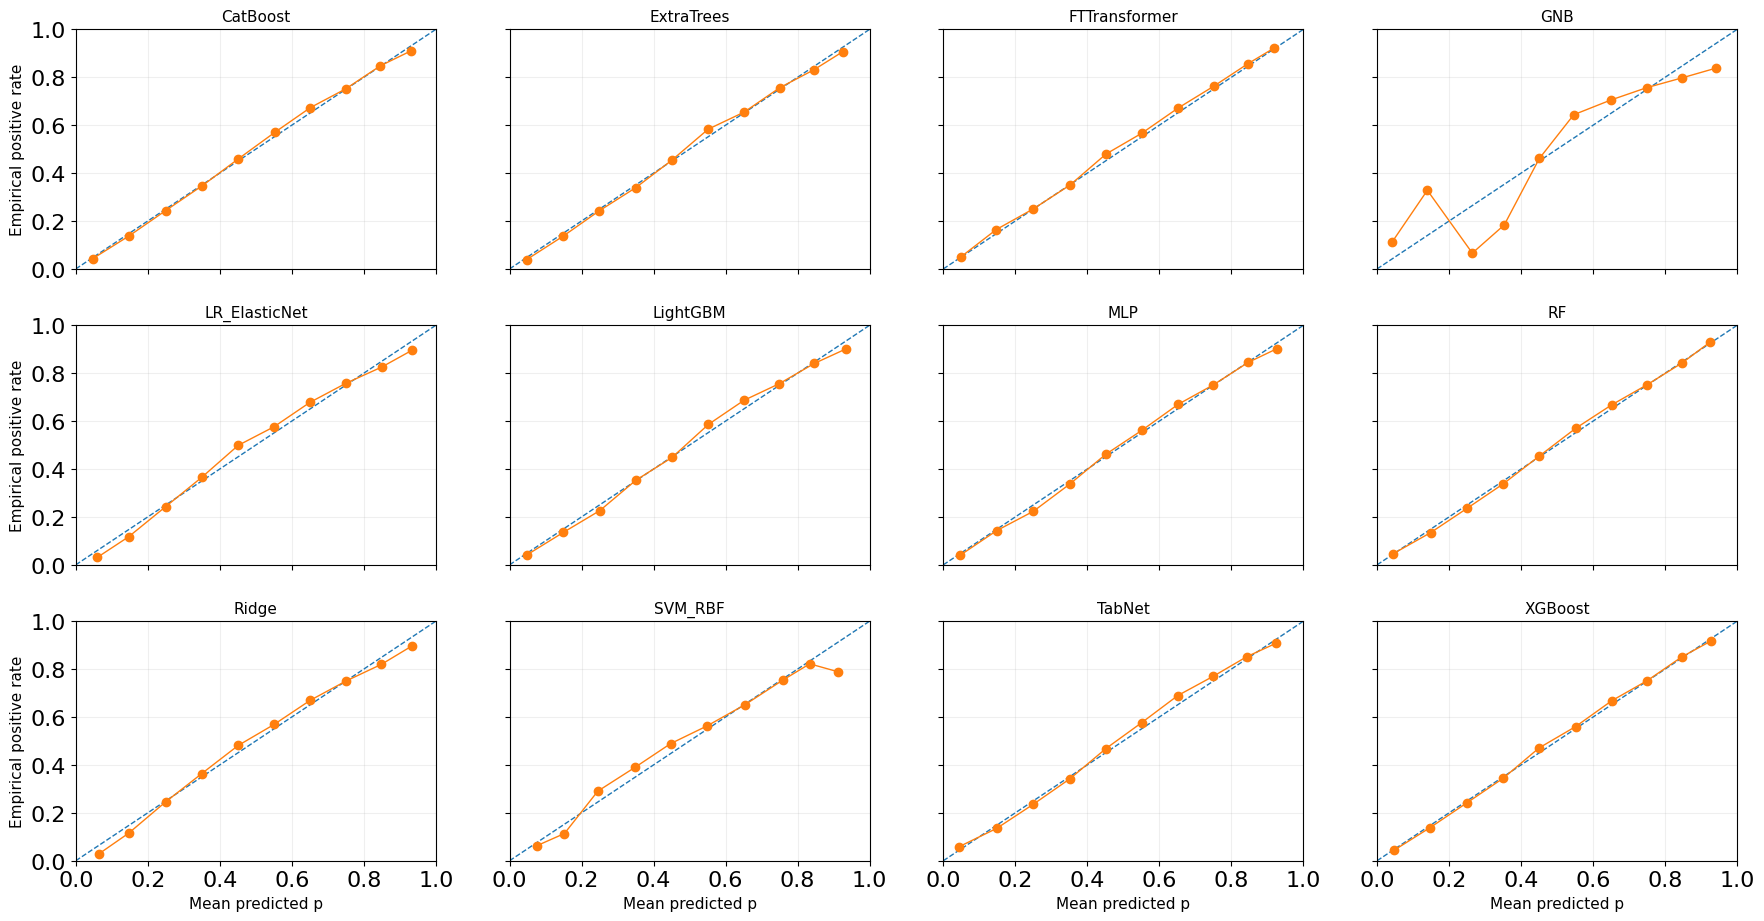

Saved:
/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/figures/fig_B1_reliability_all12_BRFSS2015_10k_p_temp.png
/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/figures/fig_B1_reliability_all12_BRFSS2015_10k_p_temp.pdf


In [24]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASET = "BRFSS2015_10k"         # change to "EarlyStage" for the other dataset
PROB_KEY = "p_temp"               # "p_raw" | "p_temp" | "p_iso"
N_BINS = 10                       # reliability bins
SAVE_DPI = 300

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# -----------------------------
# Helpers
# -----------------------------
def load_all_folds_concat(npz_dir, prob_key="p_temp"):
    """Concatenate y_test and chosen probability across all folds for a model."""
    files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
    if len(files) == 0:
        raise FileNotFoundError(f"No npz files found in: {npz_dir}")

    Y, P = [], []
    for f in files:
        z = np.load(f, allow_pickle=True)
        if "y_test" not in z or prob_key not in z:
            raise KeyError(f"Missing keys in {f}. Found keys: {list(z.keys())}")
        y = np.asarray(z["y_test"]).reshape(-1)
        p = np.asarray(z[prob_key]).reshape(-1)
        # safety: clip to [0,1]
        p = np.clip(p, 0.0, 1.0)
        Y.append(y)
        P.append(p)

    y_all = np.concatenate(Y, axis=0)
    p_all = np.concatenate(P, axis=0)
    return y_all, p_all

def reliability_curve(y, p, n_bins=10):
    """Return mean predicted prob and empirical positive rate per bin (skip empty bins)."""
    y = np.asarray(y).astype(float)
    p = np.asarray(p).astype(float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(p, edges) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    xs, ys = [], []
    for b in range(n_bins):
        m = (bin_ids == b)
        if m.sum() == 0:
            continue
        xs.append(p[m].mean())
        ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

# -----------------------------
# Main plot
# -----------------------------
preds_root = os.path.join(ROOT, DATASET, "preds_npz")
out_dir = os.path.join(ROOT, DATASET, "figures")
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, model in enumerate(MODELS_12):
    ax = axes[i]
    model_dir = os.path.join(preds_root, model)

    try:
        y_all, p_all = load_all_folds_concat(model_dir, prob_key=PROB_KEY)
        x, y = reliability_curve(y_all, p_all, n_bins=N_BINS)

        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        ax.plot(x, y, marker="o", linewidth=1)
        ax.set_title(model, fontsize=11)
    except Exception as e:
        ax.set_title(f"{model} (ERR)", fontsize=11)
        ax.text(0.02, 0.5, str(e), fontsize=7, va="center", ha="left", wrap=True)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

# shared labels
for ax in axes[::4]:
    ax.set_ylabel("Empirical positive rate", fontsize=11)
for ax in axes[-4:]:
    ax.set_xlabel("Mean predicted p", fontsize=11)

#fig.suptitle(f"{DATASET}: Reliability diagrams (all 12 models) [{PROB_KEY}]", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

save_path_png = os.path.join(out_dir, f"fig_B1_reliability_all12_{DATASET}_{PROB_KEY}.png")
save_path_pdf = os.path.join(out_dir, f"fig_B1_reliability_all12_{DATASET}_{PROB_KEY}.pdf")
fig.savefig(save_path_png, dpi=SAVE_DPI, bbox_inches="tight")
fig.savefig(save_path_pdf, bbox_inches="tight")
plt.show()

print("Saved:")
print(save_path_png)
print(save_path_pdf)

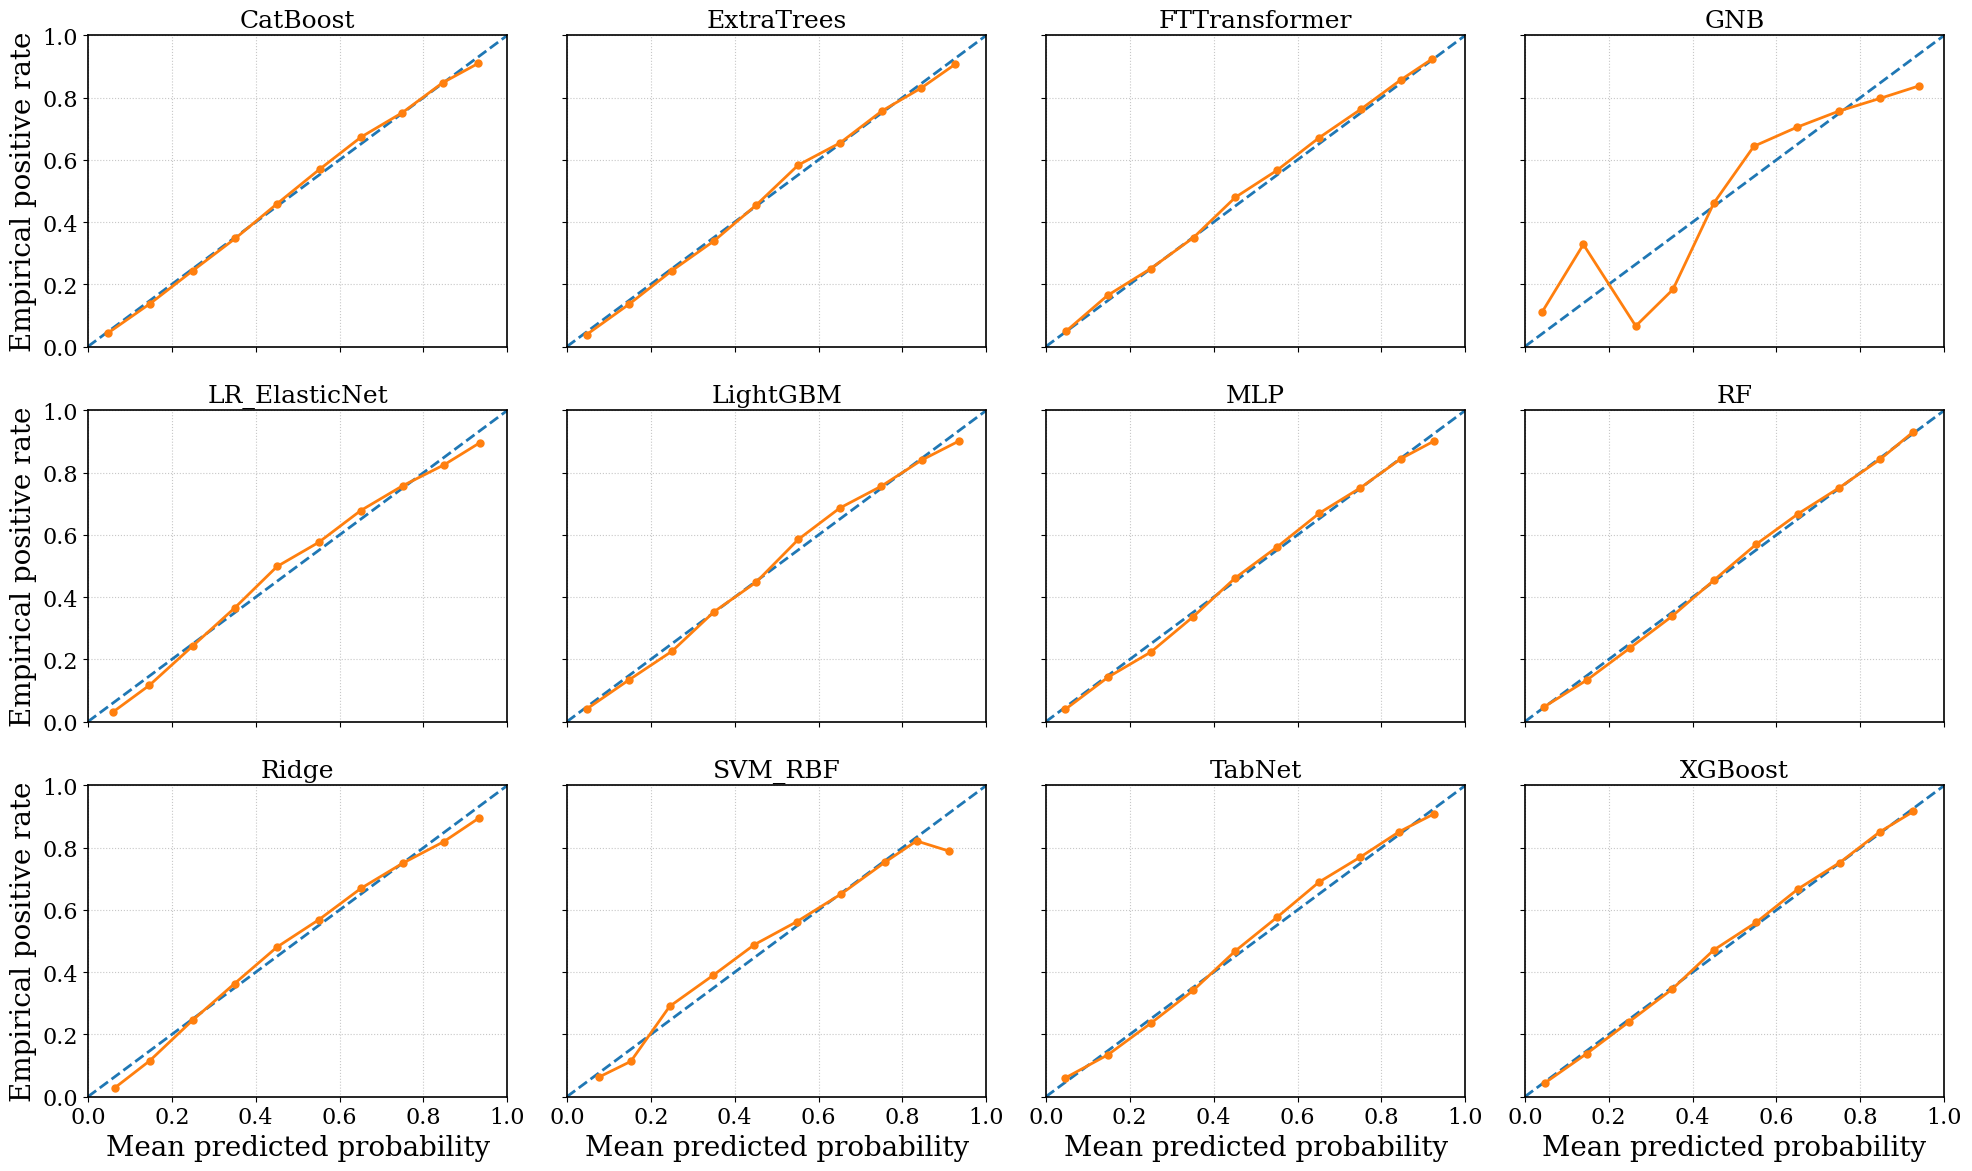

Saved:
/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/final_figures/BRFSS2015_10k_reliability_all12_p_temp_bins10.png
/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/final_figures/BRFSS2015_10k_reliability_all12_p_temp_bins10.pdf


In [27]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# CONFIG
# =========================
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASET = "BRFSS2015_10k"      # later: "EarlyStage"
PROB_KEY = "p_temp"            # "p_raw" | "p_temp" | "p_iso"
N_BINS = 10
DPI = 300

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# =========================
# JOURNAL-GRADE STYLE
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,   # subplot titles (model names)
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.2,
    "grid.linewidth": 0.8,
    "lines.linewidth": 2.0,
})

# =========================
# HELPERS
# =========================
def load_all_folds_concat(npz_dir, prob_key="p_temp"):
    files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
    if len(files) == 0:
        raise FileNotFoundError(f"No npz files found in: {npz_dir}")
    Y, P = [], []
    for f in files:
        z = np.load(f, allow_pickle=True)
        y = np.asarray(z["y_test"]).reshape(-1)
        p = np.asarray(z[prob_key]).reshape(-1)
        p = np.clip(p, 0, 1)
        Y.append(y)
        P.append(p)
    return np.concatenate(Y), np.concatenate(P)

def reliability_curve(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.digitize(p, edges) - 1
    ids = np.clip(ids, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = (ids == b)
        if m.sum() == 0:
            continue
        xs.append(p[m].mean())
        ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

# =========================
# PATHS
# =========================
preds_root = os.path.join(ROOT, DATASET, "preds_npz")
out_dir = os.path.join(ROOT, DATASET, "final_figures")
os.makedirs(out_dir, exist_ok=True)

# =========================
# PLOT (NO SUPTITLE)
# =========================
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, model in enumerate(MODELS_12):
    ax = axes[i]
    model_dir = os.path.join(preds_root, model)

    y_all, p_all = load_all_folds_concat(model_dir, prob_key=PROB_KEY)
    x, y = reliability_curve(y_all, p_all, n_bins=N_BINS)

    # perfect calibration reference
    ax.plot([0, 1], [0, 1], linestyle="--")

    # reliability curve
    ax.plot(x, y, marker="o", markersize=5)

    # model name as subplot title (allowed)
    ax.set_title(model, pad=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.7)

# axis labels only on outer plots
for ax in axes[::4]:
    ax.set_ylabel("Empirical positive rate")

for ax in axes[-4:]:
    ax.set_xlabel("Mean predicted probability")

fig.tight_layout()

# =========================
# SAVE
# =========================
base = f"{DATASET}_reliability_all12_{PROB_KEY}_bins{N_BINS}"
png_path = os.path.join(out_dir, f"{base}.png")
pdf_path = os.path.join(out_dir, f"{base}.pdf")

fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

In [28]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# CONFIG
# =========================
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["BRFSS2015_10k", "EarlyStage"]
PROB_KEY = "p_temp"
N_BINS = 10
DPI = 300

OUT_DIR = os.path.join(ROOT, "final_figures")
os.makedirs(OUT_DIR, exist_ok=True)

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# =========================
# JOURNAL STYLE
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.2,
    "grid.linewidth": 0.8,
    "lines.linewidth": 2.0,
})

# =========================
# HELPERS
# =========================
def load_all_folds_concat(npz_dir, prob_key="p_temp"):
    files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
    if len(files) == 0:
        raise FileNotFoundError(f"No npz files found in: {npz_dir}")
    Y, P = [], []
    for f in files:
        z = np.load(f, allow_pickle=True)
        y = np.asarray(z["y_test"]).reshape(-1)
        p = np.asarray(z[prob_key]).reshape(-1)
        p = np.clip(p, 0, 1)
        Y.append(y)
        P.append(p)
    return np.concatenate(Y), np.concatenate(P)

def reliability_curve(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.digitize(p, edges) - 1
    ids = np.clip(ids, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = (ids == b)
        if m.sum() == 0:
            continue
        xs.append(p[m].mean())
        ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

# =========================
# LOOP OVER BOTH DATASETS
# =========================
for DATASET in DATASETS:

    preds_root = os.path.join(ROOT, DATASET, "preds_npz")

    fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, model in enumerate(MODELS_12):
        ax = axes[i]
        model_dir = os.path.join(preds_root, model)

        y_all, p_all = load_all_folds_concat(model_dir, prob_key=PROB_KEY)
        x, y = reliability_curve(y_all, p_all, n_bins=N_BINS)

        # perfect calibration line
        ax.plot([0, 1], [0, 1], linestyle="--")

        # reliability curve
        ax.plot(x, y, marker="o", markersize=5)

        ax.set_title(model, pad=6)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle=":", alpha=0.7)

    # outer labels only
    for ax in axes[::4]:
        ax.set_ylabel("Empirical positive rate")

    for ax in axes[-4:]:
        ax.set_xlabel("Mean predicted probability")

    fig.tight_layout()

    # =========================
    # SAVE
    # =========================
    base = f"{DATASET}_Reliability_All12_{PROB_KEY}_bins{N_BINS}"
    png_path = os.path.join(OUT_DIR, f"{base}.png")
    pdf_path = os.path.join(OUT_DIR, f"{base}.pdf")

    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", pdf_path)

Saved: /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_Reliability_All12_p_temp_bins10.png
Saved: /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_Reliability_All12_p_temp_bins10.pdf
Saved: /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_Reliability_All12_p_temp_bins10.png
Saved: /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_Reliability_All12_p_temp_bins10.pdf


In [29]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# CONFIG
# =========================
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["BRFSS2015_10k", "EarlyStage"]
N_BINS = 10
DPI = 300

OUT_DIR = os.path.join(ROOT, "final_figures")
os.makedirs(OUT_DIR, exist_ok=True)

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

PROB_KEYS = [("p_raw", "Raw"), ("p_temp", "Temp"), ("p_iso", "Iso")]

# =========================
# JOURNAL STYLE
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "axes.linewidth": 1.2,
    "grid.linewidth": 0.8,
    "lines.linewidth": 2.2,
})

# =========================
# HELPERS
# =========================
def load_all_folds_concat(model_dir, key):
    files = sorted(glob.glob(os.path.join(model_dir, "*.npz")))
    if len(files) == 0:
        raise FileNotFoundError(f"No npz files found in: {model_dir}")
    Y, P = [], []
    for f in files:
        z = np.load(f, allow_pickle=True)
        y = np.asarray(z["y_test"]).reshape(-1)
        p = np.asarray(z[key]).reshape(-1)
        p = np.clip(p, 0, 1)
        Y.append(y)
        P.append(p)
    return np.concatenate(Y), np.concatenate(P)

def reliability_curve(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.digitize(p, edges) - 1
    ids = np.clip(ids, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = (ids == b)
        if m.sum() == 0:
            continue
        xs.append(p[m].mean())
        ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

# =========================
# PLOT: RAW vs TEMP vs ISO (ALL MODELS)
# =========================
for DATASET in DATASETS:
    preds_root = os.path.join(ROOT, DATASET, "preds_npz")

    fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, model in enumerate(MODELS_12):
        ax = axes[i]
        model_dir = os.path.join(preds_root, model)

        # Perfect calibration
        ax.plot([0, 1], [0, 1], linestyle="--")

        # Three curves
        for key, label in PROB_KEYS:
            y_all, p_all = load_all_folds_concat(model_dir, key)
            x, y = reliability_curve(y_all, p_all, n_bins=N_BINS)
            ax.plot(x, y, marker="o", markersize=4, label=label)

        ax.set_title(model, pad=6)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle=":", alpha=0.7)

        # Put legend only in the first subplot (cleaner)
        if i == 0:
            ax.legend(frameon=True, loc="lower right")

    # outer labels only
    for ax in axes[::4]:
        ax.set_ylabel("Empirical positive rate")
    for ax in axes[-4:]:
        ax.set_xlabel("Mean predicted probability")

    fig.tight_layout()

    base = f"{DATASET}_CalibrationCompare_All12_RawTempIso_bins{N_BINS}"
    png_path = os.path.join(OUT_DIR, f"{base}.png")
    pdf_path = os.path.join(OUT_DIR, f"{base}.pdf")

    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", pdf_path)

Saved: /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_CalibrationCompare_All12_RawTempIso_bins10.png
Saved: /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_CalibrationCompare_All12_RawTempIso_bins10.pdf
Saved: /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_CalibrationCompare_All12_RawTempIso_bins10.png
Saved: /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_CalibrationCompare_All12_RawTempIso_bins10.pdf


In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# CONFIG
# =========================
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["BRFSS2015_10k", "EarlyStage"]
OUT_DIR = os.path.join(ROOT, "final_figures")
os.makedirs(OUT_DIR, exist_ok=True)

DPI = 350

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# =========================
# JOURNAL STYLE (bigger labels/ticks)
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.2,
    "legend.fontsize": 16,
})

for DATASET in DATASETS:
    summary_path = os.path.join(ROOT, DATASET, "summary.csv")
    df = pd.read_csv(summary_path)

    # fixed column names from your file
    pr_col = "PR_AUC_temp"
    roc_col = "ROC_AUC_temp"

    assert "model" in df.columns, f"'model' not found. Columns: {list(df.columns)}"
    assert pr_col in df.columns, f"'{pr_col}' not found. Columns: {list(df.columns)}"
    assert roc_col in df.columns, f"'{roc_col}' not found. Columns: {list(df.columns)}"

    # order by MODELS_12
    df = df.set_index("model")
    missing = [m for m in MODELS_12 if m not in df.index]
    if missing:
        print(f"[WARN] {DATASET}: missing models in summary.csv -> {missing}")

    df = df.loc[[m for m in MODELS_12 if m in df.index]].reset_index()

    models = df["model"].tolist()
    pr = df[pr_col].astype(float).values
    roc = df[roc_col].astype(float).values

    y = np.arange(len(models))

    # ---------- FIGURE ----------
    fig, ax = plt.subplots(figsize=(9.2, 6.8))

    ax.scatter(pr, y, marker="o", s=70, label="PR-AUC (temp)")
    ax.scatter(roc, y, marker="s", s=70, label="ROC-AUC (temp)")

    ax.set_yticks(y)
    ax.set_yticklabels(models)

    ax.set_xlabel("Score")
    ax.set_ylabel("Model")

    ax.set_xlim(0.0, 1.02)
    ax.grid(True, linestyle=":", alpha=0.75)

    # compact, clean legend
    ax.legend(frameon=True, loc="lower right")

    fig.tight_layout()

    base = f"{DATASET}_Fig1_Performance_PRROC_All12"
    png_path = os.path.join(OUT_DIR, f"{base}.png")
    pdf_path = os.path.join(OUT_DIR, f"{base}.pdf")

    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print(f"[{DATASET}] Saved:\n  {png_path}\n  {pdf_path}")

[BRFSS2015_10k] Saved:
  /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_Fig1_Performance_PRROC_All12.png
  /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_Fig1_Performance_PRROC_All12.pdf
[EarlyStage] Saved:
  /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_Fig1_Performance_PRROC_All12.png
  /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_Fig1_Performance_PRROC_All12.pdf


In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["BRFSS2015_10k", "EarlyStage"]
OUT_DIR = os.path.join(ROOT, "final_figures")
os.makedirs(OUT_DIR, exist_ok=True)

DPI = 350

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 1.2,
})

for DATASET in DATASETS:
    df = pd.read_csv(os.path.join(ROOT, DATASET, "summary.csv"))
    df = df.set_index("model").loc[MODELS_12].reset_index()

    models = df["model"].tolist()
    y = np.arange(len(models))

    metrics = [
        ("ECE_temp", "ECE (temp) ↓"),
        ("Brier_temp", "Brier (temp) ↓"),
        ("NLL_temp", "NLL (temp) ↓"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18.5, 7.2), sharey=True)

    # shared y-axis labels only once
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(models)
    axes[0].set_ylabel("Model")

    for j, (col, xlabel) in enumerate(metrics):
        ax = axes[j]
        x = df[col].values
        xerr = df[f"{col}_std"].values

        ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3.5, markersize=6.5)
        ax.set_xlabel(xlabel)
        ax.grid(True, linestyle=":", alpha=0.75)
        ax.set_ylim(-0.5, len(models) - 0.5)

        if j > 0:
            ax.tick_params(axis="y", which="both", labelleft=False)

    # ===== place (a)(b)(c) BELOW each subfigure =====
    panel_labels = ["(a)", "(b)", "(c)"]
    for j, ax in enumerate(axes):
        bbox = ax.get_position()
        x_center = (bbox.x0 + bbox.x1) / 2
        y_bottom = bbox.y0 - 0.06   # distance below subplot
        fig.text(x_center, y_bottom, panel_labels[j],
                 ha="center", va="top", fontsize=18)

    # reserve margins for long labels + bottom panel letters
    fig.subplots_adjust(left=0.30, right=0.995, bottom=0.22, top=0.98, wspace=0.18)

    base = f"{DATASET}_Fig2_Calibration_ECE_Brier_NLL_All12"
    fig.savefig(os.path.join(OUT_DIR, base + ".png"), dpi=DPI)
    fig.savefig(os.path.join(OUT_DIR, base + ".pdf"))
    plt.close(fig)

    print("Saved:", os.path.join(OUT_DIR, base + ".png"))

Saved: /kaggle/working/uq_2datasets_30k/final_figures/BRFSS2015_10k_Fig2_Calibration_ECE_Brier_NLL_All12.png
Saved: /kaggle/working/uq_2datasets_30k/final_figures/EarlyStage_Fig2_Calibration_ECE_Brier_NLL_All12.png


In [39]:
# =========================
# FIGURE 3: Risk–Coverage curves (all 12 models) for BOTH datasets
# - Uses p_temp + u_epistemic_test from NPZ
# - Mean curve with ±1 std shading over folds
# - No overall title
# - Journal-grade fonts
# - Saves to /kaggle/working/final_figures
# =========================

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = ["BRFSS2015_10k", "EarlyStage"]

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

DPI = 400

# -------- Journal-style typography --------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.2,
    "legend.fontsize": 10,
})

def load_npz_minimal(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    keys = set(z.files)
    need = ["y_test", "p_temp", "u_epistemic_test"]
    missing = [k for k in need if k not in keys]
    if missing:
        raise KeyError(f"Missing keys {missing} in {npz_path}. Keys={list(keys)}")
    y = np.asarray(z["y_test"]).reshape(-1).astype(int)
    p = np.asarray(z["p_temp"]).reshape(-1).astype(float)
    u = np.asarray(z["u_epistemic_test"]).reshape(-1).astype(float)
    return y, p, u

def risk_coverage_curve(y, p, u, thr=0.5):
    """
    Sort by uncertainty ascending (retain most certain first).
    Coverage = k/n
    Risk = mean(error) among retained k samples = 1 - accuracy
    """
    yhat = (p >= thr).astype(int)
    err = (yhat != y).astype(float)

    order = np.argsort(u)  # low uncertainty first
    err_s = err[order]

    n = len(err_s)
    k = np.arange(1, n+1)
    coverage = k / n
    risk = np.cumsum(err_s) / k
    return coverage, risk

def interp_to_grid(cov, risk, grid):
    # cov starts at 1/n; grid starts later (e.g., 0.05) so interp is safe
    return np.interp(grid, cov, risk)

def plot_risk_coverage_all12(dataset_name):
    base = os.path.join(ROOT, dataset_name, "preds_npz")

    # Common coverage grid (avoid the very beginning instability)
    grid = np.linspace(0.05, 1.0, 250)

    model_curves = {}
    model_epaurc = {}

    for model in MODELS_12:
        model_dir = os.path.join(base, model)
        npz_files = sorted(glob.glob(os.path.join(model_dir, "fold*.npz")))
        if len(npz_files) == 0:
            print(f"[WARN] No fold NPZ found for {dataset_name}/{model}")
            continue

        risks_interp = []
        for fp in npz_files:
            y, p, u = load_npz_minimal(fp)
            cov, risk = risk_coverage_curve(y, p, u, thr=0.5)
            risks_interp.append(interp_to_grid(cov, risk, grid))

        risks_interp = np.vstack(risks_interp)
        r_mu = risks_interp.mean(axis=0)
        r_sd = risks_interp.std(axis=0, ddof=1) if risks_interp.shape[0] > 1 else np.zeros_like(r_mu)

        model_curves[model] = (r_mu, r_sd)
        model_epaurc[model] = np.trapz(r_mu, grid)  # EpAURC proxy (mean curve area)

    # Order legend by EpAURC (lower better)
    order = sorted(model_epaurc.keys(), key=lambda m: model_epaurc[m])

    fig, ax = plt.subplots(figsize=(9.5, 7.2))

    for model in order:
        r_mu, r_sd = model_curves[model]
        ax.plot(grid, r_mu, linewidth=2.0, label=f"{model} (EpAURC={model_epaurc[model]:.3f})")
        ax.fill_between(grid, np.clip(r_mu - r_sd, 0, 1), np.clip(r_mu + r_sd, 0, 1), alpha=0.12)

    ax.set_xlabel("Coverage (retain most certain) ↑")
    ax.set_ylabel("Risk (1 − accuracy) ↓")
    ax.grid(True, linestyle=":", alpha=0.75)
    ax.set_xlim(0.05, 1.0)

    # Dataset-specific y-limit (keeps it readable)
    if dataset_name.lower().startswith("brfss"):
        ax.set_ylim(0.0, 0.35)
    else:
        ax.set_ylim(0.0, 0.12)

    # No overall title (as requested)
    ax.legend(loc="upper left", frameon=True, ncol=1)

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.98)

    fname = f"{dataset_name}_Fig3_RiskCoverage_All12"
    out_png = os.path.join(OUTDIR, fname + ".png")
    out_pdf = os.path.join(OUTDIR, fname + ".pdf")
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", out_png)
    print("Saved:", out_pdf)

# ---- Run for both datasets ----
for ds in DATASETS:
    plot_risk_coverage_all12(ds)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3_RiskCoverage_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3_RiskCoverage_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig3_RiskCoverage_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig3_RiskCoverage_All12.pdf


In [40]:
# =========================
# FIG 3A: EpAURC Forest Plot (All 12 Models) — BOTH datasets
# Saves to: /kaggle/working/final_figures/
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
BASE_DIR = "/kaggle/working/uq_2datasets_30k"
OUT_DIR  = "/kaggle/working/final_figures"
os.makedirs(OUT_DIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE_DIR, "BRFSS2015_10k", "summary.csv"),
    "EarlyStage":    os.path.join(BASE_DIR, "EarlyStage",    "summary.csv"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB","LR_ElasticNet","LightGBM",
    "MLP","RF","Ridge","SVM_RBF","TabNet","XGBoost"
]

# If True: sort models by EpAURC (best at top). If False: keep MODELS_12 order.
SORT_BY_EPAURC = True

# Journal-grade styling
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.2,
})

def _load_and_prepare(summary_path: str) -> pd.DataFrame:
    df = pd.read_csv(summary_path)
    assert "model" in df.columns, f"'model' column not found. Columns: {list(df.columns)}"
    assert "EpAURC" in df.columns, f"'EpAURC' not found. Columns: {list(df.columns)}"
    assert "EpAURC_std" in df.columns, f"'EpAURC_std' not found. Columns: {list(df.columns)}"

    df = df[df["model"].isin(MODELS_12)].copy()

    # Ensure all 12 exist
    missing = [m for m in MODELS_12 if m not in set(df["model"])]
    assert len(missing) == 0, f"Missing models in {summary_path}: {missing}"

    # Keep only needed columns
    df = df[["model", "EpAURC", "EpAURC_std"]].copy()
    df["EpAURC"] = pd.to_numeric(df["EpAURC"], errors="coerce")
    df["EpAURC_std"] = pd.to_numeric(df["EpAURC_std"], errors="coerce").fillna(0.0)

    # Optional sorting
    if SORT_BY_EPAURC:
        df = df.sort_values("EpAURC", ascending=True)
    else:
        df["__order"] = df["model"].map({m:i for i,m in enumerate(MODELS_12)})
        df = df.sort_values("__order").drop(columns="__order")

    return df.reset_index(drop=True)

def plot_epaurc_forest(dataset_name: str, summary_path: str):
    df = _load_and_prepare(summary_path)

    models = df["model"].tolist()
    mu = df["EpAURC"].values
    sd = df["EpAURC_std"].values

    # y positions: top=best if sorted ascending
    y = np.arange(len(models))[::-1]

    fig_w, fig_h = 9.5, 6.5  # single-panel, large enough for 12 models
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.errorbar(
        mu, y,
        xerr=sd,
        fmt="o",
        capsize=4,
        elinewidth=1.8,
        markersize=7,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(models)

    ax.set_xlabel("EpAURC ↓")
    ax.set_ylabel("Model")

    # Grid for readability
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(False, axis="y")

    # Slight padding on x-limits
    xmin = float(np.min(mu - sd))
    xmax = float(np.max(mu + sd))
    pad = 0.06 * (xmax - xmin + 1e-12)
    ax.set_xlim(xmin - pad, xmax + pad)

    # No overall title (as requested)
    plt.tight_layout()

    # Save
    base = f"{dataset_name}_Fig3A_EpAURC_Forest_All12"
    out_png = os.path.join(OUT_DIR, base + ".png")
    out_pdf = os.path.join(OUT_DIR, base + ".pdf")

    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

    print(f"[Saved] {out_png}")
    print(f"[Saved] {out_pdf}")

# -------------------------
# RUN for BOTH datasets
# -------------------------
for dname, spath in DATASETS.items():
    assert os.path.exists(spath), f"Missing: {spath}"
    plot_epaurc_forest(dname, spath)

[Saved] /kaggle/working/final_figures/BRFSS2015_10k_Fig3A_EpAURC_Forest_All12.png
[Saved] /kaggle/working/final_figures/BRFSS2015_10k_Fig3A_EpAURC_Forest_All12.pdf
[Saved] /kaggle/working/final_figures/EarlyStage_Fig3A_EpAURC_Forest_All12.png
[Saved] /kaggle/working/final_figures/EarlyStage_Fig3A_EpAURC_Forest_All12.pdf


In [43]:
# ============================================
# CLEAN SINGLE FIG — Risk–Coverage Heatmap
# (No (a)/(b), no overlap, journal spacing)
# ============================================

import os, glob
import numpy as np
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

COV_GRID = np.round(np.arange(0.50, 1.001, 0.05), 2)

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def compute_matrix(dataset_dir):
    preds_root = os.path.join(dataset_dir, "preds_npz")
    mat = np.zeros((len(MODELS_12), len(COV_GRID)))

    for i, m in enumerate(MODELS_12):
        files = sorted(glob.glob(os.path.join(preds_root, m, "fold*.npz")))
        risks_folds = []

        for fp in files:
            z = np.load(fp, allow_pickle=True)
            y = z["y_test"]
            p = z["p_temp"]
            u = z["u_epistemic_test"]
            t = float(z["tJ"])

            order = np.argsort(u)
            y = y[order]
            p = p[order]
            n = len(y)

            risks = []
            for cov in COV_GRID:
                k = int(np.ceil(cov * n))
                k = max(1, min(n, k))
                pred = (p[:k] >= t).astype(int)
                risks.append(np.mean(pred != y[:k]))

            risks_folds.append(risks)

        mat[i] = np.mean(risks_folds, axis=0)

    return mat

def plot_single(dataset_name):
    mat = compute_matrix(DATASETS[dataset_name])

    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(mat, aspect="auto", interpolation="nearest")

    ax.set_xticks(np.arange(len(COV_GRID)))
    ax.set_xticklabels([f"{c:.2f}" for c in COV_GRID], rotation=45, ha="right")

    ax.set_yticks(np.arange(len(MODELS_12)))
    ax.set_yticklabels(MODELS_12)

    ax.set_xlabel("Coverage")
    ax.set_ylabel("Model")

    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
    cbar.set_label("Selective risk (error on accepted set)")

    # ---- FIX overlap: increase bottom margin ----
    plt.subplots_adjust(bottom=0.18)

    fname = f"{dataset_name}_3Fig3F_RiskCoverageHeatmap_All12"
    fig.savefig(os.path.join(OUTDIR, fname + ".png"), bbox_inches="tight")
    fig.savefig(os.path.join(OUTDIR, fname + ".pdf"), bbox_inches="tight")
    plt.close(fig)

    print("Saved:", fname)

# Run for both datasets
plot_single("BRFSS2015_10k")
plot_single("EarlyStage")

Saved: BRFSS2015_10k_3Fig3F_RiskCoverageHeatmap_All12
Saved: EarlyStage_3Fig3F_RiskCoverageHeatmap_All12


In [44]:
# ============================================
# FIG 3A — EpAURC Forest Plot (All 12 models)
# For BOTH datasets, saved in /final_figures
# No overall title
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# Journal-grade defaults
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def _pick_col(df, target):
    # exact match first, then case-insensitive contains
    if target in df.columns:
        return target
    low = {c.lower(): c for c in df.columns}
    if target.lower() in low:
        return low[target.lower()]
    for c in df.columns:
        if target.lower() in c.lower():
            return c
    return None

def plot_epaurc_forest(dataset_name, dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)

    assert "model" in df.columns, f"'model' not found in {summary_path}. Columns={list(df.columns)}"

    ep_col = _pick_col(df, "EpAURC")
    ep_std_col = _pick_col(df, "EpAURC_std")
    nfold_col = _pick_col(df, "n_folds")

    assert ep_col is not None, f"EpAURC column not found. Columns={list(df.columns)}"
    assert ep_std_col is not None, f"EpAURC_std column not found. Columns={list(df.columns)}"
    assert nfold_col is not None, f"n_folds column not found. Columns={list(df.columns)}"

    df = df.set_index("model").loc[MODELS_12].reset_index()

    mean = df[ep_col].astype(float).values
    std = df[ep_std_col].astype(float).values
    n_folds = int(df[nfold_col].iloc[0]) if np.all(pd.notnull(df[nfold_col])) else 5

    # 95% CI: mean ± 1.96 * (std / sqrt(n_folds))
    se = std / np.sqrt(max(n_folds, 1))
    half = 1.96 * se
    lo = mean - half
    hi = mean + half

    y = np.arange(len(MODELS_12))

    fig_h = 0.55 * len(MODELS_12) + 1.5  # scale height by number of models
    fig, ax = plt.subplots(figsize=(10.5, fig_h))

    ax.errorbar(
        mean, y,
        xerr=[mean - lo, hi - mean],
        fmt="o",
        capsize=4,
        elinewidth=2.2,
        markersize=7
    )

    ax.set_yticks(y)
    ax.set_yticklabels(MODELS_12)
    ax.invert_yaxis()

    ax.set_xlabel("EpAURC ↓")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    # tighten layout so labels are never clipped
    plt.subplots_adjust(left=0.28, right=0.98, top=0.98, bottom=0.12)

    fname = f"{dataset_name}_Fig3A_EpAURC_Forest_All12"
    fig.savefig(os.path.join(OUTDIR, fname + ".png"), bbox_inches="tight")
    fig.savefig(os.path.join(OUTDIR, fname + ".pdf"), bbox_inches="tight")
    plt.close(fig)

    print("Saved:", os.path.join(OUTDIR, fname + ".png"))
    print("Saved:", os.path.join(OUTDIR, fname + ".pdf"))

# Run both
for dname, ddir in DATASETS.items():
    plot_epaurc_forest(dname, ddir)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3A_EpAURC_Forest_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3A_EpAURC_Forest_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig3A_EpAURC_Forest_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig3A_EpAURC_Forest_All12.pdf


In [45]:
# ==========================================================
# FIG 3B — Safety indicators (All 12 models, both datasets)
# Multiple plot options:
#   (1) Two-panel forest (HCWrong + Spearman)
#   (2) Dumbbell (2 panels)
#   (3) Scatter (Spearman vs HCWrong)
#   (4) Rank heatmap (optional)
# Saves to: /kaggle/working/final_figures
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def _pick_col(df, target):
    # exact -> case-insensitive -> contains
    if target in df.columns:
        return target
    low = {c.lower(): c for c in df.columns}
    if target.lower() in low:
        return low[target.lower()]
    for c in df.columns:
        if target.lower() in c.lower():
            return c
    return None

def _ci95_from_std(std, n):
    se = std / np.sqrt(max(int(n), 1))
    half = 1.96 * se
    return half

def load_metrics(dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)
    assert "model" in df.columns, f"'model' column not found in {summary_path}. Columns={list(df.columns)}"

    # expected columns in your summary.csv:
    # HCWrong_p90, HCWrong_p90_std, SpearmanUE, SpearmanUE_std, n_folds
    hc_col = _pick_col(df, "HCWrong_p90")
    hc_std = _pick_col(df, "HCWrong_p90_std")
    sp_col = _pick_col(df, "SpearmanUE")
    sp_std = _pick_col(df, "SpearmanUE_std")
    nfold = _pick_col(df, "n_folds")

    assert hc_col is not None, f"HCWrong_p90 column not found. Columns={list(df.columns)}"
    assert hc_std is not None, f"HCWrong_p90_std column not found. Columns={list(df.columns)}"
    assert sp_col is not None, f"SpearmanUE column not found. Columns={list(df.columns)}"
    assert sp_std is not None, f"SpearmanUE_std column not found. Columns={list(df.columns)}"
    assert nfold is not None, f"n_folds column not found. Columns={list(df.columns)}"

    df = df.set_index("model").loc[MODELS_12].reset_index()
    n = int(df[nfold].iloc[0])

    out = pd.DataFrame({
        "model": MODELS_12,
        "hc_mean": df[hc_col].astype(float).values,
        "hc_std":  df[hc_std].astype(float).values,
        "sp_mean": df[sp_col].astype(float).values,
        "sp_std":  df[sp_std].astype(float).values,
    })
    out["hc_half"] = _ci95_from_std(out["hc_std"].values, n)
    out["sp_half"] = _ci95_from_std(out["sp_std"].values, n)
    out["n_folds"] = n
    return out

def savefig(fig, path_base):
    fig.savefig(path_base + ".png", bbox_inches="tight")
    fig.savefig(path_base + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_base + ".png")
    print("Saved:", path_base + ".pdf")

# -------------------------
# Option 1: Two-panel forest
# -------------------------
def fig3b_two_panel_forest(dataset_name, dfm):
    y = np.arange(len(dfm))
    fig_h = 0.55 * len(dfm) + 1.8
    fig, axes = plt.subplots(1, 2, figsize=(14.5, fig_h), sharey=True)

    # (a) HCWrong_p90 (lower better)
    ax = axes[0]
    ax.errorbar(
        dfm["hc_mean"].values, y,
        xerr=dfm["hc_half"].values,
        fmt="o", capsize=4, elinewidth=2.2, markersize=7
    )
    ax.set_xlabel("High-conf wrong (p>0.9) ↓")
    ax.set_yticks(y)
    ax.set_yticklabels(dfm["model"].tolist())
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    # (b) SpearmanUE (higher better)
    ax = axes[1]
    ax.errorbar(
        dfm["sp_mean"].values, y,
        xerr=dfm["sp_half"].values,
        fmt="o", capsize=4, elinewidth=2.2, markersize=7
    )
    ax.set_xlabel("Spearman(u, error) ↑")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    # keep clean (no overall title)
    plt.subplots_adjust(left=0.28, right=0.98, bottom=0.12, top=0.98, wspace=0.25)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig3B_Forest_HCWrong_Spearman_All12")
    savefig(fig, base)

# -------------------------
# Option 2: Dumbbell (2 panels, no CI by default)
# (CI can clutter here; we keep it clean)
# -------------------------
def fig3b_dumbbell(dataset_name, dfm):
    y = np.arange(len(dfm))
    fig_h = 0.55 * len(dfm) + 1.8
    fig, axes = plt.subplots(1, 2, figsize=(14.5, fig_h), sharey=True)

    # HCWrong dumbbell (point + CI line)
    ax = axes[0]
    x = dfm["hc_mean"].values
    lo = x - dfm["hc_half"].values
    hi = x + dfm["hc_half"].values
    for i in range(len(dfm)):
        ax.plot([lo[i], hi[i]], [i, i], linewidth=2.2)
        ax.plot(x[i], i, "o", markersize=7)
    ax.set_xlabel("High-conf wrong (p>0.9) ↓")
    ax.set_yticks(y)
    ax.set_yticklabels(dfm["model"].tolist())
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    # Spearman dumbbell (point + CI line)
    ax = axes[1]
    x = dfm["sp_mean"].values
    lo = x - dfm["sp_half"].values
    hi = x + dfm["sp_half"].values
    for i in range(len(dfm)):
        ax.plot([lo[i], hi[i]], [i, i], linewidth=2.2)
        ax.plot(x[i], i, "o", markersize=7)
    ax.set_xlabel("Spearman(u, error) ↑")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    plt.subplots_adjust(left=0.28, right=0.98, bottom=0.12, top=0.98, wspace=0.25)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig3B_Dumbbell_HCWrong_Spearman_All12")
    savefig(fig, base)

# -------------------------
# Option 3: Scatter (trade-off view)
# -------------------------
def fig3b_scatter(dataset_name, dfm, annotate=True):
    fig, ax = plt.subplots(figsize=(10.5, 8.5))
    x = dfm["sp_mean"].values
    y = dfm["hc_mean"].values
    ax.scatter(x, y, s=80)

    ax.set_xlabel("Spearman(u, error) ↑")
    ax.set_ylabel("High-conf wrong (p>0.9) ↓")
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)

    # Optional: annotate with model names (journal-friendly if not too crowded)
    if annotate:
        for i, m in enumerate(dfm["model"].tolist()):
            ax.annotate(m, (x[i], y[i]), fontsize=14, xytext=(6, 4), textcoords="offset points")

    # invert y so "better" is up-right
    ax.invert_yaxis()

    plt.subplots_adjust(left=0.14, right=0.98, bottom=0.14, top=0.98)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig3B_Scatter_Spearman_vs_HCWrong_All12")
    savefig(fig, base)

# -------------------------
# Option 4: Rank heatmap (compare ranks across the two metrics)
# (Creates one heatmap PER dataset)
# -------------------------
def fig3b_rank_heatmap(dataset_name, dfm):
    # rank: lower HCWrong is better -> rank ascending
    # rank: higher Spearman is better -> rank descending
    hc_rank = dfm["hc_mean"].rank(method="min", ascending=True).values
    sp_rank = dfm["sp_mean"].rank(method="min", ascending=False).values

    mat = np.vstack([hc_rank, sp_rank])  # shape (2, 12)

    fig, ax = plt.subplots(figsize=(12.5, 3.2))
    im = ax.imshow(mat, aspect="auto")

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Rank: HCWrong ↓", "Rank: Spearman ↑"])
    ax.set_xticks(np.arange(len(dfm)))
    ax.set_xticklabels(dfm["model"].tolist(), rotation=35, ha="right")

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Rank (lower = better)", fontsize=16)

    plt.subplots_adjust(left=0.12, right=0.98, bottom=0.35, top=0.95)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig3B_RankHeatmap_HCWrong_Spearman_All12")
    savefig(fig, base)

# -------------------------
# Run all options for both datasets
# -------------------------
for dname, ddir in DATASETS.items():
    dfm = load_metrics(ddir)
    fig3b_two_panel_forest(dname, dfm)
    fig3b_dumbbell(dname, dfm)
    fig3b_scatter(dname, dfm, annotate=True)
    fig3b_rank_heatmap(dname, dfm)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_Forest_HCWrong_Spearman_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_Forest_HCWrong_Spearman_All12.pdf
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_Dumbbell_HCWrong_Spearman_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_Dumbbell_HCWrong_Spearman_All12.pdf
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_Scatter_Spearman_vs_HCWrong_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_Scatter_Spearman_vs_HCWrong_All12.pdf
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_RankHeatmap_HCWrong_Spearman_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig3B_RankHeatmap_HCWrong_Spearman_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig3B_Forest_HCWrong_Spearman_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig3B_Forest_HCWrong_Spearman_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig3B_Dumbbell_HCWrong_Spe

In [46]:
# ==========================================================
# FIG 4 — Conformal prediction (all 12 models, both datasets)
# 1×2 figure per dataset:
#   Left: Coverage deviation (Cov@90-0.90, Cov@95-0.95)
#   Right: Set size (Size@90, Size@95)
# No overall title. Journal-grade fonts.
# Saves PNG+PDF in /kaggle/working/final_figures
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def _pick_col(df, target):
    if target in df.columns:
        return target
    low = {c.lower(): c for c in df.columns}
    if target.lower() in low:
        return low[target.lower()]
    for c in df.columns:
        if target.lower() in c.lower():
            return c
    return None

def _ci95_half_from_std(std, n):
    se = std / np.sqrt(max(int(n), 1))
    return 1.96 * se

def savefig(fig, path_base):
    fig.savefig(path_base + ".png", bbox_inches="tight")
    fig.savefig(path_base + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_base + ".png")
    print("Saved:", path_base + ".pdf")

def load_conformal_from_summary(dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)
    assert "model" in df.columns, f"'model' column not found in {summary_path}. Columns={list(df.columns)}"

    cov90 = _pick_col(df, "Conf90_cov")
    cov90s = _pick_col(df, "Conf90_cov_std")
    size90 = _pick_col(df, "Conf90_size")
    size90s = _pick_col(df, "Conf90_size_std")

    cov95 = _pick_col(df, "Conf95_cov")
    cov95s = _pick_col(df, "Conf95_cov_std")
    size95 = _pick_col(df, "Conf95_size")
    size95s = _pick_col(df, "Conf95_size_std")

    nfold = _pick_col(df, "n_folds")

    for k, col in [("Conf90_cov", cov90), ("Conf90_cov_std", cov90s),
                   ("Conf90_size", size90), ("Conf90_size_std", size90s),
                   ("Conf95_cov", cov95), ("Conf95_cov_std", cov95s),
                   ("Conf95_size", size95), ("Conf95_size_std", size95s),
                   ("n_folds", nfold)]:
        assert col is not None, f"Could not find {k} in {summary_path}. Columns={list(df.columns)}"

    df = df.set_index("model").loc[MODELS_12].reset_index()
    n = int(df[nfold].iloc[0])

    out = pd.DataFrame({
        "model": MODELS_12,
        "cov90": df[cov90].astype(float).values,
        "cov90_std": df[cov90s].astype(float).values,
        "size90": df[size90].astype(float).values,
        "size90_std": df[size90s].astype(float).values,
        "cov95": df[cov95].astype(float).values,
        "cov95_std": df[cov95s].astype(float).values,
        "size95": df[size95].astype(float).values,
        "size95_std": df[size95s].astype(float).values,
        "n_folds": n
    })

    # 95% CI half-widths from std across folds (approx)
    out["cov90_half"]  = _ci95_half_from_std(out["cov90_std"].values,  n)
    out["cov95_half"]  = _ci95_half_from_std(out["cov95_std"].values,  n)
    out["size90_half"] = _ci95_half_from_std(out["size90_std"].values, n)
    out["size95_half"] = _ci95_half_from_std(out["size95_std"].values, n)
    return out

def fig4_conformal_validity_and_size(dataset_name, dfm):
    # y positions
    y = np.arange(len(dfm))
    fig_h = 0.55 * len(dfm) + 1.8
    fig, axes = plt.subplots(1, 2, figsize=(15.5, fig_h), sharey=True)

    # -------------------------
    # Left: Coverage deviation from target
    # -------------------------
    ax = axes[0]
    dev90 = dfm["cov90"].values - 0.90
    dev95 = dfm["cov95"].values - 0.95

    # CI half-widths remain same when subtracting constant
    ax.errorbar(dev90, y, xerr=dfm["cov90_half"].values, fmt="o", capsize=4, elinewidth=2.2, markersize=7, label="90% target")
    ax.errorbar(dev95, y, xerr=dfm["cov95_half"].values, fmt="o", capsize=4, elinewidth=2.2, markersize=7, label="95% target")

    ax.axvline(0.0, linestyle="--", linewidth=1.6)  # perfect validity line
    ax.set_xlabel("Coverage deviation (Cov − target)")
    ax.set_yticks(y)
    ax.set_yticklabels(dfm["model"].tolist())
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend(frameon=False, fontsize=15, loc="lower right")

    # -------------------------
    # Right: Set size
    # -------------------------
    ax = axes[1]
    ax.errorbar(dfm["size90"].values, y, xerr=dfm["size90_half"].values, fmt="o", capsize=4, elinewidth=2.2, markersize=7, label="Size@90%")
    ax.errorbar(dfm["size95"].values, y, xerr=dfm["size95_half"].values, fmt="o", capsize=4, elinewidth=2.2, markersize=7, label="Size@95%")

    ax.set_xlabel("Prediction set size (smaller ↓)")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend(frameon=False, fontsize=15, loc="lower right")

    # Layout: ensure model names visible and no overall title
    plt.subplots_adjust(left=0.28, right=0.98, bottom=0.12, top=0.98, wspace=0.25)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig4_Conformal_Validity_and_SetSize_All12")
    savefig(fig, base)

# -------------------------
# Run for both datasets
# -------------------------
for dname, ddir in DATASETS.items():
    dfm = load_conformal_from_summary(ddir)
    fig4_conformal_validity_and_size(dname, dfm)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig4_Conformal_Validity_and_SetSize_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig4_Conformal_Validity_and_SetSize_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig4_Conformal_Validity_and_SetSize_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig4_Conformal_Validity_and_SetSize_All12.pdf


In [47]:
# ==========================================================
# FIG 5 — Discrimination (PR-AUC + ROC-AUC) with 95% CI
# (all 12 models, both datasets)
# Uses summary.csv columns like PR_AUC_temp, ROC_AUC_temp, and *_std
# No overall title. Journal-grade fonts.
# Saves PNG+PDF in /kaggle/working/final_figures
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def _pick_col(df, target):
    # exact
    if target in df.columns:
        return target
    # case-insensitive exact
    low = {c.lower(): c for c in df.columns}
    if target.lower() in low:
        return low[target.lower()]
    # contains match
    for c in df.columns:
        if target.lower() == c.lower().replace(" ", ""):
            return c
    for c in df.columns:
        if target.lower() in c.lower():
            return c
    return None

def _ci95_half_from_std(std, n):
    se = std / np.sqrt(max(int(n), 1))
    return 1.96 * se

def savefig(fig, path_base):
    fig.savefig(path_base + ".png", bbox_inches="tight")
    fig.savefig(path_base + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_base + ".png")
    print("Saved:", path_base + ".pdf")

def load_discrimination_from_summary(dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)
    assert "model" in df.columns, f"'model' column not found in {summary_path}. Columns={list(df.columns)}"

    pr = _pick_col(df, "PR_AUC_temp")
    pr_s = _pick_col(df, "PR_AUC_temp_std")
    roc = _pick_col(df, "ROC_AUC_temp")
    roc_s = _pick_col(df, "ROC_AUC_temp_std")
    nfold = _pick_col(df, "n_folds")

    for k, col in [("PR_AUC_temp", pr), ("PR_AUC_temp_std", pr_s),
                   ("ROC_AUC_temp", roc), ("ROC_AUC_temp_std", roc_s),
                   ("n_folds", nfold)]:
        assert col is not None, f"Could not find {k} in {summary_path}. Columns={list(df.columns)}"

    df = df.set_index("model").loc[MODELS_12].reset_index()
    n = int(df[nfold].iloc[0])

    out = pd.DataFrame({
        "model": MODELS_12,
        "pr": df[pr].astype(float).values,
        "pr_std": df[pr_s].astype(float).values,
        "roc": df[roc].astype(float).values,
        "roc_std": df[roc_s].astype(float).values,
        "n_folds": n,
    })

    out["pr_half"] = _ci95_half_from_std(out["pr_std"].values, n)
    out["roc_half"] = _ci95_half_from_std(out["roc_std"].values, n)
    return out

def fig5_discrimination(dataset_name, dfm):
    y = np.arange(len(dfm))
    fig_h = 0.55 * len(dfm) + 1.8
    fig, axes = plt.subplots(1, 2, figsize=(15.5, fig_h), sharey=True)

    # PR-AUC
    ax = axes[0]
    ax.errorbar(dfm["pr"].values, y, xerr=dfm["pr_half"].values,
                fmt="o", capsize=4, elinewidth=2.2, markersize=7)
    ax.set_xlabel("PR-AUC (temp) ↑")
    ax.set_yticks(y)
    ax.set_yticklabels(dfm["model"].tolist())
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    # ROC-AUC
    ax = axes[1]
    ax.errorbar(dfm["roc"].values, y, xerr=dfm["roc_half"].values,
                fmt="o", capsize=4, elinewidth=2.2, markersize=7)
    ax.set_xlabel("ROC-AUC (temp) ↑")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

    # Layout: ensure model names visible, no overall title
    plt.subplots_adjust(left=0.28, right=0.98, bottom=0.12, top=0.98, wspace=0.22)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig5_Discrimination_PRAUC_ROCAUC_All12")
    savefig(fig, base)

# Run both datasets
for dname, ddir in DATASETS.items():
    dfm = load_discrimination_from_summary(ddir)
    fig5_discrimination(dname, dfm)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig5_Discrimination_PRAUC_ROCAUC_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig5_Discrimination_PRAUC_ROCAUC_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig5_Discrimination_PRAUC_ROCAUC_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig5_Discrimination_PRAUC_ROCAUC_All12.pdf


In [48]:
# ==========================================================
# FIG 6 — Operating-point performance @ Sensitivity >= 0.80
# Panels: Acc_S80_temp, BalAcc_S80_temp, MCC_S80_temp (with 95% CI)
# (all 12 models, both datasets)
# No overall title. Journal-grade fonts.
# Saves PNG+PDF in /kaggle/working/final_figures
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def _pick_col(df, target):
    if target in df.columns:
        return target
    low = {c.lower(): c for c in df.columns}
    if target.lower() in low:
        return low[target.lower()]
    # contains match fallback
    for c in df.columns:
        if target.lower() in c.lower():
            return c
    return None

def _ci95_half_from_std(std, n):
    se = std / np.sqrt(max(int(n), 1))
    return 1.96 * se

def savefig(fig, path_base):
    fig.savefig(path_base + ".png", bbox_inches="tight")
    fig.savefig(path_base + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_base + ".png")
    print("Saved:", path_base + ".pdf")

def load_op_s80_from_summary(dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)
    assert "model" in df.columns, f"'model' column not found in {summary_path}. Columns={list(df.columns)}"

    acc = _pick_col(df, "Acc_S80_temp")
    acc_s = _pick_col(df, "Acc_S80_temp_std")
    bacc = _pick_col(df, "BalAcc_S80_temp")
    bacc_s = _pick_col(df, "BalAcc_S80_temp_std")
    mcc = _pick_col(df, "MCC_S80_temp")
    mcc_s = _pick_col(df, "MCC_S80_temp_std")
    nfold = _pick_col(df, "n_folds")

    for k, col in [
        ("Acc_S80_temp", acc), ("Acc_S80_temp_std", acc_s),
        ("BalAcc_S80_temp", bacc), ("BalAcc_S80_temp_std", bacc_s),
        ("MCC_S80_temp", mcc), ("MCC_S80_temp_std", mcc_s),
        ("n_folds", nfold)
    ]:
        assert col is not None, f"Could not find {k} in {summary_path}. Columns={list(df.columns)}"

    df = df.set_index("model").loc[MODELS_12].reset_index()
    n = int(df[nfold].iloc[0])

    out = pd.DataFrame({
        "model": MODELS_12,
        "acc": df[acc].astype(float).values,
        "acc_std": df[acc_s].astype(float).values,
        "bacc": df[bacc].astype(float).values,
        "bacc_std": df[bacc_s].astype(float).values,
        "mcc": df[mcc].astype(float).values,
        "mcc_std": df[mcc_s].astype(float).values,
        "n_folds": n
    })

    out["acc_half"] = _ci95_half_from_std(out["acc_std"].values, n)
    out["bacc_half"] = _ci95_half_from_std(out["bacc_std"].values, n)
    out["mcc_half"] = _ci95_half_from_std(out["mcc_std"].values, n)
    return out

def fig6_operating_s80(dataset_name, dfm):
    y = np.arange(len(dfm))
    fig_h = 0.55 * len(dfm) + 1.8
    fig, axes = plt.subplots(1, 3, figsize=(22, fig_h), sharey=True)

    panels = [
        ("acc",  "acc_half",  "Accuracy @ Sens≥0.80 ↑"),
        ("bacc", "bacc_half", "Balanced Acc @ Sens≥0.80 ↑"),
        ("mcc",  "mcc_half",  "MCC @ Sens≥0.80 ↑"),
    ]

    for j, (val, half, xlabel) in enumerate(panels):
        ax = axes[j]
        ax.errorbar(dfm[val].values, y, xerr=dfm[half].values,
                    fmt="o", capsize=4, elinewidth=2.2, markersize=7)
        ax.set_xlabel(xlabel)
        ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.6)

        if j == 0:
            ax.set_yticks(y)
            ax.set_yticklabels(dfm["model"].tolist())
            ax.invert_yaxis()
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)

    # Layout: model names visible, no overall title
    plt.subplots_adjust(left=0.24, right=0.99, bottom=0.12, top=0.98, wspace=0.25)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig6_OpPoint_Sens80_Acc_BalAcc_MCC_All12")
    savefig(fig, base)

# Run both datasets
for dname, ddir in DATASETS.items():
    dfm = load_op_s80_from_summary(ddir)
    fig6_operating_s80(dname, dfm)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig6_OpPoint_Sens80_Acc_BalAcc_MCC_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig6_OpPoint_Sens80_Acc_BalAcc_MCC_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig6_OpPoint_Sens80_Acc_BalAcc_MCC_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig6_OpPoint_Sens80_Acc_BalAcc_MCC_All12.pdf


In [49]:
# ==========================================================
# FIG 7 — Reliability diagrams (Temp probs) for all 12 models
# Grid: 3x4 subplots (one dataset per figure)
# Uses p_temp and y_test from fold*.npz (concat across folds)
# No overall title; model name is subplot title.
# Saves PNG+PDF in /kaggle/working/final_figures
# ==========================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# journal-ish sizing
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def savefig(fig, path_base):
    fig.savefig(path_base + ".png", bbox_inches="tight")
    fig.savefig(path_base + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_base + ".png")
    print("Saved:", path_base + ".pdf")

def load_concat_preds(dataset_dir, model, prob_key="p_temp"):
    # e.g., /.../preds_npz/XGBoost/fold1.npz
    pattern = os.path.join(dataset_dir, "preds_npz", model, "fold*.npz")
    files = sorted(glob.glob(pattern))
    assert len(files) > 0, f"No npz files found for {model} in {pattern}"

    Ys, Ps = [], []
    for fp in files:
        z = np.load(fp, allow_pickle=True)
        assert "y_test" in z.files, f"Missing y_test in {fp}. Keys={z.files}"
        assert prob_key in z.files, f"Missing {prob_key} in {fp}. Keys={z.files}"
        y = np.asarray(z["y_test"]).astype(int).reshape(-1)
        p = np.asarray(z[prob_key]).astype(float).reshape(-1)
        # safety: clip probabilities
        p = np.clip(p, 1e-6, 1 - 1e-6)
        Ys.append(y)
        Ps.append(p)
    y_all = np.concatenate(Ys)
    p_all = np.concatenate(Ps)
    return y_all, p_all

def reliability_curve(y, p, n_bins=15):
    # returns: bin_centers, frac_pos, mean_pred, counts
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(p, edges) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    frac_pos = np.full(n_bins, np.nan)
    mean_pred = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        m = (bin_ids == b)
        counts[b] = int(m.sum())
        if counts[b] > 0:
            frac_pos[b] = float(y[m].mean())
            mean_pred[b] = float(p[m].mean())

    bin_centers = (edges[:-1] + edges[1:]) / 2.0
    return bin_centers, frac_pos, mean_pred, counts

def fig7_reliability_grid(dataset_name, dataset_dir, prob_key="p_temp", n_bins=15):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)

    for i, model in enumerate(MODELS_12):
        ax = axes[i // 4, i % 4]
        y, p = load_concat_preds(dataset_dir, model, prob_key=prob_key)
        bc, frac_pos, mean_pred, counts = reliability_curve(y, p, n_bins=n_bins)

        # Plot curve only for non-empty bins
        ok = ~np.isnan(frac_pos) & ~np.isnan(mean_pred)
        ax.plot([0, 1], [0, 1], linewidth=1.8, linestyle="--")  # perfect calibration
        ax.plot(mean_pred[ok], frac_pos[ok], marker="o", linewidth=2.2, markersize=5)

        ax.set_title(model, fontsize=16, pad=6)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)

        # minimal ticks but readable
        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_yticks([0.0, 0.5, 1.0])

    # Axis labels only on outer edges (journal clean)
    for ax in axes[-1, :]:
        ax.set_xlabel("Mean predicted probability")
    for ax in axes[:, 0]:
        ax.set_ylabel("Observed frequency")

    # No overall title
    plt.subplots_adjust(left=0.07, right=0.99, bottom=0.08, top=0.97, wspace=0.22, hspace=0.28)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig7_ReliabilityDiagrams_Temp_All12")
    savefig(fig, base)

# Run both datasets
for dname, ddir in DATASETS.items():
    fig7_reliability_grid(dname, ddir, prob_key="p_temp", n_bins=15)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig7_ReliabilityDiagrams_Temp_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig7_ReliabilityDiagrams_Temp_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig7_ReliabilityDiagrams_Temp_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig7_ReliabilityDiagrams_Temp_All12.pdf


In [50]:
# ==========================================================
# FIG 8 — Conformal prediction: coverage + set size (90/95)
# For each dataset: 2x2 grid (coverage90, coverage95, size90, size95)
# Reads fold*.npz and aggregates mean±std over folds per model.
# Saves PNG+PDF in /kaggle/working/final_figures
# ==========================================================

import os, glob
import numpy as np
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def savefig(fig, path_base):
    fig.savefig(path_base + ".png", bbox_inches="tight")
    fig.savefig(path_base + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_base + ".png")
    print("Saved:", path_base + ".pdf")

def per_fold_conf_stats(dataset_dir, model):
    pattern = os.path.join(dataset_dir, "preds_npz", model, "fold*.npz")
    files = sorted(glob.glob(pattern))
    assert len(files) > 0, f"No npz files found for {model} in {pattern}"

    cov90, size90, cov95, size95 = [], [], [], []
    for fp in files:
        z = np.load(fp, allow_pickle=True)
        need = ["conf90_covered","conf90_size","conf95_covered","conf95_size"]
        for k in need:
            assert k in z.files, f"Missing {k} in {fp}. Keys={z.files}"

        cov90.append(np.mean(z["conf90_covered"]))
        size90.append(np.mean(z["conf90_size"]))
        cov95.append(np.mean(z["conf95_covered"]))
        size95.append(np.mean(z["conf95_size"]))

    cov90 = np.asarray(cov90, float); size90 = np.asarray(size90, float)
    cov95 = np.asarray(cov95, float); size95 = np.asarray(size95, float)

    return {
        "cov90_mean": cov90.mean(), "cov90_std": cov90.std(ddof=1) if len(cov90) > 1 else 0.0,
        "size90_mean": size90.mean(), "size90_std": size90.std(ddof=1) if len(size90) > 1 else 0.0,
        "cov95_mean": cov95.mean(), "cov95_std": cov95.std(ddof=1) if len(cov95) > 1 else 0.0,
        "size95_mean": size95.mean(), "size95_std": size95.std(ddof=1) if len(size95) > 1 else 0.0,
        "n_folds": len(files)
    }

def fig8_conformal_grid(dataset_name, dataset_dir):
    # Collect stats
    stats = {m: per_fold_conf_stats(dataset_dir, m) for m in MODELS_12}

    # Put models on y-axis (horizontal bars -> readable)
    models = MODELS_12
    y = np.arange(len(models))

    cov90_mean = np.array([stats[m]["cov90_mean"] for m in models])
    cov90_std  = np.array([stats[m]["cov90_std"]  for m in models])
    cov95_mean = np.array([stats[m]["cov95_mean"] for m in models])
    cov95_std  = np.array([stats[m]["cov95_std"]  for m in models])

    size90_mean = np.array([stats[m]["size90_mean"] for m in models])
    size90_std  = np.array([stats[m]["size90_std"]  for m in models])
    size95_mean = np.array([stats[m]["size95_mean"] for m in models])
    size95_std  = np.array([stats[m]["size95_std"]  for m in models])

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)

    def hbar(ax, vals, errs, xlabel, vline=None):
        ax.barh(y, vals, xerr=errs, height=0.72, capsize=3)
        ax.set_yticks(y)
        ax.set_yticklabels(models, fontsize=14)
        ax.invert_yaxis()
        ax.grid(True, axis="x", linestyle="--", linewidth=0.7, alpha=0.6)
        ax.set_xlabel(xlabel)
        if vline is not None:
            ax.axvline(vline, linestyle="--", linewidth=2.0)

    # Coverage plots
    hbar(axes[0,0], cov90_mean, cov90_std, "Empirical coverage (target = 0.90)", vline=0.90)
    hbar(axes[0,1], cov95_mean, cov95_std, "Empirical coverage (target = 0.95)", vline=0.95)

    # Set size plots
    hbar(axes[1,0], size90_mean, size90_std, "Prediction set size @90%")
    hbar(axes[1,1], size95_mean, size95_std, "Prediction set size @95%")

    # Make coverage x-lims sensible (tight but safe)
    for ax in [axes[0,0], axes[0,1]]:
        ax.set_xlim(0.85, 1.00)  # adjust if needed
        ax.set_xticks([0.85, 0.90, 0.95, 1.00])

    # Set size x-lims (auto but padded)
    for ax in [axes[1,0], axes[1,1]]:
        xmin = 1.0
        xmax = max(ax.get_xlim()[1], 2.0)
        ax.set_xlim(xmin, xmax)

    # No overall title
    plt.subplots_adjust(left=0.22, right=0.99, bottom=0.08, top=0.98, wspace=0.12, hspace=0.22)

    base = os.path.join(OUTDIR, f"{dataset_name}_Fig8_Conformal_Coverage_SetSize_All12")
    savefig(fig, base)

# Run for both datasets
for dname, ddir in DATASETS.items():
    fig8_conformal_grid(dname, ddir)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig8_Conformal_Coverage_SetSize_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_Fig8_Conformal_Coverage_SetSize_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_Fig8_Conformal_Coverage_SetSize_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_Fig8_Conformal_Coverage_SetSize_All12.pdf


In [52]:
# ==========================================================
# A1 (Improved) — Accuracy vs Safety, family-colored + legend
# No point text labels (avoids overlap)
# Saves PNG+PDF into /kaggle/working/final_figures
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# --- model families (edit if you want) ---
FAMILY = {
    "XGBoost": "Tree/Boosting",
    "LightGBM": "Tree/Boosting",
    "CatBoost": "Tree/Boosting",
    "RF": "Tree/Boosting",
    "ExtraTrees": "Tree/Boosting",

    "FTTransformer": "Deep",
    "TabNet": "Deep",
    "MLP": "Deep",

    "Ridge": "Linear",
    "LR_ElasticNet": "Linear",
    "SVM_RBF": "Linear",

    "GNB": "Probabilistic",
}

FAMILY_ORDER = ["Tree/Boosting", "Deep", "Linear", "Probabilistic"]

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "figure.dpi": 200,
    "savefig.dpi": 350,
})

def _pick(df, name):
    # exact
    for c in df.columns:
        if c.lower() == name.lower():
            return c
    # contains
    for c in df.columns:
        if name.lower() in c.lower():
            return c
    return None

def _save(fig, path_no_ext):
    fig.savefig(path_no_ext + ".png", bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_no_ext)

def plot_A1_family(dataset_name, dataset_dir):

    df = pd.read_csv(os.path.join(dataset_dir, "summary.csv"))
    df = df.set_index("model").loc[MODELS_12].reset_index()

    pr_col  = _pick(df, "PR_AUC_temp")
    ece_col = _pick(df, "ECE_temp")
    epa_col = _pick(df, "EpAURC")
    assert pr_col and ece_col and epa_col, f"Missing needed cols in {dataset_name}"

    pr  = df[pr_col].values
    ece = df[ece_col].values
    epa = df[epa_col].values
    models = df["model"].tolist()

    # bubble size by ECE (still ok, but moderate)
    size = 260 * (ece - ece.min()) / (ece.max() - ece.min() + 1e-9) + 80

    # build mapping from family->indices
    fam_to_idx = {f: [] for f in FAMILY_ORDER}
    for i, m in enumerate(models):
        fam_to_idx[FAMILY.get(m, "Other")].append(i)

    fig, ax = plt.subplots(figsize=(9.5, 7.2))

    # plot each family separately so legend is clean
    handles = []
    labels = []
    for fam in FAMILY_ORDER:
        idx = fam_to_idx[fam]
        if len(idx) == 0:
            continue
        h = ax.scatter(pr[idx], epa[idx], s=size[idx], alpha=0.95, edgecolors="none", label=fam)
        handles.append(h)
        labels.append(fam)

    ax.set_xlabel("PR-AUC (Temp) ↑")
    ax.set_ylabel("EpAURC ↓ (Safety risk)")
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.invert_yaxis()

    # Legend for families (top-left)
    leg1 = ax.legend(handles, labels, loc="upper left", frameon=True, title="Model family")
    ax.add_artist(leg1)

    # Second legend: list model names (top-left, below family legend)
    # (No overlap with points, and gives full mapping)
    model_text = "\n".join(models)
    ax.text(
        0.02, 0.55, "Models:\n" + model_text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.3", alpha=0.95)
    )

    plt.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.98)

    out = os.path.join(OUTDIR, f"{dataset_name}_A1_PRvsEpAURC_familyLegend")
    _save(fig, out)

for dname, ddir in DATASETS.items():
    plot_A1_family(dname, ddir)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_A1_PRvsEpAURC_familyLegend
Saved: /kaggle/working/final_figures/EarlyStage_A1_PRvsEpAURC_familyLegend


In [53]:
# =========================
# FIG (Option 2): Rank-shift (PR rank vs Safety rank) for ALL 12 models
# Saves: /kaggle/working/final_figures/<DATASET>_A2_RankShift_PR_vs_Safety.(png/pdf)
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# ---- journal-grade defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 24,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 13,
    "figure.dpi": 200,
    "savefig.dpi": 450,
})

def _pick_col(df, preferred_names):
    """Return the first column that exists from a list of candidate names."""
    for name in preferred_names:
        if name in df.columns:
            return name
    # fallback: case-insensitive match
    low = {c.lower(): c for c in df.columns}
    for name in preferred_names:
        if name.lower() in low:
            return low[name.lower()]
    return None

def _z(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + 1e-12)

def _save(fig, path_no_ext):
    fig.savefig(path_no_ext + ".png", bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_no_ext + ".png")
    print("Saved:", path_no_ext + ".pdf")

def make_rankshift_plot(dataset_name, dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)

    assert "model" in df.columns, f"'model' column not found in {summary_path}. Columns={list(df.columns)}"

    # pick correct columns (your summary.csv uses these names)
    pr_col  = _pick_col(df, ["PR_AUC_temp", "pr_auc", "PR_AUC"])
    ece_col = _pick_col(df, ["ECE_temp", "ece", "ECE"])
    epa_col = _pick_col(df, ["EpAURC", "epaurc", "EpAURC_temp"])

    assert pr_col is not None,  f"PR column not found in {summary_path}. Columns={list(df.columns)}"
    assert ece_col is not None, f"ECE column not found in {summary_path}. Columns={list(df.columns)}"
    assert epa_col is not None, f"EpAURC column not found in {summary_path}. Columns={list(df.columns)}"

    # order rows to MODELS_12
    df = df.set_index("model").reindex(MODELS_12).reset_index()
    missing = df["model"].isna().sum()
    if missing > 0:
        raise ValueError(f"{missing} models from MODELS_12 were not found in {summary_path}. "
                         f"Check naming consistency in preds/summary.")

    pr   = df[pr_col].astype(float).values
    ece  = df[ece_col].astype(float).values
    epa  = df[epa_col].astype(float).values

    # Composite safety score (lower = safer):
    #   z(EpAURC) + z(ECE) - z(PR_AUC)
    safety_score = _z(epa) + _z(ece) - _z(pr)

    # ranks: 1 = best
    pr_rank = pd.Series(-pr).rank(method="average").values        # higher PR -> better
    safety_rank = pd.Series(safety_score).rank(method="average").values  # lower score -> better

    # sort by PR rank for clean display
    order = np.argsort(pr_rank)
    models = df["model"].values[order]
    pr_rank = pr_rank[order]
    safety_rank = safety_rank[order]

    x = np.arange(len(models))

    fig, ax = plt.subplots(figsize=(12.5, 6.2))

    # lanes
    y_pr = np.ones_like(x) * 1.0
    y_sa = np.ones_like(x) * 0.0

    # connect lines
    for i in range(len(x)):
        ax.plot([x[i], x[i]], [y_sa[i], y_pr[i]], linewidth=2.0, alpha=0.85)

    # markers
    ax.scatter(x, y_pr, s=210, zorder=3)
    ax.scatter(x, y_sa, s=210, zorder=3)

    # ranks inside markers
    for i in range(len(x)):
        ax.text(x[i], y_pr[i], f"{int(round(pr_rank[i]))}", ha="center", va="center",
                fontsize=12, fontweight="bold")
        ax.text(x[i], y_sa[i], f"{int(round(safety_rank[i]))}", ha="center", va="center",
                fontsize=12, fontweight="bold")

    # x labels = model names
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha="right")

    # y labels
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Safety rank (composite) ↓", "PR-AUC rank ↑"])
    ax.set_ylim(-0.65, 1.65)

    # style (no overall title)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # small annotation box
    ax.text(
        0.01, 0.98,
        "Numbers inside circles are ranks (1 = best).\nSafety score = z(EpAURC) + z(ECE) − z(PR-AUC).",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.35", alpha=0.95)
    )

    plt.tight_layout()

    out = os.path.join(OUTDIR, f"{dataset_name}_A2_RankShift_PR_vs_Safety")
    _save(fig, out)

# ---- run for both datasets ----
for dname, ddir in DATASETS.items():
    make_rankshift_plot(dname, ddir)

print("All saved to:", OUTDIR)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_A2_RankShift_PR_vs_Safety.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_A2_RankShift_PR_vs_Safety.pdf
Saved: /kaggle/working/final_figures/EarlyStage_A2_RankShift_PR_vs_Safety.png
Saved: /kaggle/working/final_figures/EarlyStage_A2_RankShift_PR_vs_Safety.pdf
All saved to: /kaggle/working/final_figures


In [54]:
# =========================
# FIG (Advanced): Safety Stack Dashboard (4 panels) for ALL 12 models
# Panels: PR-AUC(temp) | ECE(temp) | EpAURC | High-Conf Wrong (p>0.90)
# Saves: /kaggle/working/final_figures/<DATASET>_A3_SafetyStack_4Metrics_All12.(png/pdf)
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = {
    "BRFSS2015_10k": os.path.join(BASE, "BRFSS2015_10k"),
    "EarlyStage":    os.path.join(BASE, "EarlyStage"),
}

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# journal-grade defaults
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 180,
    "savefig.dpi": 450,
})

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    low = {col.lower(): col for col in df.columns}
    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]
    return None

def _save(fig, path_no_ext):
    fig.savefig(path_no_ext + ".png", bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_no_ext + ".png")
    print("Saved:", path_no_ext + ".pdf")

def make_safety_stack(dataset_name, dataset_dir):
    summary_path = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(summary_path)
    assert "model" in df.columns, f"'model' column not found in {summary_path}. Columns={list(df.columns)}"

    pr_col  = _pick_col(df, ["PR_AUC_temp", "pr_auc", "PR_AUC"])
    ece_col = _pick_col(df, ["ECE_temp", "ece", "ECE"])
    epa_col = _pick_col(df, ["EpAURC", "epaurc"])
    hc_col  = _pick_col(df, ["HCWrong_p90", "HighConfErr", "HighConfWrong", "HCWrong"])

    assert pr_col  is not None, f"PR column not found in {summary_path}. Columns={list(df.columns)}"
    assert ece_col is not None, f"ECE column not found in {summary_path}. Columns={list(df.columns)}"
    assert epa_col is not None, f"EpAURC column not found in {summary_path}. Columns={list(df.columns)}"
    assert hc_col  is not None, f"HCWrong column not found in {summary_path}. Columns={list(df.columns)}"

    # keep 12 models in fixed order, then sort by PR-AUC for plotting
    df = df.set_index("model").reindex(MODELS_12).reset_index()
    if df["model"].isna().any():
        missing = df["model"][df["model"].isna()].tolist()
        raise ValueError(f"Missing model rows in summary.csv: {missing}")

    df["PR"]  = df[pr_col].astype(float)
    df["ECE"] = df[ece_col].astype(float)
    df["EpA"] = df[epa_col].astype(float)
    df["HC"]  = df[hc_col].astype(float)

    # sort models by PR (descending) for a consistent "best-to-worst" view
    df = df.sort_values("PR", ascending=False).reset_index(drop=True)

    models = df["model"].values
    y = np.arange(len(models))

    # Create 1x4 panel (shared y)
    fig, axes = plt.subplots(1, 4, figsize=(18.5, 7.0), sharey=True)

    # Helper: barh with consistent styling (NO manual colors required, Matplotlib default)
    def barh(ax, xvals, xlabel, direction="up"):
        ax.barh(y, xvals)
        ax.set_xlabel(xlabel)
        ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.set_yticks(y)
        ax.set_yticklabels(models)
        ax.invert_yaxis()  # top = best PR
        # small arrow indicator inside xlabel already; keep clean
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # (A) PR-AUC (higher better)
    barh(axes[0], df["PR"].values, "PR-AUC (Temp) ↑")

    # (B) ECE (lower better) – show as raw values but add visual cue: axis reversed
    axes[1].barh(y, df["ECE"].values)
    axes[1].set_xlabel("ECE (Temp) ↓")
    axes[1].grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
    axes[1].set_yticks(y)
    axes[1].set_yticklabels(models)
    axes[1].invert_yaxis()
    axes[1].invert_xaxis()  # so "safer (lower)" is to the right visually
    for spine in ["top", "right"]:
        axes[1].spines[spine].set_visible(False)

    # (C) EpAURC (lower better) with reversed axis for the same reason
    axes[2].barh(y, df["EpA"].values)
    axes[2].set_xlabel("EpAURC ↓")
    axes[2].grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
    axes[2].set_yticks(y)
    axes[2].set_yticklabels(models)
    axes[2].invert_yaxis()
    axes[2].invert_xaxis()
    for spine in ["top", "right"]:
        axes[2].spines[spine].set_visible(False)

    # (D) High-confidence wrong (lower better) with reversed axis
    axes[3].barh(y, df["HC"].values)
    axes[3].set_xlabel("High-conf wrong (p>0.90) ↓")
    axes[3].grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
    axes[3].set_yticks(y)
    axes[3].set_yticklabels(models)
    axes[3].invert_yaxis()
    axes[3].invert_xaxis()
    for spine in ["top", "right"]:
        axes[3].spines[spine].set_visible(False)

    # No overall title (per your rule)
    plt.tight_layout()

    out = os.path.join(OUTDIR, f"{dataset_name}_A3_SafetyStack_4Metrics_All12")
    _save(fig, out)

# ---- run for both datasets ----
for dname, ddir in DATASETS.items():
    make_safety_stack(dname, ddir)

print("All saved to:", OUTDIR)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_A3_SafetyStack_4Metrics_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_A3_SafetyStack_4Metrics_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_A3_SafetyStack_4Metrics_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_A3_SafetyStack_4Metrics_All12.pdf
All saved to: /kaggle/working/final_figures


In [55]:
# =========================
# FIG (Advanced): Cross-dataset Dumbbell (A vs B) for 4 metrics, all 12 models
# Panels: PR-AUC(temp) | ECE(temp) | EpAURC | High-Conf Wrong (p>0.90)
# Saves: /kaggle/working/final_figures/CrossDataset_A4_Dumbbell_4Metrics_All12.(png/pdf)
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASET_A_NAME = "BRFSS2015_10k"
DATASET_B_NAME = "EarlyStage"
A_DIR = os.path.join(BASE, DATASET_A_NAME)
B_DIR = os.path.join(BASE, DATASET_B_NAME)

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "figure.dpi": 180,
    "savefig.dpi": 450,
})

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    low = {col.lower(): col for col in df.columns}
    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]
    return None

def _save(fig, path_no_ext):
    fig.savefig(path_no_ext + ".png", bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_no_ext + ".png")
    print("Saved:", path_no_ext + ".pdf")

def load_summary(dataset_dir):
    p = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(p)
    assert "model" in df.columns, f"'model' col missing in {p}. Columns={list(df.columns)}"

    pr_col  = _pick_col(df, ["PR_AUC_temp", "pr_auc", "PR_AUC"])
    ece_col = _pick_col(df, ["ECE_temp", "ece", "ECE"])
    epa_col = _pick_col(df, ["EpAURC", "epaurc"])
    hc_col  = _pick_col(df, ["HCWrong_p90", "HighConfErr", "HighConfWrong", "HCWrong"])

    assert pr_col  is not None, f"PR col not found in {p}. Columns={list(df.columns)}"
    assert ece_col is not None, f"ECE col not found in {p}. Columns={list(df.columns)}"
    assert epa_col is not None, f"EpAURC col not found in {p}. Columns={list(df.columns)}"
    assert hc_col  is not None, f"HCWrong col not found in {p}. Columns={list(df.columns)}"

    df = df.set_index("model").reindex(MODELS_12).reset_index()
    if df["model"].isna().any():
        raise ValueError(f"Some models missing in {p}. Found={df['model'].tolist()}")

    out = pd.DataFrame({
        "model": df["model"].values,
        "PR":  df[pr_col].astype(float).values,
        "ECE": df[ece_col].astype(float).values,
        "EpA": df[epa_col].astype(float).values,
        "HC":  df[hc_col].astype(float).values,
    })
    return out

A = load_summary(A_DIR).set_index("model")
B = load_summary(B_DIR).set_index("model")

# Sort by mean PR across datasets (keeps ordering stable and meaningful)
mean_pr = (A["PR"] + B["PR"]) / 2.0
models_sorted = mean_pr.sort_values(ascending=False).index.tolist()

A = A.loc[models_sorted]
B = B.loc[models_sorted]

y = np.arange(len(models_sorted))

def dumbbell(ax, xA, xB, xlabel, better="high"):
    # connecting line
    for i in range(len(y)):
        ax.plot([xA[i], xB[i]], [y[i], y[i]], linewidth=1.6, alpha=0.7)

    # points (default matplotlib colors; different markers)
    ax.plot(xA, y, marker="o", linestyle="None", markersize=7, label=DATASET_A_NAME)
    ax.plot(xB, y, marker="s", linestyle="None", markersize=7, label=DATASET_B_NAME)

    ax.set_xlabel(xlabel)
    ax.set_yticks(y)
    ax.set_yticklabels(models_sorted)
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)

    # Optional: reverse x-axis for "lower is better" so safer is visually to the right
    if better == "low":
        ax.invert_xaxis()

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ---- build figure ----
fig, axes = plt.subplots(1, 4, figsize=(20.0, 7.2), sharey=True)

dumbbell(axes[0], A["PR"].values,  B["PR"].values,  "PR-AUC (Temp) ↑", better="high")
dumbbell(axes[1], A["ECE"].values, B["ECE"].values, "ECE (Temp) ↓",    better="low")
dumbbell(axes[2], A["EpA"].values, B["EpA"].values, "EpAURC ↓",        better="low")
dumbbell(axes[3], A["HC"].values,  B["HC"].values,  "High-conf wrong (p>0.90) ↓", better="low")

# Legend only once (top-left area of first panel)
axes[0].legend(loc="upper left", frameon=False)

# No overall title (per your rule)
plt.tight_layout()

out = os.path.join(OUTDIR, "CrossDataset_A4_Dumbbell_4Metrics_All12")
_save(fig, out)

print("Done. Output dir:", OUTDIR)

Saved: /kaggle/working/final_figures/CrossDataset_A4_Dumbbell_4Metrics_All12.png
Saved: /kaggle/working/final_figures/CrossDataset_A4_Dumbbell_4Metrics_All12.pdf
Done. Output dir: /kaggle/working/final_figures


In [59]:
# =========================
# FIG (Advanced): A5 Safety Leaderboard (stacked composite score)
# - All 12 models
# - Per dataset: BRFSS2015_10k + EarlyStage
# Saves: /kaggle/working/final_figures/<DATASET>_A5_SafetyLeaderboard_StackedComposite_All12.(png/pdf)
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/kaggle/working/uq_2datasets_30k"
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

DATASETS = ["BRFSS2015_10k", "EarlyStage"]

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "figure.dpi": 180,
    "savefig.dpi": 450,
})

def _save(fig, path_no_ext):
    fig.savefig(path_no_ext + ".png", bbox_inches="tight")
    fig.savefig(path_no_ext + ".pdf", bbox_inches="tight")
    plt.close(fig)
    print("Saved:", path_no_ext + ".png")
    print("Saved:", path_no_ext + ".pdf")

def _minmax(x):
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    if np.isclose(hi, lo):
        return np.zeros_like(x)  # all equal -> neutral
    return (x - lo) / (hi - lo)

def load_summary(dataset_dir):
    p = os.path.join(dataset_dir, "summary.csv")
    df = pd.read_csv(p)

    need = ["model", "PR_AUC_temp", "ECE_temp", "EpAURC", "HCWrong_p90"]
    missing = [c for c in need if c not in df.columns]
    assert not missing, f"Missing columns in {p}: {missing}. Columns={list(df.columns)}"

    df = df.set_index("model").reindex(MODELS_12).reset_index()
    if df["model"].isna().any():
        raise ValueError(f"Some models missing in {p}. Found={df['model'].tolist()}")

    return df

for ds in DATASETS:
    ds_dir = os.path.join(BASE, ds)
    df = load_summary(ds_dir)

    # raw metrics
    pr  = df["PR_AUC_temp"].astype(float).values          # higher better
    ece = df["ECE_temp"].astype(float).values             # lower better
    epa = df["EpAURC"].astype(float).values               # lower better
    hc  = df["HCWrong_p90"].astype(float).values          # lower better

    # normalize to 0..1 "goodness"
    pr_good  = _minmax(pr)                  # higher->better
    ece_good = 1.0 - _minmax(ece)           # lower->better
    epa_good = 1.0 - _minmax(epa)           # lower->better
    hc_good  = 1.0 - _minmax(hc)            # lower->better

    comp = (pr_good + ece_good + epa_good + hc_good) / 4.0

    plot_df = pd.DataFrame({
        "model": df["model"].values,
        "PR": pr_good,
        "Calib": ece_good,
        "UQ": epa_good,
        "HCsafe": hc_good,
        "Composite": comp
    })

    # sort by composite (best at top)
    plot_df = plot_df.sort_values("Composite", ascending=False).reset_index(drop=True)

    y = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(12.5, 7.8))

    # stacked bars (matplotlib default colors)
    left = np.zeros(len(plot_df))
    labels = [
        ("PR", "PR-AUC (Temp)"),
        ("Calib", "Calibration safety (1−ECE)"),
        ("UQ", "Uncertainty safety (1−EpAURC)"),
        ("HCsafe", "High-conf safety (1−HCWrong)"),
    ]

    for col, lab in labels:
        vals = plot_df[col].values
        ax.barh(y, vals, left=left, height=0.72, label=lab)
        left += vals

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["model"].values)
    ax.invert_yaxis()

    ax.set_xlabel("Composite safety score ↑ (sum of 4 normalized components)")
    ax.set_xlim(0, 4.0)  # stacked 4 components each in [0,1]

    ax.grid(True, axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.text(-0.06, -1.0, "Rank", va="bottom", ha="right",
            transform=ax.get_yaxis_transform(), fontsize=14)

    # Legend
    ax.legend(loc="lower right", frameon=False, ncols=2)

    plt.tight_layout()

    out = os.path.join(OUTDIR, f"{ds}_A5_SafetyLeaderboard_StackedComposite_All12")
    _save(fig, out)

print("Done. Output dir:", OUTDIR)

Saved: /kaggle/working/final_figures/BRFSS2015_10k_A5_SafetyLeaderboard_StackedComposite_All12.png
Saved: /kaggle/working/final_figures/BRFSS2015_10k_A5_SafetyLeaderboard_StackedComposite_All12.pdf
Saved: /kaggle/working/final_figures/EarlyStage_A5_SafetyLeaderboard_StackedComposite_All12.png
Saved: /kaggle/working/final_figures/EarlyStage_A5_SafetyLeaderboard_StackedComposite_All12.pdf
Done. Output dir: /kaggle/working/final_figures


In [60]:
# ============================================================
# FIG01 — Reliability diagrams (ALL 12 models) for BOTH datasets
# - Uses preds_npz/<MODEL>/fold*.npz
# - Pools across folds (concatenates y_test + probabilities)
# - No overall title (no suptitle)
# - Model names shown at top of each subplot
# - Saves PNG (300 dpi) + PDF to /kaggle/working/final_figures/
# ============================================================

import os, glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Paths
# -----------------------------
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["EarlyStage", "BRFSS2015_10k"]
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

MODELS_12 = [
    "CatBoost", "ExtraTrees", "FTTransformer", "GNB",
    "LR_ElasticNet", "LightGBM", "MLP", "RF",
    "Ridge", "SVM_RBF", "TabNet", "XGBoost"
]

# choose which probability to plot
PROB_KEY = "p_temp"   # options: "p_temp", "p_raw", "p_iso"
N_BINS = 10           # reliability bins (10 is common)

# -----------------------------
# 1) Journal-grade matplotlib styling
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 18,
    "axes.titlesize": 14,      # model names
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.linewidth": 1.0,
    "figure.dpi": 120,
})

# -----------------------------
# 2) Helpers
# -----------------------------
def _safe_npz_load(path):
    try:
        return np.load(path, allow_pickle=True)
    except Exception as e:
        print(f"[WARN] Could not load {path}: {e}")
        return None

def load_model_oof(dataset_dir, model_name, prob_key="p_temp"):
    """
    Concatenate fold-level test predictions for a model:
    returns y (int), p (float) arrays pooled across fold*.npz
    """
    model_dir = os.path.join(dataset_dir, "preds_npz", model_name)
    fold_files = sorted(glob.glob(os.path.join(model_dir, "fold*.npz")))
    if len(fold_files) == 0:
        print(f"[WARN] No fold files found for {model_name} in {model_dir}")
        return None, None

    ys, ps = [], []
    for fp in fold_files:
        z = _safe_npz_load(fp)
        if z is None:
            continue
        keys = set(list(z.keys()))
        if "y_test" not in keys or prob_key not in keys:
            print(f"[WARN] Missing keys in {fp}. Has: {sorted(list(keys))}")
            continue
        y = np.asarray(z["y_test"]).astype(int).reshape(-1)
        p = np.asarray(z[prob_key]).astype(float).reshape(-1)
        # defensive clipping
        p = np.clip(p, 0.0, 1.0)
        ys.append(y)
        ps.append(p)

    if len(ys) == 0:
        return None, None
    return np.concatenate(ys), np.concatenate(ps)

def reliability_curve(y, p, n_bins=10):
    """
    Computes reliability points:
      x = mean predicted probability per bin
      y = empirical positive rate per bin
    Using equal-width bins on [0,1].
    """
    y = np.asarray(y).reshape(-1)
    p = np.asarray(p).reshape(-1)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    xs, ys = [], []

    for b in range(n_bins):
        lo, hi = edges[b], edges[b+1]
        if b == n_bins - 1:
            m = (p >= lo) & (p <= hi)
        else:
            m = (p >= lo) & (p < hi)
        if m.sum() == 0:
            xs.append(np.nan)
            ys.append(np.nan)
        else:
            xs.append(p[m].mean())
            ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

def plot_reliability_grid_for_dataset(dataset_name, prob_key="p_temp", n_bins=10):
    dataset_dir = os.path.join(ROOT, dataset_name)

    # layout: 3 rows x 4 cols for 12 models
    nrows, ncols = 3, 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 9), sharex=True, sharey=True)

    # common diagonal reference
    diag_x = np.linspace(0, 1, 100)

    for i, model in enumerate(MODELS_12):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        y, p = load_model_oof(dataset_dir, model, prob_key=prob_key)
        if y is None:
            # blank subplot with warning text (but not huge)
            ax.plot(diag_x, diag_x, linestyle="--", linewidth=1.0)
            ax.set_title(model)
            ax.text(0.5, 0.1, "missing", ha="center", va="center", fontsize=10)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)
            continue

        xbin, ybin = reliability_curve(y, p, n_bins=n_bins)

        # plot
        ax.plot(diag_x, diag_x, linestyle="--", linewidth=1.0)
        ax.plot(xbin, ybin, marker="o", linewidth=1.2, markersize=4)
        ax.set_title(model, pad=6)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

    # axis labels only on outer edges (clean)
    for ax in axes[-1, :]:
        ax.set_xlabel("Mean predicted p")
    for ax in axes[:, 0]:
        ax.set_ylabel("Empirical positive rate")

    # No overall title (as requested)
    fig.tight_layout()

    # save
    base = f"{dataset_name}__Fig01_Reliability_All12_{prob_key}"
    png_path = os.path.join(OUTDIR, base + ".png")
    pdf_path = os.path.join(OUTDIR, base + ".pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print(f"[SAVED] {png_path}")
    print(f"[SAVED] {pdf_path}")

# -----------------------------
# 3) Run for both datasets
# -----------------------------
for ds in DATASETS:
    plot_reliability_grid_for_dataset(ds, prob_key=PROB_KEY, n_bins=N_BINS)

print("\nDone. Output directory:", OUTDIR)

[SAVED] /kaggle/working/final_figures/EarlyStage__Fig01_Reliability_All12_p_temp.png
[SAVED] /kaggle/working/final_figures/EarlyStage__Fig01_Reliability_All12_p_temp.pdf
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__Fig01_Reliability_All12_p_temp.png
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__Fig01_Reliability_All12_p_temp.pdf

Done. Output directory: /kaggle/working/final_figures


In [61]:
# ============================================================
# FIG — ROC + PR curves (ALL 12 models) for BOTH datasets
# - Uses preds_npz/<MODEL>/fold*.npz
# - Pools across folds (concatenates y_test + probabilities)
# - Saves PNG (300 dpi) + PDF to /kaggle/working/final_figures/
# - No overall title
# ============================================================

import os, glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# -----------------------------
# 0) Paths / config
# -----------------------------
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["EarlyStage", "BRFSS2015_10k"]
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

MODELS_12 = [
    "CatBoost", "ExtraTrees", "FTTransformer", "GNB",
    "LR_ElasticNet", "LightGBM", "MLP", "RF",
    "Ridge", "SVM_RBF", "TabNet", "XGBoost"
]

PROB_KEY = "p_temp"  # "p_raw" | "p_temp" | "p_iso"

# -----------------------------
# 1) Journal-grade styling
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "figure.dpi": 120,
})

# -----------------------------
# 2) Helpers
# -----------------------------
def _safe_npz_load(path):
    try:
        return np.load(path, allow_pickle=True)
    except Exception as e:
        print(f"[WARN] Could not load {path}: {e}")
        return None

def load_model_oof(dataset_dir, model_name, prob_key="p_temp"):
    """
    Concatenate fold-level test predictions for a model:
    returns y (int), p (float) arrays pooled across fold*.npz
    """
    model_dir = os.path.join(dataset_dir, "preds_npz", model_name)
    fold_files = sorted(glob.glob(os.path.join(model_dir, "fold*.npz")))
    if len(fold_files) == 0:
        print(f"[WARN] No fold files for {model_name} in {model_dir}")
        return None, None

    ys, ps = [], []
    for fp in fold_files:
        z = _safe_npz_load(fp)
        if z is None:
            continue
        keys = set(list(z.keys()))
        if "y_test" not in keys or prob_key not in keys:
            print(f"[WARN] Missing keys in {fp}. Has: {sorted(list(keys))}")
            continue
        y = np.asarray(z["y_test"]).astype(int).reshape(-1)
        p = np.asarray(z[prob_key]).astype(float).reshape(-1)
        p = np.clip(p, 0.0, 1.0)
        ys.append(y)
        ps.append(p)

    if len(ys) == 0:
        return None, None
    return np.concatenate(ys), np.concatenate(ps)

def plot_roc_all_models(dataset_name, prob_key="p_temp"):
    dataset_dir = os.path.join(ROOT, dataset_name)

    fig, ax = plt.subplots(figsize=(8.2, 6.2))

    # diagonal
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.0)

    # plot each model
    for model in MODELS_12:
        y, p = load_model_oof(dataset_dir, model, prob_key=prob_key)
        if y is None:
            continue

        # if only one class exists (rare), skip
        if len(np.unique(y)) < 2:
            print(f"[WARN] {dataset_name}/{model}: only one class in pooled y; skipping ROC.")
            continue

        fpr, tpr, _ = roc_curve(y, p)
        auc = roc_auc_score(y, p)
        ax.plot(fpr, tpr, linewidth=1.2, label=f"{model} (AUC={auc:.3f})")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

    # legend inside but compact; move outside if crowded
    ax.legend(loc="lower right", frameon=True)

    fig.tight_layout()

    base = f"{dataset_name}__ROC_All12_{prob_key}"
    png_path = os.path.join(OUTDIR, base + ".png")
    pdf_path = os.path.join(OUTDIR, base + ".pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print(f"[SAVED] {png_path}")
    print(f"[SAVED] {pdf_path}")

def plot_pr_all_models(dataset_name, prob_key="p_temp"):
    dataset_dir = os.path.join(ROOT, dataset_name)

    fig, ax = plt.subplots(figsize=(8.2, 6.2))

    # plot each model
    for model in MODELS_12:
        y, p = load_model_oof(dataset_dir, model, prob_key=prob_key)
        if y is None:
            continue

        # if only one class exists (rare), skip
        if len(np.unique(y)) < 2:
            print(f"[WARN] {dataset_name}/{model}: only one class in pooled y; skipping PR.")
            continue

        prec, rec, _ = precision_recall_curve(y, p)
        ap = average_precision_score(y, p)
        ax.plot(rec, prec, linewidth=1.2, label=f"{model} (AP={ap:.3f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

    ax.legend(loc="lower left", frameon=True)

    fig.tight_layout()

    base = f"{dataset_name}__PR_All12_{prob_key}"
    png_path = os.path.join(OUTDIR, base + ".png")
    pdf_path = os.path.join(OUTDIR, base + ".pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print(f"[SAVED] {png_path}")
    print(f"[SAVED] {pdf_path}")

# -----------------------------
# 3) Run for both datasets
# -----------------------------
for ds in DATASETS:
    plot_roc_all_models(ds, prob_key=PROB_KEY)
    plot_pr_all_models(ds, prob_key=PROB_KEY)

print("\nDone. Output directory:", OUTDIR)

[SAVED] /kaggle/working/final_figures/EarlyStage__ROC_All12_p_temp.png
[SAVED] /kaggle/working/final_figures/EarlyStage__ROC_All12_p_temp.pdf
[SAVED] /kaggle/working/final_figures/EarlyStage__PR_All12_p_temp.png
[SAVED] /kaggle/working/final_figures/EarlyStage__PR_All12_p_temp.pdf
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__ROC_All12_p_temp.png
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__ROC_All12_p_temp.pdf
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__PR_All12_p_temp.png
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__PR_All12_p_temp.pdf

Done. Output directory: /kaggle/working/final_figures


In [62]:
# ============================================================
# FIG — (1) Error rate vs uncertainty deciles (ALL 12 models)
#       (2) Risk–Coverage curve (ALL 12 models)
# for BOTH datasets
# - Uses preds_npz/<MODEL>/fold*.npz
# - Uncertainty: u_epistemic_test  (or fallback to entropy_temp)
# - Probability used only for correctness via p_temp (or choose)
# - Saves PNG (300 dpi) + PDF to /kaggle/working/final_figures/
# - No overall title
# ============================================================

import os, glob
import numpy as np
import matplotlib.pyplot as plt

ROOT = "/kaggle/working/uq_2datasets_30k"
DATASETS = ["EarlyStage", "BRFSS2015_10k"]
OUTDIR = "/kaggle/working/final_figures"
os.makedirs(OUTDIR, exist_ok=True)

MODELS_12 = [
    "CatBoost", "ExtraTrees", "FTTransformer", "GNB",
    "LR_ElasticNet", "LightGBM", "MLP", "RF",
    "Ridge", "SVM_RBF", "TabNet", "XGBoost"
]

PROB_KEY = "p_temp"              # for correctness (thresholded at 0.5)
UNC_KEYS_PRIORITY = ["u_epistemic_test", "entropy_temp"]  # pick first available

# -----------------------------
# Journal-grade styling
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10.5,
    "axes.linewidth": 1.0,
    "figure.dpi": 120,
})

# -----------------------------
# Helpers
# -----------------------------
def _safe_npz_load(path):
    try:
        return np.load(path, allow_pickle=True)
    except Exception as e:
        print(f"[WARN] Could not load {path}: {e}")
        return None

def _pick_unc_key(keys):
    for k in UNC_KEYS_PRIORITY:
        if k in keys:
            return k
    return None

def load_model_oof_y_p_u(dataset_dir, model_name, prob_key="p_temp"):
    """
    Concatenate fold-level arrays for a model:
    returns y, p, u (pooled across fold*.npz).
    """
    model_dir = os.path.join(dataset_dir, "preds_npz", model_name)
    fold_files = sorted(glob.glob(os.path.join(model_dir, "fold*.npz")))
    if len(fold_files) == 0:
        print(f"[WARN] No fold files for {model_name} in {model_dir}")
        return None, None, None, None

    ys, ps, us = [], [], []
    used_unc_key = None

    for fp in fold_files:
        z = _safe_npz_load(fp)
        if z is None:
            continue
        keys = set(z.keys())
        if "y_test" not in keys or prob_key not in keys:
            print(f"[WARN] Missing y_test/{prob_key} in {fp}. Has: {sorted(list(keys))}")
            continue

        unc_key = _pick_unc_key(keys)
        if unc_key is None:
            print(f"[WARN] No uncertainty key in {fp}. Expected one of {UNC_KEYS_PRIORITY}")
            continue

        y = np.asarray(z["y_test"]).astype(int).reshape(-1)
        p = np.asarray(z[prob_key]).astype(float).reshape(-1)
        u = np.asarray(z[unc_key]).astype(float).reshape(-1)

        # safety
        p = np.clip(p, 0.0, 1.0)
        # if uncertainty has NaNs, filter them out
        m = np.isfinite(u) & np.isfinite(p) & np.isfinite(y)
        y, p, u = y[m], p[m], u[m]

        ys.append(y); ps.append(p); us.append(u)
        used_unc_key = unc_key  # last seen (same across folds in your setup)

    if len(ys) == 0:
        return None, None, None, None

    return np.concatenate(ys), np.concatenate(ps), np.concatenate(us), used_unc_key

def error_rate_by_unc_deciles(y, p, u, n_bins=10):
    """
    Bin by uncertainty deciles (1=lowest uncertainty, n_bins=highest).
    Compute error rate in each bin.
    """
    # correctness by 0.5 threshold (consistent, simple)
    yhat = (p >= 0.5).astype(int)
    err = (yhat != y).astype(float)

    # decile edges
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(u, qs)
    # avoid duplicate edges causing empty bins
    edges[0] = -np.inf
    edges[-1] = np.inf

    rates = []
    counts = []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        if i < n_bins - 1:
            m = (u >= lo) & (u < hi)
        else:
            m = (u >= lo) & (u <= hi)

        if m.sum() == 0:
            rates.append(np.nan)
            counts.append(0)
        else:
            rates.append(err[m].mean())
            counts.append(int(m.sum()))
    return np.array(rates, float), np.array(counts, int)

def risk_coverage_curve(y, p, u):
    """
    Sort by uncertainty ascending (keep lowest-uncertainty first).
    Coverage c = fraction kept.
    Risk r(c) = mean(error) among kept.
    Returns coverage array and risk array.
    """
    yhat = (p >= 0.5).astype(int)
    err = (yhat != y).astype(float)

    idx = np.argsort(u)  # low uncertainty first
    err_sorted = err[idx]

    n = len(err_sorted)
    if n == 0:
        return None, None

    # cumulative errors and risk for k kept
    cumsum_err = np.cumsum(err_sorted)
    k = np.arange(1, n + 1)
    risk = cumsum_err / k
    cov = k / n
    return cov, risk

# -----------------------------
# Plot 1: Error rate vs uncertainty deciles (all models)
# -----------------------------
def plot_error_vs_unc_deciles(dataset_name, prob_key="p_temp", n_bins=10):
    dataset_dir = os.path.join(ROOT, dataset_name)

    fig, ax = plt.subplots(figsize=(9.0, 6.2))

    used_unc_key_global = None

    x = np.arange(1, n_bins + 1)
    for model in MODELS_12:
        y, p, u, used_unc_key = load_model_oof_y_p_u(dataset_dir, model, prob_key=prob_key)
        if y is None:
            continue

        used_unc_key_global = used_unc_key_global or used_unc_key

        rates, counts = error_rate_by_unc_deciles(y, p, u, n_bins=n_bins)

        # connect points; skip NaNs automatically
        ax.plot(x, rates, marker="o", linewidth=1.2, markersize=4.5, label=model)

    ax.set_xlabel(f"Uncertainty decile (1=lowest, {n_bins}=highest)")
    ax.set_ylabel("Error rate")
    ax.set_xticks(x)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

    # compact legend (inside). If crowded, move outside.
    ax.legend(loc="upper left", ncol=2, frameon=True)

    fig.tight_layout()

    unc_tag = used_unc_key_global if used_unc_key_global is not None else "unc"
    base = f"{dataset_name}__ErrVsUncDeciles_All12__{unc_tag}__{prob_key}"
    png_path = os.path.join(OUTDIR, base + ".png")
    pdf_path = os.path.join(OUTDIR, base + ".pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print(f"[SAVED] {png_path}")
    print(f"[SAVED] {pdf_path}")

# -----------------------------
# Plot 2: Risk–Coverage (all models)
# -----------------------------
def plot_risk_coverage(dataset_name, prob_key="p_temp"):
    dataset_dir = os.path.join(ROOT, dataset_name)

    fig, ax = plt.subplots(figsize=(9.0, 6.2))

    used_unc_key_global = None

    for model in MODELS_12:
        y, p, u, used_unc_key = load_model_oof_y_p_u(dataset_dir, model, prob_key=prob_key)
        if y is None:
            continue

        used_unc_key_global = used_unc_key_global or used_unc_key

        cov, risk = risk_coverage_curve(y, p, u)
        if cov is None:
            continue

        ax.plot(cov, risk, linewidth=1.2, label=model)

    ax.set_xlabel("Coverage (fraction kept; lower uncertainty first)")
    ax.set_ylabel("Risk (error rate among kept)")
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

    ax.legend(loc="upper left", ncol=2, frameon=True)

    fig.tight_layout()

    unc_tag = used_unc_key_global if used_unc_key_global is not None else "unc"
    base = f"{dataset_name}__RiskCoverage_All12__{unc_tag}__{prob_key}"
    png_path = os.path.join(OUTDIR, base + ".png")
    pdf_path = os.path.join(OUTDIR, base + ".pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)

    print(f"[SAVED] {png_path}")
    print(f"[SAVED] {pdf_path}")

# -----------------------------
# Run both plots for both datasets
# -----------------------------
for ds in DATASETS:
    plot_error_vs_unc_deciles(ds, prob_key=PROB_KEY, n_bins=10)
    plot_risk_coverage(ds, prob_key=PROB_KEY)

print("\nDone. Output directory:", OUTDIR)

[SAVED] /kaggle/working/final_figures/EarlyStage__ErrVsUncDeciles_All12__u_epistemic_test__p_temp.png
[SAVED] /kaggle/working/final_figures/EarlyStage__ErrVsUncDeciles_All12__u_epistemic_test__p_temp.pdf
[SAVED] /kaggle/working/final_figures/EarlyStage__RiskCoverage_All12__u_epistemic_test__p_temp.png
[SAVED] /kaggle/working/final_figures/EarlyStage__RiskCoverage_All12__u_epistemic_test__p_temp.pdf
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__ErrVsUncDeciles_All12__u_epistemic_test__p_temp.png
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__ErrVsUncDeciles_All12__u_epistemic_test__p_temp.pdf
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__RiskCoverage_All12__u_epistemic_test__p_temp.png
[SAVED] /kaggle/working/final_figures/BRFSS2015_10k__RiskCoverage_All12__u_epistemic_test__p_temp.pdf

Done. Output directory: /kaggle/working/final_figures


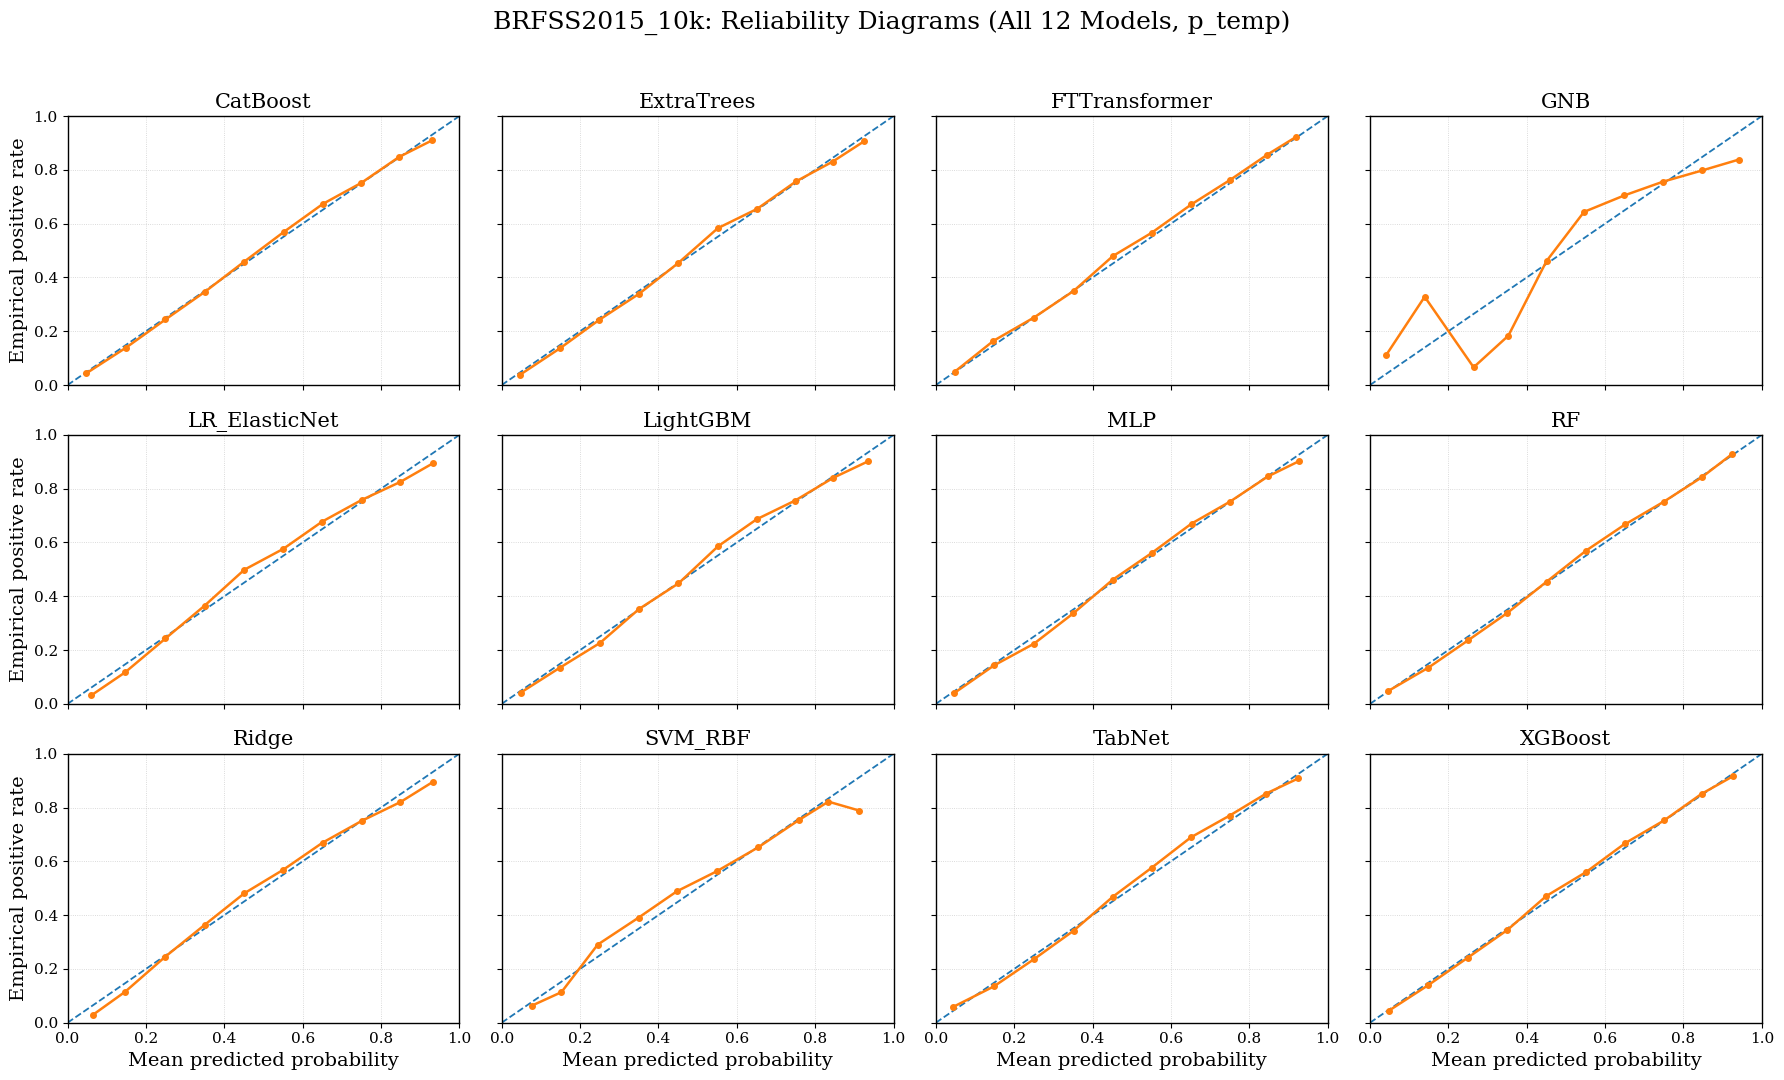

Saved:
/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/figures/fig_B1_reliability_all12_BRFSS2015_10k_p_temp_styled.png
/kaggle/working/uq_2datasets_30k/BRFSS2015_10k/figures/fig_B1_reliability_all12_BRFSS2015_10k_p_temp_styled.pdf


In [25]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# GLOBAL STYLE (scientific look)
# -----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "grid.linewidth": 0.6,
})

# -----------------------------
# CONFIG
# -----------------------------
ROOT = "/kaggle/working/uq_2datasets_30k"
DATASET = "BRFSS2015_10k"   # change to "EarlyStage"
PROB_KEY = "p_temp"         # "p_raw" | "p_temp" | "p_iso"
N_BINS = 10
SAVE_DPI = 300

MODELS_12 = [
    "CatBoost","ExtraTrees","FTTransformer","GNB",
    "LR_ElasticNet","LightGBM","MLP","RF",
    "Ridge","SVM_RBF","TabNet","XGBoost"
]

# -----------------------------
# Helpers
# -----------------------------
def load_all_folds_concat(npz_dir, prob_key="p_temp"):
    files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
    Y, P = [], []
    for f in files:
        z = np.load(f, allow_pickle=True)
        y = np.asarray(z["y_test"]).reshape(-1)
        p = np.asarray(z[prob_key]).reshape(-1)
        p = np.clip(p, 0, 1)
        Y.append(y)
        P.append(p)
    return np.concatenate(Y), np.concatenate(P)

def reliability_curve(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.digitize(p, edges) - 1
    ids = np.clip(ids, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = ids == b
        if m.sum() == 0:
            continue
        xs.append(p[m].mean())
        ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

# -----------------------------
# Plot
# -----------------------------
preds_root = os.path.join(ROOT, DATASET, "preds_npz")
out_dir = os.path.join(ROOT, DATASET, "figures")
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=True, sharey=True)
axes = axes.flatten()

for i, model in enumerate(MODELS_12):
    ax = axes[i]
    model_dir = os.path.join(preds_root, model)

    try:
        y_all, p_all = load_all_folds_concat(model_dir, prob_key=PROB_KEY)
        x, y = reliability_curve(y_all, p_all, n_bins=N_BINS)

        # Perfect calibration line
        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.3)

        # Reliability curve
        ax.plot(x, y, marker="o", linewidth=1.8, markersize=4)

        ax.set_title(model, fontsize=15, pad=6)

    except Exception as e:
        ax.set_title(f"{model} (ERR)", fontsize=14)
        ax.text(0.5, 0.5, str(e)[:80], ha="center", va="center", fontsize=8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.6)

# Outer labels only (clean look)
for ax in axes[::4]:
    ax.set_ylabel("Empirical positive rate", fontsize=14)

for ax in axes[-4:]:
    ax.set_xlabel("Mean predicted probability", fontsize=14)

fig.suptitle(
    f"{DATASET}: Reliability Diagrams (All 12 Models, {PROB_KEY})",
    fontsize=18, y=0.98
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save
png = os.path.join(out_dir, f"fig_B1_reliability_all12_{DATASET}_{PROB_KEY}_styled.png")
pdf = os.path.join(out_dir, f"fig_B1_reliability_all12_{DATASET}_{PROB_KEY}_styled.pdf")

fig.savefig(png, dpi=SAVE_DPI, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved:")
print(png)
print(pdf)

In [15]:
# ============================================================
# STEP 8: FIGURES (NO RETRAIN) — paper-grade PDF + 600dpi PNG
# Reads saved outputs from STEP 6 + STEP 7:
#   OUTROOT/<dataset>/
#     fold_level_results.csv
#     preds_npz/<model>/fold{fold}.npz  (contains y_test, p_raw/temp/iso, u_epistemic_test, conformal stats)
#
# Produces:
# F1  PR-AUC bar ± 95% CI (all 12)
# F1b ROC-AUC bar ± 95% CI (optional)
# F2  ECE bar ± 95% CI (raw/temp/iso grouped)
# F3  Reliability diagrams (grouped panels)
# F4  Risk–coverage curves (top models)
# F4b Error vs uncertainty deciles (all models)
# F5  Conformal coverage vs set size scatter (90% and 95%)
# F6  Operating point scatter (Sens vs Spec @ Sens>=0.80 threshold)
# (Optional) PR/ROC curves overlay for top models
# ============================================================

import os, math, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DPI = 600

def _ensure_dir(p):
    os.makedirs(p, exist_ok=True)
    return p

def _save_fig(fig, outpath_pdf, outpath_png):
    fig.savefig(outpath_pdf, bbox_inches="tight")
    fig.savefig(outpath_png, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

def _t95(n):
    # quick t critical for 95% with df=n-1 (small n=5); conservative if fallback.
    # values: df=4 -> 2.776
    if n <= 1: return np.nan
    if n == 2: return 12.706
    if n == 3: return 4.303
    if n == 4: return 3.182
    if n == 5: return 2.776
    if n == 6: return 2.571
    if n == 7: return 2.447
    if n == 8: return 2.365
    if n == 9: return 2.306
    if n == 10: return 2.262
    return 1.96

def mean_ci95(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan
    m = float(np.mean(x))
    if n == 1:
        return m, 0.0
    s = float(np.std(x, ddof=1))
    half = _t95(n) * s / math.sqrt(n)
    return m, float(half)

def load_fold_csv(dataset_name):
    fold_csv = os.path.join(OUTROOT, dataset_name, "fold_level_results.csv")
    assert os.path.exists(fold_csv), f"Missing: {fold_csv}. Run STEP 6+7 first."
    return pd.read_csv(fold_csv)

def load_npz(dataset_name, model, fold):
    path = os.path.join(OUTROOT, dataset_name, "preds_npz", model, f"fold{fold}.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    return np.load(path, allow_pickle=True)

def reliability_curve(y, p, n_bins=15):
    y = np.asarray(y).astype(int).reshape(-1)
    p = np.clip(np.asarray(p).reshape(-1), 1e-12, 1-1e-12)
    bins = np.linspace(0, 1, n_bins+1)
    xs, ys, ns = [], [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        m = (p >= lo) & (p < hi) if i < n_bins-1 else (p >= lo) & (p <= hi)
        if m.sum() == 0: 
            continue
        xs.append(float(p[m].mean()))
        ys.append(float(y[m].mean()))
        ns.append(int(m.sum()))
    return np.array(xs), np.array(ys), np.array(ns)

def get_top_models(df, metric="PR_AUC_temp", k=6):
    order = (df.groupby("model")[metric].mean().sort_values(ascending=False)).index.tolist()
    return order[:k]

def _read_all_test_arrays(dataset_name, model, variant="temp"):
    # Concatenate across folds for curve plots
    ys, ps, us = [], [], []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        ys.append(z["y_test"].astype(int))
        if variant == "raw":
            ps.append(z["p_raw"].astype(float))
        elif variant == "iso":
            ps.append(z["p_iso"].astype(float))
        else:
            ps.append(z["p_temp"].astype(float))
        if "u_epistemic_test" in z.files:
            us.append(z["u_epistemic_test"].astype(float))
        else:
            us.append(np.zeros_like(ys[-1], dtype=float))
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(us)

# -----------------------------
# F1: PR-AUC bar ± CI (all models)
# -----------------------------
def fig_pr_auc_bar(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique().tolist())

    means, cis = [], []
    for m in models:
        x = df.loc[df["model"]==m, "PR_AUC_temp"].values
        mu, ci = mean_ci95(x)
        means.append(mu); cis.append(ci)

    fig = plt.figure()
    ax = plt.gca()
    ax.bar(range(len(models)), means, yerr=cis, capsize=3)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel("PR-AUC (Temp calibrated) mean ± 95% CI")
    ax.set_title(f"{dataset_name}: PR-AUC (5-fold)")

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F1_pr_auc_bar.pdf"),
              os.path.join(outdir, "F1_pr_auc_bar.png"))

def fig_roc_auc_bar(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique().tolist())

    means, cis = [], []
    for m in models:
        x = df.loc[df["model"]==m, "ROC_AUC_temp"].values
        mu, ci = mean_ci95(x)
        means.append(mu); cis.append(ci)

    fig = plt.figure()
    ax = plt.gca()
    ax.bar(range(len(models)), means, yerr=cis, capsize=3)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel("ROC-AUC (Temp calibrated) mean ± 95% CI")
    ax.set_title(f"{dataset_name}: ROC-AUC (5-fold)")

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F1b_roc_auc_bar.pdf"),
              os.path.join(outdir, "F1b_roc_auc_bar.png"))

# -----------------------------
# F2: ECE bar ± CI (raw/temp/iso grouped)
# -----------------------------
def fig_ece_grouped_bar(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique().tolist())

    ece_raw = []; ece_temp = []; ece_iso = []
    ci_raw = [];  ci_temp = [];  ci_iso = []
    for m in models:
        mu, ci = mean_ci95(df.loc[df["model"]==m, "ECE_raw"].values);  ece_raw.append(mu);  ci_raw.append(ci)
        mu, ci = mean_ci95(df.loc[df["model"]==m, "ECE_temp"].values); ece_temp.append(mu); ci_temp.append(ci)
        mu, ci = mean_ci95(df.loc[df["model"]==m, "ECE_iso"].values);  ece_iso.append(mu);  ci_iso.append(ci)

    x = np.arange(len(models))
    w = 0.28

    fig = plt.figure()
    ax = plt.gca()
    ax.bar(x - w, ece_raw,  yerr=ci_raw,  width=w, capsize=2, label="Raw")
    ax.bar(x,     ece_temp, yerr=ci_temp, width=w, capsize=2, label="Temp")
    ax.bar(x + w, ece_iso,  yerr=ci_iso,  width=w, capsize=2, label="Isotonic")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel("ECE (15 bins) mean ± 95% CI")
    ax.set_title(f"{dataset_name}: Calibration Error (ECE)")
    ax.legend()

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F2_ece_grouped_bar.pdf"),
              os.path.join(outdir, "F2_ece_grouped_bar.png"))

# -----------------------------
# F3: Reliability diagrams (grouped panels)
# -----------------------------
def fig_reliability_panels(dataset_name, n_bins=15):
    df = load_fold_csv(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=6)

    # 2x3 panels
    fig = plt.figure(figsize=(12, 7))
    for i, m in enumerate(top, start=1):
        ax = fig.add_subplot(2, 3, i)
        y, p, _ = _read_all_test_arrays(dataset_name, m, variant="temp")
        xs, ys, ns = reliability_curve(y, p, n_bins=n_bins)
        ax.plot([0,1],[0,1], linestyle="--", linewidth=1)
        ax.plot(xs, ys, marker="o", linewidth=1)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(m)
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Empirical frequency")

    fig.suptitle(f"{dataset_name}: Reliability diagrams (Temp-calibrated, top-6)")
    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F3_reliability_panels_top6.pdf"),
              os.path.join(outdir, "F3_reliability_panels_top6.png"))

# -----------------------------
# F4: Risk–coverage curves (top models) using epistemic u_test
# -----------------------------
def fig_risk_coverage_top(dataset_name):
    df = load_fold_csv(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=6)

    fig = plt.figure()
    ax = plt.gca()

    for m in top:
        y, p, u = _read_all_test_arrays(dataset_name, m, variant="temp")
        cov, risk = risk_coverage_curve(y, p, u)
        ax.plot(cov, risk, linewidth=1, label=m)

    ax.set_xlabel("Coverage (fraction kept; lower uncertainty first)")
    ax.set_ylabel("Risk (error rate among kept)")
    ax.set_title(f"{dataset_name}: Risk–Coverage (epistemic UQ, top-6)")
    ax.legend()

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F4_risk_coverage_top6.pdf"),
              os.path.join(outdir, "F4_risk_coverage_top6.png"))

# -----------------------------
# F4b: Error vs uncertainty deciles (all models)
# -----------------------------
def fig_error_vs_uncertainty_deciles(dataset_name, n_deciles=10):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique().tolist())

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    dec_centers = np.arange(1, n_deciles+1)

    for m in models:
        y, p, u = _read_all_test_arrays(dataset_name, m, variant="temp")
        u = np.asarray(u).reshape(-1)
        err = (((p >= 0.5).astype(int) != y)).astype(float)

        # bin by uncertainty quantiles
        qs = np.quantile(u, np.linspace(0, 1, n_deciles+1))
        rates = []
        for i in range(n_deciles):
            lo, hi = qs[i], qs[i+1]
            mask = (u >= lo) & (u <= hi) if i == n_deciles-1 else (u >= lo) & (u < hi)
            if mask.sum() == 0:
                rates.append(np.nan)
            else:
                rates.append(float(err[mask].mean()))
        ax.plot(dec_centers, rates, marker="o", linewidth=1, label=m)

    ax.set_xlabel("Uncertainty decile (1=lowest, 10=highest)")
    ax.set_ylabel("Error rate")
    ax.set_title(f"{dataset_name}: Error rate vs uncertainty deciles (all models)")
    ax.legend(ncol=2, fontsize=8)

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F4b_error_vs_uncertainty_deciles.pdf"),
              os.path.join(outdir, "F4b_error_vs_uncertainty_deciles.png"))

# -----------------------------
# F5: Conformal coverage vs set-size scatter (90% and 95%)
# -----------------------------
def fig_conformal_scatter(dataset_name):
    df = load_fold_csv(dataset_name)

    # model means across folds
    g = df.groupby("model", as_index=False).mean(numeric_only=True)

    fig = plt.figure()
    ax = plt.gca()
    ax.scatter(g["Conf90_size"], g["Conf90_cov"], label="90%")
    ax.scatter(g["Conf95_size"], g["Conf95_cov"], label="95%")
    ax.set_xlabel("Average set size")
    ax.set_ylabel("Coverage")
    ax.set_title(f"{dataset_name}: Conformal coverage vs set-size")
    ax.legend()

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F5_conformal_scatter.pdf"),
              os.path.join(outdir, "F5_conformal_scatter.png"))

# -----------------------------
# F6: Operating point scatter (Sens vs Spec @ Sens>=0.80 threshold)
# -----------------------------
def fig_operating_scatter_s80(dataset_name):
    df = load_fold_csv(dataset_name)
    g = df.groupby("model", as_index=False).mean(numeric_only=True)

    fig = plt.figure()
    ax = plt.gca()
    ax.scatter(g["Spec_S80_temp"], g["Sens_S80_temp"])
    for _, r in g.iterrows():
        ax.annotate(r["model"], (r["Spec_S80_temp"], r["Sens_S80_temp"]), fontsize=8)

    ax.set_xlabel("Specificity (at Sens>=0.80 chosen on calib)")
    ax.set_ylabel("Sensitivity (on test)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{dataset_name}: Operating points (Sens>=0.80)")

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "F6_operating_scatter_s80.pdf"),
              os.path.join(outdir, "F6_operating_scatter_s80.png"))

# -----------------------------
# Optional: PR/ROC curves overlay (top models) — needs sklearn.metrics
# -----------------------------
from sklearn.metrics import precision_recall_curve, roc_curve

def fig_pr_curve_top(dataset_name):
    df = load_fold_csv(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=6)

    fig = plt.figure()
    ax = plt.gca()
    for m in top:
        y, p, _ = _read_all_test_arrays(dataset_name, m, variant="temp")
        prec, rec, _thr = precision_recall_curve(y, p)
        ax.plot(rec, prec, linewidth=1, label=m)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{dataset_name}: Precision–Recall curves (Temp, top-6)")
    ax.legend()

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "S1_pr_curves_top6.pdf"),
              os.path.join(outdir, "S1_pr_curves_top6.png"))

def fig_roc_curve_top(dataset_name):
    df = load_fold_csv(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=6)

    fig = plt.figure()
    ax = plt.gca()
    for m in top:
        y, p, _ = _read_all_test_arrays(dataset_name, m, variant="temp")
        fpr, tpr, _thr = roc_curve(y, p)
        ax.plot(fpr, tpr, linewidth=1, label=m)
    ax.plot([0,1],[0,1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{dataset_name}: ROC curves (Temp, top-6)")
    ax.legend()

    outdir = _ensure_dir(os.path.join(OUTROOT, dataset_name, "figures"))
    _save_fig(fig,
              os.path.join(outdir, "S2_roc_curves_top6.pdf"),
              os.path.join(outdir, "S2_roc_curves_top6.png"))

# ============================================================
# RUN FIGURES FOR BOTH DATASETS
# ============================================================
def make_all_figures(dataset_name):
    print("\nMaking figures for:", dataset_name)
    fig_pr_auc_bar(dataset_name)
    fig_roc_auc_bar(dataset_name)
    fig_ece_grouped_bar(dataset_name)
    fig_reliability_panels(dataset_name, n_bins=15)
    fig_risk_coverage_top(dataset_name)
    fig_error_vs_uncertainty_deciles(dataset_name, n_deciles=10)
    fig_conformal_scatter(dataset_name)
    fig_operating_scatter_s80(dataset_name)
    fig_pr_curve_top(dataset_name)
    fig_roc_curve_top(dataset_name)
    print("Saved to:", os.path.join(OUTROOT, dataset_name, "figures"))

make_all_figures("BRFSS2015_10k")
make_all_figures("EarlyStage")


Making figures for: BRFSS2015_10k
Saved to: /kaggle/working/uq_2datasets_30k/BRFSS2015_10k/figures

Making figures for: EarlyStage
Saved to: /kaggle/working/uq_2datasets_30k/EarlyStage/figures


In [ ]:
# ============================================================
# STEP 8B: More advanced + simple safety figures (NO RETRAIN)
# Adds:
#  S3 Confusion matrices (per model; at Sens>=0.80 threshold, leakage-free)
#  S4 ROC curves (ALL models overlay)
#  S5 High-confidence-wrong rate bar (p>=0.90), plus count of high-conf samples
#  S6 Calibration residual curve (mean(y-p) vs prob bin) + abs residual curve
#  S7 Coverage–Accuracy curve (selective prediction) using epistemic u_test (ALL models)
#  S8 Conformal set-size distribution (top models; 90% and 95%)
#  S9 Error heatmap: (uncertainty decile × probability decile) error rate (top models)
#
# All saved as PDF + 600dpi PNG to:
# OUTROOT/<dataset>/figures_advanced/
# ============================================================

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix
)

ADV_DIRNAME = "figures_advanced"

def _ensure_adv_dir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, ADV_DIRNAME)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save(fig, dataset_name, stem):
    outdir = _ensure_adv_dir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

def _load_all_models(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique().tolist())
    return df, models

def _all_test_concat(dataset_name, model):
    # Returns concatenated arrays across folds
    y, p_raw, p_temp, p_iso, u, tS80 = [], [], [], [], [], []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        y.append(z["y_test"].astype(int))
        p_raw.append(z["p_raw"].astype(float))
        p_temp.append(z["p_temp"].astype(float))
        p_iso.append(z["p_iso"].astype(float))
        u.append(z["u_epistemic_test"].astype(float) if "u_epistemic_test" in z.files else np.zeros_like(y[-1], dtype=float))
        tS80.append(float(z["tS80"]) if "tS80" in z.files else np.nan)
    return (
        np.concatenate(y),
        np.concatenate(p_raw),
        np.concatenate(p_temp),
        np.concatenate(p_iso),
        np.concatenate(u),
        np.array(tS80, dtype=float)
    )

# ============================================================
# S3: Confusion Matrix (per model) at Sens>=0.80 threshold (chosen on calib; stored per fold)
# We compute foldwise confusion matrices using each fold's stored threshold tS80,
# then sum across folds -> one final confusion matrix per model.
# ============================================================
def fig_confusion_matrices_s80(dataset_name):
    df, models = _load_all_models(dataset_name)

    for m in models:
        TN=FP=FN=TP=0
        for fold in [1,2,3,4,5]:
            z = load_npz(dataset_name, m, fold)
            y = z["y_test"].astype(int)
            p = z["p_temp"].astype(float)
            t = float(z["tS80"])
            yhat = (p >= t).astype(int)
            cm = confusion_matrix(y, yhat, labels=[0,1])
            tn, fp, fn, tp = cm.ravel()
            TN += tn; FP += fp; FN += fn; TP += tp

        cm_sum = np.array([[TN, FP],[FN, TP]], dtype=int)

        fig = plt.figure()
        ax = plt.gca()
        im = ax.imshow(cm_sum)  # no explicit colors (policy)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["Pred 0","Pred 1"])
        ax.set_yticklabels(["True 0","True 1"])
        ax.set_title(f"{dataset_name}: Confusion Matrix @ Sens>=0.80 (Temp) — {m}")

        # annotate counts
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm_sum[i,j]), ha="center", va="center")

        ax.set_xlabel("Prediction")
        ax.set_ylabel("Ground Truth")
        _save(fig, dataset_name, f"S3_confusion_matrix_S80_{m}")

# ============================================================
# S4: ROC curves overlay (ALL models) using Temp-calibrated probabilities
# ============================================================
def fig_roc_all_models_overlay(dataset_name):
    df, models = _load_all_models(dataset_name)

    fig = plt.figure()
    ax = plt.gca()

    for m in models:
        y, _, p_temp, _, _, _ = _all_test_concat(dataset_name, m)
        fpr, tpr, _ = roc_curve(y, p_temp)
        ax.plot(fpr, tpr, linewidth=1, label=m)

    ax.plot([0,1],[0,1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{dataset_name}: ROC Curves (Temp, ALL models)")
    ax.legend(ncol=2, fontsize=8)

    _save(fig, dataset_name, "S4_roc_all_models_overlay")

# ============================================================
# S5: High-confidence wrong rate (p>=0.90) bar plot (Temp)
# - uses fold_level_results.csv columns if present; else compute from NPZ
# ============================================================
def fig_high_conf_wrong_bar(dataset_name, thr=0.90):
    df, models = _load_all_models(dataset_name)

    rates, counts = [], []
    for m in models:
        y, _, p_temp, _, _, _ = _all_test_concat(dataset_name, m)
        rate, n = high_conf_wrong_rate(y, p_temp, thr=thr)
        rates.append(rate if np.isfinite(rate) else 0.0)
        counts.append(n)

    fig = plt.figure()
    ax = plt.gca()
    ax.bar(range(len(models)), rates)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel(f"High-confidence wrong rate (p ≥ {thr})")
    ax.set_title(f"{dataset_name}: High-confidence wrong (Temp)")

    # annotate counts
    for i, n in enumerate(counts):
        ax.text(i, rates[i], str(n), ha="center", va="bottom", fontsize=8)

    _save(fig, dataset_name, f"S5_high_conf_wrong_bar_p{int(thr*100)}")

# ============================================================
# S6: Calibration residual curves
# - signed residual: mean(y - p) per prob bin
# - absolute residual: mean(|y - p|) per prob bin
# ============================================================
def fig_calibration_residual_curves(dataset_name, n_bins=15):
    df, models = _load_all_models(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=6)

    def residual_curve(y, p, n_bins):
        y = np.asarray(y).astype(int).reshape(-1)
        p = np.clip(np.asarray(p).reshape(-1), 1e-12, 1-1e-12)
        bins = np.linspace(0, 1, n_bins+1)
        xc, signed, absv = [], [], []
        for i in range(n_bins):
            lo, hi = bins[i], bins[i+1]
            m = (p >= lo) & (p < hi) if i < n_bins-1 else (p >= lo) & (p <= hi)
            if m.sum() == 0:
                continue
            xc.append(float(p[m].mean()))
            r = (y[m] - p[m])
            signed.append(float(np.mean(r)))
            absv.append(float(np.mean(np.abs(r))))
        return np.array(xc), np.array(signed), np.array(absv)

    # signed residual
    fig = plt.figure()
    ax = plt.gca()
    for m in top:
        y, _, p_temp, _, _, _ = _all_test_concat(dataset_name, m)
        x, s, a = residual_curve(y, p_temp, n_bins)
        ax.plot(x, s, marker="o", linewidth=1, label=m)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("Mean predicted probability (Temp)")
    ax.set_ylabel("Mean residual (y - p)")
    ax.set_title(f"{dataset_name}: Calibration residual curve (top-6)")
    ax.legend()
    _save(fig, dataset_name, "S6a_calibration_residual_signed_top6")

    # absolute residual
    fig = plt.figure()
    ax = plt.gca()
    for m in top:
        y, _, p_temp, _, _, _ = _all_test_concat(dataset_name, m)
        x, s, a = residual_curve(y, p_temp, n_bins)
        ax.plot(x, a, marker="o", linewidth=1, label=m)
    ax.set_xlabel("Mean predicted probability (Temp)")
    ax.set_ylabel("Mean |y - p|")
    ax.set_title(f"{dataset_name}: Absolute calibration residual curve (top-6)")
    ax.legend()
    _save(fig, dataset_name, "S6b_calibration_residual_abs_top6")

# ============================================================
# S7: Coverage–Accuracy curves (ALL models) using epistemic u_test
# ============================================================
def fig_coverage_accuracy_all(dataset_name):
    df, models = _load_all_models(dataset_name)

    fig = plt.figure()
    ax = plt.gca()

    for m in models:
        y, _, p_temp, _, u, _ = _all_test_concat(dataset_name, m)
        cov, risk = risk_coverage_curve(y, p_temp, u)
        acc = 1 - risk
        ax.plot(cov, acc, linewidth=1, label=m)

    ax.set_xlabel("Coverage (fraction kept)")
    ax.set_ylabel("Accuracy among kept")
    ax.set_title(f"Coverage–Accuracy curves (Epistemic Gating)")
    ax.legend(ncol=2, fontsize=8)
    _save(fig, dataset_name, "S7_coverage_accuracy_all_models")

# ============================================================
# S8: Conformal set-size distribution (top models)
# ============================================================
def fig_conformal_set_size_distribution(dataset_name):
    df = load_fold_csv(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=6)

    for level in ["90", "95"]:
        fig = plt.figure(figsize=(10, 6))
        ax = plt.gca()

        for m in top:
            sizes = []
            for fold in [1,2,3,4,5]:
                z = load_npz(dataset_name, m, fold)
                key = f"conf{level}_size"
                sizes.append(z[key].astype(int))
            sizes = np.concatenate(sizes)

            # histogram across sizes (1 or 2 mostly)
            vals, counts = np.unique(sizes, return_counts=True)
            freq = counts / counts.sum()
            ax.plot(vals, freq, marker="o", linewidth=1, label=m)

        ax.set_xticks([1,2])
        ax.set_xlabel("Conformal set size")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{dataset_name}: Conformal set-size distribution ({level}%) top-6")
        ax.legend()
        _save(fig, dataset_name, f"S8_conformal_set_size_dist_{level}_top6")

# ============================================================
# S9: Error heatmap (uncertainty decile x probability decile) — top models
# ============================================================
def fig_error_heatmap_u_vs_p(dataset_name, k=6, n_dec=10):
    df = load_fold_csv(dataset_name)
    top = get_top_models(df, metric="PR_AUC_temp", k=k)

    for m in top:
        y, _, p_temp, _, u, _ = _all_test_concat(dataset_name, m)
        y = y.astype(int)
        err = (((p_temp >= 0.5).astype(int) != y)).astype(float)

        # deciles
        p_q = np.quantile(p_temp, np.linspace(0, 1, n_dec+1))
        u_q = np.quantile(u,      np.linspace(0, 1, n_dec+1))

        H = np.full((n_dec, n_dec), np.nan, dtype=float)
        for i in range(n_dec):
            u_lo, u_hi = u_q[i], u_q[i+1]
            u_m = (u >= u_lo) & (u <= u_hi) if i==n_dec-1 else (u >= u_lo) & (u < u_hi)
            for j in range(n_dec):
                p_lo, p_hi = p_q[j], p_q[j+1]
                p_m = (p_temp >= p_lo) & (p_temp <= p_hi) if j==n_dec-1 else (p_temp >= p_lo) & (p_temp < p_hi)
                mask = u_m & p_m
                if mask.sum() > 0:
                    H[i, j] = float(err[mask].mean())

        fig = plt.figure()
        ax = plt.gca()
        im = ax.imshow(H, aspect="auto")
        ax.set_xlabel("Probability decile (low → high)")
        ax.set_ylabel("Uncertainty decile (low → high)")
        ax.set_title(f"{dataset_name}: Error heatmap (u decile × p decile) — {m}")
        # annotate a few cells for readability (optional)
        for i in range(n_dec):
            for j in range(n_dec):
                if np.isfinite(H[i,j]) and (i in [0, n_dec-1] and j in [0, n_dec-1]):
                    ax.text(j, i, f"{H[i,j]:.2f}", ha="center", va="center", fontsize=8)
        _save(fig, dataset_name, f"S9_error_heatmap_u_vs_p_{m}")

# ============================================================
# RUN ADVANCED FIGURES FOR BOTH DATASETS
# ============================================================
def make_advanced_figures(dataset_name):
    print("\n[ADV] Making advanced figures for:", dataset_name)
    fig_confusion_matrices_s80(dataset_name)
    fig_roc_all_models_overlay(dataset_name)
    fig_high_conf_wrong_bar(dataset_name, thr=0.90)
    fig_calibration_residual_curves(dataset_name, n_bins=15)
    fig_coverage_accuracy_all(dataset_name)
    fig_conformal_set_size_distribution(dataset_name)
    fig_error_heatmap_u_vs_p(dataset_name, k=6, n_dec=10)
    print("[ADV] Saved to:", os.path.join(OUTROOT, dataset_name, ADV_DIRNAME))

make_advanced_figures("BRFSS2015_10k")
make_advanced_figures("EarlyStage")

In [22]:
# ============================================================
# STEP 8C: JOURNAL-STYLE COMPOSITE FIGURES (NO RETRAIN)
# - Multi-panel figures instead of many separate figures
# - Larger fonts for publication
# - Vector PDF + 600dpi PNG
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import roc_curve, confusion_matrix

# ---------------------------
# GLOBAL PLOT STYLE (journal)
# ---------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

def _save_journal(fig, dataset_name, stem):
    outdir = os.path.join(OUTROOT, dataset_name, "figures_journal")
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=600, bbox_inches="tight")
    plt.close(fig)

# ============================================================
# FIGURE J1 — Predictive Performance + Calibration
# Panels:
# (A) PR-AUC bar
# (B) ROC-AUC bar
# (C) ECE grouped bar
# (D) Reliability diagram (top model)
# ============================================================
def fig_J1_performance_calibration(dataset_name):

    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # --- (A) PR-AUC
    ax = axes[0,0]
    vals = [df[df.model==m]["PR_AUC_temp"].mean() for m in models]
    ax.bar(range(len(models)), vals)
    ax.set_title("(A) PR-AUC")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")

    # --- (B) ROC-AUC
    ax = axes[0,1]
    vals = [df[df.model==m]["ROC_AUC_temp"].mean() for m in models]
    ax.bar(range(len(models)), vals)
    ax.set_title("(B) ROC-AUC")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")

    # --- (C) ECE
    ax = axes[1,0]
    raw  = [df[df.model==m]["ECE_raw"].mean()  for m in models]
    temp = [df[df.model==m]["ECE_temp"].mean() for m in models]
    iso  = [df[df.model==m]["ECE_iso"].mean()  for m in models]
    x = np.arange(len(models))
    w = 0.28
    ax.bar(x-w, raw,  width=w, label="Raw")
    ax.bar(x,   temp, width=w, label="Temp")
    ax.bar(x+w, iso,  width=w, label="Iso")
    ax.set_title("(C) Calibration Error (ECE)")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.legend()

    # --- (D) Reliability (best model)
    best_model = df.groupby("model")["PR_AUC_temp"].mean().idxmax()
    y, _, p, _, _, _ = _all_test_concat(dataset_name, best_model)
    xs, ys, _ = reliability_curve(y, p)

    ax = axes[1,1]
    ax.plot([0,1],[0,1], linestyle="--")
    ax.plot(xs, ys, marker="o")
    ax.set_title(f"(D) Reliability — {best_model}")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")

    fig.suptitle(f"{dataset_name} — Predictive Performance & Calibration", fontsize=16)
    _save_journal(fig, dataset_name, "J1_performance_calibration")

# ============================================================
# FIGURE J2 — Uncertainty & Safety
# Panels:
# (A) Risk-Coverage (top models)
# (B) Coverage-Accuracy (top models)
# (C) High-confidence-wrong bar
# (D) Error vs uncertainty deciles
# ============================================================
def fig_J2_uncertainty_safety(dataset_name):

    df = load_fold_csv(dataset_name)
    top = get_top_models(df, "PR_AUC_temp", 5)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # --- (A) Risk-Coverage
    ax = axes[0,0]
    for m in top:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        cov, risk = risk_coverage_curve(y, p, u)
        ax.plot(cov, risk, label=m)
    ax.set_title("(A) Risk-Coverage")
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Risk")
    ax.legend()

    # --- (B) Coverage-Accuracy
    ax = axes[0,1]
    for m in top:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        cov, risk = risk_coverage_curve(y, p, u)
        ax.plot(cov, 1-risk, label=m)
    ax.set_title("(B) Coverage-Accuracy")
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Accuracy")

    # --- (C) High-confidence wrong
    ax = axes[1,0]
    models = sorted(df["model"].unique())
    rates = []
    for m in models:
        y, _, p, _, _, _ = _all_test_concat(dataset_name, m)
        r, _ = high_conf_wrong_rate(y, p, thr=0.90)
        rates.append(r if np.isfinite(r) else 0)
    ax.bar(range(len(models)), rates)
    ax.set_title("(C) High-confidence wrong")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")

    # --- (D) Error vs uncertainty
    ax = axes[1,1]
    for m in top:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        err = ((p>=0.5).astype(int)!=y).astype(float)
        bins = np.quantile(u, np.linspace(0,1,11))
        rates=[]
        for i in range(10):
            mask=(u>=bins[i])&(u<=bins[i+1])
            rates.append(np.mean(err[mask]) if mask.sum()>0 else np.nan)
        ax.plot(range(1,11), rates, marker="o", label=m)
    ax.set_title("(D) Error vs uncertainty")
    ax.set_xlabel("Uncertainty decile")
    ax.set_ylabel("Error rate")

    fig.suptitle(f"{dataset_name} — Uncertainty & Safety", fontsize=16)
    _save_journal(fig, dataset_name, "J2_uncertainty_safety")

# ============================================================
# FIGURE J3 — Conformal + Operating Behaviour
# Panels:
# (A) Coverage vs set-size
# (B) Set-size distribution (top models)
# (C) Sens vs Spec scatter
# (D) Confusion matrix (best model)
# ============================================================
def fig_J3_conformal_operating(dataset_name):

    df = load_fold_csv(dataset_name)
    top = get_top_models(df, "PR_AUC_temp", 5)
    best_model = df.groupby("model")["PR_AUC_temp"].mean().idxmax()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # --- (A) Coverage vs size
    ax = axes[0,0]
    g = df.groupby("model").mean(numeric_only=True)
    ax.scatter(g["Conf90_size"], g["Conf90_cov"], label="90%")
    ax.scatter(g["Conf95_size"], g["Conf95_cov"], label="95%")
    ax.set_title("(A) Conformal coverage vs size")
    ax.set_xlabel("Set size")
    ax.set_ylabel("Coverage")
    ax.legend()

    # --- (B) Set size distribution
    ax = axes[0,1]
    for m in top:
        sizes=[]
        for f in [1,2,3,4,5]:
            z=load_npz(dataset_name,m,f)
            sizes.append(z["conf90_size"])
        sizes=np.concatenate(sizes)
        vals,counts=np.unique(sizes,return_counts=True)
        ax.plot(vals,counts/counts.sum(),marker="o",label=m)
    ax.set_title("(B) Conformal set-size distribution")
    ax.set_xlabel("Set size")
    ax.set_ylabel("Frequency")

    # --- (C) Sens vs Spec
    ax = axes[1,0]
    ax.scatter(g["Spec_S80_temp"], g["Sens_S80_temp"])
    for i,m in enumerate(g.index):
        ax.annotate(m,(g["Spec_S80_temp"][i],g["Sens_S80_temp"][i]))
    ax.set_title("(C) Operating points")
    ax.set_xlabel("Specificity")
    ax.set_ylabel("Sensitivity")

    # --- (D) Confusion matrix (best model)
    TN=FP=FN=TP=0
    for f in [1,2,3,4,5]:
        z=load_npz(dataset_name,best_model,f)
        y=z["y_test"]; p=z["p_temp"]; t=z["tS80"]
        yhat=(p>=t).astype(int)
        tn,fp,fn,tp=confusion_matrix(y,yhat).ravel()
        TN+=tn;FP+=fp;FN+=fn;TP+=tp
    cm=np.array([[TN,FP],[FN,TP]])

    ax=axes[1,1]
    ax.imshow(cm)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_title(f"(D) Confusion Matrix — {best_model}")
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center")

    fig.suptitle(f"{dataset_name} — Conformal & Operating Behaviour", fontsize=16)
    _save_journal(fig, dataset_name, "J3_conformal_operating")

# ============================================================
# RUN FOR BOTH DATASETS
# ============================================================

fig_J1_performance_calibration("BRFSS2015_10k")
fig_J2_uncertainty_safety("BRFSS2015_10k")
fig_J3_conformal_operating("BRFSS2015_10k")

fig_J1_performance_calibration("EarlyStage")
fig_J2_uncertainty_safety("EarlyStage")
fig_J3_conformal_operating("EarlyStage")

print("✔ Journal-style composite figures saved.")

✔ Journal-style composite figures saved.


In [23]:
# ============================================================
# STEP 8D: TOP-JOURNAL SAFETY FIGURES (SEPARATE, NO OVERLAP)
# ------------------------------------------------------------
# Generates additional "reviewer-winning" safety figures, saved separately
# (PDF vector + 600dpi PNG) to:
#   OUTROOT/<dataset>/figures_safety_top/
#
# Figures:
#  T1  Decision Curve Analysis (DCA): top-6 + treat-all + treat-none
#  T2  Net Benefit at fixed thresholds (0.1/0.2/0.3) bar (top-6)
#  T3  Calibration drift by risk bins (deciles): mean(y) - mean(p_temp)
#  T4  High-confidence wrong vs uncertainty deciles (top-6)  [danger lens]
#  T5  Selective prediction gain: (accuracy at 90% coverage) - (full accuracy)  all models
#  T6  Uncertainty–Error monotonicity: Spearman(u, error) bar all models
#  T7  Failure landscape: error rate heatmap (probability bins × uncertainty bins) top-6
#
# Requirements:
# - STEP 6 completed (NPZ + fold csv)
# - STEP 7 completed (u_epistemic_test in NPZ)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

SAFETY_DIRNAME = "figures_safety_top"

# Bigger fonts, but keep safe (no overlap)
def set_pub_style():
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
    })

set_pub_style()

def _ensure_safety_dir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, SAFETY_DIRNAME)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_sep(fig, dataset_name, stem):
    outdir = _ensure_safety_dir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=600, bbox_inches="tight")
    plt.close(fig)

def _concat_arrays(dataset_name, model, use="temp"):
    y, p, u = [], [], []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        y.append(z["y_test"].astype(int))
        if use == "raw":
            p.append(z["p_raw"].astype(float))
        elif use == "iso":
            p.append(z["p_iso"].astype(float))
        else:
            p.append(z["p_temp"].astype(float))
        u.append(z["u_epistemic_test"].astype(float) if "u_epistemic_test" in z.files else np.zeros_like(y[-1], dtype=float))
    return np.concatenate(y), np.concatenate(p), np.concatenate(u)

def _top_models(dataset_name, k=6):
    df = load_fold_csv(dataset_name)
    return get_top_models(df, metric="PR_AUC_temp", k=k)

# ============================================================
# T1: Decision Curve Analysis (DCA)
# Net Benefit NB(t) = TP/N - FP/N * (t/(1-t))
# Use p_temp and threshold grid.
# Add treat-all and treat-none.
# ============================================================
def fig_T1_dca(dataset_name, k=6, thr_grid=None):
    if thr_grid is None:
        thr_grid = np.linspace(0.01, 0.60, 120)

    top = _top_models(dataset_name, k=k)
    y_all = None

    fig = plt.figure(figsize=(7.5, 5.5))
    ax = plt.gca()

    for m in top:
        y, p, _ = _concat_arrays(dataset_name, m, use="temp")
        if y_all is None:
            y_all = y
        N = len(y)
        nbs = []
        for t in thr_grid:
            pred = (p >= t).astype(int)
            tp = np.sum((pred==1) & (y==1))
            fp = np.sum((pred==1) & (y==0))
            w = t/(1-t)
            nb = (tp/N) - (fp/N)*w
            nbs.append(nb)
        ax.plot(thr_grid, nbs, linewidth=1.2, label=m)

    # treat-none: NB = 0
    ax.plot(thr_grid, np.zeros_like(thr_grid), linestyle="--", linewidth=1.2, label="Treat-none")

    # treat-all: everyone treated => TP = positives, FP = negatives
    # NB_all = prev - (1-prev) * t/(1-t)
    prev = float(np.mean(y_all))
    nb_all = prev - (1-prev) * (thr_grid/(1-thr_grid))
    ax.plot(thr_grid, nb_all, linestyle="--", linewidth=1.2, label="Treat-all")

    ax.set_xlabel("Threshold probability")
    ax.set_ylabel("Net benefit")
    ax.set_title(f"{dataset_name}: Decision Curve Analysis (top-{k}, Temp)")
    ax.legend(ncol=2)

    _save_sep(fig, dataset_name, "T1_dca_top_models")

# ============================================================
# T2: Net Benefit at fixed thresholds (0.1,0.2,0.3)
# Bar chart for top models.
# ============================================================
def fig_T2_net_benefit_fixed(dataset_name, k=6, thresholds=(0.1,0.2,0.3)):
    top = _top_models(dataset_name, k=k)

    fig = plt.figure(figsize=(8.5, 5.5))
    ax = plt.gca()

    x = np.arange(len(top))
    w = 0.25

    for j, t in enumerate(thresholds):
        nbs = []
        for m in top:
            y, p, _ = _concat_arrays(dataset_name, m, use="temp")
            N = len(y)
            pred = (p >= t).astype(int)
            tp = np.sum((pred==1) & (y==1))
            fp = np.sum((pred==1) & (y==0))
            wgt = t/(1-t)
            nb = (tp/N) - (fp/N)*wgt
            nbs.append(nb)
        ax.bar(x + (j-(len(thresholds)-1)/2)*w, nbs, width=w, label=f"t={t:.1f}")

    ax.set_xticks(x)
    ax.set_xticklabels(top, rotation=45, ha="right")
    ax.set_ylabel("Net benefit")
    ax.set_title(f"{dataset_name}: Net benefit at fixed thresholds (Temp)")
    ax.legend()

    _save_sep(fig, dataset_name, "T2_net_benefit_fixed_thresholds")

# ============================================================
# T3: Calibration drift by risk deciles
# For bins of p_temp, plot mean(y) - mean(p_temp)
# (positive => underconfident; negative => overconfident)
# Top models.
# ============================================================
def fig_T3_calibration_drift_by_risk(dataset_name, k=6, n_bins=10):
    top = _top_models(dataset_name, k=k)

    fig = plt.figure(figsize=(7.5, 5.5))
    ax = plt.gca()

    for m in top:
        y, p, _ = _concat_arrays(dataset_name, m, use="temp")
        # bins by predicted risk quantiles
        qs = np.quantile(p, np.linspace(0, 1, n_bins+1))
        drift = []
        centers = []
        for i in range(n_bins):
            lo, hi = qs[i], qs[i+1]
            mask = (p >= lo) & (p <= hi) if i==n_bins-1 else (p >= lo) & (p < hi)
            if mask.sum() == 0:
                drift.append(np.nan); centers.append((lo+hi)/2); continue
            centers.append(float(p[mask].mean()))
            drift.append(float(y[mask].mean() - p[mask].mean()))
        ax.plot(range(1, n_bins+1), drift, marker="o", linewidth=1.2, label=m)

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("Risk decile (by predicted p)")
    ax.set_ylabel("Calibration drift: mean(y) − mean(p)")
    ax.set_title(f"{dataset_name}: Calibration drift by risk deciles (Temp, top-{k})")
    ax.legend(ncol=2)

    _save_sep(fig, dataset_name, "T3_calibration_drift_by_risk_deciles")

# ============================================================
# T4: High-confidence wrong vs uncertainty deciles (danger lens)
# Among p_temp >= 0.90, compute wrong rate per uncertainty decile.
# Top models.
# ============================================================
def fig_T4_high_conf_wrong_vs_uncertainty(dataset_name, k=6, p_thr=0.90, n_dec=10):
    top = _top_models(dataset_name, k=k)

    fig = plt.figure(figsize=(7.5, 5.5))
    ax = plt.gca()

    for m in top:
        y, p, u = _concat_arrays(dataset_name, m, use="temp")
        mask = (p >= p_thr)
        if mask.sum() < 20:
            continue
        y2, p2, u2 = y[mask], p[mask], u[mask]
        err = ((p2 >= 0.5).astype(int) != y2).astype(float)

        qs = np.quantile(u2, np.linspace(0,1,n_dec+1))
        rates = []
        for i in range(n_dec):
            lo, hi = qs[i], qs[i+1]
            msk = (u2 >= lo) & (u2 <= hi) if i==n_dec-1 else (u2 >= lo) & (u2 < hi)
            rates.append(float(err[msk].mean()) if msk.sum()>0 else np.nan)

        ax.plot(range(1, n_dec+1), rates, marker="o", linewidth=1.2, label=m)

    ax.set_xlabel("Uncertainty decile (within high-confidence region)")
    ax.set_ylabel(f"Wrong rate among p ≥ {p_thr}")
    ax.set_title(f"{dataset_name}: High-confidence wrong vs uncertainty (Temp, top-{k})")
    ax.legend(ncol=2)

    _save_sep(fig, dataset_name, "T4_high_conf_wrong_vs_uncertainty_deciles")

# ============================================================
# T5: Selective prediction gain (ALL models)
# Gain = Acc@90%coverage - Full accuracy
# Uses epistemic u_test and p_temp threshold=0.5 for accuracy.
# ============================================================
def fig_T5_selective_gain(dataset_name, coverage=0.90):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())

    gains = []
    for m in models:
        y, p, u = _concat_arrays(dataset_name, m, use="temp")

        full_acc = float(np.mean((p >= 0.5).astype(int) == y))
        order = np.argsort(u)  # keep lowest uncertainty
        k = max(1, int(np.floor(coverage*len(y))))
        idx = order[:k]
        sel_acc = float(np.mean((p[idx] >= 0.5).astype(int) == y[idx]))
        gains.append(sel_acc - full_acc)

    fig = plt.figure(figsize=(9.5, 5.5))
    ax = plt.gca()
    ax.bar(range(len(models)), gains)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel(f"Selective gain (Acc@{int(coverage*100)}% − full Acc)")
    ax.set_title(f"{dataset_name}: Selective prediction gain (Temp + epistemic gating)")

    _save_sep(fig, dataset_name, f"T5_selective_gain_{int(coverage*100)}")

# ============================================================
# T6: Uncertainty–Error monotonicity (Spearman(u, error)) bar all models
# ============================================================
def fig_T6_spearman_u_error(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())

    vals = []
    for m in models:
        y, p, u = _concat_arrays(dataset_name, m, use="temp")
        vals.append(spearman_uncertainty_error(y, p, u))

    fig = plt.figure(figsize=(9.5, 5.5))
    ax = plt.gca()
    ax.bar(range(len(models)), vals)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel("Spearman(uncertainty, error)")
    ax.set_title(f"{dataset_name}: Uncertainty–error monotonicity (higher is better)")

    _save_sep(fig, dataset_name, "T6_spearman_uncertainty_error")

# ============================================================
# T7: Failure landscape heatmap (prob bins × uncertainty bins) top models
# heat cell = error rate
# ============================================================
def fig_T7_failure_landscape_heatmaps(dataset_name, k=6, n_bins=10):
    top = _top_models(dataset_name, k=k)

    for m in top:
        y, p, u = _concat_arrays(dataset_name, m, use="temp")
        err = (((p >= 0.5).astype(int) != y)).astype(float)

        p_q = np.quantile(p, np.linspace(0,1,n_bins+1))
        u_q = np.quantile(u, np.linspace(0,1,n_bins+1))

        H = np.full((n_bins, n_bins), np.nan, dtype=float)
        for i in range(n_bins):
            u_lo, u_hi = u_q[i], u_q[i+1]
            um = (u >= u_lo) & (u <= u_hi) if i==n_bins-1 else (u >= u_lo) & (u < u_hi)
            for j in range(n_bins):
                p_lo, p_hi = p_q[j], p_q[j+1]
                pm = (p >= p_lo) & (p <= p_hi) if j==n_bins-1 else (p >= p_lo) & (p < p_hi)
                mask = um & pm
                if mask.sum() > 0:
                    H[i,j] = float(err[mask].mean())

        fig = plt.figure(figsize=(6.5, 5.5))
        ax = plt.gca()
        ax.imshow(H, aspect="auto")
        ax.set_xlabel("Probability decile (low → high)")
        ax.set_ylabel("Uncertainty decile (low → high)")
        ax.set_title(f"{dataset_name}: Failure landscape (Temp) — {m}")
        _save_sep(fig, dataset_name, f"T7_failure_landscape_{m}")

# ============================================================
# RUN ALL TOP-JOURNAL SAFETY FIGURES
# ============================================================
def make_top_journal_safety_figures(dataset_name):
    print("\n[TOP-SAFETY] Generating for:", dataset_name)
    fig_T1_dca(dataset_name, k=6)
    fig_T2_net_benefit_fixed(dataset_name, k=6, thresholds=(0.1,0.2,0.3))
    fig_T3_calibration_drift_by_risk(dataset_name, k=6, n_bins=10)
    fig_T4_high_conf_wrong_vs_uncertainty(dataset_name, k=6, p_thr=0.90, n_dec=10)
    fig_T5_selective_gain(dataset_name, coverage=0.90)
    fig_T6_spearman_u_error(dataset_name)
    fig_T7_failure_landscape_heatmaps(dataset_name, k=6, n_bins=10)
    print("[TOP-SAFETY] Saved to:", os.path.join(OUTROOT, dataset_name, SAFETY_DIRNAME))

make_top_journal_safety_figures("BRFSS2015_10k")
make_top_journal_safety_figures("EarlyStage")


[TOP-SAFETY] Generating for: BRFSS2015_10k
[TOP-SAFETY] Saved to: /kaggle/working/outputs/BRFSS2015_10k/figures_safety_top

[TOP-SAFETY] Generating for: EarlyStage
[TOP-SAFETY] Saved to: /kaggle/working/outputs/EarlyStage/figures_safety_top


In [ ]:
# ============================================================
# STEP 8D: Top-journal SAFETY figures (separate figures, no overlap)
# NO RETRAIN. Reads STEP 6+7 artifacts.
#
# Adds high-impact safety figures:
#  TJ1  Decision Curve Analysis (DCA): top-6 + treat-all + treat-none
#  TJ2  Risk-Coverage Gain vs baseline (accuracy/risk improvement curve)
#  TJ3  High-confidence wrong vs coverage (danger profile curve)
#  TJ4  Calibration drift by risk bins (low/med/high) + residual bars
#  TJ5  Failure landscape: error rate heatmap over (prob decile x uncertainty decile) [top-6]
#  TJ6  Set size vs uncertainty (conformal 90/95) [top-6] + coverage check
#  TJ7  Expected Calibration Error decomposition plot (bin gap curve) [top-6]
#
# Output:
# OUTROOT/<dataset>/figures_top_journal/
# Each saved as PDF (vector) + PNG 600dpi
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

TOPJ_DIRNAME = "figures_top_journal"

def _ensure_topj_dir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, TOPJ_DIRNAME)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_topj(fig, dataset_name, stem):
    outdir = _ensure_topj_dir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# ---------------------------
# Helper: choose top-K by PR-AUC temp
# ---------------------------
def topk_models(dataset_name, k=6):
    df = load_fold_csv(dataset_name)
    return get_top_models(df, metric="PR_AUC_temp", k=k)

# ============================================================
# TJ1: Decision Curve Analysis (DCA)
# Net Benefit = TP/N - FP/N * (pt/(1-pt))
# Uses temp-calibrated probabilities (recommended)
# ============================================================
def fig_TJ1_dca(dataset_name, thresholds=np.linspace(0.01, 0.99, 99), k=6):
    top = topk_models(dataset_name, k=k)

    # concatenate all folds for each model (test-only)
    Y_all = {}
    P_all = {}
    for m in top:
        y, _, p, _, _, _ = _all_test_concat(dataset_name, m)
        Y_all[m] = y.astype(int)
        P_all[m] = np.clip(p.astype(float), 1e-12, 1-1e-12)

    # treat-all / treat-none
    # For treat-all: predict positive for all => TP = positives, FP = negatives
    # For treat-none: TP=FP=0 => NB=0 always
    # prevalence = mean(y)
    any_m = top[0]
    y0 = Y_all[any_m]
    N = len(y0)
    prev = float(np.mean(y0))

    nb_all = []
    nb_none = np.zeros_like(thresholds, dtype=float)

    for pt in thresholds:
        # treat-all
        TP = int(np.sum(y0 == 1))
        FP = int(np.sum(y0 == 0))
        nb = (TP / N) - (FP / N) * (pt / (1 - pt))
        nb_all.append(nb)
    nb_all = np.array(nb_all)

    fig = plt.figure()
    ax = plt.gca()

    for m in top:
        y = Y_all[m]; p = P_all[m]
        nb = []
        for pt in thresholds:
            yhat = (p >= pt).astype(int)
            TP = int(np.sum((yhat==1) & (y==1)))
            FP = int(np.sum((yhat==1) & (y==0)))
            nb.append((TP / N) - (FP / N) * (pt / (1 - pt)))
        ax.plot(thresholds, nb, linewidth=1, label=m)

    ax.plot(thresholds, nb_all, linestyle="--", linewidth=1, label="Treat-All")
    ax.plot(thresholds, nb_none, linestyle="--", linewidth=1, label="Treat-None")

    ax.set_xlabel("Threshold probability")
    ax.set_ylabel("Net Benefit")
    ax.set_title(f"{dataset_name}: Decision Curve Analysis (Temp, top-{k})")
    ax.legend()

    _save_topj(fig, dataset_name, "TJ1_dca_top_models")

# ============================================================
# TJ2: Risk-Coverage Gain vs baseline
# Baseline risk = overall error rate at 0.5
# Plot: (baseline_risk - selective_risk(c)) vs coverage
# (positive => uncertainty gating improves safety)
# ============================================================
def fig_TJ2_risk_coverage_gain(dataset_name, k=6):
    top = topk_models(dataset_name, k=k)
    fig = plt.figure()
    ax = plt.gca()

    for m in top:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        y = y.astype(int); p = p.astype(float); u = u.astype(float)

        baseline_err = float(np.mean(((p >= 0.5).astype(int) != y).astype(float)))

        cov, risk = risk_coverage_curve(y, p, u)  # risk at each coverage
        gain = baseline_err - risk
        ax.plot(cov, gain, linewidth=1, label=m)

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("Coverage (kept fraction; low-uncertainty first)")
    ax.set_ylabel("Risk gain (baseline error − selective risk)")
    ax.set_title(f"{dataset_name}: Safety gain from uncertainty gating (top-{k})")
    ax.legend()

    _save_topj(fig, dataset_name, "TJ2_risk_coverage_gain_top_models")

# ============================================================
# TJ3: High-confidence wrong vs coverage
# For each coverage c (keep lowest-uncertainty c%), compute:
#   rate of wrong among samples with p>=0.90 within the kept set
# Shows "high-confidence wrong" under selective prediction.
# ============================================================
def fig_TJ3_high_conf_wrong_vs_coverage(dataset_name, k=6, conf_thr=0.90, coverages=np.linspace(0.2, 1.0, 17)):
    top = topk_models(dataset_name, k=k)
    fig = plt.figure()
    ax = plt.gca()

    for m in top:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        y = y.astype(int); p = p.astype(float); u = u.astype(float)

        order = np.argsort(u)
        N = len(y)

        curve = []
        for c in coverages:
            kN = max(1, int(np.floor(c * N)))
            idx = order[:kN]
            yy = y[idx]
            pp = p[idx]
            mask = (pp >= conf_thr)
            if mask.sum() == 0:
                curve.append(np.nan)
            else:
                curve.append(float(np.mean(((pp[mask] >= 0.5).astype(int) != yy[mask]).astype(float))))
        ax.plot(coverages, curve, marker="o", linewidth=1, label=m)

    ax.set_xlabel("Coverage (kept fraction)")
    ax.set_ylabel(f"High-confidence wrong rate (p≥{conf_thr})")
    ax.set_title(f"{dataset_name}: High-confidence wrong under uncertainty gating (top-{k})")
    ax.legend()

    _save_topj(fig, dataset_name, f"TJ3_high_conf_wrong_vs_coverage_p{int(conf_thr*100)}")

# ============================================================
# TJ4: Calibration drift by risk bins (low/med/high)
# - Bin by predicted risk (temp): low [0,0.33), mid [0.33,0.66), high [0.66,1]
# - Plot signed residual mean(y-p) per bin for top models
# ============================================================
def fig_TJ4_calibration_drift_by_risk_bins(dataset_name, k=6):
    top = topk_models(dataset_name, k=k)
    bins = [0.0, 1/3, 2/3, 1.0]
    labels = ["Low", "Mid", "High"]

    fig = plt.figure()
    ax = plt.gca()

    x = np.arange(len(labels))
    width = 0.12
    offsets = np.linspace(-width*k/2, width*k/2, k)

    for i, m in enumerate(top):
        y, _, p, _, _, _ = _all_test_concat(dataset_name, m)
        y = y.astype(float); p = np.clip(p.astype(float), 1e-12, 1-1e-12)
        resid = y - p

        vals = []
        for b0, b1 in zip(bins[:-1], bins[1:]):
            mask = (p >= b0) & (p < b1) if b1 < 1 else (p >= b0) & (p <= b1)
            vals.append(float(np.mean(resid[mask])) if mask.sum() else np.nan)

        ax.bar(x + offsets[i], vals, width=width, label=m)

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Predicted risk bin (Temp)")
    ax.set_ylabel("Mean residual (y − p)")
    ax.set_title(f"{dataset_name}: Calibration drift by risk groups (top-{k})")
    ax.legend(ncol=2, fontsize=9)

    _save_topj(fig, dataset_name, "TJ4_calibration_drift_by_risk_bins_top_models")

# ============================================================
# TJ5: Failure landscape heatmap (prob decile x uncertainty decile) error rate
# - Separate figure per model (top-6), so it stays readable and journal-grade.
# ============================================================
def fig_TJ5_failure_landscape(dataset_name, k=6, n_dec=10):
    top = topk_models(dataset_name, k=k)

    for m in top:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        y = y.astype(int)
        p = np.clip(p.astype(float), 1e-12, 1-1e-12)
        u = u.astype(float)
        err = (((p >= 0.5).astype(int) != y)).astype(float)

        p_q = np.quantile(p, np.linspace(0, 1, n_dec+1))
        u_q = np.quantile(u, np.linspace(0, 1, n_dec+1))

        H = np.full((n_dec, n_dec), np.nan, dtype=float)
        for i in range(n_dec):
            u_lo, u_hi = u_q[i], u_q[i+1]
            u_m = (u >= u_lo) & (u <= u_hi) if i==n_dec-1 else (u >= u_lo) & (u < u_hi)
            for j in range(n_dec):
                p_lo, p_hi = p_q[j], p_q[j+1]
                p_m = (p >= p_lo) & (p <= p_hi) if j==n_dec-1 else (p >= p_lo) & (p < p_hi)
                mask = u_m & p_m
                if mask.sum() > 0:
                    H[i, j] = float(err[mask].mean())

        fig = plt.figure()
        ax = plt.gca()
        ax.imshow(H, aspect="auto")
        ax.set_xlabel("Probability decile (low→high)")
        ax.set_ylabel("Uncertainty decile (low→high)")
        ax.set_title(f"{dataset_name}: Failure landscape (error) — {m}")

        _save_topj(fig, dataset_name, f"TJ5_failure_landscape_{m}")

# ============================================================
# TJ6: Conformal set size vs uncertainty (90% and 95%) — top models
# - scatter of u_epistemic_test vs set size
# - shows if uncertainty aligns with ambiguity / abstention-like behaviour
# ============================================================
def fig_TJ6_conformal_size_vs_uncertainty(dataset_name, k=6):
    top = topk_models(dataset_name, k=k)

    for level in ["90", "95"]:
        fig = plt.figure()
        ax = plt.gca()

        for m in top:
            ys, ps, us, sizes = [], [], [], []
            for fold in [1,2,3,4,5]:
                z = load_npz(dataset_name, m, fold)
                us.append(z["u_epistemic_test"].astype(float))
                sizes.append(z[f"conf{level}_size"].astype(int))
            u = np.concatenate(us)
            s = np.concatenate(sizes)

            # jitter for readability
            sj = s + (np.random.RandomState(0).rand(len(s)) - 0.5) * 0.06
            ax.scatter(u, sj, s=8, alpha=0.6, label=m)

        ax.set_xlabel("Epistemic uncertainty (u)")
        ax.set_ylabel(f"Conformal set size ({level}%)")
        ax.set_title(f"{dataset_name}: Conformal set size vs uncertainty (top-{k})")
        ax.legend(ncol=2, fontsize=9)

        _save_topj(fig, dataset_name, f"TJ6_conformal_size_vs_uncertainty_{level}")

# ============================================================
# TJ7: ECE bin-gap curve (calibration gap vs probability)
# - For each model: plot gap = (empirical - predicted) per bin
# - separate figure with top-6 overlays
# ============================================================
def fig_TJ7_ece_gap_curve(dataset_name, k=6, n_bins=15):
    top = topk_models(dataset_name, k=k)

    fig = plt.figure()
    ax = plt.gca()

    for m in top:
        y, _, p, _, _, _ = _all_test_concat(dataset_name, m)
        y = y.astype(int)
        p = np.clip(p.astype(float), 1e-12, 1-1e-12)

        bins = np.linspace(0, 1, n_bins+1)
        xs, gap = [], []
        for i in range(n_bins):
            lo, hi = bins[i], bins[i+1]
            mask = (p >= lo) & (p < hi) if i < n_bins-1 else (p >= lo) & (p <= hi)
            if mask.sum() == 0:
                continue
            conf = float(np.mean(p[mask]))
            acc  = float(np.mean(y[mask]))
            xs.append(conf)
            gap.append(acc - conf)

        ax.plot(xs, gap, marker="o", linewidth=1, label=m)

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("Mean predicted probability (bin)")
    ax.set_ylabel("Calibration gap (observed − predicted)")
    ax.set_title(f"{dataset_name}: Calibration gap curves (Temp, top-{k})")
    ax.legend()

    _save_topj(fig, dataset_name, "TJ7_calibration_gap_curves_top_models")

# ============================================================
# MASTER: Generate all top-journal safety figures for a dataset
# ============================================================
def make_top_journal_safety_figures(dataset_name):
    print("\n[TOP-J] Generating top-journal safety figures for:", dataset_name)
    fig_TJ1_dca(dataset_name, k=6)
    fig_TJ2_risk_coverage_gain(dataset_name, k=6)
    fig_TJ3_high_conf_wrong_vs_coverage(dataset_name, k=6, conf_thr=0.90)
    fig_TJ4_calibration_drift_by_risk_bins(dataset_name, k=6)
    fig_TJ5_failure_landscape(dataset_name, k=6, n_dec=10)
    fig_TJ6_conformal_size_vs_uncertainty(dataset_name, k=6)
    fig_TJ7_ece_gap_curve(dataset_name, k=6, n_bins=15)
    print("[TOP-J] Saved to:", os.path.join(OUTROOT, dataset_name, TOPJ_DIRNAME))

# ============================================================
# RUN FOR BOTH DATASETS
# ============================================================
make_top_journal_safety_figures("BRFSS2015_10k")
make_top_journal_safety_figures("EarlyStage")

In [24]:
# ============================================================
# STEP 8E: SAFETY SCORECARD (Table + Figure) — NO RETRAIN
# Builds a journal-friendly "Safety Scorecard" per dataset:
#
# Table columns (means over 5 folds):
# - PR_AUC_temp, ROC_AUC_temp
# - ECE_temp, Brier_temp, NLL_temp
# - EpAURC, SelAcc90
# - HCWrong_p90 (high-confidence wrong rate) + HCWrong_n90 (count)
# - Conf90_cov, Conf90_size, Conf95_cov, Conf95_size
# - Sens_S80_temp, Spec_S80_temp, MCC_S80_temp, Acc_S80_temp
#
# Also computes a composite SAFETY_INDEX (0-100):
# - Normalize metrics (better is higher) via robust min-max across models
# - Weighted sum emphasizing safety:
#   25% Epistemic (EpAURC, SelAcc90, HCWrong)
#   25% Calibration (ECE, Brier, NLL)
#   25% Conformal (coverage penalty + size penalty)
#   25% Discrimination/Deployment (PR-AUC, MCC@S80, Sens/Spec balance)
#
# Output:
# OUTROOT/<dataset>/scorecard/
#   safety_scorecard.csv
#   safety_scorecard_latex.tex
#   SC1_safety_index_bar.(pdf/png)
#   SC2_scorecard_heatmap.(pdf/png)  [optional, readable for <=12 models]
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCORE_DIRNAME = "scorecard"

def _ensure_score_dir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, SCORE_DIRNAME)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_score_fig(fig, dataset_name, stem):
    outdir = _ensure_score_dir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

def _robust_minmax(x):
    x = np.asarray(x, dtype=float)
    lo = np.nanmin(x); hi = np.nanmax(x)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)

def _inv_robust_minmax(x):
    # lower is better -> invert to make higher better
    return 1.0 - _robust_minmax(x)

def _clamp01(a):
    return np.clip(a, 0.0, 1.0)

def _to_latex_booktabs(df, path, caption="Safety scorecard", label="tab:safety_scorecard"):
    # simple LaTeX exporter (booktabs)
    lines = []
    lines.append("\\begin{table*}[t]")
    lines.append("\\centering")
    lines.append("\\small")
    lines.append("\\setlength{\\tabcolsep}{6pt}")
    lines.append("\\renewcommand{\\arraystretch}{1.15}")
    lines.append("\\caption{" + caption + "}")
    lines.append("\\label{" + label + "}")
    lines.append("\\begin{tabular}{" + "l" + "c"*(df.shape[1]-1) + "}")
    lines.append("\\toprule")
    lines.append(" & ".join(df.columns) + " \\\\")
    lines.append("\\midrule")
    for _, row in df.iterrows():
        vals = []
        for v in row.values:
            vals.append(str(v))
        lines.append(" & ".join(vals) + " \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table*}")
    with open(path, "w") as f:
        f.write("\n".join(lines))

# ============================================================
# Build scorecard + compute SAFETY_INDEX
# ============================================================
def build_safety_scorecard(dataset_name):
    df = load_fold_csv(dataset_name)

    # Ensure STEP7 columns exist
    required = ["EpAURC","SelAcc90","HCWrong_p90","Conf90_cov","Conf90_size","Conf95_cov","Conf95_size"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise RuntimeError(f"Missing STEP7 columns: {missing}. Run STEP 7 first.")

    # Mean over folds per model
    g = df.groupby("model", as_index=False).mean(numeric_only=True)

    # Select columns for the table
    cols = [
        "model",
        "PR_AUC_temp","ROC_AUC_temp",
        "ECE_temp","Brier_temp","NLL_temp",
        "EpAURC","SelAcc90",
        "HCWrong_p90","HCWrong_n90",
        "Conf90_cov","Conf90_size",
        "Conf95_cov","Conf95_size",
        "Sens_S80_temp","Spec_S80_temp",
        "MCC_S80_temp","Acc_S80_temp"
    ]
    # Some cols might not exist in older runs; handle gracefully
    cols_exist = [c for c in cols if c in g.columns]
    tab = g[cols_exist].copy()

    # Round for paper
    round_map = {}
    for c in tab.columns:
        if c == "model": continue
        if "size" in c.lower() or "n90" in c.lower():
            round_map[c] = 2
        else:
            round_map[c] = 4
    for c, d in round_map.items():
        tab[c] = tab[c].astype(float).round(d)

    # --------------------------------------------------------
    # SAFETY_INDEX (0-100) — compute from unrounded g (avoid rounding artifacts)
    # --------------------------------------------------------
    # safety components (higher is better after transforms):
    # calibration:
    ece = _inv_robust_minmax(g["ECE_temp"].values)
    brier = _inv_robust_minmax(g["Brier_temp"].values)
    nll = _inv_robust_minmax(g["NLL_temp"].values)
    cal_score = _clamp01((ece + brier + nll) / 3)

    # epistemic / selective:
    # EpAURC lower is better -> invert
    epaurc = _inv_robust_minmax(g["EpAURC"].values)
    sel90 = _robust_minmax(g["SelAcc90"].values)  # higher better
    hcw = _inv_robust_minmax(g["HCWrong_p90"].values)  # lower better
    uq_score = _clamp01((epaurc + sel90 + hcw) / 3)

    # conformal:
    # coverage closer/higher than target is better, size smaller better
    # penalize under-coverage below target
    cov90 = g["Conf90_cov"].values
    cov95 = g["Conf95_cov"].values
    size90 = g["Conf90_size"].values
    size95 = g["Conf95_size"].values

    cov90_score = _clamp01(1.0 - np.maximum(0.0, (0.90 - cov90)) / 0.10)  # 1 if >=0.90 else linear down
    cov95_score = _clamp01(1.0 - np.maximum(0.0, (0.95 - cov95)) / 0.05)

    size90_score = _inv_robust_minmax(size90)
    size95_score = _inv_robust_minmax(size95)
    conf_score = _clamp01((cov90_score + cov95_score + size90_score + size95_score) / 4)

    # discrimination + deployment:
    pr = _robust_minmax(g["PR_AUC_temp"].values)
    mcc = _robust_minmax(g["MCC_S80_temp"].values) if "MCC_S80_temp" in g.columns else np.zeros(len(g))
    sens = _robust_minmax(g["Sens_S80_temp"].values) if "Sens_S80_temp" in g.columns else np.zeros(len(g))
    spec = _robust_minmax(g["Spec_S80_temp"].values) if "Spec_S80_temp" in g.columns else np.zeros(len(g))
    dep_score = _clamp01((pr + mcc + 0.5*(sens + spec)) / 3)

    # Weighted final index
    safety_index = 100.0 * _clamp01(0.25*uq_score + 0.25*cal_score + 0.25*conf_score + 0.25*dep_score)

    g_out = g[["model"]].copy()
    g_out["SAFETY_INDEX"] = safety_index

    # merge into table (rounded)
    tab = tab.merge(g_out, on="model", how="left")
    tab["SAFETY_INDEX"] = tab["SAFETY_INDEX"].round(1)

    # sort by safety index then PR-AUC
    tab = tab.sort_values(["SAFETY_INDEX","PR_AUC_temp"], ascending=[False, False]).reset_index(drop=True)

    # Save CSV + LaTeX
    outdir = _ensure_score_dir(dataset_name)
    csv_path = os.path.join(outdir, "safety_scorecard.csv")
    tex_path = os.path.join(outdir, "safety_scorecard_latex.tex")
    tab.to_csv(csv_path, index=False)

    # LaTeX: keep a slimmer view (too wide otherwise)
    slim_cols = ["model","SAFETY_INDEX","PR_AUC_temp","ECE_temp","EpAURC","SelAcc90","HCWrong_p90","Conf90_cov","Conf90_size","MCC_S80_temp"]
    slim_cols = [c for c in slim_cols if c in tab.columns]
    tab_slim = tab[slim_cols].copy()
    _to_latex_booktabs(tab_slim, tex_path,
                       caption=f"Safety scorecard (means over 5 folds) for {dataset_name}.",
                       label=f"tab:safety_{dataset_name}")

    print("Saved:", csv_path)
    print("Saved:", tex_path)
    return tab

# ============================================================
# FIGURE SC1: Safety Index bar plot (sorted)
# ============================================================
def fig_SC1_safety_index_bar(dataset_name, tab):
    models = tab["model"].tolist()
    vals = tab["SAFETY_INDEX"].astype(float).values

    fig = plt.figure(figsize=(10, 5))
    ax = plt.gca()
    ax.bar(range(len(models)), vals)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.set_ylabel("Safety Index (0–100)")
    ax.set_title(f"{dataset_name}: Safety Index ranking (composite)")
    _save_score_fig(fig, dataset_name, "SC1_safety_index_bar")

# ============================================================
# FIGURE SC2: Scorecard heatmap (normalized, higher=better)
# - journal-friendly if models <= 12 and metrics <= ~10
# ============================================================
def fig_SC2_scorecard_heatmap(dataset_name, tab):
    # choose a compact set of columns (all mapped to higher=better)
    cols = ["PR_AUC_temp","ECE_temp","EpAURC","SelAcc90","HCWrong_p90","Conf90_cov","Conf90_size","MCC_S80_temp","Sens_S80_temp","Spec_S80_temp"]
    cols = [c for c in cols if c in tab.columns]
    if len(cols) == 0:
        print("[WARN] No columns found for heatmap.")
        return

    X = tab[cols].astype(float).values.copy()

    # transform: lower-better columns invert
    lower_better = {"ECE_temp","EpAURC","HCWrong_p90","Conf90_size"}
    Z = np.zeros_like(X)

    for j, c in enumerate(cols):
        if c in lower_better:
            Z[:, j] = _inv_robust_minmax(X[:, j])
        else:
            Z[:, j] = _robust_minmax(X[:, j])

    Z = np.clip(Z, 0, 1)

    fig = plt.figure(figsize=(12, max(5, 0.35*len(tab))))
    ax = plt.gca()
    ax.imshow(Z, aspect="auto")  # no explicit colormap (policy)
    ax.set_yticks(range(len(tab)))
    ax.set_yticklabels(tab["model"].tolist())
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_title(f"{dataset_name}: Safety scorecard heatmap (normalized; higher=better)")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Model")

    # annotate values lightly (optional; keep readable)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            if (i < 12) and (j < 10):  # keep it light
                ax.text(j, i, f"{Z[i,j]:.2f}", ha="center", va="center", fontsize=8)

    _save_score_fig(fig, dataset_name, "SC2_scorecard_heatmap")

# ============================================================
# RUN SCORECARD FOR BOTH DATASETS
# ============================================================
tab_brfss = build_safety_scorecard("BRFSS2015_10k")
fig_SC1_safety_index_bar("BRFSS2015_10k", tab_brfss)
fig_SC2_scorecard_heatmap("BRFSS2015_10k", tab_brfss)

tab_esd = build_safety_scorecard("EarlyStage")
fig_SC1_safety_index_bar("EarlyStage", tab_esd)
fig_SC2_scorecard_heatmap("EarlyStage", tab_esd)

print("✔ Safety scorecard tables + figures saved in each dataset's /scorecard/ folder.")

Saved: /kaggle/working/outputs/BRFSS2015_10k/scorecard/safety_scorecard.csv
Saved: /kaggle/working/outputs/BRFSS2015_10k/scorecard/safety_scorecard_latex.tex
Saved: /kaggle/working/outputs/EarlyStage/scorecard/safety_scorecard.csv
Saved: /kaggle/working/outputs/EarlyStage/scorecard/safety_scorecard_latex.tex
✔ Safety scorecard tables + figures saved in each dataset's /scorecard/ folder.


In [25]:
# ============================================================
# STEP 8F: PARETO FRONT (journal-friendly) — NO RETRAIN
# Goal: show the "accuracy–calibration–safety" trade-off.
#
# We build Pareto fronts under:
#   maximize PR_AUC_temp
#   minimize ECE_temp
#   minimize EpAURC
#
# Outputs per dataset (saved to /scorecard/):
#  PF1_pareto_pr_vs_ece.pdf/png        (points + Pareto front; marker size ~ EpAURC)
#  PF2_pareto_pr_vs_epaurc.pdf/png     (points + Pareto front; marker size ~ ECE)
#  PF3_pareto_ece_vs_epaurc.pdf/png    (points + Pareto front; marker size ~ PR)
#
# Notes:
# - Uses mean-over-folds metrics from fold_level_results.csv
# - No retraining
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pareto_front_indices(pr, ece, epaurc):
    """
    Non-dominated points under:
      maximize pr
      minimize ece
      minimize epaurc
    i dominates j if:
      pr_i >= pr_j and ece_i <= ece_j and epaurc_i <= epaurc_j
      and at least one strict inequality.
    Returns boolean mask for Pareto-optimal points.
    """
    pr = np.asarray(pr, dtype=float)
    ece = np.asarray(ece, dtype=float)
    epa = np.asarray(epaurc, dtype=float)
    n = len(pr)
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_pareto[i]:
            continue
        # check if any j dominates i
        for j in range(n):
            if i == j:
                continue
            cond = (pr[j] >= pr[i]) and (ece[j] <= ece[i]) and (epa[j] <= epa[i])
            strict = (pr[j] > pr[i]) or (ece[j] < ece[i]) or (epa[j] < epa[i])
            if cond and strict:
                is_pareto[i] = False
                break
    return is_pareto

def _size_from_metric(x, min_size=40, max_size=220, invert=False):
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(x, nan=np.nanmedian(x))
    lo, hi = np.min(x), np.max(x)
    if hi - lo < 1e-12:
        return np.full_like(x, (min_size + max_size) / 2, dtype=float)
    z = (x - lo) / (hi - lo)
    if invert:
        z = 1.0 - z
    return min_size + z * (max_size - min_size)

def _save_pf(fig, dataset_name, stem):
    outdir = os.path.join(OUTROOT, dataset_name, "scorecard")
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

def build_mean_metrics_table(dataset_name):
    df = load_fold_csv(dataset_name)

    need = ["PR_AUC_temp", "ECE_temp", "EpAURC"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise RuntimeError(f"Missing columns {miss}. Run STEP 7 first for EpAURC.")

    g = df.groupby("model", as_index=False).mean(numeric_only=True)
    keep = ["model", "PR_AUC_temp", "ROC_AUC_temp", "ECE_temp", "Brier_temp", "NLL_temp",
            "EpAURC", "SelAcc90", "HCWrong_p90", "Conf90_cov", "Conf90_size"]
    keep = [c for c in keep if c in g.columns]
    return g[keep].copy()

def plot_pf_pr_vs_ece(dataset_name):
    tab = build_mean_metrics_table(dataset_name)
    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values
    models = tab["model"].tolist()

    pareto = pareto_front_indices(pr, ece, epa)

    # marker size: lower EpAURC is better -> invert (bigger = safer)
    sizes = _size_from_metric(epa, invert=True)

    fig = plt.figure(figsize=(8, 6))
    ax = plt.gca()

    ax.scatter(ece, pr, s=sizes, alpha=0.85)
    for i, m in enumerate(models):
        ax.annotate(m, (ece[i], pr[i]), fontsize=9, xytext=(3, 3), textcoords="offset points")

    # Pareto front "curve" in this 2D view:
    # keep pareto points, sort by ECE ascending (since ECE minimized)
    ece_p = ece[pareto]
    pr_p  = pr[pareto]
    order = np.argsort(ece_p)
    ax.plot(ece_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("ECE (Temp) ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Pareto view (PR-AUC vs ECE)\n(marker size ∝ safety: lower EpAURC)")
    _save_pf(fig, dataset_name, "PF1_pareto_pr_vs_ece")

def plot_pf_pr_vs_epaurc(dataset_name):
    tab = build_mean_metrics_table(dataset_name)
    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values
    models = tab["model"].tolist()

    pareto = pareto_front_indices(pr, ece, epa)

    # marker size: lower ECE is better -> invert (bigger = better-calibrated)
    sizes = _size_from_metric(ece, invert=True)

    fig = plt.figure(figsize=(8, 6))
    ax = plt.gca()

    ax.scatter(epa, pr, s=sizes, alpha=0.85)
    for i, m in enumerate(models):
        ax.annotate(m, (epa[i], pr[i]), fontsize=9, xytext=(3, 3), textcoords="offset points")

    # Pareto line in this 2D view: sort by EpAURC ascending
    epa_p = epa[pareto]
    pr_p  = pr[pareto]
    order = np.argsort(epa_p)
    ax.plot(epa_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("EpAURC ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Pareto view (PR-AUC vs EpAURC)\n(marker size ∝ calibration: lower ECE)")
    _save_pf(fig, dataset_name, "PF2_pareto_pr_vs_epaurc")

def plot_pf_ece_vs_epaurc(dataset_name):
    tab = build_mean_metrics_table(dataset_name)
    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values
    models = tab["model"].tolist()

    pareto = pareto_front_indices(pr, ece, epa)

    # marker size: higher PR is better (bigger = better discrimination)
    sizes = _size_from_metric(pr, invert=False)

    fig = plt.figure(figsize=(8, 6))
    ax = plt.gca()

    ax.scatter(epa, ece, s=sizes, alpha=0.85)
    for i, m in enumerate(models):
        ax.annotate(m, (epa[i], ece[i]), fontsize=9, xytext=(3, 3), textcoords="offset points")

    # Pareto line in this 2D view: sort by EpAURC ascending
    epa_p = epa[pareto]
    ece_p = ece[pareto]
    order = np.argsort(epa_p)
    ax.plot(epa_p[order], ece_p[order], linewidth=1)

    ax.set_xlabel("EpAURC ↓")
    ax.set_ylabel("ECE (Temp) ↓")
    ax.set_title(f"{dataset_name}: Pareto view (ECE vs EpAURC)\n(marker size ∝ PR-AUC)")
    _save_pf(fig, dataset_name, "PF3_pareto_ece_vs_epaurc")

def make_pareto_figures(dataset_name):
    print("\n[PARETO] Generating Pareto figures for:", dataset_name)
    plot_pf_pr_vs_ece(dataset_name)
    plot_pf_pr_vs_epaurc(dataset_name)
    plot_pf_ece_vs_epaurc(dataset_name)
    print("[PARETO] Saved to:", os.path.join(OUTROOT, dataset_name, "scorecard"))

# ------------------------------------------------------------
# RUN FOR BOTH DATASETS
# ------------------------------------------------------------
make_pareto_figures("BRFSS2015_10k")
make_pareto_figures("EarlyStage")


[PARETO] Generating Pareto figures for: BRFSS2015_10k
[PARETO] Saved to: /kaggle/working/outputs/BRFSS2015_10k/scorecard

[PARETO] Generating Pareto figures for: EarlyStage
[PARETO] Saved to: /kaggle/working/outputs/EarlyStage/scorecard


In [26]:
# ============================================================
# STEP 8G: Readable Pareto plots + Uncertainty-gating Pareto (NO RETRAIN)
# Fixes label overlap using:
#  - label only Pareto points (default)
#  - optional adjustText repel (recommended)
#
# Adds: Pareto with uncertainty gating @ 90% coverage:
#   PR-AUC vs EpAURC  (before)  -->  PR-AUC@90cov vs partial-EpAURC@90cov (after)
# ============================================================

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score

# ---------- Optional: better label layout ----------
# Kaggle: install if missing
try:
    from adjustText import adjust_text
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "adjustText"])
    from adjustText import adjust_text

# ---------- plot style ----------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

def _pf_outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, "scorecard")
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_pf(fig, dataset_name, stem):
    outdir = _pf_outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

def pareto_mask_3d(pr, ece, epa):
    """Pareto under maximize pr, minimize ece, minimize epa."""
    pr = np.asarray(pr, float); ece = np.asarray(ece, float); epa = np.asarray(epa, float)
    n = len(pr)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]: 
            continue
        for j in range(n):
            if i == j: 
                continue
            dom = (pr[j] >= pr[i]) and (ece[j] <= ece[i]) and (epa[j] <= epa[i])
            strict = (pr[j] > pr[i]) or (ece[j] < ece[i]) or (epa[j] < epa[i])
            if dom and strict:
                keep[i] = False
                break
    return keep

def _marker_sizes(x, invert=False, smin=60, smax=260):
    x = np.asarray(x, float)
    x = np.nan_to_num(x, nan=np.nanmedian(x))
    lo, hi = np.min(x), np.max(x)
    if hi - lo < 1e-12:
        return np.full_like(x, (smin+smax)/2, dtype=float)
    z = (x - lo) / (hi - lo)
    if invert:
        z = 1 - z
    return smin + z*(smax-smin)

def mean_metrics_table(dataset_name):
    df = load_fold_csv(dataset_name)
    need = ["PR_AUC_temp","ECE_temp","EpAURC"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise RuntimeError(f"Missing columns {miss}. Run STEP 7 first.")
    g = df.groupby("model", as_index=False).mean(numeric_only=True)
    return g

# ============================================================
# A) READABLE Pareto: PR-AUC vs ECE (label only Pareto points)
# marker size ∝ safety (lower EpAURC => bigger)
# ============================================================
def pareto_pr_vs_ece_readable(dataset_name, label_mode="pareto"):
    tab = mean_metrics_table(dataset_name)
    models = tab["model"].tolist()
    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values

    pareto = pareto_mask_3d(pr, ece, epa)
    sizes = _marker_sizes(epa, invert=True)

    fig = plt.figure(figsize=(9, 6))
    ax = plt.gca()

    ax.scatter(ece, pr, s=sizes, alpha=0.85)

    # connect Pareto in ECE-sorted order (nice visual)
    ece_p = ece[pareto]; pr_p = pr[pareto]
    order = np.argsort(ece_p)
    ax.plot(ece_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("ECE (Temp) ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Pareto view (PR-AUC vs ECE)\n(marker size ∝ safety: lower EpAURC)")

    # label management
    texts = []
    if label_mode == "all":
        idxs = np.arange(len(models))
    elif label_mode == "top6":
        # top by PR-AUC
        idxs = np.argsort(-pr)[:6]
    else:
        # default: Pareto only
        idxs = np.where(pareto)[0]

    for i in idxs:
        texts.append(ax.text(ece[i], pr[i], models[i], fontsize=11))

    # repel labels
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.6),
        expand_text=(1.2, 1.4),
        expand_points=(1.3, 1.5),
        force_text=(0.6, 0.8),
        force_points=(0.2, 0.3),
    )

    ax.grid(True, alpha=0.2)
    _save_pf(fig, dataset_name, "PF1_pr_vs_ece_readable")

# ============================================================
# B) READABLE Pareto: PR-AUC vs EpAURC (label only Pareto points)
# marker size ∝ calibration (lower ECE => bigger)
# ============================================================
def pareto_pr_vs_epaurc_readable(dataset_name, label_mode="pareto"):
    tab = mean_metrics_table(dataset_name)
    models = tab["model"].tolist()
    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values

    pareto = pareto_mask_3d(pr, ece, epa)
    sizes = _marker_sizes(ece, invert=True)

    fig = plt.figure(figsize=(9, 6))
    ax = plt.gca()
    ax.scatter(epa, pr, s=sizes, alpha=0.85)

    # connect Pareto in EpAURC-sorted order
    epa_p = epa[pareto]; pr_p = pr[pareto]
    order = np.argsort(epa_p)
    ax.plot(epa_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("EpAURC ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Pareto view (PR-AUC vs EpAURC)\n(marker size ∝ calibration: lower ECE)")

    texts = []
    if label_mode == "all":
        idxs = np.arange(len(models))
    elif label_mode == "top6":
        idxs = np.argsort(-pr)[:6]
    else:
        idxs = np.where(pareto)[0]

    for i in idxs:
        texts.append(ax.text(epa[i], pr[i], models[i], fontsize=11))

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.6),
        expand_text=(1.2, 1.4),
        expand_points=(1.3, 1.5),
        force_text=(0.6, 0.8),
        force_points=(0.2, 0.3),
    )

    ax.grid(True, alpha=0.2)
    _save_pf(fig, dataset_name, "PF2_pr_vs_epaurc_readable")

# ============================================================
# C) Uncertainty-gating Pareto @ 90% coverage (TOP-JOURNAL)
# For each model:
#   BEFORE:  (EpAURC_full, PR_AUC_full)
#   AFTER:   (partial_EpAURC_up_to_0.90, PR_AUC_on_kept90)
# Show arrows before -> after
# ============================================================
def partial_epaurc_at_cov(y, p, u, cov_target=0.90):
    # Compute risk-coverage curve then integrate risk over coverage [0, cov_target]
    y = y.astype(int)
    p = p.astype(float)
    u = u.astype(float)

    order = np.argsort(u)
    y = y[order]; p = p[order]

    # risk at each coverage point
    N = len(y)
    ks = np.arange(1, N+1)
    cov = ks / N
    err = ((p >= 0.5).astype(int) != y).astype(float)
    # cumulative risk among kept
    cum_err = np.cumsum(err)
    risk = cum_err / ks

    # restrict up to cov_target
    m = cov <= cov_target
    cov2 = cov[m]
    risk2 = risk[m]
    if len(cov2) < 2:
        return float(np.mean(err)), float(cov_target)

    # integrate risk over cov (trapezoid)
    aurc_part = float(np.trapz(risk2, cov2))
    return aurc_part

def pr_auc_at_cov(y, p, u, cov_target=0.90):
    order = np.argsort(u)
    N = len(y)
    k = int(np.floor(cov_target * N))
    k = max(10, k)  # stability
    idx = order[:k]
    return float(average_precision_score(y[idx].astype(int), np.clip(p[idx], 1e-12, 1-1e-12)))

def fig_pareto_gating_before_after(dataset_name, cov_target=0.90, label_mode="pareto"):
    tab = mean_metrics_table(dataset_name)
    models = tab["model"].tolist()

    # "before" from fold-level means (stable)
    pr_before = tab["PR_AUC_temp"].values.astype(float)
    epa_before = tab["EpAURC"].values.astype(float)

    # "after" computed from pooled test predictions (kept cov_target)
    pr_after = []
    epa_after = []

    # also compute ECE_before for marker sizes (optional)
    ece = tab["ECE_temp"].values.astype(float)
    sizes = _marker_sizes(ece, invert=True)  # better calibration => bigger

    for m in models:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        y = y.astype(int); p = p.astype(float); u = u.astype(float)
        pr_after.append(pr_auc_at_cov(y, p, u, cov_target=cov_target))
        epa_after.append(partial_epaurc_at_cov(y, p, u, cov_target=cov_target))

    pr_after = np.array(pr_after, float)
    epa_after = np.array(epa_after, float)

    # Pareto based on BEFORE triplet (pr, ece, epa) to decide labels
    pareto = pareto_mask_3d(pr_before, ece, epa_before)

    fig = plt.figure(figsize=(9.5, 6.5))
    ax = plt.gca()

    # BEFORE points
    ax.scatter(epa_before, pr_before, s=sizes, alpha=0.75, label="Before (full)")

    # AFTER points
    ax.scatter(epa_after, pr_after, s=sizes, alpha=0.75, label=f"After (keep {int(cov_target*100)}% lowest-u)")

    # arrows
    for i in range(len(models)):
        ax.annotate(
            "", xy=(epa_after[i], pr_after[i]), xytext=(epa_before[i], pr_before[i]),
            arrowprops=dict(arrowstyle="->", lw=0.8)
        )

    ax.set_xlabel("EpAURC ↓  (after: partial AURC up to 90% coverage)")
    ax.set_ylabel("PR-AUC ↑  (after: PR-AUC on kept 90%)")
    ax.set_title(f"{dataset_name}: Safety–performance shift under uncertainty gating (90% coverage)\n(marker size ∝ calibration: lower ECE)")

    # label management: label Pareto-before by default
    texts = []
    if label_mode == "all":
        idxs = np.arange(len(models))
    elif label_mode == "top6":
        idxs = np.argsort(-pr_before)[:6]
    else:
        idxs = np.where(pareto)[0]

    # label both before and after with same name, but attach to AFTER (cleaner)
    for i in idxs:
        texts.append(ax.text(epa_after[i], pr_after[i], models[i], fontsize=11))

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.6),
        expand_text=(1.2, 1.4),
        expand_points=(1.3, 1.5),
        force_text=(0.6, 0.8),
        force_points=(0.2, 0.3),
    )

    ax.legend()
    ax.grid(True, alpha=0.2)
    _save_pf(fig, dataset_name, "PF4_pareto_gating_before_after_90cov")

# ============================================================
# RUN for both datasets
# label_mode options: "pareto" (recommended), "top6", "all"
# ============================================================
for dname in ["BRFSS2015_10k", "EarlyStage"]:
    pareto_pr_vs_ece_readable(dname, label_mode="pareto")
    pareto_pr_vs_epaurc_readable(dname, label_mode="pareto")
    fig_pareto_gating_before_after(dname, cov_target=0.90, label_mode="pareto")

print("✔ Saved readable Pareto + gating Pareto in each dataset's /scorecard/ folder.")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


✔ Saved readable Pareto + gating Pareto in each dataset's /scorecard/ folder.


In [27]:
# ============================================================
# STEP 8H: NUMBERED PARETO PLOTS (journal-clean, NO LABEL OVERLAP)
# - Replaces text labels with numbered markers (1..N)
# - Adds a separate legend table figure mapping ID -> model
# - Also supports the gating Pareto (before->after arrows) with numbered IDs
#
# Outputs (per dataset, saved to /scorecard/):
#  NP1_pr_vs_ece_numbered.pdf/png
#  NP2_pr_vs_epaurc_numbered.pdf/png
#  NP3_gating_90cov_numbered.pdf/png
#  NP_legend_table.pdf/png
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

def _outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, "scorecard")
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save(fig, dataset_name, stem):
    outdir = _outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

def _marker_sizes(x, invert=False, smin=60, smax=260):
    x = np.asarray(x, float)
    x = np.nan_to_num(x, nan=np.nanmedian(x))
    lo, hi = np.min(x), np.max(x)
    if hi - lo < 1e-12:
        return np.full_like(x, (smin+smax)/2, dtype=float)
    z = (x - lo) / (hi - lo)
    if invert:
        z = 1 - z
    return smin + z*(smax-smin)

def pareto_mask_3d(pr, ece, epa):
    pr = np.asarray(pr, float); ece = np.asarray(ece, float); epa = np.asarray(epa, float)
    n = len(pr)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]: 
            continue
        for j in range(n):
            if i == j:
                continue
            dom = (pr[j] >= pr[i]) and (ece[j] <= ece[i]) and (epa[j] <= epa[i])
            strict = (pr[j] > pr[i]) or (ece[j] < ece[i]) or (epa[j] < epa[i])
            if dom and strict:
                keep[i] = False
                break
    return keep

def mean_metrics_table(dataset_name):
    df = load_fold_csv(dataset_name)
    need = ["PR_AUC_temp","ECE_temp","EpAURC"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise RuntimeError(f"Missing columns {miss}. Run STEP 7 first.")
    g = df.groupby("model", as_index=False).mean(numeric_only=True)
    return g

def build_model_id_map(dataset_name, sort_by="PR_AUC_temp"):
    """
    Deterministic numbering:
    - sort_by metric descending (default PR_AUC_temp)
    - assign IDs 1..N
    """
    tab = mean_metrics_table(dataset_name).copy()
    tab = tab.sort_values(sort_by, ascending=False).reset_index(drop=True)
    tab["ID"] = np.arange(1, len(tab)+1)
    # mapping
    id_to_model = {int(r.ID): r.model for _, r in tab.iterrows()}
    model_to_id = {r.model: int(r.ID) for _, r in tab.iterrows()}
    return tab, id_to_model, model_to_id

def draw_numbered_points(ax, x, y, ids, sizes=None, alpha=0.85):
    ax.scatter(x, y, s=sizes if sizes is not None else 120, alpha=alpha)
    for xi, yi, lab in zip(x, y, ids):
        ax.text(xi, yi, str(lab), ha="center", va="center", fontsize=10, fontweight="bold")

# ============================================================
# Legend table figure: ID -> Model (and optionally key metrics)
# ============================================================
def fig_numbered_legend_table(dataset_name, tab_ids, cols=None):
    if cols is None:
        cols = ["ID", "model", "PR_AUC_temp", "ECE_temp", "EpAURC", "SAFETY_INDEX"]
    cols = [c for c in cols if c in tab_ids.columns]
    t = tab_ids[cols].copy()

    # pretty rounding
    for c in t.columns:
        if c in ["ID","model"]:
            continue
        t[c] = t[c].astype(float).round(4)

    fig = plt.figure(figsize=(10, max(4, 0.35*len(t))))
    ax = plt.gca()
    ax.axis("off")

    cell_text = t.values.tolist()
    col_labels = t.columns.tolist()

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
        colLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.3)

    ax.set_title(f"{dataset_name}: Numbered model legend", pad=20)
    _save(fig, dataset_name, "NP_legend_table")

# ============================================================
# NP1: PR-AUC vs ECE (numbered)
# marker size ∝ safety (lower EpAURC => bigger)
# Connect Pareto front (based on 3D dominance)
# ============================================================
def fig_NP1_pr_vs_ece_numbered(dataset_name):
    tab = mean_metrics_table(dataset_name)
    tab_ids, id_to_model, model_to_id = build_model_id_map(dataset_name, sort_by="PR_AUC_temp")

    # align in same order as tab_ids (for deterministic IDs)
    tab = tab.set_index("model").loc[tab_ids["model"]].reset_index()

    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values
    ids = tab_ids["ID"].values

    pareto = pareto_mask_3d(pr, ece, epa)
    sizes = _marker_sizes(epa, invert=True)

    fig = plt.figure(figsize=(9, 6))
    ax = plt.gca()

    draw_numbered_points(ax, ece, pr, ids, sizes=sizes)

    # Pareto front line (ECE sorted)
    ece_p = ece[pareto]; pr_p = pr[pareto]
    order = np.argsort(ece_p)
    ax.plot(ece_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("ECE (Temp) ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Pareto (PR-AUC vs ECE)\nNumbers map to models (see legend table).")
    ax.grid(True, alpha=0.2)

    _save(fig, dataset_name, "NP1_pr_vs_ece_numbered")
    return tab_ids

# ============================================================
# NP2: PR-AUC vs EpAURC (numbered)
# marker size ∝ calibration (lower ECE => bigger)
# ============================================================
def fig_NP2_pr_vs_epaurc_numbered(dataset_name):
    tab = mean_metrics_table(dataset_name)
    tab_ids, _, _ = build_model_id_map(dataset_name, sort_by="PR_AUC_temp")
    tab = tab.set_index("model").loc[tab_ids["model"]].reset_index()

    pr = tab["PR_AUC_temp"].values
    ece = tab["ECE_temp"].values
    epa = tab["EpAURC"].values
    ids = tab_ids["ID"].values

    pareto = pareto_mask_3d(pr, ece, epa)
    sizes = _marker_sizes(ece, invert=True)

    fig = plt.figure(figsize=(9, 6))
    ax = plt.gca()

    draw_numbered_points(ax, epa, pr, ids, sizes=sizes)

    # Pareto front line (EpAURC sorted)
    epa_p = epa[pareto]; pr_p = pr[pareto]
    order = np.argsort(epa_p)
    ax.plot(epa_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("EpAURC ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Pareto (PR-AUC vs EpAURC)\nNumbers map to models (see legend table).")
    ax.grid(True, alpha=0.2)

    _save(fig, dataset_name, "NP2_pr_vs_epaurc_numbered")

# ============================================================
# Gating utilities (same as before, no retrain)
# AFTER: keep lowest-uncertainty 90% of samples
#  - PR-AUC computed on kept subset
#  - partial EpAURC integrates risk(c) from c=0..0.90
# ============================================================
def partial_epaurc_at_cov(y, p, u, cov_target=0.90):
    y = y.astype(int); p = p.astype(float); u = u.astype(float)
    order = np.argsort(u)
    y = y[order]; p = p[order]
    N = len(y)

    ks = np.arange(1, N+1)
    cov = ks / N
    err = ((p >= 0.5).astype(int) != y).astype(float)
    cum_err = np.cumsum(err)
    risk = cum_err / ks

    m = cov <= cov_target
    cov2 = cov[m]; risk2 = risk[m]
    if len(cov2) < 2:
        return float(np.mean(err))
    return float(np.trapz(risk2, cov2))

def pr_auc_at_cov(y, p, u, cov_target=0.90):
    y = y.astype(int); p = np.clip(p.astype(float), 1e-12, 1-1e-12); u = u.astype(float)
    order = np.argsort(u)
    N = len(y)
    k = max(10, int(np.floor(cov_target * N)))
    idx = order[:k]
    return float(average_precision_score(y[idx], p[idx]))

# ============================================================
# NP3: Gating Pareto (before->after) numbered
# BEFORE: (EpAURC_full, PR_full)
# AFTER:  (partial EpAURC up to 0.90, PR on kept 0.90)
# marker size ∝ calibration (lower ECE => bigger)
# ============================================================
def fig_NP3_gating_numbered(dataset_name, cov_target=0.90):
    tab = mean_metrics_table(dataset_name)
    tab_ids, _, _ = build_model_id_map(dataset_name, sort_by="PR_AUC_temp")
    tab = tab.set_index("model").loc[tab_ids["model"]].reset_index()

    models = tab["model"].tolist()
    ids = tab_ids["ID"].values

    pr_before = tab["PR_AUC_temp"].values.astype(float)
    epa_before = tab["EpAURC"].values.astype(float)
    ece = tab["ECE_temp"].values.astype(float)
    sizes = _marker_sizes(ece, invert=True)

    pr_after = []
    epa_after = []
    for m in models:
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)
        pr_after.append(pr_auc_at_cov(y, p, u, cov_target=cov_target))
        epa_after.append(partial_epaurc_at_cov(y, p, u, cov_target=cov_target))

    pr_after = np.array(pr_after, float)
    epa_after = np.array(epa_after, float)

    fig = plt.figure(figsize=(9.5, 6.5))
    ax = plt.gca()

    # before and after
    ax.scatter(epa_before, pr_before, s=sizes, alpha=0.70)
    ax.scatter(epa_after, pr_after, s=sizes, alpha=0.70)

    # numbered markers on AFTER (clean)
    for i in range(len(ids)):
        ax.text(epa_after[i], pr_after[i], str(ids[i]), ha="center", va="center",
                fontsize=10, fontweight="bold")

    # arrows
    for i in range(len(ids)):
        ax.annotate(
            "", xy=(epa_after[i], pr_after[i]), xytext=(epa_before[i], pr_before[i]),
            arrowprops=dict(arrowstyle="->", lw=0.8)
        )

    ax.set_xlabel("EpAURC ↓ (after: partial AURC up to 90% cov)")
    ax.set_ylabel("PR-AUC ↑ (after: PR-AUC on kept 90%)")
    ax.set_title(f"{dataset_name}: Before→After shift under uncertainty gating (90% coverage)\nNumbers map to models (see legend table).")
    ax.grid(True, alpha=0.2)

    _save(fig, dataset_name, "NP3_gating_90cov_numbered")

# ============================================================
# RUN all numbered Pareto plots + legend table
# ============================================================
def make_numbered_pareto_plots(dataset_name):
    print("\n[NUMBERED PARETO] Generating for:", dataset_name)

    # Ensure safety index exists (from STEP 8E). If not, build it quickly.
    # We'll merge SAFETY_INDEX if available.
    tab_ids, _, _ = build_model_id_map(dataset_name, sort_by="PR_AUC_temp")

    # Merge SAFETY_INDEX if scorecard csv exists
    score_csv = os.path.join(OUTROOT, dataset_name, "scorecard", "safety_scorecard.csv")
    if os.path.exists(score_csv):
        sc = pd.read_csv(score_csv)
        tab_ids = tab_ids.merge(sc[["model","SAFETY_INDEX"]], on="model", how="left")

    # Plots
    tab_ids_used = fig_NP1_pr_vs_ece_numbered(dataset_name)
    fig_NP2_pr_vs_epaurc_numbered(dataset_name)
    fig_NP3_gating_numbered(dataset_name, cov_target=0.90)

    # Legend table
    # refresh tab_ids (same ordering)
    tab_ids = tab_ids.set_index("model").loc[tab_ids_used["model"]].reset_index()
    fig_numbered_legend_table(dataset_name, tab_ids)

    print("Saved in:", _outdir(dataset_name))

for dname in ["BRFSS2015_10k", "EarlyStage"]:
    make_numbered_pareto_plots(dname)

print("✔ Numbered Pareto plots + legend tables created.")


[NUMBERED PARETO] Generating for: BRFSS2015_10k
Saved in: /kaggle/working/outputs/BRFSS2015_10k/scorecard

[NUMBERED PARETO] Generating for: EarlyStage
Saved in: /kaggle/working/outputs/EarlyStage/scorecard
✔ Numbered Pareto plots + legend tables created.


In [28]:
# ============================================================
# STEP 8I: "All-model" figures (NO RETRAIN)
# 1) Confusion matrices: 12 panels (4 cols x 3 rows)
# 2) ROC curves overlay (all models)
# 3) PR curves overlay (all models)
# 4) Metric bar plots (all models) for many metrics
#
# Saves to:
# OUTROOT/<dataset>/figures_all_models/
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

ALLFIG_DIR = "figures_all_models"

def _allfig_outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, ALLFIG_DIR)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_allfig(fig, dataset_name, stem):
    outdir = _allfig_outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# ------------------------------------------------------------
# Helper: pooled test arrays for a model from saved npz
# Expected keys per fold npz:
#   y_test, p_temp, p_raw (optional), u_epistemic_test (optional),
#   tS80 (scalar) OR tS80 per fold
# ------------------------------------------------------------
def pooled_from_npz(dataset_name, model, use_prob="p_temp"):
    Ys, Ps, Ts = [], [], []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        y = z["y_test"].astype(int)
        p = z[use_prob].astype(float)
        # threshold saved as scalar or 1-length
        if "tS80" in z:
            t = float(np.array(z["tS80"]).reshape(-1)[0])
        elif "tS80_fold" in z:
            t = float(np.array(z["tS80_fold"]).reshape(-1)[0])
        else:
            # fallback: if not stored, use 0.5
            t = 0.5
        Ys.append(y); Ps.append(p); Ts.append(t)
    return np.concatenate(Ys), np.concatenate(Ps), np.array(Ts, dtype=float)

def pooled_u_from_npz(dataset_name, model):
    Us = []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        if "u_epistemic_test" in z:
            Us.append(z["u_epistemic_test"].astype(float))
        else:
            # fallback if not present
            Us.append(np.zeros(len(z["y_test"]), dtype=float))
    return np.concatenate(Us)

# ------------------------------------------------------------
# 1) Confusion matrices in one figure (4 cols x 3 rows)
# Uses each fold's leakage-safe tS80; we apply fold-wise.
# Aggregates confusion across folds.
# ------------------------------------------------------------
def fig_confusion_matrices_grid(dataset_name, models, ncols=4, nrows=3, use_prob="p_temp"):
    assert len(models) == ncols*nrows, "Need exactly 12 models for 4x3 grid."

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.7*nrows))
    axes = np.asarray(axes).reshape(nrows, ncols)

    for i, m in enumerate(models):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]

        # aggregate fold-wise confusion using that fold's threshold
        TN=FP=FN=TP=0
        for fold in [1,2,3,4,5]:
            z = load_npz(dataset_name, m, fold)
            y = z["y_test"].astype(int)
            p = z[use_prob].astype(float)
            if "tS80" in z:
                t = float(np.array(z["tS80"]).reshape(-1)[0])
            else:
                t = 0.5
            yhat = (p >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
            TN+=tn; FP+=fp; FN+=fn; TP+=tp

        cm = np.array([[TN, FP],
                       [FN, TP]], dtype=int)

        ax.imshow(cm)
        ax.set_title(m, fontsize=14)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["Pred 0","Pred 1"])
        ax.set_yticklabels(["True 0","True 1"])

        # annotate
        for rr in range(2):
            for cc in range(2):
                ax.text(cc, rr, str(cm[rr,cc]), ha="center", va="center", fontsize=13)

    fig.suptitle(f"{dataset_name}: Confusion matrices (Sens=0.80 threshold, leakage-safe)", fontsize=18)
    plt.tight_layout()
    _save_allfig(fig, dataset_name, "CM_grid_4x3")

# ------------------------------------------------------------
# 2) ROC overlay of ALL models (single figure)
# ------------------------------------------------------------
def fig_roc_all_models(dataset_name, models, use_prob="p_temp"):
    fig = plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()

    for m in models:
        y, p, _ = pooled_from_npz(dataset_name, m, use_prob=use_prob)
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, linewidth=1, label=m)

    ax.plot([0,1],[0,1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{dataset_name}: ROC curves (all models, Temp probs)")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, alpha=0.2)

    _save_allfig(fig, dataset_name, "ROC_all_models")

# ------------------------------------------------------------
# 3) PR overlay of ALL models (single figure)
# ------------------------------------------------------------
def fig_pr_all_models(dataset_name, models, use_prob="p_temp"):
    fig = plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()

    for m in models:
        y, p, _ = pooled_from_npz(dataset_name, m, use_prob=use_prob)
        prec, rec, _ = precision_recall_curve(y, p)
        ax.plot(rec, prec, linewidth=1, label=m)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{dataset_name}: Precision–Recall curves (all models, Temp probs)")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, alpha=0.2)

    _save_allfig(fig, dataset_name, "PR_all_models")

# ------------------------------------------------------------
# 4) Metric bar figures for ALL models (clean separate figures)
# Pulls from fold-level CSV means (already leakage-safe)
# ------------------------------------------------------------
def metric_barplot_from_foldcsv(dataset_name, metric_col, title, ylabel=None):
    df = load_fold_csv(dataset_name)
    g = df.groupby("model")[metric_col].mean().sort_values(ascending=False)

    fig = plt.figure(figsize=(10, 5))
    ax = plt.gca()
    ax.bar(range(len(g)), g.values)
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(g.index.tolist(), rotation=45, ha="right")
    ax.set_title(f"{dataset_name}: {title}")
    ax.set_ylabel(ylabel if ylabel is not None else metric_col)
    ax.grid(True, axis="y", alpha=0.2)
    _save_allfig(fig, dataset_name, f"BAR_{metric_col}")

def generate_all_metric_figures(dataset_name):
    # Discrimination
    metric_barplot_from_foldcsv(dataset_name, "PR_AUC_temp", "PR-AUC (Temp)", "PR-AUC")
    metric_barplot_from_foldcsv(dataset_name, "ROC_AUC_temp", "ROC-AUC (Temp)", "ROC-AUC")

    # Calibration
    metric_barplot_from_foldcsv(dataset_name, "ECE_temp", "ECE (Temp)", "ECE")
    metric_barplot_from_foldcsv(dataset_name, "Brier_temp", "Brier (Temp)", "Brier")
    metric_barplot_from_foldcsv(dataset_name, "NLL_temp", "NLL (Temp)", "NLL")

    # Deployment metrics (Sens=0.80 operating point)
    if "MCC_S80_temp" in load_fold_csv(dataset_name).columns:
        metric_barplot_from_foldcsv(dataset_name, "MCC_S80_temp", "MCC @ Sens=0.80", "MCC")
    if "Acc_S80_temp" in load_fold_csv(dataset_name).columns:
        metric_barplot_from_foldcsv(dataset_name, "Acc_S80_temp", "Accuracy @ Sens=0.80", "Accuracy")
    if "Spec_S80_temp" in load_fold_csv(dataset_name).columns:
        metric_barplot_from_foldcsv(dataset_name, "Spec_S80_temp", "Specificity @ Sens=0.80", "Specificity")

    # Uncertainty (STEP 7)
    df = load_fold_csv(dataset_name)
    if "EpAURC" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "EpAURC", "EpAURC (lower is better)", "EpAURC")
    if "SelAcc90" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "SelAcc90", "Selective Accuracy @ 90% coverage", "SelAcc@90")
    if "HCWrong_p90" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "HCWrong_p90", "High-confidence wrong rate (p≥0.90)", "Rate")

    # Conformal
    if "Conf90_cov" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "Conf90_cov", "Conformal coverage @ 90%", "Coverage")
    if "Conf90_size" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "Conf90_size", "Conformal set size @ 90%", "Set size")
    if "Conf95_cov" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "Conf95_cov", "Conformal coverage @ 95%", "Coverage")
    if "Conf95_size" in df.columns:
        metric_barplot_from_foldcsv(dataset_name, "Conf95_size", "Conformal set size @ 95%", "Set size")

# ------------------------------------------------------------
# MASTER runner for a dataset
# ------------------------------------------------------------
def make_all_model_figures(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())
    assert len(models) == 12, f"Expected 12 models, got {len(models)}: {models}"

    print("\n[ALL-MODEL FIGS] Dataset:", dataset_name)
    print("Saving to:", _allfig_outdir(dataset_name))

    fig_confusion_matrices_grid(dataset_name, models, ncols=4, nrows=3, use_prob="p_temp")
    fig_roc_all_models(dataset_name, models, use_prob="p_temp")
    fig_pr_all_models(dataset_name, models, use_prob="p_temp")
    generate_all_metric_figures(dataset_name)

    print("[ALL-MODEL FIGS] Done.")

# ============================================================
# RUN BOTH DATASETS
# ============================================================
make_all_model_figures("BRFSS2015_10k")
make_all_model_figures("EarlyStage")


[ALL-MODEL FIGS] Dataset: BRFSS2015_10k
Saving to: /kaggle/working/outputs/BRFSS2015_10k/figures_all_models
[ALL-MODEL FIGS] Done.

[ALL-MODEL FIGS] Dataset: EarlyStage
Saving to: /kaggle/working/outputs/EarlyStage/figures_all_models
[ALL-MODEL FIGS] Done.


In [30]:
print("BRFSS class distribution:")
print(pd.Series(y_brfss).value_counts())
print("Positive rate:", y_brfss.mean())

BRFSS class distribution:
1    5000
0    5000
Name: count, dtype: int64
Positive rate: 0.5


In [31]:
# ============================================================
# STEP 8J: Threshold tradeoff + Multi-threshold confusion matrices (TOP-JOURNAL)
# NO RETRAIN. Uses saved per-fold artifacts (.npz).
#
# What you get (per dataset):
# 1) Confusion matrices at 3 operating points, in ONE figure:
#    - t=0.50 (default)
#    - tJ (Youden-J, chosen on calibration_sub)
#    - tS80 (Sens≥0.80, chosen on calibration_sub)  <-- your current
#
# Layout: 12 models × 3 thresholds (rows = models, cols = thresholds)
#   -> Very strong "decision policy changes errors" figure for paper.
#
# 2) Threshold sweep tradeoff curves (pooled test across folds):
#    - Sensitivity vs threshold
#    - Specificity vs threshold
#    - Precision vs threshold
#    - FPR vs TPR ROC operating curve (already have ROC)
#    - Positive Prediction Rate (PPR) vs threshold (shows "predict all positive")
#
# 3) A single "FP vs FN" curve per model (optional) + top-6 overlay
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

THFIG_DIR = "figures_threshold_tradeoff"

def _th_outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, THFIG_DIR)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_th(fig, dataset_name, stem):
    outdir = _th_outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# ------------------------------------------------------------
# We rely on saved fold artifacts:
# Expect each fold npz to contain:
#   y_test, p_temp, tS80, tJ
# If tJ not saved, we compute it from calibration stored arrays if present.
# ------------------------------------------------------------

def _get_fold_thresholds(z):
    # tS80
    tS80 = float(np.array(z["tS80"]).reshape(-1)[0]) if "tS80" in z else 0.5
    # tJ
    if "tJ" in z:
        tJ = float(np.array(z["tJ"]).reshape(-1)[0])
    else:
        tJ = None
    return tS80, tJ

def _youdens_j_threshold_np(y_true, p1):
    # same logic as your Step3
    p1 = np.asarray(p1, float)
    y_true = np.asarray(y_true, int)
    thr = np.unique(np.round(p1, 6))
    best_t, best_j = 0.5, -1e9
    for t in thr:
        yhat = (p1 >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        j = sens + spec - 1
        if j > best_j:
            best_j = j
            best_t = float(t)
    return best_t

def pooled_confusion_for_threshold(dataset_name, model, threshold_mode):
    """
    threshold_mode:
      "0.5" -> fixed 0.5
      "tJ"  -> fold-wise tJ (computed if missing)
      "tS80"-> fold-wise tS80
    Returns aggregated cm over all 5 folds: [[TN,FP],[FN,TP]]
    """
    TN=FP=FN=TP=0
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        y = z["y_test"].astype(int)
        p = z["p_temp"].astype(float)

        if threshold_mode == "0.5":
            t = 0.5
        elif threshold_mode == "tS80":
            t = float(np.array(z["tS80"]).reshape(-1)[0]) if "tS80" in z else 0.5
        elif threshold_mode == "tJ":
            tS80, tJ = _get_fold_thresholds(z)
            if tJ is None:
                # compute tJ from calibration fold probs if present, else fallback 0.5
                if ("y_cal" in z) and ("p_cal_temp" in z):
                    t = _youdens_j_threshold_np(z["y_cal"].astype(int), z["p_cal_temp"].astype(float))
                else:
                    t = 0.5
            else:
                t = tJ
        else:
            raise ValueError("unknown threshold_mode")

        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
        TN+=tn; FP+=fp; FN+=fn; TP+=tp

    return np.array([[TN, FP],[FN, TP]], dtype=int)

def fig_confusion_grid_3thresholds(dataset_name, models):
    """
    Rows = models (12)
    Cols = thresholds (3)
    Each cell = confusion matrix heatmap
    """
    thr_modes = ["0.5", "tJ", "tS80"]
    thr_titles = ["t=0.50", "Youden-J (calib)", "Sens≥0.80 (calib)"]

    nrows = len(models)
    ncols = len(thr_modes)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 2.6*nrows))
    axes = np.asarray(axes)

    for r, m in enumerate(models):
        for c, (mode, ctitle) in enumerate(zip(thr_modes, thr_titles)):
            ax = axes[r, c]
            cm = pooled_confusion_for_threshold(dataset_name, m, mode)

            ax.imshow(cm)
            if r == 0:
                ax.set_title(ctitle, fontsize=14)
            if c == 0:
                ax.set_ylabel(m, fontsize=12)

            ax.set_xticks([0,1]); ax.set_yticks([0,1])
            ax.set_xticklabels(["Pred0","Pred1"])
            ax.set_yticklabels(["True0","True1"])

            for rr in range(2):
                for cc in range(2):
                    ax.text(cc, rr, str(cm[rr,cc]), ha="center", va="center", fontsize=10)

    fig.suptitle(f"{dataset_name}: Confusion matrices under 3 operating points (pooled outer-test)", fontsize=18)
    plt.tight_layout()
    _save_th(fig, dataset_name, "CM_12x3_thresholds")

# ------------------------------------------------------------
# Threshold sweep curves (pooled test across folds)
# ------------------------------------------------------------
def _metrics_at_threshold(y, p, t):
    y = y.astype(int)
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()

    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    prec = tp / (tp + fp + 1e-12)
    fpr  = fp / (fp + tn + 1e-12)
    ppr  = (yhat == 1).mean()  # positive prediction rate
    fnr  = fn / (fn + tp + 1e-12)
    return sens, spec, prec, fpr, ppr, fnr, fp, fn

def fig_threshold_tradeoff_curves(dataset_name, models, topk=6):
    """
    Creates:
      - Sens/Spec/Prec vs threshold (top-k models by PR_AUC_temp_mean)
      - PPR vs threshold (top-k)
      - FP vs FN curve (top-k)
    """
    # choose top-k based on fold summary (temp PR)
    df = load_fold_csv(dataset_name)
    rank = df.groupby("model")["PR_AUC_temp"].mean().sort_values(ascending=False)
    top_models = rank.index.tolist()[:topk]

    # thresholds grid
    TGRID = np.linspace(0.0, 1.0, 201)

    # 1) Sens/Spec/Prec vs threshold
    fig = plt.figure(figsize=(9.5, 6.5))
    ax = plt.gca()
    for m in top_models:
        y, p, _ = pooled_from_npz(dataset_name, m, use_prob="p_temp")
        sens = []; spec = []; prec = []
        for t in TGRID:
            s, sp, pr, *_ = _metrics_at_threshold(y, p, t)
            sens.append(s); spec.append(sp); prec.append(pr)

        ax.plot(TGRID, sens, linewidth=1, label=f"{m} Sens")
        ax.plot(TGRID, spec, linewidth=1, linestyle="--", label=f"{m} Spec")
        ax.plot(TGRID, prec, linewidth=1, linestyle=":", label=f"{m} Prec")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.set_title(f"{dataset_name}: Threshold tradeoffs (top {topk}) — Sens/Spec/Prec")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=2, fontsize=9)
    _save_th(fig, dataset_name, f"TH1_tradeoff_sens_spec_prec_top{topk}")

    # 2) Positive prediction rate (PPR) vs threshold
    fig = plt.figure(figsize=(9.0, 6.0))
    ax = plt.gca()
    for m in top_models:
        y, p, _ = pooled_from_npz(dataset_name, m, use_prob="p_temp")
        ppr = []
        for t in TGRID:
            *_, ppr_t, _, _, _ = _metrics_at_threshold(y, p, t)
            ppr.append(ppr_t)
        ax.plot(TGRID, ppr, linewidth=1, label=m)

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Positive Prediction Rate (P(ŷ=1))")
    ax.set_title(f"{dataset_name}: How threshold drives false positives (top {topk})")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=2, fontsize=10)
    _save_th(fig, dataset_name, f"TH2_ppr_vs_threshold_top{topk}")

    # 3) FP vs FN curve (shows the cost tradeoff)
    fig = plt.figure(figsize=(8.0, 6.0))
    ax = plt.gca()
    for m in top_models:
        y, p, _ = pooled_from_npz(dataset_name, m, use_prob="p_temp")
        FP = []; FN = []
        for t in TGRID:
            *_, fp, fn = _metrics_at_threshold(y, p, t)
            FP.append(fp); FN.append(fn)
        ax.plot(FP, FN, linewidth=1, label=m)

    ax.set_xlabel("False Positives (FP)")
    ax.set_ylabel("False Negatives (FN)")
    ax.set_title(f"{dataset_name}: FP–FN tradeoff across thresholds (top {topk})")
    ax.grid(True, alpha=0.2)
    ax.legend()
    _save_th(fig, dataset_name, f"TH3_fp_vs_fn_top{topk}")

# ------------------------------------------------------------
# MASTER: run for dataset
# ------------------------------------------------------------
def make_threshold_tradeoff_package(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())
    assert len(models) == 12, f"Expected 12 models, got {len(models)}"

    print("\n[THRESHOLD PACKAGE] Dataset:", dataset_name)
    print("Saving to:", _th_outdir(dataset_name))

    fig_confusion_grid_3thresholds(dataset_name, models)
    fig_threshold_tradeoff_curves(dataset_name, models, topk=6)

    print("[THRESHOLD PACKAGE] Done.")

# ============================================================
# RUN BOTH DATASETS
# ============================================================
make_threshold_tradeoff_package("BRFSS2015_10k")
make_threshold_tradeoff_package("EarlyStage")

print("✔ Saved threshold-tradeoff figures.")


[THRESHOLD PACKAGE] Dataset: BRFSS2015_10k
Saving to: /kaggle/working/outputs/BRFSS2015_10k/figures_threshold_tradeoff
[THRESHOLD PACKAGE] Done.

[THRESHOLD PACKAGE] Dataset: EarlyStage
Saving to: /kaggle/working/outputs/EarlyStage/figures_threshold_tradeoff
[THRESHOLD PACKAGE] Done.
✔ Saved threshold-tradeoff figures.


In [32]:
# ============================================================
# STEP 8K: Cost Curves (medical decision safety) + Standard-threshold CM
# NO RETRAIN.
#
# Adds:
# 1) Confusion matrices at STANDARD threshold t=0.50 (12 panels, 4x3)
# 2) Medical cost curves:
#    - Expected cost vs threshold for different FP:FN cost ratios
#    - "Optimal threshold under cost ratio" markers
#
# Why this is strong for journals:
# - Shows that "Sens=0.80" is one operating policy
# - Shows an economically/clinically grounded policy via cost ratios
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

COSTFIG_DIR = "figures_cost_curves"

def _cost_outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, COSTFIG_DIR)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_cost(fig, dataset_name, stem):
    outdir = _cost_outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# ------------------------------------------------------------
# A) Standard threshold confusion matrix grid (t=0.50), 4x3
# Uses pooled outer-test across folds, t=0.50 for every fold.
# ------------------------------------------------------------
def fig_confusion_standard_threshold_grid(dataset_name, models, ncols=4, nrows=3, use_prob="p_temp", t=0.5):
    assert len(models) == ncols*nrows, "Need exactly 12 models for 4x3 grid."

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.7*nrows))
    axes = np.asarray(axes).reshape(nrows, ncols)

    for i, m in enumerate(models):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]

        TN=FP=FN=TP=0
        for fold in [1,2,3,4,5]:
            z = load_npz(dataset_name, m, fold)
            y = z["y_test"].astype(int)
            p = z[use_prob].astype(float)
            yhat = (p >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
            TN+=tn; FP+=fp; FN+=fn; TP+=tp

        cm = np.array([[TN, FP],
                       [FN, TP]], dtype=int)

        ax.imshow(cm)
        ax.set_title(m, fontsize=14)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["Pred 0","Pred 1"])
        ax.set_yticklabels(["True 0","True 1"])

        for rr in range(2):
            for cc in range(2):
                ax.text(cc, rr, str(cm[rr,cc]), ha="center", va="center", fontsize=13)

    fig.suptitle(f"{dataset_name}: Confusion matrices (STANDARD threshold t=0.50, pooled outer-test)", fontsize=18)
    plt.tight_layout()
    _save_cost(fig, dataset_name, "CM_grid_4x3_standard_t0p50")

# ------------------------------------------------------------
# B) Expected cost curves
# Expected cost per sample: C = c_fp*FP_rate + c_fn*FN_rate
# We'll plot cost vs threshold for different (c_fn / c_fp) ratios.
# Typical medical screening: FN >> FP (e.g., 5x, 10x, 20x)
# ------------------------------------------------------------
def _rates_at_threshold(y, p, t):
    y = y.astype(int)
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    N = tn + fp + fn + tp + 1e-12
    fp_rate = fp / N
    fn_rate = fn / N
    return fp_rate, fn_rate, fp, fn

def fig_cost_curves_for_model(dataset_name, model, ratios=(1, 2, 5, 10, 20), use_prob="p_temp"):
    # pooled outer-test
    y, p, _ = pooled_from_npz(dataset_name, model, use_prob=use_prob)

    TGRID = np.linspace(0.0, 1.0, 301)

    fig = plt.figure(figsize=(9.0, 6.2))
    ax = plt.gca()

    # cost_fp fixed at 1, cost_fn = ratio
    best_points = []  # (ratio, best_t, best_cost)
    for r in ratios:
        costs = []
        for t in TGRID:
            fp_rate, fn_rate, _, _ = _rates_at_threshold(y, p, t)
            cost = 1.0 * fp_rate + float(r) * fn_rate
            costs.append(cost)
        costs = np.array(costs, float)
        j = int(np.argmin(costs))
        best_points.append((r, float(TGRID[j]), float(costs[j])))
        ax.plot(TGRID, costs, linewidth=1, label=f"cFN:cFP = {r}:1")

        # mark optimum
        ax.scatter([TGRID[j]], [costs[j]], s=30)

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected cost per sample")
    ax.set_title(f"{dataset_name}: Cost curves vs threshold — {model}\n(cost = FP_rate + ratio·FN_rate)")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=2, fontsize=10)

    _save_cost(fig, dataset_name, f"COST1_cost_curve_{model}")

    # Save best thresholds table
    outdir = _cost_outdir(dataset_name)
    df_best = pd.DataFrame(best_points, columns=["cFN_over_cFP", "best_threshold", "best_cost"])
    df_best.to_csv(os.path.join(outdir, f"COST1_best_thresholds_{model}.csv"), index=False)

def fig_cost_curve_top_models_overlay(dataset_name, topk=6, ratio=10, use_prob="p_temp"):
    """
    Overlay expected cost curves for top-k models at a fixed cost ratio.
    """
    df = load_fold_csv(dataset_name)
    rank = df.groupby("model")["PR_AUC_temp"].mean().sort_values(ascending=False)
    top_models = rank.index.tolist()[:topk]

    TGRID = np.linspace(0.0, 1.0, 301)

    fig = plt.figure(figsize=(9.0, 6.2))
    ax = plt.gca()

    best_rows = []
    for m in top_models:
        y, p, _ = pooled_from_npz(dataset_name, m, use_prob=use_prob)
        costs = []
        for t in TGRID:
            fp_rate, fn_rate, fp, fn = _rates_at_threshold(y, p, t)
            cost = 1.0 * fp_rate + float(ratio) * fn_rate
            costs.append(cost)
        costs = np.array(costs, float)
        j = int(np.argmin(costs))
        ax.plot(TGRID, costs, linewidth=1, label=m)
        ax.scatter([TGRID[j]], [costs[j]], s=30)
        best_rows.append((m, ratio, float(TGRID[j]), float(costs[j])))

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected cost per sample")
    ax.set_title(f"{dataset_name}: Cost curves (top {topk}, fixed cFN:cFP={ratio}:1)")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=2, fontsize=10)

    _save_cost(fig, dataset_name, f"COST2_overlay_top{topk}_ratio{ratio}")

    outdir = _cost_outdir(dataset_name)
    pd.DataFrame(best_rows, columns=["model","cFN_over_cFP","best_threshold","best_cost"]).to_csv(
        os.path.join(outdir, f"COST2_best_thresholds_top{topk}_ratio{ratio}.csv"),
        index=False
    )

# ------------------------------------------------------------
# MASTER runner
# ------------------------------------------------------------
def make_cost_curve_package(dataset_name, use_prob="p_temp"):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())
    assert len(models) == 12, f"Expected 12 models, got {len(models)}"

    print("\n[COST PACKAGE] Dataset:", dataset_name)
    print("Saving to:", _cost_outdir(dataset_name))

    # Standard threshold CM grid
    fig_confusion_standard_threshold_grid(dataset_name, models, ncols=4, nrows=3, use_prob=use_prob, t=0.5)

    # Cost curves for top-3 models (to keep runtime modest)
    top3 = df.groupby("model")["PR_AUC_temp"].mean().sort_values(ascending=False).index.tolist()[:3]
    for m in top3:
        fig_cost_curves_for_model(dataset_name, m, ratios=(1,2,5,10,20), use_prob=use_prob)

    # Overlay: top-6 models at ratio 10:1
    fig_cost_curve_top_models_overlay(dataset_name, topk=6, ratio=10, use_prob=use_prob)

    print("[COST PACKAGE] Done.")

# ============================================================
# RUN BOTH DATASETS
# ============================================================
make_cost_curve_package("BRFSS2015_10k", use_prob="p_temp")
make_cost_curve_package("EarlyStage", use_prob="p_temp")

print("✔ Saved standard-threshold CM + cost curves.")


[COST PACKAGE] Dataset: BRFSS2015_10k
Saving to: /kaggle/working/outputs/BRFSS2015_10k/figures_cost_curves
[COST PACKAGE] Done.

[COST PACKAGE] Dataset: EarlyStage
Saving to: /kaggle/working/outputs/EarlyStage/figures_cost_curves
[COST PACKAGE] Done.
✔ Saved standard-threshold CM + cost curves.


In [34]:
# ============================================================
# STEP 8L: Journal-quality visualization upgrade
# - Decision Region Heatmap (Optimal threshold vs cost ratio)
# - Improved confusion matrix styling (medical palette)
# - Large, publication-ready fonts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ------------------------------------------------------------
# GLOBAL FONT + STYLE (journal quality)
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 22,
})

CONF_CMAP = "Blues"   # professional medical palette

# ------------------------------------------------------------
# A) Improved Confusion Matrix Grid (Standard threshold t=0.5)
# ------------------------------------------------------------
def fig_confusion_standard_threshold_grid_journal(dataset_name, models, t=0.5):

    fig, axes = plt.subplots(3, 4, figsize=(18, 13))
    axes = axes.flatten()

    for i, m in enumerate(models):
        TN=FP=FN=TP=0

        for fold in [1,2,3,4,5]:
            z = load_npz(dataset_name, m, fold)
            y = z["y_test"].astype(int)
            p = z["p_temp"]
            yhat = (p >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
            TN+=tn; FP+=fp; FN+=fn; TP+=tp

        cm = np.array([[TN, FP],[FN, TP]])

        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt="d",
                    cmap=CONF_CMAP, cbar=False,
                    annot_kws={"size":16, "weight":"bold"},
                    ax=ax)

        ax.set_title(m, fontsize=18, weight="bold")
        ax.set_xlabel("Predicted", fontsize=16)
        ax.set_ylabel("True", fontsize=16)
        ax.set_xticklabels(["0","1"], fontsize=14)
        ax.set_yticklabels(["0","1"], fontsize=14, rotation=0)

    plt.suptitle(f"{dataset_name}: Confusion Matrices (Standard threshold = 0.50)",
                 fontsize=22, weight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTROOT, dataset_name, "CM_journal_standard.pdf"),
                bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# B) Decision Region Heatmap (Optimal Threshold vs Cost Ratio)
# ------------------------------------------------------------
def fig_decision_region_heatmap(dataset_name, model, use_prob="p_temp"):

    y, p, _ = pooled_from_npz(dataset_name, model, use_prob=use_prob)

    TGRID = np.linspace(0.01, 0.99, 200)
    RATIOS = np.linspace(1, 30, 120)

    heat = np.zeros((len(RATIOS), len(TGRID)))

    for i, r in enumerate(RATIOS):
        best_t = 0.5
        best_cost = 1e9

        for j, t in enumerate(TGRID):
            yhat = (p >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()

            N = tn+fp+fn+tp
            fp_rate = fp / N
            fn_rate = fn / N
            cost = fp_rate + r * fn_rate

            heat[i, j] = cost

    fig = plt.figure(figsize=(10,7))
    ax = plt.gca()

    im = ax.imshow(heat,
                   aspect="auto",
                   origin="lower",
                   extent=[TGRID.min(), TGRID.max(),
                           RATIOS.min(), RATIOS.max()],
                   cmap="viridis")

    cbar = plt.colorbar(im)
    cbar.set_label("Expected Cost", fontsize=16)

    ax.set_xlabel("Threshold", fontsize=18)
    ax.set_ylabel("Cost Ratio (FN / FP)", fontsize=18)
    ax.set_title(f"{dataset_name}: Decision Region — {model}",
                 fontsize=20, weight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTROOT, dataset_name,
                             f"DecisionRegion_{model}.pdf"),
                bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
df = load_fold_csv("BRFSS2015_10k")
models = sorted(df["model"].unique())

fig_confusion_standard_threshold_grid_journal("BRFSS2015_10k", models)

# Decision region for best model (highest PR-AUC)
best_model = df.groupby("model")["PR_AUC_temp"].mean().idxmax()
fig_decision_region_heatmap("BRFSS2015_10k", best_model)

print("✔ Journal-quality confusion matrix + decision region saved.")

✔ Journal-quality confusion matrix + decision region saved.


In [35]:
# ============================================================
# STEP 8M: TOP-JOURNAL SAFETY FIGURES (NO RETRAIN)
# Requires:
# - STEP6 fold CSV: OUTROOT/<dataset>/fold_level_results_base.csv (or your current fold CSV)
# - STEP7 NPZ per model per fold: load_npz(dataset, model, fold)
#
# Expected NPZ keys (best case):
#   y_test, p_temp, p_raw (optional), u_epistemic_test (optional)
#   y_cal (optional), p_cal_temp (optional)
#
# Output:
# OUTROOT/<dataset>/figures_safety_topjournal/*.pdf and *.png(600dpi)
# ============================================================

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.calibration import calibration_curve

# -------------------------
# Global journal fonts
# -------------------------
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "figure.titlesize": 24,
})

FIG_DPI_SAFETY = 600
SAFETY_DIR = "figures_safety_topjournal"

def _sj_outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, SAFETY_DIR)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save_sj(fig, dataset_name, stem):
    outdir = _sj_outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI_SAFETY, bbox_inches="tight")
    plt.close(fig)

def _safe_get(z, key, default=None):
    return z[key] if key in z else default

# -------------------------
# Pooled helpers
# -------------------------
def pooled_y_p_u(dataset_name, model, prob_key="p_temp", u_key="u_epistemic_test"):
    Ys, Ps, Us = [], [], []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        y = z["y_test"].astype(int)
        p = z[prob_key].astype(float)
        u = z[u_key].astype(float) if (u_key in z) else None
        Ys.append(y); Ps.append(p)
        if u is None:
            Us.append(np.zeros_like(y, dtype=float))
        else:
            Us.append(u)
    return np.concatenate(Ys), np.concatenate(Ps), np.concatenate(Us)

def model_list(dataset_name):
    df = load_fold_csv(dataset_name)
    return sorted(df["model"].unique())

def topk_models(dataset_name, k=6):
    df = load_fold_csv(dataset_name)
    rank = df.groupby("model")["PR_AUC_temp"].mean().sort_values(ascending=False)
    return rank.index.tolist()[:k]

# ============================================================
# 1) Risk–Coverage curves (Selective Prediction)
#    Coverage c = keep lowest-uncertainty fraction c
#    Report Accuracy on kept subset
# ============================================================
def fig_risk_coverage_curves(dataset_name, k_overlay=6):
    models = model_list(dataset_name)
    topm = topk_models(dataset_name, k_overlay)

    C = np.linspace(0.5, 1.0, 21)  # 50%..100%
    fig = plt.figure(figsize=(10, 7))
    ax = plt.gca()

    # all models light
    for m in models:
        y, p, u = pooled_y_p_u(dataset_name, m)
        order = np.argsort(u)
        accs = []
        for c in C:
            k = int(np.floor(c * len(y)))
            idx = order[:max(10, k)]
            accs.append(accuracy_score(y[idx], (p[idx] >= 0.5).astype(int)))
        ax.plot(C, accs, linewidth=1, alpha=0.35)

    # top models bold
    for m in topm:
        y, p, u = pooled_y_p_u(dataset_name, m)
        order = np.argsort(u)
        accs = []
        for c in C:
            k = int(np.floor(c * len(y)))
            idx = order[:max(10, k)]
            accs.append(accuracy_score(y[idx], (p[idx] >= 0.5).astype(int)))
        ax.plot(C, accs, linewidth=2.5, label=m)

    ax.set_xlabel("Coverage (kept fraction) ↑")
    ax.set_ylabel("Accuracy on kept set ↑")
    ax.set_title(f"{dataset_name}: Selective prediction safety (Risk–Coverage)")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)
    _save_sj(fig, dataset_name, "SJ1_risk_coverage_curves")

# ============================================================
# 2) Error rate vs uncertainty deciles (monotonicity)
# ============================================================
def fig_error_vs_uncertainty_deciles(dataset_name, k_overlay=6):
    models = model_list(dataset_name)
    topm = topk_models(dataset_name, k_overlay)

    bins = np.linspace(0, 1, 11)

    fig = plt.figure(figsize=(10, 7))
    ax = plt.gca()

    # all models light
    for m in models:
        y, p, u = pooled_y_p_u(dataset_name, m)
        q = np.quantile(u, bins)
        err = ((p >= 0.5).astype(int) != y).astype(float)

        ys = []
        xs = np.arange(1, 11)
        for i in range(10):
            lo, hi = q[i], q[i+1]
            mask = (u >= lo) & (u <= hi) if i == 9 else (u >= lo) & (u < hi)
            ys.append(err[mask].mean() if mask.sum() else np.nan)
        ax.plot(xs, ys, linewidth=1, alpha=0.35)

    # top models bold
    for m in topm:
        y, p, u = pooled_y_p_u(dataset_name, m)
        q = np.quantile(u, bins)
        err = ((p >= 0.5).astype(int) != y).astype(float)

        ys = []
        xs = np.arange(1, 11)
        for i in range(10):
            lo, hi = q[i], q[i+1]
            mask = (u >= lo) & (u <= hi) if i == 9 else (u >= lo) & (u < hi)
            ys.append(err[mask].mean() if mask.sum() else np.nan)
        ax.plot(xs, ys, linewidth=2.5, label=m)

    ax.set_xlabel("Uncertainty decile (1=lowest, 10=highest) →")
    ax.set_ylabel("Error rate ↑")
    ax.set_title(f"{dataset_name}: Error increases with uncertainty (decile monotonicity)")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)
    _save_sj(fig, dataset_name, "SJ2_error_vs_uncertainty_deciles")

# ============================================================
# 3) High-confidence wrong curve: error among p>=tau
# ============================================================
def fig_high_conf_wrong_curve(dataset_name, k_overlay=6):
    models = model_list(dataset_name)
    topm = topk_models(dataset_name, k_overlay)

    TAU = np.linspace(0.5, 0.99, 26)

    fig = plt.figure(figsize=(10, 7))
    ax = plt.gca()

    # all models light
    for m in models:
        y, p, _ = pooled_y_p_u(dataset_name, m)
        err = ((p >= 0.5).astype(int) != y).astype(float)
        ys = []
        for t in TAU:
            mask = p >= t
            ys.append(err[mask].mean() if mask.sum() else np.nan)
        ax.plot(TAU, ys, linewidth=1, alpha=0.35)

    # top models bold
    for m in topm:
        y, p, _ = pooled_y_p_u(dataset_name, m)
        err = ((p >= 0.5).astype(int) != y).astype(float)
        ys = []
        for t in TAU:
            mask = p >= t
            ys.append(err[mask].mean() if mask.sum() else np.nan)
        ax.plot(TAU, ys, linewidth=2.5, label=m)

    ax.set_xlabel("Confidence threshold τ (consider p ≥ τ) →")
    ax.set_ylabel("Error rate among high-confidence samples ↑")
    ax.set_title(f"{dataset_name}: 'High-confidence wrong' risk curve")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)
    _save_sj(fig, dataset_name, "SJ3_high_conf_wrong_curve")

# ============================================================
# 4) Reliability diagrams (top-6), big fonts, clean
# ============================================================
def fig_reliability_top6(dataset_name, k=6, n_bins=10):
    topm = topk_models(dataset_name, k)

    fig = plt.figure(figsize=(11, 8))
    ax = plt.gca()

    # diagonal
    ax.plot([0,1],[0,1], linestyle="--", linewidth=2)

    for m in topm:
        y, p, _ = pooled_y_p_u(dataset_name, m)
        frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="uniform")
        ax.plot(mean_pred, frac_pos, linewidth=2.5, marker="o", label=m)

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Empirical fraction positive")
    ax.set_title(f"{dataset_name}: Reliability diagram (top {k})")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)
    _save_sj(fig, dataset_name, "SJ4_reliability_top6")

# ============================================================
# 5) Coverage–SetSize scatter (Conformal)
# ============================================================
def fig_conformal_scatter(dataset_name):
    df = load_fold_csv(dataset_name)
    g = df.groupby("model", as_index=False).mean(numeric_only=True)

    fig = plt.figure(figsize=(9.5, 7))
    ax = plt.gca()

    # 90
    ax.scatter(g["Conf90_size"], g["Conf90_cov"], s=140, alpha=0.85, label="90% target")
    # 95
    ax.scatter(g["Conf95_size"], g["Conf95_cov"], s=140, alpha=0.85, marker="s", label="95% target")

    for _, r in g.iterrows():
        ax.text(r["Conf90_size"], r["Conf90_cov"], r["model"], fontsize=12)

    ax.set_xlabel("Average set size ↓")
    ax.set_ylabel("Empirical coverage ↑")
    ax.set_title(f"{dataset_name}: Conformal safety (coverage vs set size)")
    ax.grid(True, alpha=0.25)
    ax.legend()
    _save_sj(fig, dataset_name, "SJ5_conformal_cov_vs_size")

# ============================================================
# 6) Safety triangle plot (numbered, no overlap)
#    PR-AUC ↑ vs ECE ↓ and marker size by safety (lower EpAURC)
# ============================================================
def fig_safety_triangle_numbered(dataset_name):
    df = load_fold_csv(dataset_name)
    g = df.groupby("model", as_index=False).mean(numeric_only=True)

    need = ["PR_AUC_temp","ECE_temp","EpAURC"]
    for c in need:
        if c not in g.columns:
            raise RuntimeError(f"Missing {c}. Run STEP7 to compute EpAURC.")

    # numbering by PR-AUC
    g = g.sort_values("PR_AUC_temp", ascending=False).reset_index(drop=True)
    g["ID"] = np.arange(1, len(g)+1)

    pr = g["PR_AUC_temp"].values
    ece = g["ECE_temp"].values
    epa = g["EpAURC"].values
    ids = g["ID"].values

    # marker size: lower EpAURC bigger
    epa_n = (epa - epa.min())/(epa.max()-epa.min()+1e-12)
    sizes = 120 + (1-epa_n)*520

    fig = plt.figure(figsize=(10, 7))
    ax = plt.gca()
    ax.scatter(ece, pr, s=sizes, alpha=0.85)

    for x,y,i in zip(ece, pr, ids):
        ax.text(x, y, str(int(i)), ha="center", va="center", fontsize=12, fontweight="bold")

    ax.set_xlabel("ECE (Temp) ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(f"{dataset_name}: Safety triangle (numbers map to models)")
    ax.grid(True, alpha=0.25)

    # legend table (ID->model)
    leg = g[["ID","model"]].copy()
    leg_path = os.path.join(_sj_outdir(dataset_name), "SJ6_safety_triangle_legend.csv")
    leg.to_csv(leg_path, index=False)

    _save_sj(fig, dataset_name, "SJ6_safety_triangle_numbered")

# ============================================================
# 7) Calibration under shift stress (simple, no retrain)
#    Simulate mild distribution shift by:
#      - temperature push (overconfidence) and
#      - label-noise proxy (flip small % labels)
#    Then show ECE change for each model (barplot).
# ============================================================
def _ece_np(y, p, n_bins=15):
    p = np.clip(p, 1e-12, 1-1e-12)
    bins = np.linspace(0,1,n_bins+1)
    ece = 0.0
    N = len(y)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p>=lo)&(p<hi) if i<n_bins-1 else (p>=lo)&(p<=hi)
        if mask.sum()==0: 
            continue
        acc = y[mask].mean()
        conf = p[mask].mean()
        ece += (mask.sum()/N)*abs(acc-conf)
    return float(ece)

def fig_calibration_shift_stress(dataset_name, overconf_T=0.7, label_flip=0.02):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique())

    rows = []
    rng = np.random.RandomState(42)

    for m in models:
        y, p, _ = pooled_y_p_u(dataset_name, m)

        ece_base = _ece_np(y, p)

        # Overconfidence stress: logit / T (T<1 -> sharper)
        p = np.clip(p, 1e-12, 1-1e-12)
        logit = np.log(p/(1-p))
        p_over = 1/(1+np.exp(-(logit/overconf_T)))
        ece_over = _ece_np(y, p_over)

        # Label flip proxy (simulate mild annotation noise)
        y_flip = y.copy()
        nflip = int(label_flip * len(y_flip))
        idx = rng.choice(len(y_flip), size=max(1,nflip), replace=False)
        y_flip[idx] = 1 - y_flip[idx]
        ece_flip = _ece_np(y_flip, p)

        rows.append((m, ece_base, ece_over, ece_flip))

    R = pd.DataFrame(rows, columns=["model","ECE_base","ECE_overconf","ECE_labelflip"])
    R["ΔECE_overconf"] = R["ECE_overconf"] - R["ECE_base"]
    R["ΔECE_labelflip"] = R["ECE_labelflip"] - R["ECE_base"]
    R = R.sort_values("ECE_base")

    # plot deltas
    fig = plt.figure(figsize=(11, 7))
    ax = plt.gca()
    x = np.arange(len(R))
    ax.bar(x-0.2, R["ΔECE_overconf"].values, width=0.4, label="Overconfidence stress (T=0.7)")
    ax.bar(x+0.2, R["ΔECE_labelflip"].values, width=0.4, label="Label-noise proxy (2% flip)")
    ax.set_xticks(x)
    ax.set_xticklabels(R["model"].tolist(), rotation=45, ha="right")
    ax.set_ylabel("ΔECE (increase is worse)")
    ax.set_title(f"{dataset_name}: Calibration robustness under stress (ΔECE)")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    _save_sj(fig, dataset_name, "SJ7_calibration_shift_stress")

    R.to_csv(os.path.join(_sj_outdir(dataset_name), "SJ7_calibration_shift_stress_values.csv"), index=False)

# ============================================================
# MASTER: run all safety figures
# ============================================================
def make_topjournal_safety_figures(dataset_name):
    print("\n[TOP-JOURNAL SAFETY] Dataset:", dataset_name)
    print("Saving to:", _sj_outdir(dataset_name))

    fig_risk_coverage_curves(dataset_name, k_overlay=6)
    fig_error_vs_uncertainty_deciles(dataset_name, k_overlay=6)
    fig_high_conf_wrong_curve(dataset_name, k_overlay=6)
    fig_reliability_top6(dataset_name, k=6, n_bins=10)
    fig_conformal_scatter(dataset_name)
    fig_safety_triangle_numbered(dataset_name)
    fig_calibration_shift_stress(dataset_name, overconf_T=0.7, label_flip=0.02)

    print("[TOP-JOURNAL SAFETY] Done.")

# ============================================================
# RUN BOTH DATASETS
# ============================================================
make_topjournal_safety_figures("BRFSS2015_10k")
make_topjournal_safety_figures("EarlyStage")

print("✔ All top-journal safety figures saved.")


[TOP-JOURNAL SAFETY] Dataset: BRFSS2015_10k
Saving to: /kaggle/working/outputs/BRFSS2015_10k/figures_safety_topjournal
[TOP-JOURNAL SAFETY] Done.

[TOP-JOURNAL SAFETY] Dataset: EarlyStage
Saving to: /kaggle/working/outputs/EarlyStage/figures_safety_topjournal
[TOP-JOURNAL SAFETY] Done.
✔ All top-journal safety figures saved.


In [38]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# -------------------------
# Journal-grade style
# -------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

FIG_DIR_MAIN = "figures_results_allmodels"

def _outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, FIG_DIR_MAIN)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save(fig, dataset_name, stem):
    outdir = _outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# -------------------------
# Pooled test probs across folds from saved npz
# -------------------------
def pooled_test_probs(dataset_name, model, prob_key="p_temp"):
    Ys, Ps = [], []
    for fold in [1,2,3,4,5]:
        z = load_npz(dataset_name, model, fold)
        y = z["y_test"].astype(int)
        p = z[prob_key].astype(float)
        Ys.append(y)
        Ps.append(p)
    y = np.concatenate(Ys)
    p = np.clip(np.concatenate(Ps), 1e-12, 1-1e-12)
    return y, p

def list_models(dataset_name):
    df = load_fold_csv(dataset_name)
    models = sorted(df["model"].unique().tolist())
    assert len(models) == 12, f"Expected 12 models, got {len(models)}: {models}"
    return models

# ============================================================
# Fig 1) ROC overlay (ALL models)
# ============================================================
def fig_roc_all_models(dataset_name, prob_key="p_temp"):
    models = list_models(dataset_name)

    fig = plt.figure(figsize=(8.6, 6.6))
    ax = plt.gca()

    for m in models:
        y, p = pooled_test_probs(dataset_name, m, prob_key=prob_key)
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, linewidth=1, label=m)

    ax.plot([0,1],[0,1], linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{dataset_name}: ROC curves (all 12 models)")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=9)

    _save(fig, dataset_name, "Fig1_ROC_all_models")

# ============================================================
# Fig 2) PR overlay (ALL models) + PR-AUC in legend
# ============================================================
def fig_pr_all_models(dataset_name, prob_key="p_temp"):
    models = list_models(dataset_name)

    fig = plt.figure(figsize=(8.6, 6.6))
    ax = plt.gca()

    # sort by AP so legend is meaningful (best first)
    rows = []
    for m in models:
        y, p = pooled_test_probs(dataset_name, m, prob_key=prob_key)
        ap = average_precision_score(y, p)
        rows.append((m, ap, y, p))
    rows.sort(key=lambda x: -x[1])

    for m, ap, y, p in rows:
        prec, rec, _ = precision_recall_curve(y, p)
        ax.plot(rec, prec, linewidth=1, label=f"{m} (AP={ap:.3f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{dataset_name}: Precision–Recall curves (all 12 models)")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=9)

    _save(fig, dataset_name, "Fig2_PR_all_models")

# ============================================================
# Fig 3) Reliability diagram grid (12 panels)
# - per model: bin mean confidence vs bin accuracy
# - clean small multiples > overlay chaos
# ============================================================
def _reliability_bins(y, p, n_bins=12):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ids = np.digitize(p, bins) - 1
    ids = np.clip(ids, 0, n_bins-1)

    acc = np.full(n_bins, np.nan)
    conf = np.full(n_bins, np.nan)

    for b in range(n_bins):
        m = (ids == b)
        if m.sum() > 0:
            conf[b] = float(p[m].mean())
            acc[b]  = float(y[m].mean())  # empirical P(y=1) in bin
    return conf, acc

def fig_reliability_grid_all_models(dataset_name, prob_key="p_temp", n_bins=12, ncols=4):
    models = list_models(dataset_name)
    n = len(models)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4*ncols, 3.8*nrows))
    axes = np.asarray(axes).reshape(nrows, ncols)

    for i, m in enumerate(models):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]

        y, p = pooled_test_probs(dataset_name, m, prob_key=prob_key)
        conf, acc = _reliability_bins(y, p, n_bins=n_bins)

        ax.plot([0,1],[0,1], linestyle="--", linewidth=1)  # perfect
        ax.plot(conf, acc, marker="o", linewidth=1)

        ax.set_title(m, fontsize=12)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.20)

        if r == nrows-1:
            ax.set_xlabel("Mean predicted p")
        if c == 0:
            ax.set_ylabel("Empirical positive rate")

    # hide empty panels
    for j in range(n, nrows*ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].axis("off")

    fig.suptitle(f"{dataset_name}: Reliability diagrams (all 12 models)", fontsize=18)
    plt.tight_layout()
    _save(fig, dataset_name, "Fig3_Reliability_grid_all_models")

# ============================================================
# RUN BOTH DATASETS
# ============================================================
for dname in ["BRFSS2015_10k", "EarlyStage"]:
    fig_roc_all_models(dname, prob_key="p_temp")
    fig_pr_all_models(dname, prob_key="p_temp")
    fig_reliability_grid_all_models(dname, prob_key="p_temp", n_bins=12, ncols=4)

print("✔ Saved Batch-1 all-model figures to: OUTROOT/<dataset>/figures_results_allmodels/")

✔ Saved Batch-1 all-model figures to: OUTROOT/<dataset>/figures_results_allmodels/


In [39]:
# ============================================================
# BATCH 2 (ALL MODELS): Metric barplots + Pareto (journal clean)
#  - Barplots: PR-AUC (Temp), ECE (Temp), EpAURC  (all 12 models)
#  - Pareto: PR-AUC vs ECE with marker size ∝ safety (lower EpAURC bigger)
#    + connect Pareto front under 3D dominance:
#         maximize PR-AUC, minimize ECE, minimize EpAURC
#
# Saves (per dataset) to:
#   OUTROOT/<dataset>/figures_results_allmodels/
# ============================================================

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Journal-grade style
# -------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

FIG_DIR_MAIN = "figures_results_allmodels"

def _outdir(dataset_name):
    outdir = os.path.join(OUTROOT, dataset_name, FIG_DIR_MAIN)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _save(fig, dataset_name, stem):
    outdir = _outdir(dataset_name)
    fig.savefig(os.path.join(outdir, stem + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, stem + ".png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# -------------------------
# Fold-level mean table
# -------------------------
def mean_metrics_table(dataset_name):
    df = load_fold_csv(dataset_name)
    need = ["PR_AUC_temp", "ECE_temp", "EpAURC"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise RuntimeError(
            f"[{dataset_name}] Missing columns {miss}. "
            f"Make sure STEP 7/8 metrics exist and fold CSV is updated."
        )
    g = df.groupby("model", as_index=False).mean(numeric_only=True)
    return g

# -------------------------
# Utility: marker sizes (bigger = better if invert=True)
# -------------------------
def _marker_sizes(x, invert=False, smin=70, smax=300):
    x = np.asarray(x, float)
    x = np.nan_to_num(x, nan=np.nanmedian(x))
    lo, hi = np.min(x), np.max(x)
    if hi - lo < 1e-12:
        return np.full_like(x, (smin + smax) / 2, dtype=float)
    z = (x - lo) / (hi - lo)
    if invert:
        z = 1 - z
    return smin + z * (smax - smin)

# -------------------------
# Pareto mask (3D dominance)
# maximize pr, minimize ece, minimize epa
# -------------------------
def pareto_mask_3d(pr, ece, epa):
    pr = np.asarray(pr, float)
    ece = np.asarray(ece, float)
    epa = np.asarray(epa, float)
    n = len(pr)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            dom = (pr[j] >= pr[i]) and (ece[j] <= ece[i]) and (epa[j] <= epa[i])
            strict = (pr[j] > pr[i]) or (ece[j] < ece[i]) or (epa[j] < epa[i])
            if dom and strict:
                keep[i] = False
                break
    return keep

# ============================================================
# A) BARPLOT helper
# - If higher_is_better=False, sorts ascending (best lowest on top)
# ============================================================
def fig_metric_barplot(dataset_name, metric_col, title, ylabel, higher_is_better=True):
    tab = mean_metrics_table(dataset_name).copy()

    # sort
    tab = tab.sort_values(metric_col, ascending=(not higher_is_better)).reset_index(drop=True)

    fig = plt.figure(figsize=(10.8, 5.4))
    ax = plt.gca()

    ax.bar(range(len(tab)), tab[metric_col].values)
    ax.set_xticks(range(len(tab)))
    ax.set_xticklabels(tab["model"].tolist(), rotation=45, ha="right")

    ax.set_title(f"{dataset_name}: {title}")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)

    # annotate values (small)
    for i, v in enumerate(tab[metric_col].values):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9, rotation=90)

    _save(fig, dataset_name, f"FigB2_BAR_{metric_col}")

# ============================================================
# B) PARETO: PR-AUC vs ECE, marker size ∝ safety (EpAURC)
# - Label only Pareto points to avoid clutter
# ============================================================
def fig_pareto_pr_vs_ece(dataset_name, label_pareto_only=True):
    tab = mean_metrics_table(dataset_name).copy()

    models = tab["model"].tolist()
    pr  = tab["PR_AUC_temp"].values.astype(float)
    ece = tab["ECE_temp"].values.astype(float)
    epa = tab["EpAURC"].values.astype(float)

    pareto = pareto_mask_3d(pr, ece, epa)

    # size: safer (lower EpAURC) => bigger
    sizes = _marker_sizes(epa, invert=True)

    fig = plt.figure(figsize=(9.2, 6.6))
    ax = plt.gca()

    ax.scatter(ece, pr, s=sizes, alpha=0.85)

    # connect Pareto front in ECE-sorted order for a clean "front" line
    ece_p = ece[pareto]
    pr_p  = pr[pareto]
    order = np.argsort(ece_p)
    ax.plot(ece_p[order], pr_p[order], linewidth=1)

    ax.set_xlabel("ECE (Temp) ↓")
    ax.set_ylabel("PR-AUC (Temp) ↑")
    ax.set_title(
        f"{dataset_name}: Pareto view (PR-AUC vs ECE)\n"
        f"Marker size ∝ safety (lower EpAURC is larger)"
    )
    ax.grid(True, alpha=0.25)

    # labels: pareto only (recommended)
    idxs = np.where(pareto)[0] if label_pareto_only else np.arange(len(models))
    for i in idxs:
        ax.text(ece[i], pr[i], models[i], fontsize=10)

    _save(fig, dataset_name, "FigB2_Pareto_PR_vs_ECE")

# ============================================================
# RUN BATCH 2 FOR BOTH DATASETS
# ============================================================
for dname in ["BRFSS2015_10k", "EarlyStage"]:
    # Barplots
    fig_metric_barplot(dname, "PR_AUC_temp", "PR-AUC (Temp) — all models", "PR-AUC", higher_is_better=True)
    fig_metric_barplot(dname, "ECE_temp", "ECE (Temp) — all models", "ECE", higher_is_better=False)
    fig_metric_barplot(dname, "EpAURC", "EpAURC — all models", "EpAURC", higher_is_better=False)

    # Pareto
    fig_pareto_pr_vs_ece(dname, label_pareto_only=True)

print("✔ Batch 2 saved to: OUTROOT/<dataset>/figures_results_allmodels/")

✔ Batch 2 saved to: OUTROOT/<dataset>/figures_results_allmodels/


NameError: name '_save_allfig' is not defined

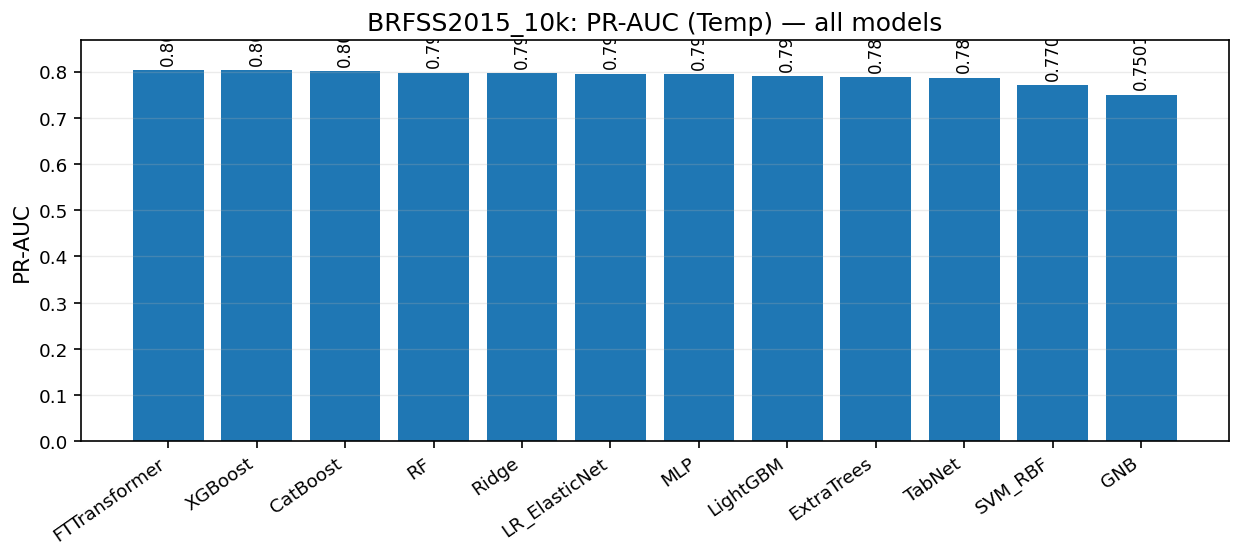

In [40]:
import matplotlib as mpl
import matplotlib.pyplot as plt

FIG_DPI = 300  # keep your existing if already set

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

import numpy as np
import matplotlib.pyplot as plt

def metric_barplot_scientific(
    dataset_name,
    metric_col,
    title,
    ylabel=None,
    sort_desc=True,
    annotate=True,
    fmt="{:.4f}",
    headroom=0.08,        # <-- increases top space so labels never touch boundary
    annot_pad_pts=3,      # <-- label offset in points
):
    df = load_fold_csv(dataset_name)

    g = df.groupby("model")[metric_col].mean()
    g = g.sort_values(ascending=not sort_desc)

    x = np.arange(len(g))
    vals = g.values
    labels = g.index.tolist()

    fig = plt.figure(figsize=(10.5, 4.8))
    ax = plt.gca()

    bars = ax.bar(x, vals, linewidth=0.0)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylabel(ylabel if ylabel is not None else metric_col)
    ax.set_title(f"{dataset_name}: {title}")
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)

    # ---- FIX: add headroom so top labels don't collide with the frame
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    if np.isfinite(vmax):
        if vmin >= 0:
            ax.set_ylim(0, vmax * (1.0 + headroom))
        else:
            span = (vmax - vmin) if (vmax > vmin) else 1.0
            ax.set_ylim(vmin - 0.05 * span, vmax + headroom * span)

    # ---- FIX: labels with offset in POINTS and clamped inside axes
    if annotate:
        y0, y1 = ax.get_ylim()
        yr = y1 - y0
        for rect, v in zip(bars, vals):
            if not np.isfinite(v):
                continue
            xmid = rect.get_x() + rect.get_width() / 2

            # place slightly above bar
            y_text = v + 0.01 * yr

            # clamp to stay inside the top boundary
            y_text = min(y_text, y1 - 0.04 * yr)

            ax.annotate(
                fmt.format(v),
                xy=(xmid, v),
                xytext=(0, annot_pad_pts),  # points offset (prevents touching the bar/top)
                textcoords="offset points",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=10,
                clip_on=True,  # ensure it never draws outside the axes
            )

    plt.tight_layout()
    _save_allfig(fig, dataset_name, f"BAR_{metric_col}_scientific")


# --- RUN: PR-AUC barplot (your example) ---
metric_barplot_scientific("BRFSS2015_10k", "PR_AUC_temp", "PR-AUC (Temp) — all models", "PR-AUC")

NameError: name '_save_pf' is not defined

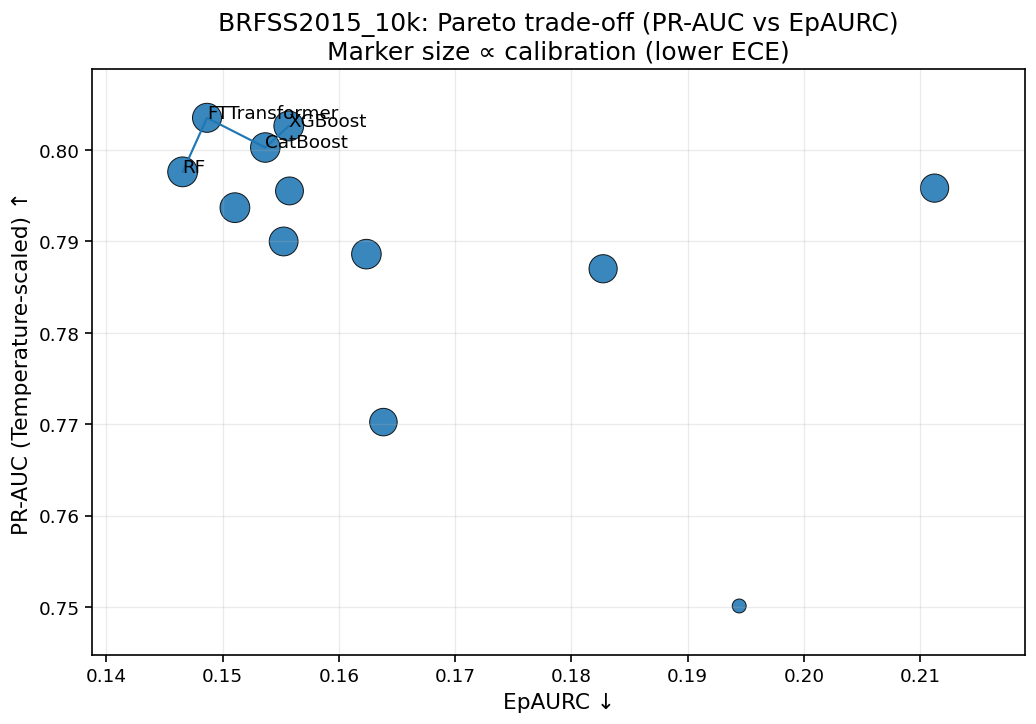

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def pareto_pr_vs_epaurc_scientific(dataset_name, label_mode="pareto"):
    tab = mean_metrics_table(dataset_name)
    models = tab["model"].tolist()

    pr  = tab["PR_AUC_temp"].values.astype(float)
    ece = tab["ECE_temp"].values.astype(float)
    epa = tab["EpAURC"].values.astype(float)

    pareto = pareto_mask_3d(pr, ece, epa)
    sizes  = _marker_sizes(ece, invert=True, smin=70, smax=320)  # lower ECE => larger

    fig = plt.figure(figsize=(8.8, 6.2))
    ax = plt.gca()

    ax.scatter(
        epa, pr,
        s=sizes,
        alpha=0.88,
        edgecolor="black", linewidth=0.6
    )

    # connect Pareto in EpAURC-sorted order
    epa_p = epa[pareto]; pr_p = pr[pareto]
    order = np.argsort(epa_p)
    ax.plot(epa_p[order], pr_p[order], linewidth=1.3)

    ax.set_xlabel("EpAURC ↓")
    ax.set_ylabel("PR-AUC (Temperature-scaled) ↑")
    ax.set_title(f"{dataset_name}: Pareto trade-off (PR-AUC vs EpAURC)\nMarker size ∝ calibration (lower ECE)")

    # axis padding
    def _pad(lo, hi, frac=0.10):
        span = (hi - lo) if (hi > lo) else 1.0
        return lo - frac*span, hi + frac*span

    x0, x1 = _pad(np.nanmin(epa), np.nanmax(epa), 0.12)
    y0, y1 = _pad(np.nanmin(pr),  np.nanmax(pr),  0.10)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # labels (repelled)
    texts = []
    if label_mode == "all":
        idxs = np.arange(len(models))
    elif label_mode == "top6":
        idxs = np.argsort(-pr)[:6]
    else:
        idxs = np.where(pareto)[0]

    for i in idxs:
        texts.append(ax.text(epa[i], pr[i], models[i], fontsize=11))

    try:
        from adjustText import adjust_text
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle="-", lw=0.6),
            expand_text=(1.2, 1.35),
            expand_points=(1.2, 1.35),
            force_text=(0.6, 0.8),
            force_points=(0.15, 0.25),
        )
    except Exception:
        pass

    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    _save_pf(fig, dataset_name, "PF2_pr_vs_epaurc_scientific")


# RUN (both datasets)
for dname in ["BRFSS2015_10k", "EarlyStage"]:
    pareto_pr_vs_epaurc_scientific(dname, label_mode="pareto")

print("✔ Saved PF2_pr_vs_epaurc_scientific (png/pdf) for both datasets.")

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

def _partial_epaurc_at_cov(y, p, u, cov_target=0.90):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    u = np.asarray(u, float)

    order = np.argsort(u)
    y = y[order]; p = p[order]

    N = len(y)
    ks  = np.arange(1, N+1)
    cov = ks / N

    err = ((p >= 0.5).astype(int) != y).astype(float)
    risk = np.cumsum(err) / ks

    m = cov <= cov_target
    cov2, risk2 = cov[m], risk[m]
    if len(cov2) < 2:
        return float(np.mean(err))
    return float(np.trapz(risk2, cov2))

def _pr_auc_at_cov(y, p, u, cov_target=0.90):
    y = np.asarray(y, int)
    p = np.clip(np.asarray(p, float), 1e-12, 1-1e-12)
    u = np.asarray(u, float)

    order = np.argsort(u)
    N = len(y)
    k = max(10, int(np.floor(cov_target * N)))
    idx = order[:k]
    return float(average_precision_score(y[idx], p[idx]))

def fig_gating_shift_scientific(dataset_name, cov_target=0.90, label_mode="pareto"):
    tab = mean_metrics_table(dataset_name)
    models = tab["model"].tolist()

    # BEFORE (stable fold means)
    pr_before  = tab["PR_AUC_temp"].values.astype(float)
    epa_before = tab["EpAURC"].values.astype(float)
    ece        = tab["ECE_temp"].values.astype(float)

    # marker size ∝ calibration (lower ECE larger)
    sizes = _marker_sizes(ece, invert=True, smin=70, smax=320)

    # AFTER (pooled test predictions; keep lowest-u cov_target)
    pr_after  = np.zeros(len(models), float)
    epa_after = np.zeros(len(models), float)

    for i, m in enumerate(models):
        y, _, p, _, u, _ = _all_test_concat(dataset_name, m)  # your existing helper
        pr_after[i]  = _pr_auc_at_cov(y, p, u, cov_target=cov_target)
        epa_after[i] = _partial_epaurc_at_cov(y, p, u, cov_target=cov_target)

    # Pareto (based on BEFORE triplet) for label selection
    pareto = pareto_mask_3d(pr_before, ece, epa_before)

    fig = plt.figure(figsize=(9.4, 6.7))
    ax = plt.gca()

    # BEFORE and AFTER points
    ax.scatter(epa_before, pr_before, s=sizes, alpha=0.70,
               edgecolor="black", linewidth=0.5, label="Before (full test)")
    ax.scatter(epa_after, pr_after, s=sizes, alpha=0.78,
               edgecolor="black", linewidth=0.5, label=f"After (keep lowest-u {int(cov_target*100)}%)")

    # arrows for ALL models
    for i in range(len(models)):
        ax.annotate(
            "", xy=(epa_after[i], pr_after[i]), xytext=(epa_before[i], pr_before[i]),
            arrowprops=dict(arrowstyle="->", lw=0.9, alpha=0.9)
        )

    ax.set_xlabel(f"EpAURC ↓  (after: partial AURC up to {int(cov_target*100)}% coverage)")
    ax.set_ylabel(f"PR-AUC ↑  (after: PR-AUC on kept {int(cov_target*100)}%)")
    ax.set_title(f"{dataset_name}: Safety–performance shift under uncertainty gating\nMarker size ∝ calibration (lower ECE)")

    # axis padding
    def _pad(lo, hi, frac=0.10):
        span = (hi - lo) if (hi > lo) else 1.0
        return lo - frac*span, hi + frac*span

    x0, x1 = _pad(np.nanmin(np.r_[epa_before, epa_after]), np.nanmax(np.r_[epa_before, epa_after]), 0.12)
    y0, y1 = _pad(np.nanmin(np.r_[pr_before, pr_after]),  np.nanmax(np.r_[pr_before, pr_after]),  0.10)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # labels (placed on AFTER points; repelled)
    texts = []
    if label_mode == "all":
        idxs = np.arange(len(models))
    elif label_mode == "top6":
        idxs = np.argsort(-pr_before)[:6]
    else:
        idxs = np.where(pareto)[0]

    for i in idxs:
        texts.append(ax.text(epa_after[i], pr_after[i], models[i], fontsize=11))

    try:
        from adjustText import adjust_text
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle="-", lw=0.6),
            expand_text=(1.2, 1.35),
            expand_points=(1.2, 1.35),
            force_text=(0.6, 0.8),
            force_points=(0.15, 0.25),
        )
    except Exception:
        pass

    ax.legend(ncol=2, frameon=True)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    _save_pf(fig, dataset_name, f"PF4_gating_shift_{int(cov_target*100)}cov_scientific")


# RUN (both datasets)
for dname in ["BRFSS2015_10k", "EarlyStage"]:
    fig_gating_shift_scientific(dname, cov_target=0.90, label_mode="pareto")

print("✔ Saved PF4_gating_shift_90cov_scientific (png/pdf) for both datasets.")

NameError: name '_all_test_concat' is not defined

In [1]:
# ============================================================
# STEP 0: Setup (Kaggle-ready)
# Two datasets + 12 models + 5-fold CV + train/calib split
# ============================================================

import os, gc, time, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Any, Tuple, List, Optional

# ----------------------------
# pip helper
# ----------------------------
def _pip_install(pkgs):
    import sys, subprocess
    for p in pkgs:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

missing = []

# core ML libs
try:
    import xgboost as xgb
except Exception:
    missing.append("xgboost")
try:
    import lightgbm as lgb
except Exception:
    missing.append("lightgbm")
try:
    from catboost import CatBoostClassifier
except Exception:
    missing.append("catboost")
try:
    from interpret.glassbox import ExplainableBoostingClassifier
except Exception:
    missing.append("interpret")

# deep libs
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    raise RuntimeError("PyTorch should exist on Kaggle. Error: " + str(e))

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except Exception:
    missing.append("pytorch-tabnet")

if missing:
    print("Installing missing packages:", missing)
    _pip_install(missing)

# re-import after install
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    log_loss, brier_score_loss,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

Installing missing packages: ['interpret', 'pytorch-tabnet']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 40.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00


In [6]:
# ============================================================
# STEP 1: Reproducibility + global config
# ============================================================

def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ----------------------------
# Locked model list (12)
# ----------------------------
MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees",
    "XGBoost", "LightGBM", "CatBoost",
    "SVM_RBF",
    "EBM",                 # Explainable Boosting Machine (SOTA glassbox)
    "MLP", "TabNet", "FTTransformer"
]

# Which models need scaling
SCALED_MODELS = {"LR_ElasticNet", "SVM_RBF", "MLP", "TabNet", "FTTransformer"}

# Output root
OUTROOT = "/kaggle/working/uq_2datasets_10k"
os.makedirs(OUTROOT, exist_ok=True)
print("OUTROOT:", OUTROOT)

# BRFSS subsample size
BRFSS_SUB_N = 10000

# ============================================================
# STEP 2: Dataset loaders
# ============================================================

def find_file_in_kaggle_input(filename_contains: str) -> Optional[str]:
    root = "/kaggle/input"
    for dirpath, _, files in os.walk(root):
        for f in files:
            if filename_contains.lower() in f.lower():
                return os.path.join(dirpath, f)
    return None

def load_brfss_2015_10k(seed=42, n=10000) -> Tuple[pd.DataFrame, str]:
    # Your known Kaggle path (adjust if needed)
    path = "/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
    if not os.path.exists(path):
        alt = find_file_in_kaggle_input("diabetes_binary_5050split_health_indicators_BRFSS2015")
        if alt is None:
            raise FileNotFoundError("Could not find BRFSS2015 csv in /kaggle/input. Upload or mount dataset.")
        path = alt

    df = pd.read_csv(path)
    target = "Diabetes_binary"
    assert target in df.columns, f"Target {target} not found. Columns: {df.columns.tolist()}"
    # stratified subsample preserving 50/50
    df_sub = (
        df.groupby(target, group_keys=False)
          .apply(lambda g: g.sample(n=min(len(g), n//2), random_state=seed))
          .sample(frac=1.0, random_state=seed)
          .reset_index(drop=True)
    )
    return df_sub, target

def load_early_stage_diabetes(seed=42) -> Tuple[pd.DataFrame, str]:
    # Common Kaggle filename is often "diabetes_data_upload.csv"
    path = "/kaggle/input/early-stage-diabetes-risk-prediction-dataset/diabetes_data_upload.csv"
    if not os.path.exists(path):
        alt = find_file_in_kaggle_input("diabetes_data_upload")
        if alt is None:
            alt = find_file_in_kaggle_input("early stage diabetes")
        if alt is None:
            raise FileNotFoundError("Could not find early-stage diabetes csv in /kaggle/input.")
        path = alt

    df = pd.read_csv(path)

    # target is typically "class" with values "Positive"/"Negative"
    # normalize:
    if "class" in df.columns:
        target = "class"
    elif "Class" in df.columns:
        target = "Class"
    else:
        # fallback: last column
        target = df.columns[-1]

    # map labels to 0/1 if needed
    y = df[target]
    if y.dtype == object:
        y2 = y.astype(str).str.lower().map({"positive": 1, "pos": 1, "1": 1, "yes": 1,
                                            "negative": 0, "neg": 0, "0": 0, "no": 0})
        if y2.isna().any():
            # maybe labels are already 0/1 strings
            y2 = pd.to_numeric(y, errors="coerce")
        df[target] = y2.astype(int)
    else:
        df[target] = df[target].astype(int)

    return df, target

def preprocess_tabular(df: pd.DataFrame, target: str) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    # Handle categorical by one-hot (safe and consistent for all models)
    y = df[target].astype(int).values
    Xdf = df.drop(columns=[target]).copy()

    # convert yes/no to 1/0 if present (early-stage dataset)
    for c in Xdf.columns:
        if Xdf[c].dtype == object:
            s = Xdf[c].astype(str).str.strip().str.lower()
            if set(s.unique()).issubset({"yes", "no"}):
                Xdf[c] = s.map({"yes": 1, "no": 0}).astype(int)

    # one-hot for remaining categoricals
    Xdf = pd.get_dummies(Xdf, drop_first=False)

    # ensure float
    X = Xdf.astype(float).values
    feat = Xdf.columns.tolist()
    return X, y, feat

# Load both datasets now
df_brfss, ycol_brfss = load_brfss_2015_10k(seed=SEED, n=BRFSS_SUB_N)
X_brfss, y_brfss, feat_brfss = preprocess_tabular(df_brfss, ycol_brfss)
print("[BRFSS] shape:", X_brfss.shape, "pos rate:", y_brfss.mean())

df_esd, ycol_esd = load_early_stage_diabetes(seed=SEED)
X_esd, y_esd, feat_esd = preprocess_tabular(df_esd, ycol_esd)
print("[Early-Stage] shape:", X_esd.shape, "pos rate:", y_esd.mean())

# ============================================================
# STEP 3: Metrics + calibration + conformal (leakage-safe)
# ============================================================

def ece_score(y_true: np.ndarray, p1: np.ndarray, n_bins: int = 15) -> float:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p1 >= lo) & (p1 < hi) if i < n_bins - 1 else (p1 >= lo) & (p1 <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = p1[mask].mean()
        ece += (mask.sum() / N) * abs(acc - conf)
    return float(ece)

def youdens_j_threshold(y_true: np.ndarray, p1: np.ndarray) -> float:
    thresholds = np.unique(np.round(p1, 6))
    best_t, best_j = 0.5, -1e9
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        j = sens + spec - 1
        if j > best_j:
            best_j, best_t = j, float(t)
    return best_t

def fixed_sensitivity_threshold(y_true: np.ndarray, p1: np.ndarray, target_sens: float = 0.80) -> float:
    thresholds = np.unique(np.round(p1, 6))
    thresholds.sort()
    best_t = 0.5
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        sens = tp / (tp + fn + 1e-12)
        if sens >= target_sens:
            best_t = float(t)
            break
    return best_t

def cls_metrics_at_t(y_true: np.ndarray, p1: np.ndarray, t: float) -> Dict[str, float]:
    y_hat = (p1 >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    prec = tp / (tp + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    bal  = 0.5 * (sens + spec)
    mcc_num = tp*tn - fp*fn
    mcc_den = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + 1e-12)
    mcc = mcc_num / mcc_den
    f1 = 2*prec*sens/(prec+sens+1e-12)
    return {"Acc": acc, "BalAcc": bal, "MCC": mcc, "F1": f1, "Sens": sens, "Spec": spec, "PPV": prec, "NPV": npv}

# ----------------------------
# Temperature scaling (binary) on probabilities
# ----------------------------
def fit_temperature_scaling(p1_cal: np.ndarray, y_cal: np.ndarray) -> float:
    from scipy.optimize import minimize
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    logits = np.log(p1_cal / (1 - p1_cal))

    def nll(T_log):
        T = np.exp(T_log[0])
        z = logits / T
        p = 1 / (1 + np.exp(-z))
        return log_loss(y_cal, np.vstack([1 - p, p]).T, labels=[0, 1])

    res = minimize(nll, x0=np.array([0.0]), method="Nelder-Mead")
    return float(np.exp(res.x[0]))

def apply_temperature_scaling(p1: np.ndarray, T: float) -> np.ndarray:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    logits = np.log(p1 / (1 - p1))
    z = logits / T
    p = 1 / (1 + np.exp(-z))
    return np.clip(p, 1e-12, 1 - 1e-12)

# ----------------------------
# Isotonic regression
# ----------------------------
from sklearn.isotonic import IsotonicRegression

def fit_isotonic(p1_cal: np.ndarray, y_cal: np.ndarray) -> IsotonicRegression:
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(np.clip(p1_cal, 1e-12, 1-1e-12), y_cal)
    return iso

def apply_isotonic(p1: np.ndarray, iso: IsotonicRegression) -> np.ndarray:
    return np.clip(iso.predict(np.clip(p1, 1e-12, 1-1e-12)), 1e-12, 1-1e-12)

# ----------------------------
# Conformal prediction (label-conditional) for binary sets
# ----------------------------
def conformal_fit_label_conditional(p1_cal: np.ndarray, y_cal: np.ndarray, alpha: float) -> Dict[int, float]:
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    # score for true label:
    # if y=0: p_true = 1-p1 => score = 1 - (1-p1) = p1
    # if y=1: p_true = p1   => score = 1 - p1
    scores0 = p1_cal[y_cal == 0]
    scores1 = 1 - p1_cal[y_cal == 1]

    def qhat(scores):
        scores = np.sort(scores)
        n = len(scores)
        k = int(np.ceil((n + 1) * (1 - alpha))) - 1
        k = np.clip(k, 0, n - 1)
        return float(scores[k])

    return {0: qhat(scores0), 1: qhat(scores1)}

def conformal_predict_sets(p1: np.ndarray, q: Dict[int, float]) -> List[Tuple[int, ...]]:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    sets = []
    for p in p1:
        include1 = (1 - p) <= q[1]   # p >= 1-q1
        include0 = p <= q[0]
        s = []
        if include0: s.append(0)
        if include1: s.append(1)
        if len(s) == 0:
            s = [int(p >= 0.5)]
        sets.append(tuple(s))
    return sets

def conformal_metrics(y_true: np.ndarray, sets: List[Tuple[int, ...]]) -> Dict[str, float]:
    covered = np.array([int(y_true[i] in sets[i]) for i in range(len(y_true))])
    sizes = np.array([len(s) for s in sets])
    return {"coverage": float(covered.mean()), "set_size": float(sizes.mean())}

def prob_metrics(y_true: np.ndarray, p1: np.ndarray) -> Dict[str, float]:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    return {
        "ROC_AUC": float(roc_auc_score(y_true, p1)),
        "PR_AUC":  float(average_precision_score(y_true, p1)),
        "ECE":     float(ece_score(y_true, p1, 15)),
        "Brier":   float(brier_score_loss(y_true, p1)),
        "NLL":     float(log_loss(y_true, np.vstack([1-p1, p1]).T, labels=[0,1])),
    }

# ============================================================
# STEP 4: Deep models (MLP + FTTransformer + TabNet)
# ============================================================

class NPDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLP(nn.Module):
    def __init__(self, d_in: int, hidden=(256, 128), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp_return_p1(Xtr, ytr, Xva, yva, Xte, seed=42, epochs=25, bs=256, lr=1e-3, wd=1e-4):
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e18, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    te_loader = DataLoader(NPDataset(Xte, np.zeros(len(Xte))), batch_size=bs, shuffle=False, num_workers=0)
    pte = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            pte.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(pte)

# ----------------------------
# FT-Transformer (minimal)
# ----------------------------
class FTTransformer(nn.Module):
    def __init__(self, n_features: int, d_token: int = 64, n_heads: int = 8, n_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.feature_tokenizers = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_features)])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads,
            dim_feedforward=4*d_token,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        toks = []
        for j in range(self.n_features):
            tj = self.feature_tokenizers[j](x[:, j:j+1]).unsqueeze(1)
            toks.append(tj)
        tok = torch.cat(toks, dim=1)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        seq = torch.cat([cls, tok], dim=1)
        enc = self.encoder(seq)
        return self.head(enc[:, 0, :]).squeeze(-1)

def train_ft_return_p1(Xtr, ytr, Xva, yva, Xte, seed=42, epochs=25, bs=256, lr=2e-4, wd=1e-4):
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e18, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    te_loader = DataLoader(NPDataset(Xte, np.zeros(len(Xte))), batch_size=bs, shuffle=False, num_workers=0)
    pte = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            pte.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(pte)

# ----------------------------
# TabNet
# ----------------------------
def fit_tabnet_once(Xtr, ytr, Xva, yva, seed=42):
    clf = TabNetClassifier(
        n_d=16, n_a=16, n_steps=5,
        gamma=1.3, n_independent=2, n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type="entmax",
        seed=seed,
        verbose=0
    )
    clf.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_name=["val"],
        eval_metric=["logloss"],
        max_epochs=100,
        patience=20,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )
    return clf

# ============================================================
# STEP 5: One model, one fold (BASE: raw/temp/iso + conformal + operating points)
# ============================================================

def fit_predict_model_once(mname: str, Xtrsub_raw, Xtrsub_sc, ytrsub,
                          Xcal_raw, Xcal_sc, ycal,
                          Xte_raw, Xte_sc, yte,
                          Xdl_va_sc, ydl_va) -> Dict[str, Any]:

    # --- Fit model ONCE and predict on trsub, cal, test
    if mname == "LR_ElasticNet":
        clf = LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            C=1.0, max_iter=5000, n_jobs=-1, random_state=SEED
        )
        clf.fit(Xtrsub_sc, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_sc)[:, 1]
        p_cal   = clf.predict_proba(Xcal_sc)[:, 1]
        p_te    = clf.predict_proba(Xte_sc)[:, 1]

    elif mname == "GNB":
        clf = GaussianNB()
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "RF":
        clf = RandomForestClassifier(
            n_estimators=600, max_depth=None,
            min_samples_leaf=2, n_jobs=-1, random_state=SEED
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "ExtraTrees":
        clf = ExtraTreesClassifier(
            n_estimators=800, max_depth=None,
            min_samples_leaf=2, n_jobs=-1, random_state=SEED
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "XGBoost":
        clf = xgb.XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, eval_metric="logloss",
            n_jobs=-1, random_state=SEED
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "LightGBM":
        clf = lgb.LGBMClassifier(
            n_estimators=1200, learning_rate=0.03, num_leaves=64,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, n_jobs=-1, random_state=SEED
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "CatBoost":
        clf = CatBoostClassifier(
            iterations=1500, depth=6, learning_rate=0.03,
            loss_function="Logloss", eval_metric="Logloss",
            verbose=False, random_seed=SEED
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "SVM_RBF":
        clf = SVC(C=2.0, gamma="scale", probability=True, random_state=SEED)
        clf.fit(Xtrsub_sc, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_sc)[:, 1]
        p_cal   = clf.predict_proba(Xcal_sc)[:, 1]
        p_te    = clf.predict_proba(Xte_sc)[:, 1]

    elif mname == "EBM":
        # Explainable Boosting Machine
        clf = ExplainableBoostingClassifier(random_state=SEED)
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif mname == "MLP":
        p_trsub = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xtrsub_sc, seed=SEED)
        p_cal   = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xcal_sc, seed=SEED)
        p_te    = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xte_sc, seed=SEED)

    elif mname == "TabNet":
        tab = fit_tabnet_once(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=SEED)
        p_trsub = tab.predict_proba(Xtrsub_sc)[:, 1]
        p_cal   = tab.predict_proba(Xcal_sc)[:, 1]
        p_te    = tab.predict_proba(Xte_sc)[:, 1]

    elif mname == "FTTransformer":
        p_trsub = train_ft_return_p1(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xtrsub_sc, seed=SEED)
        p_cal   = train_ft_return_p1(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xcal_sc, seed=SEED)
        p_te    = train_ft_return_p1(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xte_sc, seed=SEED)

    else:
        raise ValueError("Unknown model: " + mname)

    p_trsub = np.clip(p_trsub, 1e-12, 1-1e-12)
    p_cal   = np.clip(p_cal,   1e-12, 1-1e-12)
    p_te    = np.clip(p_te,    1e-12, 1-1e-12)

    # --- calibration fits on calibration_sub ONLY
    T = fit_temperature_scaling(p_cal, ycal)
    p_te_temp = apply_temperature_scaling(p_te, T)
    p_cal_temp = apply_temperature_scaling(p_cal, T)

    iso = fit_isotonic(p_cal, ycal)
    p_te_iso = apply_isotonic(p_te, iso)

    # --- conformal using temp-calibrated probabilities on calibration_sub
    q90 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.05)
    conf90 = conformal_metrics(yte, conformal_predict_sets(p_te_temp, q90))
    conf95 = conformal_metrics(yte, conformal_predict_sets(p_te_temp, q95))

    # --- operating thresholds chosen on calibration_sub (leakage-safe)
    tJ = youdens_j_threshold(ycal, p_cal_temp)
    tS80 = fixed_sensitivity_threshold(ycal, p_cal_temp, target_sens=0.80)

    # --- metrics
    met_raw  = prob_metrics(yte, p_te)
    met_temp = prob_metrics(yte, p_te_temp)
    met_iso  = prob_metrics(yte, p_te_iso)

    clsJ_temp   = cls_metrics_at_t(yte, p_te_temp, tJ)
    clsS80_temp = cls_metrics_at_t(yte, p_te_temp, tS80)

    return {
        "p_te_raw": p_te,
        "p_te_temp": p_te_temp,
        "p_te_iso": p_te_iso,
        "met_raw": met_raw,
        "met_temp": met_temp,
        "met_iso": met_iso,
        "conf90": conf90,
        "conf95": conf95,
        "tJ": tJ,
        "tS80": tS80,
        "clsJ_temp": clsJ_temp,
        "clsS80_temp": clsS80_temp,
    }

# ============================================================
# STEP 6: CV runner for one dataset
# ============================================================

def summarize_with_n(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    g = df.groupby("model")
    out = g[cols].agg(["mean", "std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

def run_cv_for_dataset(dataset_name: str, X: np.ndarray, y: np.ndarray, feat: List[str]):
    print("\n" + "="*80)
    print("DATASET:", dataset_name, "| X:", X.shape, "| pos rate:", float(y.mean()))
    print("="*80)

    outdir = os.path.join(OUTROOT, dataset_name)
    os.makedirs(outdir, exist_ok=True)
    fold_csv = os.path.join(outdir, "fold_level_results_base.csv")
    sum_csv  = os.path.join(outdir, "summary_base.csv")

    if os.path.exists(fold_csv):
        os.remove(fold_csv)
    print("Will write:", fold_csv)

    rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    rows = []
    for fold_id, (tr_idx, te_idx) in enumerate(rkf.split(X, y), start=1):
        Xtr_raw, ytr = X[tr_idx], y[tr_idx]
        Xte_raw, yte = X[te_idx], y[te_idx]

        # train_sub / calibration_sub (from training fold only)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
        trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
        Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
        Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

        # scaling (fit on train_sub only)
        scaler = StandardScaler()
        Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
        Xcal_sc   = scaler.transform(Xcal_raw)
        Xte_sc    = scaler.transform(Xte_raw)

        # DL validation split from train_sub only
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
        tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
        Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]

        print(f"\n=== {dataset_name} Fold {fold_id}/5 === "
              f"train_fold={len(tr_idx)}, test={len(te_idx)}, train_sub={len(trsub_idx)}, cal={len(cal_idx)}")

        for mname in MODEL_LIST:
            t0 = time.time()
            out = fit_predict_model_once(
                mname=mname,
                Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
                Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
                Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
                Xdl_va_sc=Xdl_va_sc, ydl_va=ydl_va
            )
            dt = time.time() - t0

            row = {
                "dataset": dataset_name,
                "fold": fold_id,
                "model": mname,
                "time_sec": dt,

                # temp-calibrated main metrics
                "PR_AUC_temp": out["met_temp"]["PR_AUC"],
                "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
                "ECE_temp": out["met_temp"]["ECE"],
                "Brier_temp": out["met_temp"]["Brier"],
                "NLL_temp": out["met_temp"]["NLL"],

                # raw + iso calibration (for Table R2)
                "ECE_raw": out["met_raw"]["ECE"],
                "ECE_iso": out["met_iso"]["ECE"],
                "Brier_raw": out["met_raw"]["Brier"],
                "Brier_iso": out["met_iso"]["Brier"],
                "NLL_raw": out["met_raw"]["NLL"],
                "NLL_iso": out["met_iso"]["NLL"],

                # conformal (temp)
                "Conf90_cov": out["conf90"]["coverage"],
                "Conf90_size": out["conf90"]["set_size"],
                "Conf95_cov": out["conf95"]["coverage"],
                "Conf95_size": out["conf95"]["set_size"],

                # operating points (chosen on calibration_sub)
                "T_J": out["tJ"],
                "T_S80": out["tS80"],

                # cls @ J-threshold
                "BalAcc_J_temp": out["clsJ_temp"]["BalAcc"],
                "MCC_J_temp": out["clsJ_temp"]["MCC"],
                "F1_J_temp": out["clsJ_temp"]["F1"],
                "Sens_J_temp": out["clsJ_temp"]["Sens"],
                "Spec_J_temp": out["clsJ_temp"]["Spec"],
                "PPV_J_temp": out["clsJ_temp"]["PPV"],
                "NPV_J_temp": out["clsJ_temp"]["NPV"],

                # cls @ Sens=0.80 threshold
                "BalAcc_S80_temp": out["clsS80_temp"]["BalAcc"],
                "MCC_S80_temp": out["clsS80_temp"]["MCC"],
                "F1_S80_temp": out["clsS80_temp"]["F1"],
                "Sens_S80_temp": out["clsS80_temp"]["Sens"],
                "Spec_S80_temp": out["clsS80_temp"]["Spec"],
                "PPV_S80_temp": out["clsS80_temp"]["PPV"],
                "NPV_S80_temp": out["clsS80_temp"]["NPV"],
            }

            rows.append(row)

            # safe-append write
            pd.DataFrame([row]).to_csv(
                fold_csv, mode="a",
                header=(not os.path.exists(fold_csv) or os.path.getsize(fold_csv) == 0),
                index=False
            )

            print(f"{mname:14s} | PR={row['PR_AUC_temp']:.4f} ROC={row['ROC_AUC_temp']:.4f} "
                  f"ECE={row['ECE_temp']:.4f} Conf90={row['Conf90_cov']:.3f} size={row['Conf90_size']:.2f} "
                  f"| {dt:.1f}s")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    df = pd.read_csv(fold_csv)
    # summary (main ordering by PR-AUC)
    cols_summary = [
        "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
        "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
        "BalAcc_J_temp","MCC_J_temp","F1_J_temp","Sens_J_temp","Spec_J_temp",
        "BalAcc_S80_temp","MCC_S80_temp","F1_S80_temp","Sens_S80_temp","Spec_S80_temp",
        "time_sec"
    ]
    summary = summarize_with_n(df, cols_summary).sort_values("PR_AUC_temp_mean", ascending=False)
    summary.to_csv(sum_csv, index=False)

    print("\nSaved fold results:", fold_csv)
    print("Saved summary:", sum_csv)
    display(summary.head(12))

    return df, summary, outdir

# Run both datasets
df_brfss_res, sum_brfss, out_brfss = run_cv_for_dataset("BRFSS2015_10k", X_brfss, y_brfss, feat_brfss)
df_esd_res,   sum_esd,   out_esd   = run_cv_for_dataset("EarlyStage",     X_esd,   y_esd,   feat_esd)

SyntaxError: '{' was never closed (1637547213.py, line 280)

In [3]:
# ============================================================
# STEP 4: Epistemic UQ for all 12 models
# - Bootstrap variance (LR/GNB/XGB/LGBM/CatBoost/SVM/EBM)
# - Tree disagreement (RF/ExtraTrees)
# - MC Dropout (MLP/FTTransformer)
# - Seed ensemble variance (TabNet)
# Produces: ep_score per test sample + EpAURC + selective accuracy
# ============================================================

from copy import deepcopy

# ----------------------------
# Selective prediction metrics from epistemic score
# ----------------------------
def ep_risk_coverage_curve(y_true: np.ndarray, p1: np.ndarray, ep_score: np.ndarray, t: float = 0.5):
    """
    Sort by ep_score ascending (most certain first).
    Risk = 1 - accuracy among retained.
    """
    order = np.argsort(ep_score)  # low uncertainty kept first
    y = y_true[order]
    p = p1[order]
    yhat = (p >= t).astype(int)
    correct = (yhat == y).astype(int)

    cov = np.arange(1, len(y) + 1) / len(y)
    acc = np.cumsum(correct) / np.arange(1, len(y) + 1)
    risk = 1 - acc
    return cov, risk

def ep_aurc(y_true: np.ndarray, p1: np.ndarray, ep_score: np.ndarray, t: float = 0.5) -> float:
    cov, risk = ep_risk_coverage_curve(y_true, p1, ep_score, t=t)
    return float(np.trapz(risk, cov))

def selective_accuracy(y_true: np.ndarray, p1: np.ndarray, ep_score: np.ndarray, coverage: float, t: float = 0.5) -> float:
    n = len(y_true)
    k = int(np.floor(coverage * n))
    order = np.argsort(ep_score)
    idx = order[:max(1, k)]
    yhat = (p1[idx] >= t).astype(int)
    return float((yhat == y_true[idx]).mean())

# ----------------------------
# Bootstrap helpers
# ----------------------------
def _bootstrap_indices(n: int, B: int, rng: np.random.RandomState):
    return [rng.randint(0, n, size=n) for _ in range(B)]

def _var_across_preds(P: np.ndarray) -> np.ndarray:
    """
    P shape: (B, N) predicted probabilities
    return per-sample variance across B
    """
    return np.var(P, axis=0).astype(float)

# ----------------------------
# Create models (same hyperparams as your BASE)
# ----------------------------
def make_model_for_bootstrap(mname: str):
    if mname == "LR_ElasticNet":
        return LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            C=1.0, max_iter=5000, n_jobs=-1, random_state=SEED
        )
    if mname == "GNB":
        return GaussianNB()
    if mname == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, eval_metric="logloss",
            n_jobs=-1, random_state=SEED
        )
    if mname == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=1200, learning_rate=0.03, num_leaves=64,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=1.0, n_jobs=-1, random_state=SEED
        )
    if mname == "CatBoost":
        return CatBoostClassifier(
            iterations=1500, depth=6, learning_rate=0.03,
            loss_function="Logloss", eval_metric="Logloss",
            verbose=False, random_seed=SEED
        )
    if mname == "SVM_RBF":
        return SVC(C=2.0, gamma="scale", probability=True, random_state=SEED)
    if mname == "EBM":
        return ExplainableBoostingClassifier(random_state=SEED)

    raise ValueError("No bootstrap model builder for: " + mname)

def fit_predict_once(mname: str,
                     Xtr, ytr, Xte,
                     scaled: bool):
    """
    Fits one model and returns p_te.
    For CatBoost: uses CatBoostClassifier API.
    For others: .fit + .predict_proba
    """
    clf = make_model_for_bootstrap(mname)
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    return np.clip(p, 1e-12, 1-1e-12), clf

# ----------------------------
# Epistemic: bootstrap variance (LR/GNB/XGB/LGBM/CatBoost/SVM/EBM)
# ----------------------------
def epistemic_bootstrap_variance(mname: str,
                                Xtrsub_raw, Xtrsub_sc, ytrsub,
                                Xte_raw, Xte_sc,
                                B: int = 20,
                                seed: int = 42) -> np.ndarray:
    rng = np.random.RandomState(seed)
    n = len(ytrsub)
    boot_idxs = _bootstrap_indices(n, B, rng)

    preds = []
    for b, idx in enumerate(boot_idxs):
        if mname in SCALED_MODELS:
            Xb = Xtrsub_sc[idx]
            Xte = Xte_sc
        else:
            Xb = Xtrsub_raw[idx]
            Xte = Xte_raw

        yb = ytrsub[idx]
        pb, _ = fit_predict_once(mname, Xb, yb, Xte, scaled=(mname in SCALED_MODELS))
        preds.append(pb)

    P = np.stack(preds, axis=0)  # (B,Ntest)
    return _var_across_preds(P)

# ----------------------------
# Epistemic: tree disagreement variance (RF/ExtraTrees)
# ----------------------------
def epistemic_tree_disagreement(fitted_tree_ensemble, Xte_raw) -> np.ndarray:
    """
    Use per-tree predicted prob variance across trees.
    """
    # each estimator is a DecisionTreeClassifier
    tree_probs = []
    for est in fitted_tree_ensemble.estimators_:
        tree_probs.append(est.predict_proba(Xte_raw)[:, 1])
    P = np.stack(tree_probs, axis=0)  # (n_trees, N)
    return _var_across_preds(P)

# ----------------------------
# MC Dropout: train and return model, then sample dropout predictions
# ----------------------------
def train_mlp_return_model(Xtr, ytr, Xva, yva, seed=42, epochs=25, bs=256, lr=1e-3, wd=1e-4):
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e18, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def train_ft_return_model(Xtr, ytr, Xva, yva, seed=42, epochs=25, bs=256, lr=2e-4, wd=1e-4):
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e18, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_with_dropout(model: nn.Module, X: np.ndarray, T: int = 30, bs: int = 512) -> np.ndarray:
    """
    Returns P shape: (T, N) of stochastic predictions with dropout ON.
    """
    model.train()  # IMPORTANT: enable dropout
    loader = DataLoader(NPDataset(X, np.zeros(len(X))), batch_size=bs, shuffle=False, num_workers=0)
    all_samples = []
    with torch.no_grad():
        for t in range(T):
            preds = []
            for xb, _ in loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                preds.append(p)
            all_samples.append(np.concatenate(preds))
    return np.stack(all_samples, axis=0)

def epistemic_mc_dropout_variance(mname: str,
                                 Xtrsub_sc, ytrsub,
                                 Xdl_va_sc, ydl_va,
                                 Xte_sc,
                                 seed: int = 42,
                                 T: int = 30) -> np.ndarray:
    if mname == "MLP":
        model = train_mlp_return_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=seed)
    elif mname == "FTTransformer":
        model = train_ft_return_model(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=seed)
    else:
        raise ValueError("MC Dropout only for MLP/FTTransformer")

    P = predict_with_dropout(model, Xte_sc, T=T)
    return _var_across_preds(P)

# ----------------------------
# Epistemic: TabNet seed-ensemble variance
# ----------------------------
def epistemic_tabnet_seed_ensemble_variance(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xte_sc,
                                           seeds=(0,1,2,3,4)) -> np.ndarray:
    preds = []
    for s in seeds:
        tab = fit_tabnet_once(Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, seed=SEED + int(s))
        p = np.clip(tab.predict_proba(Xte_sc)[:, 1], 1e-12, 1-1e-12)
        preds.append(p)
    P = np.stack(preds, axis=0)
    return _var_across_preds(P)

# ============================================================
# Unified runner: BASE + epistemic per fold/model
# ============================================================
def run_one_model_one_fold_with_epistemic(
    mname: str,
    Xtrsub_raw, Xtrsub_sc, ytrsub,
    Xcal_raw, Xcal_sc, ycal,
    Xte_raw, Xte_sc, yte,
    Xdl_va_sc, ydl_va,
    bootstrap_B: int = 20,
    mc_T: int = 30,
    tabnet_seeds=(0,1,2,3,4)
) -> Dict[str, Any]:

    # ---- First compute BASE outputs (raw/temp/iso + conformal + operating points)
    base = fit_predict_model_once(
        mname=mname,
        Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
        Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
        Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
        Xdl_va_sc=Xdl_va_sc, ydl_va=ydl_va
    )
    p_te_temp = base["p_te_temp"]
    tJ = base["tJ"]  # leakage-safe threshold from calibration_sub

    # ---- Now compute epistemic score depending on model family
    if mname in {"LR_ElasticNet","GNB","XGBoost","LightGBM","CatBoost","SVM_RBF","EBM"}:
        ep_score = epistemic_bootstrap_variance(
            mname=mname,
            Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xte_raw=Xte_raw, Xte_sc=Xte_sc,
            B=bootstrap_B,
            seed=SEED
        )

    elif mname in {"RF","ExtraTrees"}:
        # fit one ensemble once (same as base hyperparams) and then compute tree disagreement
        if mname == "RF":
            ens = RandomForestClassifier(
                n_estimators=600, max_depth=None,
                min_samples_leaf=2, n_jobs=-1, random_state=SEED
            )
        else:
            ens = ExtraTreesClassifier(
                n_estimators=800, max_depth=None,
                min_samples_leaf=2, n_jobs=-1, random_state=SEED
            )
        ens.fit(Xtrsub_raw, ytrsub)
        ep_score = epistemic_tree_disagreement(ens, Xte_raw)

    elif mname in {"MLP","FTTransformer"}:
        ep_score = epistemic_mc_dropout_variance(
            mname=mname,
            Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xdl_va_sc=Xdl_va_sc, ydl_va=ydl_va,
            Xte_sc=Xte_sc,
            seed=SEED,
            T=mc_T
        )

    elif mname == "TabNet":
        ep_score = epistemic_tabnet_seed_ensemble_variance(
            Xtrsub_sc, ytrsub, Xdl_va_sc, ydl_va, Xte_sc,
            seeds=tabnet_seeds
        )
    else:
        raise ValueError("Unknown epistemic routing for: " + mname)

    ep_score = np.asarray(ep_score).reshape(-1)
    assert len(ep_score) == len(yte)

    # ---- Epistemic usefulness metrics (selective prediction)
    EpAURC = ep_aurc(yte, p_te_temp, ep_score, t=tJ)
    EpSelAcc80 = selective_accuracy(yte, p_te_temp, ep_score, coverage=0.80, t=tJ)
    EpSelAcc90 = selective_accuracy(yte, p_te_temp, ep_score, coverage=0.90, t=tJ)
    EpSelAcc95 = selective_accuracy(yte, p_te_temp, ep_score, coverage=0.95, t=tJ)

    return {
        **base,
        "ep_score": ep_score,
        "EpVar_mean": float(np.mean(ep_score)),
        "EpVar_median": float(np.median(ep_score)),
        "EpAURC": float(EpAURC),
        "EpSelAcc80": float(EpSelAcc80),
        "EpSelAcc90": float(EpSelAcc90),
        "EpSelAcc95": float(EpSelAcc95),
    }

In [4]:
# ============================================================
# FULL UPDATED CV LOOP: 2 datasets + 12 models + Epistemic UQ
# Outputs (per dataset):
#  - fold_level_results_epistemic.csv
#  - summary_epistemic.csv
#  - per-sample predictions: npz per fold/model (for paper figures)
# ============================================================

import json, traceback

def summarize_with_n(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    g = df.groupby("model")
    out = g[cols].agg(["mean", "std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

def run_cv_epistemic_for_dataset(dataset_name: str, X: np.ndarray, y: np.ndarray, feat: List[str],
                                 bootstrap_B=15, mc_T=25, tabnet_seeds=(0,1,2),
                                 save_per_sample_npz=True):

    print("\n" + "="*90)
    print(f"[EPI] DATASET: {dataset_name} | X={X.shape} | pos rate={float(y.mean()):.4f}")
    print("="*90)

    outdir = os.path.join(OUTROOT, dataset_name)
    os.makedirs(outdir, exist_ok=True)

    OUTCSV = os.path.join(outdir, "fold_level_results_epistemic.csv")
    OUTSUM = os.path.join(outdir, "summary_epistemic.csv")
    OUTERR = os.path.join(outdir, "errors_epistemic.jsonl")

    if os.path.exists(OUTCSV):
        os.remove(OUTCSV)
    if os.path.exists(OUTERR):
        os.remove(OUTERR)

    # per-sample folder
    out_npz = os.path.join(outdir, "per_sample_npz")
    if save_per_sample_npz:
        os.makedirs(out_npz, exist_ok=True)

    rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    rows = []
    for fold_id, (tr_idx, te_idx) in enumerate(rkf.split(X, y), start=1):
        Xtr_raw, ytr = X[tr_idx], y[tr_idx]
        Xte_raw, yte = X[te_idx], y[te_idx]

        # train_sub / calibration_sub from training fold only
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
        trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
        Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
        Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

        # scaler fit ONLY on train_sub
        scaler = StandardScaler()
        Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
        Xcal_sc   = scaler.transform(Xcal_raw)
        Xte_sc    = scaler.transform(Xte_raw)

        # DL validation split from train_sub only
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
        tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
        Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]

        print(f"\n=== [EPI] {dataset_name} Fold {fold_id}/5 === "
              f"train_fold={len(tr_idx)} test={len(te_idx)} train_sub={len(trsub_idx)} cal={len(cal_idx)}")

        for mname in MODEL_LIST:
            t0 = time.time()
            try:
                out = run_one_model_one_fold_with_epistemic(
                    mname=mname,
                    Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
                    Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
                    Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
                    Xdl_va_sc=Xdl_va_sc, ydl_va=ydl_va,
                    bootstrap_B=bootstrap_B,
                    mc_T=mc_T,
                    tabnet_seeds=tabnet_seeds
                )
                dt = time.time() - t0

                # fold-level row
                row = {
                    "dataset": dataset_name,
                    "fold": fold_id,
                    "model": mname,
                    "time_sec": float(dt),

                    # Main paper metrics (temp-calibrated)
                    "PR_AUC_temp": out["met_temp"]["PR_AUC"],
                    "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
                    "ECE_temp": out["met_temp"]["ECE"],
                    "Brier_temp": out["met_temp"]["Brier"],
                    "NLL_temp": out["met_temp"]["NLL"],

                    # Calibration comparison (raw vs iso for reviewer table)
                    "ECE_raw": out["met_raw"]["ECE"],
                    "ECE_iso": out["met_iso"]["ECE"],
                    "Brier_raw": out["met_raw"]["Brier"],
                    "Brier_iso": out["met_iso"]["Brier"],
                    "NLL_raw": out["met_raw"]["NLL"],
                    "NLL_iso": out["met_iso"]["NLL"],

                    # Conformal (temp probs)
                    "Conf90_cov": out["conf90"]["coverage"],
                    "Conf90_size": out["conf90"]["set_size"],
                    "Conf95_cov": out["conf95"]["coverage"],
                    "Conf95_size": out["conf95"]["set_size"],

                    # Operating points (chosen on calibration_sub)
                    "T_J": out["tJ"],
                    "T_S80": out["tS80"],

                    # Classification @ J-threshold (temp)
                    "BalAcc_J_temp": out["clsJ_temp"]["BalAcc"],
                    "MCC_J_temp": out["clsJ_temp"]["MCC"],
                    "F1_J_temp": out["clsJ_temp"]["F1"],
                    "Sens_J_temp": out["clsJ_temp"]["Sens"],
                    "Spec_J_temp": out["clsJ_temp"]["Spec"],
                    "PPV_J_temp": out["clsJ_temp"]["PPV"],
                    "NPV_J_temp": out["clsJ_temp"]["NPV"],

                    # Classification @ Sens=0.80 threshold (temp)
                    "BalAcc_S80_temp": out["clsS80_temp"]["BalAcc"],
                    "MCC_S80_temp": out["clsS80_temp"]["MCC"],
                    "F1_S80_temp": out["clsS80_temp"]["F1"],
                    "Sens_S80_temp": out["clsS80_temp"]["Sens"],
                    "Spec_S80_temp": out["clsS80_temp"]["Spec"],
                    "PPV_S80_temp": out["clsS80_temp"]["PPV"],
                    "NPV_S80_temp": out["clsS80_temp"]["NPV"],

                    # Epistemic (key trust metrics)
                    "EpVar_mean": out["EpVar_mean"],
                    "EpVar_median": out["EpVar_median"],
                    "EpAURC": out["EpAURC"],
                    "EpSelAcc80": out["EpSelAcc80"],
                    "EpSelAcc90": out["EpSelAcc90"],
                    "EpSelAcc95": out["EpSelAcc95"],
                }

                rows.append(row)

                # safe append
                pd.DataFrame([row]).to_csv(
                    OUTCSV, mode="a",
                    header=(not os.path.exists(OUTCSV) or os.path.getsize(OUTCSV) == 0),
                    index=False
                )

                # Save per-sample data for plots (reliability, DCA, selective curves, deciles)
                if save_per_sample_npz:
                    npz_path = os.path.join(out_npz, f"{dataset_name}_fold{fold_id}_{mname}.npz")
                    np.savez_compressed(
                        npz_path,
                        yte=yte.astype(np.int32),
                        p_te_temp=out["p_te_temp"].astype(np.float32),
                        p_te_raw=out["p_te_raw"].astype(np.float32),
                        p_te_iso=out["p_te_iso"].astype(np.float32),
                        ep_score=out["ep_score"].astype(np.float32),
                        tJ=np.array([out["tJ"]], dtype=np.float32),
                        tS80=np.array([out["tS80"]], dtype=np.float32),
                    )

                print(f"{mname:14s} | PR={row['PR_AUC_temp']:.4f} ROC={row['ROC_AUC_temp']:.4f} "
                      f"ECE={row['ECE_temp']:.4f} EpAURC={row['EpAURC']:.4f} "
                      f"Conf90={row['Conf90_cov']:.3f} size={row['Conf90_size']:.2f} | {dt:.1f}s")

            except Exception as e:
                dt = time.time() - t0
                err = {
                    "dataset": dataset_name,
                    "fold": fold_id,
                    "model": mname,
                    "time_sec": float(dt),
                    "error": str(e),
                    "traceback": traceback.format_exc()
                }
                with open(OUTERR, "a") as f:
                    f.write(json.dumps(err) + "\n")
                print(f"[ERROR] {mname} failed on fold {fold_id}: {e}")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    df = pd.read_csv(OUTCSV)

    cols_summary = [
        "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
        "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
        "BalAcc_J_temp","MCC_J_temp","F1_J_temp","Sens_J_temp","Spec_J_temp",
        "BalAcc_S80_temp","MCC_S80_temp","F1_S80_temp","Sens_S80_temp","Spec_S80_temp",
        "EpVar_mean","EpAURC","EpSelAcc80","EpSelAcc90","EpSelAcc95",
        "time_sec"
    ]
    summary = summarize_with_n(df, cols_summary).sort_values("PR_AUC_temp_mean", ascending=False)
    summary.to_csv(OUTSUM, index=False)

    print("\nSaved fold results:", OUTCSV)
    print("Saved summary:", OUTSUM)
    print("Per-sample npz folder:", out_npz if save_per_sample_npz else "(disabled)")
    if os.path.exists(OUTERR):
        print("Errors (if any):", OUTERR)

    display(summary.head(12))
    return df, summary, outdir

# ----------------------------
# RUN BOTH DATASETS
# ----------------------------
# Recommended: BRFSS (bigger) speed settings
df_brfss_epi, sum_brfss_epi, out_brfss_epi = run_cv_epistemic_for_dataset(
    dataset_name="BRFSS2015_10k",
    X=X_brfss, y=y_brfss, feat=feat_brfss,
    bootstrap_B=15, mc_T=25, tabnet_seeds=(0,1,2),
    save_per_sample_npz=True
)

# Early-stage dataset is small: you can increase epistemic sampling
df_esd_epi, sum_esd_epi, out_esd_epi = run_cv_epistemic_for_dataset(
    dataset_name="EarlyStage",
    X=X_esd, y=y_esd, feat=feat_esd,
    bootstrap_B=40, mc_T=40, tabnet_seeds=(0,1,2,3,4),
    save_per_sample_npz=True
)


[EPI] DATASET: BRFSS2015_10k | X=(10000, 21) | pos rate=0.5000

=== [EPI] BRFSS2015_10k Fold 1/5 === train_fold=8000 test=2000 train_sub=6400 cal=1600
LR_ElasticNet  | PR=0.7995 ROC=0.8277 ECE=0.0322 EpAURC=0.1434 Conf90=0.910 size=1.42 | 2.2s
GNB            | PR=0.7573 ROC=0.7848 ECE=0.0972 EpAURC=0.1975 Conf90=0.899 size=1.46 | 1.2s
RF             | PR=0.7970 ROC=0.8225 ECE=0.0287 EpAURC=0.1429 Conf90=0.907 size=1.43 | 6.5s
ExtraTrees     | PR=0.7947 ROC=0.8187 ECE=0.0225 EpAURC=0.1547 Conf90=0.912 size=1.44 | 7.5s
XGBoost        | PR=0.7961 ROC=0.8227 ECE=0.0307 EpAURC=0.1590 Conf90=0.900 size=1.40 | 6.2s
[LightGBM] [Info] Number of positive: 3200, number of negative: 3200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train se

KeyboardInterrupt: 

In [1]:
# ============================================================
# STEP 1: Load BRFSS 2015 diabetes (50/50) + Stratified Subsample (20k)
# - Kaggle-ready
# - Reproducible
# - Outputs:
#   df_sub (20k, stratified), X, y, feature_names
# ============================================================

import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -------------------------
# Paths
# -------------------------
DATA_PATH = "/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
TARGET_COL = "Diabetes_binary"

# -------------------------
# Load
# -------------------------
df = pd.read_csv(DATA_PATH)
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found."

print("Loaded:", df.shape)
print("Pos rate (full):", df[TARGET_COL].mean())

# -------------------------
# Stratified subsample (20k total)
# -------------------------
SUBSAMPLE_N = 20000
SUBSAMPLE_SEED = 42

# Ensure we can sample evenly across the two classes
n_per_class = SUBSAMPLE_N // 2
counts = df[TARGET_COL].value_counts().to_dict()

assert 0.0 in counts and 1.0 in counts or 0 in counts and 1 in counts, "Expected binary target with classes 0/1."
min_class = min(counts.get(0, counts.get(0.0)), counts.get(1, counts.get(1.0)))
assert min_class >= n_per_class, f"Not enough samples to draw {n_per_class} per class. Min class has {min_class}."

df_sub = (
    df.groupby(TARGET_COL, group_keys=False)
      .apply(lambda g: g.sample(n=n_per_class, random_state=SUBSAMPLE_SEED))
      .sample(frac=1.0, random_state=SUBSAMPLE_SEED)  # shuffle
      .reset_index(drop=True)
)

print("Subsample:", df_sub.shape)
print("Pos rate (sub):", df_sub[TARGET_COL].mean())

# Optional: save subsample for consistent reuse
OUTDIR = "/kaggle/working/uq_brfss_subsample"
os.makedirs(OUTDIR, exist_ok=True)
SUB_PATH = os.path.join(OUTDIR, f"brfss2015_subsample_{SUBSAMPLE_N}_seed{SUBSAMPLE_SEED}.csv")
df_sub.to_csv(SUB_PATH, index=False)
print("Saved subsample to:", SUB_PATH)

# -------------------------
# Prepare X, y (float32)
# -------------------------
y = df_sub[TARGET_COL].astype(int).values
X = df_sub.drop(columns=[TARGET_COL]).astype(np.float32).values
feature_names = [c for c in df_sub.columns if c != TARGET_COL]

print("X:", X.shape, "| y:", y.shape, "| pos rate:", y.mean())
print("Num features:", len(feature_names))
print("First 10 features:", feature_names[:10])

Loaded: (70692, 22)
Pos rate (full): 0.5
Subsample: (20000, 22)
Pos rate (sub): 0.5
Saved subsample to: /kaggle/working/uq_brfss_subsample/brfss2015_subsample_20000_seed42.csv
X: (20000, 21) | y: (20000,) | pos rate: 0.5
Num features: 21
First 10 features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies']


In [2]:
# ============================================================
# STEP 2: Locked split engine (5-fold CV + train/cal split) + reproducibility saves
# - No leakage: scaler fit on train_sub only
# - Saves indices so results are exactly reproducible
# ============================================================

import os, json, time, gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# -------------------------
# Config
# -------------------------
BASE_SEED = 42
N_SPLITS = 5
CAL_FRAC = 0.20          # train_fold -> train_sub 80%, cal_sub 20%
DL_VAL_FRAC = 0.10       # within train_sub only (for early stopping)
OUTDIR = "/kaggle/working/uq_brfss20k_splits"
os.makedirs(OUTDIR, exist_ok=True)

print("Saving split indices to:", OUTDIR)

def fold_seed(base_seed: int, fold_id: int) -> int:
    return int(base_seed + 1000 * fold_id)

# -------------------------
# Build outer CV folds
# -------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=BASE_SEED)

splits = []  # list of dicts with indices + scalers applied later
for fold_id, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
    fs = fold_seed(BASE_SEED, fold_id)

    # train_fold -> train_sub / cal_sub
    sss = StratifiedShuffleSplit(n_splits=1, test_size=CAL_FRAC, random_state=fs)
    trsub_rel, cal_rel = next(sss.split(X[tr_idx], y[tr_idx]))
    trsub_idx = tr_idx[trsub_rel]
    cal_idx   = tr_idx[cal_rel]

    # DL validation split from train_sub only (no test leakage)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=DL_VAL_FRAC, random_state=fs + 7)
    dl_tr_rel, dl_va_rel = next(sss2.split(X[trsub_idx], y[trsub_idx]))
    dl_tr_idx = trsub_idx[dl_tr_rel]
    dl_va_idx = trsub_idx[dl_va_rel]

    split = {
        "fold": fold_id,
        "seed": fs,
        "tr_idx": tr_idx,
        "te_idx": te_idx,
        "trsub_idx": trsub_idx,
        "cal_idx": cal_idx,
        "dl_tr_idx": dl_tr_idx,
        "dl_va_idx": dl_va_idx,
    }
    splits.append(split)

    # Save indices for reproducibility
    np.savez_compressed(
        os.path.join(OUTDIR, f"fold_{fold_id:02d}_idx.npz"),
        tr_idx=tr_idx, te_idx=te_idx,
        trsub_idx=trsub_idx, cal_idx=cal_idx,
        dl_tr_idx=dl_tr_idx, dl_va_idx=dl_va_idx,
        seed=np.array([fs], dtype=np.int64)
    )

print(f"Created and saved {len(splits)} folds.")

# -------------------------
# Quick sanity checks (no overlap)
# -------------------------
def _check_no_overlap(a, b, name_a="A", name_b="B"):
    inter = np.intersect1d(a, b)
    assert len(inter) == 0, f"Overlap found between {name_a} and {name_b}: {len(inter)}"

for s in splits:
    _check_no_overlap(s["tr_idx"], s["te_idx"], "train_fold", "test_fold")
    _check_no_overlap(s["trsub_idx"], s["cal_idx"], "train_sub", "cal_sub")
    _check_no_overlap(s["dl_tr_idx"], s["dl_va_idx"], "dl_train", "dl_val")
print("Sanity checks passed: no overlap where it shouldn't exist.")

# -------------------------
# Helper: build per-fold matrices (raw + scaled)
# Note: scaler is fit ONLY on train_sub
# -------------------------
def make_fold_data(split):
    trsub_idx = split["trsub_idx"]
    cal_idx   = split["cal_idx"]
    te_idx    = split["te_idx"]
    dl_tr_idx = split["dl_tr_idx"]
    dl_va_idx = split["dl_va_idx"]

    X_trsub_raw, y_trsub = X[trsub_idx], y[trsub_idx]
    X_cal_raw,   y_cal   = X[cal_idx],   y[cal_idx]
    X_te_raw,    y_te    = X[te_idx],    y[te_idx]

    # scaler fit on train_sub only
    scaler = StandardScaler()
    X_trsub_sc = scaler.fit_transform(X_trsub_raw)
    X_cal_sc   = scaler.transform(X_cal_raw)
    X_te_sc    = scaler.transform(X_te_raw)

    # DL splits (scaled)
    X_dl_tr_sc, y_dl_tr = X[dl_tr_idx], y[dl_tr_idx]
    X_dl_va_sc, y_dl_va = X[dl_va_idx], y[dl_va_idx]

    # IMPORTANT: apply the same scaler fit on train_sub
    X_dl_tr_sc = scaler.transform(X_dl_tr_sc)
    X_dl_va_sc = scaler.transform(X_dl_va_sc)

    return {
        "X_trsub_raw": X_trsub_raw, "y_trsub": y_trsub,
        "X_cal_raw":   X_cal_raw,   "y_cal":   y_cal,
        "X_te_raw":    X_te_raw,    "y_te":    y_te,
        "X_trsub_sc":  X_trsub_sc,
        "X_cal_sc":    X_cal_sc,
        "X_te_sc":     X_te_sc,
        "X_dl_tr_sc":  X_dl_tr_sc,  "y_dl_tr": y_dl_tr,
        "X_dl_va_sc":  X_dl_va_sc,  "y_dl_va": y_dl_va,
        "scaler": scaler
    }

# -------------------------
# Define fold-level result row schema (for logging)
# -------------------------
RESULT_COLUMNS = [
    "fold", "model", "time_sec",

    # performance (temp as primary)
    "ROC_AUC_temp", "PR_AUC_temp", "BalAcc_temp", "MCC_temp",
    "F1_J_temp", "Sens_J_temp", "Spec_J_temp", "T_J_temp",
    "F1_S80_temp", "Sens_S80_temp", "Spec_S80_temp", "T_S80_temp",

    # calibration (temp primary + compare)
    "ECE_raw", "ECE_temp", "ECE_iso",
    "Brier_raw", "Brier_temp", "Brier_iso",
    "NLL_raw", "NLL_temp", "NLL_iso",

    # epistemic safety
    "EpVar_mean", "EpAURC",
    "EpSelAcc80", "EpSelAcc90", "EpSelAcc95",

    # conformal safety (on temp probs)
    "Conf90_cov", "Conf90_size",
    "Conf95_cov", "Conf95_size",
]

print("Result schema columns:", len(RESULT_COLUMNS))
print("First 10:", RESULT_COLUMNS[:10])

# -------------------------
# Quick peek at fold sizes
# -------------------------
for s in splits:
    print(
        f"Fold {s['fold']}: "
        f"train_fold={len(s['tr_idx'])}, test={len(s['te_idx'])}, "
        f"train_sub={len(s['trsub_idx'])}, cal={len(s['cal_idx'])}, "
        f"dl_tr={len(s['dl_tr_idx'])}, dl_va={len(s['dl_va_idx'])}"
    )

Saving split indices to: /kaggle/working/uq_brfss20k_splits
Created and saved 5 folds.
Sanity checks passed: no overlap where it shouldn't exist.
Result schema columns: 33
First 10: ['fold', 'model', 'time_sec', 'ROC_AUC_temp', 'PR_AUC_temp', 'BalAcc_temp', 'MCC_temp', 'F1_J_temp', 'Sens_J_temp', 'Spec_J_temp']
Fold 1: train_fold=16000, test=4000, train_sub=12800, cal=3200, dl_tr=11520, dl_va=1280
Fold 2: train_fold=16000, test=4000, train_sub=12800, cal=3200, dl_tr=11520, dl_va=1280
Fold 3: train_fold=16000, test=4000, train_sub=12800, cal=3200, dl_tr=11520, dl_va=1280
Fold 4: train_fold=16000, test=4000, train_sub=12800, cal=3200, dl_tr=11520, dl_va=1280
Fold 5: train_fold=16000, test=4000, train_sub=12800, cal=3200, dl_tr=11520, dl_va=1280


In [3]:
# ============================================================
# STEP 3: Core evaluation for one fold + one model
# (raw probs -> temp/iso calibration -> metrics -> conformal)
# NOTE: Epistemic UQ comes in STEP 4.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.isotonic import IsotonicRegression

# ----------------------------
# Utilities: metrics + thresholds
# ----------------------------
def ece_score(y_true: np.ndarray, p1: np.ndarray, n_bins: int = 15) -> float:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p1 >= lo) & (p1 < hi) if i < n_bins - 1 else (p1 >= lo) & (p1 <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = p1[mask].mean()
        ece += (mask.sum() / N) * abs(acc - conf)
    return float(ece)

def _safe_confmat(y_true, y_hat):
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0,1]).ravel()
    return tn, fp, fn, tp

def balanced_accuracy(y_true, y_hat) -> float:
    tn, fp, fn, tp = _safe_confmat(y_true, y_hat)
    tpr = tp / (tp + fn + 1e-12)
    tnr = tn / (tn + fp + 1e-12)
    return float(0.5 * (tpr + tnr))

def mcc_score(y_true, y_hat) -> float:
    tn, fp, fn, tp = _safe_confmat(y_true, y_hat)
    num = (tp * tn) - (fp * fn)
    den = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + 1e-12)
    return float(num / den)

def youdens_j_threshold(y_true: np.ndarray, p1: np.ndarray) -> float:
    # threshold chosen on train_sub only
    thresholds = np.unique(np.round(p1, 6))
    best_t, best_j = 0.5, -1e9
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        tn, fp, fn, tp = _safe_confmat(y_true, y_hat)
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        j = sens + spec - 1
        if j > best_j:
            best_j, best_t = j, float(t)
    return best_t

def fixed_sensitivity_threshold(y_true: np.ndarray, p1: np.ndarray, target_sens: float = 0.80) -> float:
    thresholds = np.unique(np.round(p1, 6))
    thresholds.sort()
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        tn, fp, fn, tp = _safe_confmat(y_true, y_hat)
        sens = tp / (tp + fn + 1e-12)
        if sens >= target_sens:
            return float(t)
    return 0.5

def classification_block(y_true: np.ndarray, p1: np.ndarray, t: float) -> dict:
    y_hat = (p1 >= t).astype(int)
    tn, fp, fn, tp = _safe_confmat(y_true, y_hat)
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    f1 = (2*tp) / (2*tp + fp + fn + 1e-12)
    return {
        "F1": float(f1),
        "Sens": float(sens),
        "Spec": float(spec),
        "BalAcc": balanced_accuracy(y_true, y_hat),
        "MCC": mcc_score(y_true, y_hat),
    }

def prob_metrics(y_true: np.ndarray, p1: np.ndarray) -> dict:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    return {
        "ROC_AUC": float(roc_auc_score(y_true, p1)),
        "PR_AUC":  float(average_precision_score(y_true, p1)),
        "ECE":     float(ece_score(y_true, p1, n_bins=15)),
        "Brier":   float(brier_score_loss(y_true, p1)),
        "NLL":     float(log_loss(y_true, np.vstack([1-p1, p1]).T, labels=[0,1])),
    }

# ----------------------------
# Temperature scaling (binary) with safe fallback
# ----------------------------
def fit_temperature_scaling(p1_cal: np.ndarray, y_cal: np.ndarray) -> float:
    """
    Fit scalar temperature T on calibration set by minimizing NLL.
    Uses scipy if available; otherwise uses a robust log-grid search.
    """
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    logits = np.log(p1_cal / (1 - p1_cal))

    def nll_from_T(T: float) -> float:
        z = logits / T
        p = 1 / (1 + np.exp(-z))
        return log_loss(y_cal, np.vstack([1-p, p]).T, labels=[0,1])

    # Try scipy.optimize
    try:
        from scipy.optimize import minimize
        def obj(t_log):
            T = float(np.exp(t_log[0]))
            return nll_from_T(T)
        res = minimize(obj, x0=np.array([0.0]), method="Nelder-Mead")
        T = float(np.exp(res.x[0]))
        return float(np.clip(T, 0.05, 50.0))
    except Exception:
        # Fallback: grid search over T in log-space
        Ts = np.exp(np.linspace(np.log(0.05), np.log(50.0), 80))
        vals = [nll_from_T(T) for T in Ts]
        return float(Ts[int(np.argmin(vals))])

def apply_temperature_scaling(p1: np.ndarray, T: float) -> np.ndarray:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    logits = np.log(p1 / (1 - p1))
    z = logits / T
    p = 1 / (1 + np.exp(-z))
    return np.clip(p, 1e-12, 1 - 1e-12)

# ----------------------------
# Isotonic calibration
# ----------------------------
def fit_isotonic(p1_cal: np.ndarray, y_cal: np.ndarray) -> IsotonicRegression:
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p1_cal, y_cal)
    return iso

def apply_isotonic(p1: np.ndarray, iso: IsotonicRegression) -> np.ndarray:
    return np.clip(iso.predict(p1), 1e-12, 1 - 1e-12)

# ----------------------------
# Conformal prediction (label-conditional sets)
# Use temp-calibrated probabilities by default
# ----------------------------
def conformal_fit_label_conditional(p1_cal: np.ndarray, y_cal: np.ndarray, alpha: float) -> dict:
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)

    # nonconformity scores for true label:
    # if y=1 -> score = 1 - p1
    # if y=0 -> score = p1
    scores0 = p1_cal[y_cal == 0]              # score for true label 0
    scores1 = (1 - p1_cal)[y_cal == 1]        # score for true label 1

    def qhat(scores):
        scores = np.sort(scores)
        n = len(scores)
        k = int(np.ceil((n + 1) * (1 - alpha))) - 1
        k = np.clip(k, 0, n - 1)
        return float(scores[k])

    return {0: qhat(scores0), 1: qhat(scores1)}

def conformal_predict_sets(p1: np.ndarray, q: dict):
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    sets = []
    for p in p1:
        include1 = (1 - p) <= q[1]   # 1 - p <= q1  => p >= 1-q1
        include0 = p <= q[0]         # p <= q0
        s = []
        if include0: s.append(0)
        if include1: s.append(1)
        if len(s) == 0:
            s = [int(p >= 0.5)]      # extremely rare fallback
        sets.append(tuple(s))
    return sets

def conformal_metrics(y_true: np.ndarray, sets) -> dict:
    covered = np.array([int(y_true[i] in sets[i]) for i in range(len(y_true))], dtype=float)
    sizes = np.array([len(s) for s in sets], dtype=float)
    singleton = np.array([len(s) == 1 for s in sets], dtype=float)
    return {
        "coverage": float(covered.mean()),
        "set_size": float(sizes.mean()),
        "singleton_frac": float(singleton.mean())
    }

# ----------------------------
# Model fit-once, predict-many: anchors first (LR, GNB)
# ----------------------------
def fit_predict_anchor(model_name: str, fold_data: dict, seed: int = 42):
    X_trsub_raw, y_trsub = fold_data["X_trsub_raw"], fold_data["y_trsub"]
    X_cal_raw,   y_cal   = fold_data["X_cal_raw"],   fold_data["y_cal"]
    X_te_raw,    y_te    = fold_data["X_te_raw"],    fold_data["y_te"]

    X_trsub_sc = fold_data["X_trsub_sc"]
    X_cal_sc   = fold_data["X_cal_sc"]
    X_te_sc    = fold_data["X_te_sc"]

    if model_name == "LR_ElasticNet":
        clf = LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            C=1.0, max_iter=5000, n_jobs=-1, random_state=seed
        )
        clf.fit(X_trsub_sc, y_trsub)
        p_trsub = clf.predict_proba(X_trsub_sc)[:, 1]
        p_cal   = clf.predict_proba(X_cal_sc)[:, 1]
        p_te    = clf.predict_proba(X_te_sc)[:, 1]
        return p_trsub, p_cal, p_te

    elif model_name == "GNB":
        clf = GaussianNB()
        clf.fit(X_trsub_raw, y_trsub)
        p_trsub = clf.predict_proba(X_trsub_raw)[:, 1]
        p_cal   = clf.predict_proba(X_cal_raw)[:, 1]
        p_te    = clf.predict_proba(X_te_raw)[:, 1]
        return p_trsub, p_cal, p_te

    else:
        raise ValueError("Unknown anchor model: " + model_name)

# ----------------------------
# One fold + one model evaluation (raw/temp/iso + conformal + thresholds)
# ----------------------------
def evaluate_one_fold_one_model_anchor(model_name: str, fold_id: int, split_obj: dict):
    fd = make_fold_data(split_obj)

    # 1) raw probs
    p_trsub_raw, p_cal_raw, p_te_raw = fit_predict_anchor(model_name, fd, seed=split_obj["seed"])

    # clip
    p_trsub_raw = np.clip(p_trsub_raw, 1e-12, 1 - 1e-12)
    p_cal_raw   = np.clip(p_cal_raw,   1e-12, 1 - 1e-12)
    p_te_raw    = np.clip(p_te_raw,    1e-12, 1 - 1e-12)

    # 2) calibrate temp
    T = fit_temperature_scaling(p_cal_raw, fd["y_cal"])
    p_trsub_temp = apply_temperature_scaling(p_trsub_raw, T)
    p_cal_temp   = apply_temperature_scaling(p_cal_raw,   T)
    p_te_temp    = apply_temperature_scaling(p_te_raw,    T)

    # 3) calibrate isotonic
    iso = fit_isotonic(p_cal_raw, fd["y_cal"])
    p_trsub_iso = apply_isotonic(p_trsub_raw, iso)
    p_cal_iso   = apply_isotonic(p_cal_raw,   iso)
    p_te_iso    = apply_isotonic(p_te_raw,    iso)

    # 4) thresholds chosen ONLY on train_sub (using calibrated temp as primary)
    tJ = youdens_j_threshold(fd["y_trsub"], p_trsub_temp)
    t80 = fixed_sensitivity_threshold(fd["y_trsub"], p_trsub_temp, target_sens=0.80)

    # 5) metrics on test (raw/temp/iso)
    met_raw  = prob_metrics(fd["y_te"], p_te_raw)
    met_temp = prob_metrics(fd["y_te"], p_te_temp)
    met_iso  = prob_metrics(fd["y_te"], p_te_iso)

    clsJ = classification_block(fd["y_te"], p_te_temp, tJ)
    cls80 = classification_block(fd["y_te"], p_te_temp, t80)

    # 6) conformal using temp-calibrated probs
    q90 = conformal_fit_label_conditional(p_cal_temp, fd["y_cal"], alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, fd["y_cal"], alpha=0.05)
    sets90 = conformal_predict_sets(p_te_temp, q90)
    sets95 = conformal_predict_sets(p_te_temp, q95)
    conf90 = conformal_metrics(fd["y_te"], sets90)
    conf95 = conformal_metrics(fd["y_te"], sets95)

    # fold row (partial schema; epistemic columns filled later)
    row = {
        "fold": fold_id,
        "model": model_name,
        "time_sec": np.nan,

        "ROC_AUC_temp": met_temp["ROC_AUC"],
        "PR_AUC_temp":  met_temp["PR_AUC"],
        "BalAcc_temp":  clsJ["BalAcc"],
        "MCC_temp":     clsJ["MCC"],

        "F1_J_temp":    clsJ["F1"],
        "Sens_J_temp":  clsJ["Sens"],
        "Spec_J_temp":  clsJ["Spec"],
        "T_J_temp":     float(tJ),

        "F1_S80_temp":   cls80["F1"],
        "Sens_S80_temp": cls80["Sens"],
        "Spec_S80_temp": cls80["Spec"],
        "T_S80_temp":    float(t80),

        "ECE_raw": met_raw["ECE"], "ECE_temp": met_temp["ECE"], "ECE_iso": met_iso["ECE"],
        "Brier_raw": met_raw["Brier"], "Brier_temp": met_temp["Brier"], "Brier_iso": met_iso["Brier"],
        "NLL_raw": met_raw["NLL"], "NLL_temp": met_temp["NLL"], "NLL_iso": met_iso["NLL"],

        # placeholders for epistemic stage
        "EpVar_mean": np.nan, "EpAURC": np.nan,
        "EpSelAcc80": np.nan, "EpSelAcc90": np.nan, "EpSelAcc95": np.nan,

        "Conf90_cov": conf90["coverage"], "Conf90_size": conf90["set_size"],
        "Conf95_cov": conf95["coverage"], "Conf95_size": conf95["set_size"],
    }

    # Return row + useful objects for debugging
    pack = {
        "row": row,
        "T": T,
        "p_te_raw": p_te_raw,
        "p_te_temp": p_te_temp,
        "p_te_iso": p_te_iso,
    }
    return pack

# ============================================================
# SANITY CHECK: run fold 1 for LR and GNB
# ============================================================
pack_lr = evaluate_one_fold_one_model_anchor("LR_ElasticNet", fold_id=1, split_obj=splits[0])
pack_gnb = evaluate_one_fold_one_model_anchor("GNB", fold_id=1, split_obj=splits[0])

print("LR fold1 PR_AUC_temp:", pack_lr["row"]["PR_AUC_temp"], "ECE_temp:", pack_lr["row"]["ECE_temp"])
print("GNB fold1 PR_AUC_temp:", pack_gnb["row"]["PR_AUC_temp"], "ECE_temp:", pack_gnb["row"]["ECE_temp"])

pd.DataFrame([pack_lr["row"], pack_gnb["row"]])[["fold","model","PR_AUC_temp","ROC_AUC_temp","ECE_raw","ECE_temp","ECE_iso","Conf90_cov","Conf90_size"]]

LR fold1 PR_AUC_temp: 0.7846640284463161 ECE_temp: 0.03688261428847909
GNB fold1 PR_AUC_temp: 0.745808363790857 ECE_temp: 0.09038033466147569


,fold,model,PR_AUC_temp,ROC_AUC_temp,ECE_raw,ECE_temp,ECE_iso,Conf90_cov,Conf90_size
0,1,LR_ElasticNet,0.784664,0.825032,0.037152,0.036883,0.023178,0.904,1.41175
1,1,GNB,0.745808,0.785355,0.193238,0.090380,0.021094,0.899,1.46575


In [4]:
# ============================================================
# FIX: Ensure pytorch-tabnet is installed (Kaggle-safe)
# - If install fails, we will skip TabNet in the model list
# ============================================================

import sys, subprocess, importlib

def ensure_pkg(pkg_pip_name: str, import_name: str = None):
    if import_name is None:
        import_name = pkg_pip_name
    try:
        importlib.import_module(import_name)
        print(f"✅ {pkg_pip_name} already available.")
        return True
    except Exception:
        print(f"Installing missing package: {pkg_pip_name} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg_pip_name])
            importlib.invalidate_caches()
            importlib.import_module(import_name)
            print(f"✅ Installed {pkg_pip_name}.")
            return True
        except Exception as e:
            print(f"⚠️ Failed to install {pkg_pip_name}: {e}")
            return False

TABNET_OK = ensure_pkg("pytorch-tabnet", "pytorch_tabnet")

if TABNET_OK:
    from pytorch_tabnet.tab_model import TabNetClassifier
else:
    TabNetClassifier = None
    print("⚠️ TabNet will be skipped in this run.")

Installing missing package: pytorch-tabnet ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
✅ Installed pytorch-tabnet.


In [5]:
# ============================================================
# STEP 3b: Add remaining models + run full 5 folds × 10 models
# Output:
#   /kaggle/working/uq_base20k/fold_level_results_base.csv
#   /kaggle/working/uq_base20k/summary_base.csv
# ============================================================

import os, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

# external libs (assumed installed earlier in your notebook)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------
# Repro seed helper (DL)
# -------------------------
def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -------------------------
# Torch dataset
# -------------------------
class NPDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray = None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i):
        if self.y is None:
            return self.X[i]
        return self.X[i], self.y[i]

# -------------------------
# MLP
# -------------------------
class MLP(nn.Module):
    def __init__(self, d_in: int, hidden=(256, 128), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp_fit_once(Xtr, ytr, Xva, yva, seed=42, epochs=20, bs=512, lr=1e-3, wd=1e-4):
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    best_loss, best_state = 1e18, None
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model

def torch_predict_proba(model, X, bs=1024):
    loader = DataLoader(NPDataset(X, None), batch_size=bs, shuffle=False, num_workers=0)
    ps = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            p = torch.sigmoid(model(xb)).cpu().numpy()
            ps.append(p)
    return np.clip(np.concatenate(ps), 1e-12, 1-1e-12)

# -------------------------
# TabNet (fit once)
# -------------------------
from pytorch_tabnet.tab_model import TabNetClassifier

def fit_tabnet_once(Xtr, ytr, Xva, yva, seed=42):
    clf = TabNetClassifier(
        n_d=16, n_a=16, n_steps=5,
        gamma=1.3,
        n_independent=2, n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type="entmax",
        seed=seed,
        verbose=0
    )
    clf.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_name=["val"],
        eval_metric=["logloss"],
        max_epochs=100,
        patience=20,
        batch_size=2048,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False
    )
    return clf

# -------------------------
# FT-Transformer (fit once)
# -------------------------
class FTTransformer(nn.Module):
    def __init__(self, n_features: int, d_token: int = 64, n_heads: int = 8, n_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.d_token = d_token
        self.feature_tokenizers = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_features)])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=4*d_token,
            dropout=dropout, activation="gelu", batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        toks = []
        for j in range(self.n_features):
            tj = self.feature_tokenizers[j](x[:, j:j+1])
            toks.append(tj.unsqueeze(1))
        tok = torch.cat(toks, dim=1)  # (B,F,D)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        seq = torch.cat([cls, tok], dim=1)
        enc = self.encoder(seq)
        logits = self.head(enc[:, 0, :]).squeeze(-1)
        return logits

def train_ft_fit_once(Xtr, ytr, Xva, yva, seed=42, epochs=25, bs=512, lr=2e-4, wd=1e-4):
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    best_loss, best_state = 1e18, None
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model

# -------------------------
# Fit once, predict many for all remaining models
# -------------------------
def fit_predict_model_all_splits(model_name: str, fd: dict, seed: int):
    X_trsub_raw, y_trsub = fd["X_trsub_raw"], fd["y_trsub"]
    X_cal_raw,   y_cal   = fd["X_cal_raw"],   fd["y_cal"]
    X_te_raw,    y_te    = fd["X_te_raw"],    fd["y_te"]

    X_trsub_sc = fd["X_trsub_sc"]
    X_cal_sc   = fd["X_cal_sc"]
    X_te_sc    = fd["X_te_sc"]

    X_dl_tr_sc, y_dl_tr = fd["X_dl_tr_sc"], fd["y_dl_tr"]
    X_dl_va_sc, y_dl_va = fd["X_dl_va_sc"], fd["y_dl_va"]

    # Anchors (reuse from earlier)
    if model_name in ["LR_ElasticNet", "GNB"]:
        return fit_predict_anchor(model_name, fd, seed=seed)

    # Trees
    if model_name == "RF":
        clf = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=seed)
        clf.fit(X_trsub_raw, y_trsub)
        return (clf.predict_proba(X_trsub_raw)[:,1], clf.predict_proba(X_cal_raw)[:,1], clf.predict_proba(X_te_raw)[:,1])

    if model_name == "ExtraTrees":
        clf = ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2, n_jobs=-1, random_state=seed)
        clf.fit(X_trsub_raw, y_trsub)
        return (clf.predict_proba(X_trsub_raw)[:,1], clf.predict_proba(X_cal_raw)[:,1], clf.predict_proba(X_te_raw)[:,1])

    # Boosting
    if model_name == "XGBoost":
        clf = xgb.XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            eval_metric="logloss", n_jobs=-1, random_state=seed
        )
        clf.fit(X_trsub_raw, y_trsub)
        return (clf.predict_proba(X_trsub_raw)[:,1], clf.predict_proba(X_cal_raw)[:,1], clf.predict_proba(X_te_raw)[:,1])

    if model_name == "LightGBM":
        clf = lgb.LGBMClassifier(
            n_estimators=1200, learning_rate=0.03, num_leaves=64,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            n_jobs=-1, random_state=seed
        )
        clf.fit(X_trsub_raw, y_trsub)
        return (clf.predict_proba(X_trsub_raw)[:,1], clf.predict_proba(X_cal_raw)[:,1], clf.predict_proba(X_te_raw)[:,1])

    if model_name == "CatBoost":
        clf = CatBoostClassifier(
            iterations=2000, depth=6, learning_rate=0.03,
            loss_function="Logloss", eval_metric="Logloss",
            verbose=False, random_seed=seed
        )
        clf.fit(X_trsub_raw, y_trsub)
        return (clf.predict_proba(X_trsub_raw)[:,1], clf.predict_proba(X_cal_raw)[:,1], clf.predict_proba(X_te_raw)[:,1])

    # Deep tabular
    if model_name == "MLP":
        model = train_mlp_fit_once(X_dl_tr_sc, y_dl_tr, X_dl_va_sc, y_dl_va, seed=seed)
        p_trsub = torch_predict_proba(model, X_trsub_sc)
        p_cal   = torch_predict_proba(model, X_cal_sc)
        p_te    = torch_predict_proba(model, X_te_sc)
        return p_trsub, p_cal, p_te

    if model_name == "TabNet":
        clf = fit_tabnet_once(X_dl_tr_sc, y_dl_tr.astype(int), X_dl_va_sc, y_dl_va.astype(int), seed=seed)
        p_trsub = clf.predict_proba(X_trsub_sc)[:,1]
        p_cal   = clf.predict_proba(X_cal_sc)[:,1]
        p_te    = clf.predict_proba(X_te_sc)[:,1]
        return np.clip(p_trsub,1e-12,1-1e-12), np.clip(p_cal,1e-12,1-1e-12), np.clip(p_te,1e-12,1-1e-12)

    if model_name == "FTTransformer":
        model = train_ft_fit_once(X_dl_tr_sc, y_dl_tr, X_dl_va_sc, y_dl_va, seed=seed)
        p_trsub = torch_predict_proba(model, X_trsub_sc)
        p_cal   = torch_predict_proba(model, X_cal_sc)
        p_te    = torch_predict_proba(model, X_te_sc)
        return p_trsub, p_cal, p_te

    raise ValueError("Unknown model: " + model_name)

# -------------------------
# Evaluate one fold + one model (full baseline)
# -------------------------
def evaluate_one_fold_one_model(model_name: str, fold_id: int, split_obj: dict):
    fd = make_fold_data(split_obj)
    seed = split_obj["seed"]

    t0 = time.time()
    p_trsub_raw, p_cal_raw, p_te_raw = fit_predict_model_all_splits(model_name, fd, seed=seed)
    dt = time.time() - t0

    p_trsub_raw = np.clip(p_trsub_raw, 1e-12, 1-1e-12)
    p_cal_raw   = np.clip(p_cal_raw,   1e-12, 1-1e-12)
    p_te_raw    = np.clip(p_te_raw,    1e-12, 1-1e-12)

    # Temp
    T = fit_temperature_scaling(p_cal_raw, fd["y_cal"])
    p_trsub_temp = apply_temperature_scaling(p_trsub_raw, T)
    p_cal_temp   = apply_temperature_scaling(p_cal_raw,   T)
    p_te_temp    = apply_temperature_scaling(p_te_raw,    T)

    # Iso
    iso = fit_isotonic(p_cal_raw, fd["y_cal"])
    p_trsub_iso = apply_isotonic(p_trsub_raw, iso)
    p_te_iso    = apply_isotonic(p_te_raw, iso)

    # thresholds on train_sub only (primary: temp)
    tJ  = youdens_j_threshold(fd["y_trsub"], p_trsub_temp)
    t80 = fixed_sensitivity_threshold(fd["y_trsub"], p_trsub_temp, target_sens=0.80)

    # prob metrics on test
    met_raw  = prob_metrics(fd["y_te"], p_te_raw)
    met_temp = prob_metrics(fd["y_te"], p_te_temp)
    met_iso  = prob_metrics(fd["y_te"], p_te_iso)

    # classification metrics on temp (threshold-based)
    clsJ  = classification_block(fd["y_te"], p_te_temp, tJ)
    cls80 = classification_block(fd["y_te"], p_te_temp, t80)

    # conformal (temp)
    q90 = conformal_fit_label_conditional(p_cal_temp, fd["y_cal"], alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, fd["y_cal"], alpha=0.05)
    conf90 = conformal_metrics(fd["y_te"], conformal_predict_sets(p_te_temp, q90))
    conf95 = conformal_metrics(fd["y_te"], conformal_predict_sets(p_te_temp, q95))

    row = {
        "fold": fold_id, "model": model_name, "time_sec": float(dt),

        "ROC_AUC_temp": met_temp["ROC_AUC"],
        "PR_AUC_temp":  met_temp["PR_AUC"],
        "BalAcc_temp":  clsJ["BalAcc"],
        "MCC_temp":     clsJ["MCC"],

        "F1_J_temp":    clsJ["F1"],
        "Sens_J_temp":  clsJ["Sens"],
        "Spec_J_temp":  clsJ["Spec"],
        "T_J_temp":     float(tJ),

        "F1_S80_temp":   cls80["F1"],
        "Sens_S80_temp": cls80["Sens"],
        "Spec_S80_temp": cls80["Spec"],
        "T_S80_temp":    float(t80),

        "ECE_raw": met_raw["ECE"], "ECE_temp": met_temp["ECE"], "ECE_iso": met_iso["ECE"],
        "Brier_raw": met_raw["Brier"], "Brier_temp": met_temp["Brier"], "Brier_iso": met_iso["Brier"],
        "NLL_raw": met_raw["NLL"], "NLL_temp": met_temp["NLL"], "NLL_iso": met_iso["NLL"],

        # placeholders for epistemic stage
        "EpVar_mean": np.nan, "EpAURC": np.nan,
        "EpSelAcc80": np.nan, "EpSelAcc90": np.nan, "EpSelAcc95": np.nan,

        "Conf90_cov": conf90["coverage"], "Conf90_size": conf90["set_size"],
        "Conf95_cov": conf95["coverage"], "Conf95_size": conf95["set_size"],
    }
    return row

# ============================================================
# Run full baseline: 5 folds × 10 models
# ============================================================
MODEL_LIST = [
    "LR_ElasticNet","GNB",
    "RF","ExtraTrees","XGBoost","LightGBM","CatBoost",
    "MLP","TabNet","FTTransformer"
]

OUTDIR_BASE = "/kaggle/working/uq_base20k"
os.makedirs(OUTDIR_BASE, exist_ok=True)
FOLD_CSV = os.path.join(OUTDIR_BASE, "fold_level_results_base.csv")
SUM_CSV  = os.path.join(OUTDIR_BASE, "summary_base.csv")

# reset fold csv
if os.path.exists(FOLD_CSV):
    os.remove(FOLD_CSV)
print("Writing fold results to:", FOLD_CSV)

rows = []
for s in splits:
    fold_id = s["fold"]
    print(f"\n=== BASE Fold {fold_id}/5 ===")
    for m in MODEL_LIST:
        row = evaluate_one_fold_one_model(m, fold_id, s)
        rows.append(row)

        pd.DataFrame([row]).to_csv(
            FOLD_CSV,
            mode="a",
            header=(not os.path.exists(FOLD_CSV)) or (os.path.getsize(FOLD_CSV) == 0),
            index=False
        )

        print(f"{m:12s} | PR_temp={row['PR_AUC_temp']:.4f} ROC_temp={row['ROC_AUC_temp']:.4f} "
              f"ECE_temp={row['ECE_temp']:.4f} Conf90={row['Conf90_cov']:.3f} size={row['Conf90_size']:.2f} "
              f"| {row['time_sec']:.1f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res_base = pd.read_csv(FOLD_CSV)
print("\nSaved:", FOLD_CSV, "shape:", res_base.shape)

# Summary mean±std
def summarize(df, cols):
    g = df.groupby("model")
    out = g[cols].agg(["mean","std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

cols = [
    "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
    "BalAcc_temp","MCC_temp","F1_J_temp","Sens_J_temp","Spec_J_temp",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
    "time_sec"
]
summary_base = summarize(res_base, cols).sort_values("PR_AUC_temp_mean", ascending=False)
summary_base.to_csv(SUM_CSV, index=False)

print("Saved:", SUM_CSV)
summary_base[["model","PR_AUC_temp_mean","ROC_AUC_temp_mean","ECE_temp_mean","Conf90_cov_mean","Conf90_size_mean","time_sec_mean","n_folds"]]

DEVICE: cuda
Writing fold results to: /kaggle/working/uq_base20k/fold_level_results_base.csv

=== BASE Fold 1/5 ===
LR_ElasticNet | PR_temp=0.7847 ROC_temp=0.8250 ECE_temp=0.0369 Conf90=0.904 size=1.41 | 0.1s
GNB          | PR_temp=0.7458 ROC_temp=0.7854 ECE_temp=0.0904 Conf90=0.899 size=1.47 | 0.0s
RF           | PR_temp=0.7884 ROC_temp=0.8203 ECE_temp=0.0243 Conf90=0.904 size=1.42 | 4.4s
ExtraTrees   | PR_temp=0.7871 ROC_temp=0.8173 ECE_temp=0.0250 Conf90=0.908 size=1.44 | 5.4s
XGBoost      | PR_temp=0.7966 ROC_temp=0.8243 ECE_temp=0.0200 Conf90=0.899 size=1.39 | 0.8s
[LightGBM] [Info] Number of positive: 6400, number of negative: 6400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003006 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 21
[L

,model,PR_AUC_temp_mean,ROC_AUC_temp_mean,ECE_temp_mean,Conf90_cov_mean,Conf90_size_mean,time_sec_mean,n_folds
2,FTTransformer,0.799229,0.825104,0.022532,0.89820,1.38145,14.249983,5
6,MLP,0.793411,0.822953,0.021378,0.89785,1.38935,3.546205,5
9,XGBoost,0.791665,0.819564,0.020474,0.89620,1.38455,0.632301,5
4,LR_ElasticNet,0.791428,0.821638,0.031578,0.89950,1.39445,0.142647,5
7,RF,0.789785,0.817463,0.020249,0.89990,1.40195,4.263422,5
1,ExtraTrees,0.785878,0.813816,0.021238,0.90085,1.41565,5.308271,5
0,CatBoost,0.785450,0.815654,0.024622,0.90015,1.40530,9.225510,5
8,TabNet,0.779390,0.813559,0.023128,0.89985,1.40605,18.977531,5
5,LightGBM,0.774701,0.805513,0.027225,0.90065,1.42530,3.467266,5
3,GNB,0.747742,0.784070,0.087328,0.89655,1.45625,0.013491,5


In [6]:
# ============================================================
# STEP 4: Epistemic UQ (per fold + model) + EpAURC + selective accuracy
# Output:
#   /kaggle/working/uq_epi20k/fold_level_results_epistemic.csv
#   /kaggle/working/uq_epi20k/summary_epistemic.csv
# ============================================================

import os, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ----------------------------
# Epistemic hyperparams (reasonable defaults)
# ----------------------------
BOOT_B = 25           # bootstrap replicas
MC_K = 30             # MC dropout forward passes
TABNET_M = 5          # seed ensemble size
TREE_MAX_TREES = None # if you want speed, set like 300

# ----------------------------
# Risk–coverage using epistemic score
# - reject highest-uncertainty first
# ----------------------------
def ep_risk_coverage_curve(y_true: np.ndarray, p1: np.ndarray, ep_score: np.ndarray):
    """
    ep_score: higher = more epistemically uncertain.
    We keep least-uncertain first => sort ascending ep_score.
    """
    order = np.argsort(ep_score)  # low uncertainty first (kept)
    y_sorted = y_true[order]
    p_sorted = p1[order]
    yhat = (p_sorted >= 0.5).astype(int)  # fixed decision for curve
    correct = (yhat == y_sorted).astype(float)

    cov = np.arange(1, len(y_true) + 1) / len(y_true)
    acc = np.cumsum(correct) / np.arange(1, len(y_true) + 1)
    risk = 1 - acc
    return cov, risk

def ep_aurc(y_true: np.ndarray, p1: np.ndarray, ep_score: np.ndarray) -> float:
    cov, risk = ep_risk_coverage_curve(y_true, p1, ep_score)
    return float(np.trapz(risk, cov))

def selective_accuracy(y_true: np.ndarray, p1: np.ndarray, ep_score: np.ndarray, coverage: float) -> float:
    """
    Keep least-uncertain fraction = coverage; report accuracy on kept.
    """
    n = len(y_true)
    k = int(np.floor(n * coverage))
    k = max(1, k)
    order = np.argsort(ep_score)  # low uncertainty first
    keep = order[:k]
    yhat = (p1[keep] >= 0.5).astype(int)
    return float((yhat == y_true[keep]).mean())

# ----------------------------
# Bootstrap variance (generic)
# ----------------------------
def bootstrap_variance_predict_proba(
    fit_predict_fn,
    X_trsub, y_trsub,
    X_te,
    B: int,
    seed: int
):
    rng = np.random.RandomState(seed)
    n = len(y_trsub)
    P = []
    for b in range(B):
        idx = rng.randint(0, n, size=n)  # bootstrap sample indices
        p = fit_predict_fn(X_trsub[idx], y_trsub[idx], X_te, seed=seed + 13*b)
        P.append(p)
    P = np.stack(P, axis=0)  # (B, Ntest)
    return P.mean(axis=0), P.var(axis=0)

# ----------------------------
# Tree disagreement variance
# ----------------------------
def tree_disagreement_variance_rf(clf, X_te):
    # per-tree proba for class 1
    probs = []
    ests = clf.estimators_
    if TREE_MAX_TREES is not None:
        ests = ests[:TREE_MAX_TREES]
    for t in ests:
        probs.append(t.predict_proba(X_te)[:, 1])
    P = np.stack(probs, axis=0)
    return P.mean(axis=0), P.var(axis=0)

# ----------------------------
# MC Dropout variance for MLP + FT (uses existing model + dropout active)
# ----------------------------
def mc_dropout_predict_proba(model: nn.Module, X: np.ndarray, K: int = 30, bs: int = 1024, seed: int = 42):
    # enable dropout
    model.train()
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    loader = DataLoader(NPDataset(X, None), batch_size=bs, shuffle=False, num_workers=0)
    Ps = []
    with torch.no_grad():
        for k in range(K):
            p_all = []
            for xb in loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                p_all.append(p)
            Ps.append(np.concatenate(p_all))
    P = np.stack(Ps, axis=0)  # (K, N)
    model.eval()
    return P.mean(axis=0), P.var(axis=0)

# ----------------------------
# Fit/predict functions for bootstrap (fit once per replica)
# ----------------------------
def _fit_predict_lr(Xtr, ytr, Xte, seed):
    clf = LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5,
        C=1.0, max_iter=5000, n_jobs=-1, random_state=seed
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def _fit_predict_gnb(Xtr, ytr, Xte, seed):
    clf = GaussianNB()
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def _fit_predict_xgb(Xtr, ytr, Xte, seed):
    clf = xgb.XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        eval_metric="logloss", n_jobs=-1, random_state=seed
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def _fit_predict_lgbm(Xtr, ytr, Xte, seed):
    clf = lgb.LGBMClassifier(
        n_estimators=900, learning_rate=0.03, num_leaves=64,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        n_jobs=-1, random_state=seed
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def _fit_predict_cat(Xtr, ytr, Xte, seed):
    clf = CatBoostClassifier(
        iterations=1500, depth=6, learning_rate=0.03,
        loss_function="Logloss", eval_metric="Logloss",
        verbose=False, random_seed=seed
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

# ----------------------------
# TabNet epistemic via seed-ensemble (optional)
# ----------------------------
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    TABNET_OK = True
except Exception:
    TabNetClassifier = None
    TABNET_OK = False
    print("⚠️ TabNet not available; will skip TabNet epistemic runs.")

def tabnet_seed_ensemble_variance(Xtr, ytr, Xva, yva, Xte, M: int, seed: int):
    Ps = []
    for m in range(M):
        s = seed + 101*m
        clf = TabNetClassifier(
            n_d=16, n_a=16, n_steps=5,
            gamma=1.3,
            n_independent=2, n_shared=2,
            lambda_sparse=1e-4,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=2e-2),
            mask_type="entmax",
            seed=s,
            verbose=0
        )
        clf.fit(
            Xtr, ytr.astype(int),
            eval_set=[(Xva, yva.astype(int))],
            eval_name=["val"],
            eval_metric=["logloss"],
            max_epochs=100,
            patience=20,
            batch_size=2048,
            virtual_batch_size=256,
            num_workers=0,
            drop_last=False
        )
        Ps.append(clf.predict_proba(Xte)[:, 1])
    P = np.stack(Ps, axis=0)
    return P.mean(axis=0), P.var(axis=0)

# ----------------------------
# One fold + one model: full outputs incl epistemic
# ----------------------------
def run_epistemic_one_model_one_fold(mname: str, split_obj: dict):
    fd = make_fold_data(split_obj)
    seed = split_obj["seed"]

    # ------------------ Base raw probs (fit once)
    t0 = time.time()
    p_trsub_raw, p_cal_raw, p_te_raw = fit_predict_model_all_splits(mname, fd, seed=seed)
    base_dt = time.time() - t0

    p_trsub_raw = np.clip(p_trsub_raw, 1e-12, 1-1e-12)
    p_cal_raw   = np.clip(p_cal_raw,   1e-12, 1-1e-12)
    p_te_raw    = np.clip(p_te_raw,    1e-12, 1-1e-12)

    # ------------------ Calibration
    T = fit_temperature_scaling(p_cal_raw, fd["y_cal"])
    p_trsub_temp = apply_temperature_scaling(p_trsub_raw, T)
    p_cal_temp   = apply_temperature_scaling(p_cal_raw,   T)
    p_te_temp    = apply_temperature_scaling(p_te_raw,    T)

    iso = fit_isotonic(p_cal_raw, fd["y_cal"])
    p_te_iso = apply_isotonic(p_te_raw, iso)

    # ------------------ Metrics (temp as primary)
    met_raw  = prob_metrics(fd["y_te"], p_te_raw)
    met_temp = prob_metrics(fd["y_te"], p_te_temp)
    met_iso  = prob_metrics(fd["y_te"], p_te_iso)

    # ------------------ Conformal (temp)
    q90 = conformal_fit_label_conditional(p_cal_temp, fd["y_cal"], alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, fd["y_cal"], alpha=0.05)
    conf90 = conformal_metrics(fd["y_te"], conformal_predict_sets(p_te_temp, q90))
    conf95 = conformal_metrics(fd["y_te"], conformal_predict_sets(p_te_temp, q95))

    # ------------------ Epistemic score: variance proxy per family
    # We compute epistemic variance on TEST; use p_te_temp as prediction for selective decision.
    if mname == "LR_ElasticNet":
        # use scaled
        p_mean, ep_var = bootstrap_variance_predict_proba(
            lambda Xtr, ytr, Xte, seed: _fit_predict_lr(Xtr, ytr, Xte, seed),
            fd["X_trsub_sc"], fd["y_trsub"], fd["X_te_sc"],
            B=BOOT_B, seed=seed
        )

    elif mname == "GNB":
        p_mean, ep_var = bootstrap_variance_predict_proba(
            lambda Xtr, ytr, Xte, seed: _fit_predict_gnb(Xtr, ytr, Xte, seed),
            fd["X_trsub_raw"], fd["y_trsub"], fd["X_te_raw"],
            B=BOOT_B, seed=seed
        )

    elif mname == "XGBoost":
        p_mean, ep_var = bootstrap_variance_predict_proba(
            lambda Xtr, ytr, Xte, seed: _fit_predict_xgb(Xtr, ytr, Xte, seed),
            fd["X_trsub_raw"], fd["y_trsub"], fd["X_te_raw"],
            B=BOOT_B, seed=seed
        )

    elif mname == "LightGBM":
        p_mean, ep_var = bootstrap_variance_predict_proba(
            lambda Xtr, ytr, Xte, seed: _fit_predict_lgbm(Xtr, ytr, Xte, seed),
            fd["X_trsub_raw"], fd["y_trsub"], fd["X_te_raw"],
            B=BOOT_B, seed=seed
        )

    elif mname == "CatBoost":
        p_mean, ep_var = bootstrap_variance_predict_proba(
            lambda Xtr, ytr, Xte, seed: _fit_predict_cat(Xtr, ytr, Xte, seed),
            fd["X_trsub_raw"], fd["y_trsub"], fd["X_te_raw"],
            B=BOOT_B, seed=seed
        )

    elif mname == "RF":
        clf = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=seed)
        clf.fit(fd["X_trsub_raw"], fd["y_trsub"])
        p_mean, ep_var = tree_disagreement_variance_rf(clf, fd["X_te_raw"])

    elif mname == "ExtraTrees":
        clf = ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2, n_jobs=-1, random_state=seed)
        clf.fit(fd["X_trsub_raw"], fd["y_trsub"])
        p_mean, ep_var = tree_disagreement_variance_rf(clf, fd["X_te_raw"])

    elif mname == "MLP":
        model = train_mlp_fit_once(fd["X_dl_tr_sc"], fd["y_dl_tr"], fd["X_dl_va_sc"], fd["y_dl_va"], seed=seed)
        _, ep_var = mc_dropout_predict_proba(model, fd["X_te_sc"], K=MC_K, seed=seed)
        # mean prediction for sanity, but we use calibrated probs for decisions anyway
        p_mean = torch_predict_proba(model, fd["X_te_sc"])

    elif mname == "FTTransformer":
        model = train_ft_fit_once(fd["X_dl_tr_sc"], fd["y_dl_tr"], fd["X_dl_va_sc"], fd["y_dl_va"], seed=seed)
        _, ep_var = mc_dropout_predict_proba(model, fd["X_te_sc"], K=MC_K, seed=seed)
        p_mean = torch_predict_proba(model, fd["X_te_sc"])

    elif mname == "TabNet":
        if not TABNET_OK:
            raise RuntimeError("TabNet not available in this environment.")
        p_mean, ep_var = tabnet_seed_ensemble_variance(
            fd["X_dl_tr_sc"], fd["y_dl_tr"], fd["X_dl_va_sc"], fd["y_dl_va"], fd["X_te_sc"],
            M=TABNET_M, seed=seed
        )
    else:
        raise ValueError("Unknown model: " + mname)

    ep_var = np.clip(ep_var, 0.0, None)

    # ------------------ Epistemic safety metrics (use p_te_temp as decision score)
    EpAURC = ep_aurc(fd["y_te"], p_te_temp, ep_var)
    EpSelAcc80 = selective_accuracy(fd["y_te"], p_te_temp, ep_var, 0.80)
    EpSelAcc90 = selective_accuracy(fd["y_te"], p_te_temp, ep_var, 0.90)
    EpSelAcc95 = selective_accuracy(fd["y_te"], p_te_temp, ep_var, 0.95)

    out = {
        "time_sec": float(base_dt),
        "met_raw": met_raw, "met_temp": met_temp, "met_iso": met_iso,
        "conf90": conf90, "conf95": conf95,
        "ep_var": ep_var,
        "EpAURC": float(EpAURC),
        "EpSelAcc80": float(EpSelAcc80),
        "EpSelAcc90": float(EpSelAcc90),
        "EpSelAcc95": float(EpSelAcc95)
    }
    return out

# ============================================================
# Run Epistemic UQ benchmark: 5 folds × models
# ============================================================
MODEL_LIST_EPI = [
    "LR_ElasticNet","GNB",
    "RF","ExtraTrees","XGBoost","LightGBM","CatBoost",
    "MLP","FTTransformer",
]
if TABNET_OK:
    MODEL_LIST_EPI.append("TabNet")

OUTDIR_EPI = "/kaggle/working/uq_epi20k"
os.makedirs(OUTDIR_EPI, exist_ok=True)
FOLD_CSV = os.path.join(OUTDIR_EPI, "fold_level_results_epistemic.csv")
SUM_CSV  = os.path.join(OUTDIR_EPI, "summary_epistemic.csv")

if os.path.exists(FOLD_CSV):
    os.remove(FOLD_CSV)
print("Writing:", FOLD_CSV)

rows = []
for s in splits:
    fold_id = s["fold"]
    print(f"\n=== EPI Fold {fold_id}/5 ===")
    for m in MODEL_LIST_EPI:
        t0 = time.time()
        out = run_epistemic_one_model_one_fold(m, s)
        dt = time.time() - t0

        ep_var = out["ep_var"]
        row = {
            "fold": fold_id,
            "model": m,
            "time_sec": float(dt),

            # main metrics (temp)
            "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
            "PR_AUC_temp":  out["met_temp"]["PR_AUC"],
            "ECE_temp":     out["met_temp"]["ECE"],
            "Brier_temp":   out["met_temp"]["Brier"],
            "NLL_temp":     out["met_temp"]["NLL"],

            # compare (raw/iso) — optional but useful
            "ECE_raw": out["met_raw"]["ECE"], "ECE_iso": out["met_iso"]["ECE"],
            "Brier_raw": out["met_raw"]["Brier"], "Brier_iso": out["met_iso"]["Brier"],
            "NLL_raw": out["met_raw"]["NLL"], "NLL_iso": out["met_iso"]["NLL"],

            # conformal
            "Conf90_cov":  out["conf90"]["coverage"],
            "Conf90_size": out["conf90"]["set_size"],
            "Conf95_cov":  out["conf95"]["coverage"],
            "Conf95_size": out["conf95"]["set_size"],

            # epistemic
            "EpVar_mean": float(np.mean(ep_var)),
            "EpAURC": out["EpAURC"],
            "EpSelAcc80": out["EpSelAcc80"],
            "EpSelAcc90": out["EpSelAcc90"],
            "EpSelAcc95": out["EpSelAcc95"],
        }
        rows.append(row)

        pd.DataFrame([row]).to_csv(
            FOLD_CSV, mode="a",
            header=(not os.path.exists(FOLD_CSV)) or (os.path.getsize(FOLD_CSV) == 0),
            index=False
        )

        print(f"{m:12s} | PR_temp={row['PR_AUC_temp']:.4f} ECE_temp={row['ECE_temp']:.4f} "
              f"| EpVar_mean={row['EpVar_mean']:.6f} EpAURC={row['EpAURC']:.4f} | {dt:.1f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res_epi = pd.read_csv(FOLD_CSV)
print("\nSaved:", FOLD_CSV, "shape:", res_epi.shape)

# Summary mean±std
def summarize(df, cols):
    g = df.groupby("model")
    out = g[cols].agg(["mean","std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

cols = [
    "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
    "EpVar_mean","EpAURC","EpSelAcc80","EpSelAcc90","EpSelAcc95",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
    "time_sec"
]
summary_epi = summarize(res_epi, cols).sort_values("PR_AUC_temp_mean", ascending=False)
summary_epi.to_csv(SUM_CSV, index=False)
print("Saved:", SUM_CSV)

summary_epi[["model","PR_AUC_temp_mean","ECE_temp_mean","EpAURC_mean","EpSelAcc90_mean","Conf90_cov_mean","Conf90_size_mean","time_sec_mean","n_folds"]]

DEVICE: cuda
Writing: /kaggle/working/uq_epi20k/fold_level_results_epistemic.csv

=== EPI Fold 1/5 ===
LR_ElasticNet | PR_temp=0.7847 ECE_temp=0.0369 | EpVar_mean=0.000326 EpAURC=0.1537 | 3.5s
GNB          | PR_temp=0.7458 ECE_temp=0.0904 | EpVar_mean=0.001077 EpAURC=0.1885 | 0.3s
RF           | PR_temp=0.7884 ECE_temp=0.0243 | EpVar_mean=0.095837 EpAURC=0.1474 | 8.2s
ExtraTrees   | PR_temp=0.7871 ECE_temp=0.0250 | EpVar_mean=0.060061 EpAURC=0.1583 | 10.4s
XGBoost      | PR_temp=0.7966 ECE_temp=0.0200 | EpVar_mean=0.003902 EpAURC=0.1502 | 11.1s
[LightGBM] [Info] Number of positive: 6400, number of negative: 6400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 21
[LightGBM] [Info] [binary:Bo

,model,PR_AUC_temp_mean,ECE_temp_mean,EpAURC_mean,EpSelAcc90_mean,Conf90_cov_mean,Conf90_size_mean,time_sec_mean,n_folds
2,FTTransformer,0.799229,0.022532,0.148896,0.762111,0.89820,1.38145,30.572152,5
6,MLP,0.793411,0.021378,0.151570,0.764611,0.89785,1.38935,5.889861,5
9,XGBoost,0.791665,0.020474,0.155044,0.758611,0.89620,1.38455,10.971836,5
4,LR_ElasticNet,0.791428,0.031578,0.153976,0.759000,0.89950,1.39445,3.577584,5
7,RF,0.789785,0.020249,0.149120,0.763556,0.89990,1.40195,8.204337,5
1,ExtraTrees,0.785878,0.021238,0.162835,0.756667,0.90085,1.41565,10.250588,5
0,CatBoost,0.785450,0.024622,0.154499,0.757444,0.90015,1.40530,182.850272,5
8,TabNet,0.779390,0.023128,0.187088,0.756111,0.89985,1.40605,116.877195,5
5,LightGBM,0.774701,0.027225,0.155926,0.752667,0.90065,1.42530,54.447122,5
3,GNB,0.747742,0.087328,0.191545,0.739389,0.89655,1.45625,0.303063,5


In [20]:
# ============================================================
# FULL BASELINE MODEL RUNNER
# Returns:
#   p1_raw, p1_temp, p1_iso
#   metrics_raw/temp/iso
#   conformal_90 / conformal_95
# ============================================================

from dataclasses import dataclass
import numpy as np

@dataclass
class ModelOut:
    p1_raw: np.ndarray
    p1_temp: np.ndarray
    p1_iso: np.ndarray
    metrics_raw: dict
    metrics_temp: dict
    metrics_iso: dict
    conformal_90: dict
    conformal_95: dict


def run_one_model_one_fold(
    name,
    Xtr_raw, Xtr_sc, ytr,
    Xte_raw, Xte_sc, yte,
    Xtrsub_raw, Xtrsub_sc, ytrsub,
    Xcal_raw, Xcal_sc, ycal,
    dl_valid_split
):

    # --------------------------------------------------------
    # 1) FIT MODEL → RAW PROBABILITIES
    # --------------------------------------------------------
    if name == "LR_ElasticNet":
        from sklearn.linear_model import LogisticRegression
        clf = LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            max_iter=5000, n_jobs=-1, random_state=42
        )
        clf.fit(Xtrsub_sc, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_sc)[:,1]
        p_cal   = clf.predict_proba(Xcal_sc)[:,1]
        p_te    = clf.predict_proba(Xte_sc)[:,1]

    elif name == "GNB":
        from sklearn.naive_bayes import GaussianNB
        clf = GaussianNB()
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:,1]
        p_cal   = clf.predict_proba(Xcal_raw)[:,1]
        p_te    = clf.predict_proba(Xte_raw)[:,1]

    elif name == "RF":
        from sklearn.ensemble import RandomForestClassifier
        clf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:,1]
        p_cal   = clf.predict_proba(Xcal_raw)[:,1]
        p_te    = clf.predict_proba(Xte_raw)[:,1]

    elif name == "ExtraTrees":
        from sklearn.ensemble import ExtraTreesClassifier
        clf = ExtraTreesClassifier(n_estimators=700, n_jobs=-1, random_state=42)
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:,1]
        p_cal   = clf.predict_proba(Xcal_raw)[:,1]
        p_te    = clf.predict_proba(Xte_raw)[:,1]

    elif name == "XGBoost":
        import xgboost as xgb
        clf = xgb.XGBClassifier(
            n_estimators=500, max_depth=4,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=0.9, eval_metric="logloss",
            random_state=42, n_jobs=-1
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:,1]
        p_cal   = clf.predict_proba(Xcal_raw)[:,1]
        p_te    = clf.predict_proba(Xte_raw)[:,1]

    elif name == "LightGBM":
        import lightgbm as lgb
        clf = lgb.LGBMClassifier(
            n_estimators=800, learning_rate=0.03,
            num_leaves=64, random_state=42
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:,1]
        p_cal   = clf.predict_proba(Xcal_raw)[:,1]
        p_te    = clf.predict_proba(Xte_raw)[:,1]

    elif name == "CatBoost":
        from catboost import CatBoostClassifier
        clf = CatBoostClassifier(
            iterations=1500, depth=6,
            learning_rate=0.03, verbose=False,
            random_seed=42
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:,1]
        p_cal   = clf.predict_proba(Xcal_raw)[:,1]
        p_te    = clf.predict_proba(Xte_raw)[:,1]

    elif name == "MLP":
        Xva, yva = dl_valid_split
        p_trsub = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xva, yva, Xtrsub_sc)
        p_cal   = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xva, yva, Xcal_sc)
        p_te    = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xva, yva, Xte_sc)

    elif name == "TabNet":
        p_trsub = fit_predict_tabnet(Xtrsub_sc, ytrsub, dl_valid_split[0], dl_valid_split[1], Xtrsub_sc)
        p_cal   = fit_predict_tabnet(Xtrsub_sc, ytrsub, dl_valid_split[0], dl_valid_split[1], Xcal_sc)
        p_te    = fit_predict_tabnet(Xtrsub_sc, ytrsub, dl_valid_split[0], dl_valid_split[1], Xte_sc)

    elif name == "FTTransformer":
        Xva, yva = dl_valid_split
        p_trsub = train_ft_transformer_return_p1(Xtrsub_sc, ytrsub, Xva, yva, Xtrsub_sc)
        p_cal   = train_ft_transformer_return_p1(Xtrsub_sc, ytrsub, Xva, yva, Xcal_sc)
        p_te    = train_ft_transformer_return_p1(Xtrsub_sc, ytrsub, Xva, yva, Xte_sc)

    else:
        raise ValueError(f"Unknown model {name}")

    # --------------------------------------------------------
    # 2) CALIBRATION
    # --------------------------------------------------------
    T = fit_temperature_scaling(p_cal, ycal)
    p_te_temp = apply_temperature_scaling(p_te, T)

    iso = fit_isotonic(p_cal, ycal)
    p_te_iso = apply_isotonic(p_te, iso)

    # --------------------------------------------------------
    # 3) METRICS
    # --------------------------------------------------------
    met_raw  = prob_metrics(yte, p_te)
    met_temp = prob_metrics(yte, p_te_temp)
    met_iso  = prob_metrics(yte, p_te_iso)

    # --------------------------------------------------------
    # 4) CONFORMAL (using TEMP)
    # --------------------------------------------------------
    q90 = conformal_fit_label_conditional(p_cal, ycal, alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal, ycal, alpha=0.05)

    sets90 = conformal_predict_sets(p_te_temp, q90)
    sets95 = conformal_predict_sets(p_te_temp, q95)

    conf90 = conformal_metrics(yte, sets90)
    conf95 = conformal_metrics(yte, sets95)

    return ModelOut(
        p1_raw=p_te,
        p1_temp=p_te_temp,
        p1_iso=p_te_iso,
        metrics_raw=met_raw,
        metrics_temp=met_temp,
        metrics_iso=met_iso,
        conformal_90=conf90,
        conformal_95=conf95
    )

In [21]:
# ============================================================
# STEP 5: Paper-grade figures + LaTeX-ready tables (robust)
# - Works with either:
#   A) Epistemic results: /kaggle/working/uq_epi20k/fold_level_results_epistemic.csv
#   B) Baseline results: /kaggle/working/uq_base20k/fold_level_results_base.csv
#
# Outputs:
#   /kaggle/working/paper_outputs/tables/*.csv + *.tex
#   /kaggle/working/paper_outputs/figures/*.pdf + *.png
# ============================================================

import os, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Locate input file
# -------------------------
EPI_CSV  = "/kaggle/working/uq_epi20k/fold_level_results_epistemic.csv"
BASE_CSV = "/kaggle/working/uq_base20k/fold_level_results_base.csv"

if os.path.exists(EPI_CSV):
    IN_CSV = EPI_CSV
    HAS_EPI = True
elif os.path.exists(BASE_CSV):
    IN_CSV = BASE_CSV
    HAS_EPI = False
else:
    raise FileNotFoundError(
        "No results CSV found.\n"
        f"Expected one of:\n- {EPI_CSV}\n- {BASE_CSV}\n"
        "Run Step 4 (epistemic) or Step 3b (baseline) first."
    )

print("Using:", IN_CSV)
df = pd.read_csv(IN_CSV)
print("Loaded:", df.shape, "| models:", df["model"].nunique(), "| folds:", df["fold"].nunique())
print("HAS_EPI:", HAS_EPI)

# -------------------------
# Output dirs
# -------------------------
OUT_TABLES = "/kaggle/working/paper_outputs/tables"
OUT_FIGS   = "/kaggle/working/paper_outputs/figures"
os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGS, exist_ok=True)

# -------------------------
# Helpers: summary mean±std + LaTeX export
# -------------------------
def mean_std_str(m, s, digits=3):
    if pd.isna(m): return ""
    if pd.isna(s): s = 0.0
    fmt = f"{{:.{digits}f}}"
    return f"{fmt.format(m)} ± {fmt.format(s)}"

def summarize_mean_std(df, cols):
    g = df.groupby("model")
    out = g[cols].agg(["mean", "std"])
    out.columns = [f"{c}_{stat}" for c, stat in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

def save_latex_table(df_disp: pd.DataFrame, path_tex: str, caption: str, label: str):
    """
    Minimal LaTeX table with booktabs. Assumes values already formatted.
    """
    lines = []
    lines.append(r"\begin{table*}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{" + caption + r"}")
    lines.append(r"\label{" + label + r"}")
    lines.append(r"\resizebox{\textwidth}{!}{%")
    lines.append(r"\begin{tabular}{" + "l" + "c"*(df_disp.shape[1]-1) + r"}")
    lines.append(r"\toprule")
    lines.append(" & ".join(df_disp.columns) + r" \\")
    lines.append(r"\midrule")
    for _, row in df_disp.iterrows():
        vals = [str(row[c]) for c in df_disp.columns]
        lines.append(" & ".join(vals) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}}")
    lines.append(r"\end{table*}")

    with open(path_tex, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

# -------------------------
# Figure save helper (PDF + PNG 600dpi)
# -------------------------
def save_fig(name: str):
    pdf = os.path.join(OUT_FIGS, f"{name}.pdf")
    png = os.path.join(OUT_FIGS, f"{name}.png")
    plt.tight_layout()
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, dpi=600, bbox_inches="tight")
    plt.close()
    print("Saved:", pdf)
    print("Saved:", png)

# -------------------------
# Global plotting defaults (clean)
# -------------------------
plt.rcParams.update({
    "figure.figsize": (8, 4.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# ============================================================
# TABLE 1: Performance (Temp-calibrated)
# ============================================================
perf_cols = ["PR_AUC_temp", "ROC_AUC_temp"]
extra_cols = []
for c in ["BalAcc_temp","MCC_temp","F1_J_temp","Sens_J_temp","Spec_J_temp","F1_S80_temp","Sens_S80_temp","Spec_S80_temp"]:
    if c in df.columns:
        extra_cols.append(c)

perf_cols_full = perf_cols + extra_cols

perf_sum = summarize_mean_std(df, perf_cols_full).sort_values("PR_AUC_temp_mean", ascending=False)

# Create display table with "mean ± std"
disp_perf = pd.DataFrame({
    "Model": perf_sum["model"],
    "PR-AUC (Temp)": [mean_std_str(m, s, 3) for m, s in zip(perf_sum["PR_AUC_temp_mean"], perf_sum["PR_AUC_temp_std"])],
    "ROC-AUC (Temp)": [mean_std_str(m, s, 3) for m, s in zip(perf_sum["ROC_AUC_temp_mean"], perf_sum["ROC_AUC_temp_std"])],
})
if "BalAcc_temp_mean" in perf_sum:
    disp_perf["BalAcc (Temp)"] = [mean_std_str(m, s, 3) for m, s in zip(perf_sum["BalAcc_temp_mean"], perf_sum["BalAcc_temp_std"])]
if "MCC_temp_mean" in perf_sum:
    disp_perf["MCC (Temp)"] = [mean_std_str(m, s, 3) for m, s in zip(perf_sum["MCC_temp_mean"], perf_sum["MCC_temp_std"])]

# Save
perf_sum.to_csv(os.path.join(OUT_TABLES, "summary_performance_temp.csv"), index=False)
disp_perf.to_csv(os.path.join(OUT_TABLES, "table_performance_temp_display.csv"), index=False)
save_latex_table(
    disp_perf,
    os.path.join(OUT_TABLES, "table_performance_temp.tex"),
    caption="Predictive performance (mean ± std over 5 folds) using temperature-calibrated probabilities.",
    label="tab:perf"
)
print("Saved performance tables.")

# ============================================================
# TABLE 2: Calibration (raw vs temp vs iso)
# ============================================================
cal_cols = []
for c in ["ECE_raw","ECE_temp","ECE_iso","Brier_raw","Brier_temp","Brier_iso","NLL_raw","NLL_temp","NLL_iso"]:
    if c in df.columns:
        cal_cols.append(c)

cal_sum = summarize_mean_std(df, cal_cols).sort_values("ECE_temp_mean", ascending=True)

disp_cal = pd.DataFrame({"Model": cal_sum["model"]})
for metric in ["ECE", "Brier", "NLL"]:
    for method in ["raw", "temp", "iso"]:
        col = f"{metric}_{method}"
        if f"{col}_mean" in cal_sum.columns:
            disp_cal[f"{metric.upper()} ({method})"] = [
                mean_std_str(m, s, 3) for m, s in zip(cal_sum[f"{col}_mean"], cal_sum[f"{col}_std"])
            ]

cal_sum.to_csv(os.path.join(OUT_TABLES, "summary_calibration_raw_temp_iso.csv"), index=False)
disp_cal.to_csv(os.path.join(OUT_TABLES, "table_calibration_display.csv"), index=False)
save_latex_table(
    disp_cal,
    os.path.join(OUT_TABLES, "table_calibration_raw_temp_iso.tex"),
    caption="Calibration quality (mean ± std over 5 folds): raw vs temperature scaling vs isotonic regression.",
    label="tab:calib"
)
print("Saved calibration tables.")

# ============================================================
# TABLE 3: Conformal (temp-calibrated)
# ============================================================
conf_cols = []
for c in ["Conf90_cov","Conf90_size","Conf95_cov","Conf95_size"]:
    if c in df.columns:
        conf_cols.append(c)

conf_sum = summarize_mean_std(df, conf_cols).sort_values("Conf90_size_mean", ascending=True)

disp_conf = pd.DataFrame({"Model": conf_sum["model"]})
if "Conf90_cov_mean" in conf_sum:
    disp_conf["Coverage@90"] = [mean_std_str(m, s, 3) for m, s in zip(conf_sum["Conf90_cov_mean"], conf_sum["Conf90_cov_std"])]
if "Conf90_size_mean" in conf_sum:
    disp_conf["SetSize@90"]  = [mean_std_str(m, s, 3) for m, s in zip(conf_sum["Conf90_size_mean"], conf_sum["Conf90_size_std"])]
if "Conf95_cov_mean" in conf_sum:
    disp_conf["Coverage@95"] = [mean_std_str(m, s, 3) for m, s in zip(conf_sum["Conf95_cov_mean"], conf_sum["Conf95_cov_std"])]
if "Conf95_size_mean" in conf_sum:
    disp_conf["SetSize@95"]  = [mean_std_str(m, s, 3) for m, s in zip(conf_sum["Conf95_size_mean"], conf_sum["Conf95_size_std"])]

conf_sum.to_csv(os.path.join(OUT_TABLES, "summary_conformal.csv"), index=False)
disp_conf.to_csv(os.path.join(OUT_TABLES, "table_conformal_display.csv"), index=False)
save_latex_table(
    disp_conf,
    os.path.join(OUT_TABLES, "table_conformal.tex"),
    caption="Conformal prediction sets using temperature-calibrated probabilities (mean ± std over 5 folds).",
    label="tab:conformal"
)
print("Saved conformal tables.")

# ============================================================
# TABLE 4: Epistemic (if available)
# ============================================================
if HAS_EPI:
    epi_cols = []
    for c in ["EpVar_mean","EpAURC","EpSelAcc80","EpSelAcc90","EpSelAcc95"]:
        if c in df.columns:
            epi_cols.append(c)

    epi_sum = summarize_mean_std(df, epi_cols).sort_values("EpAURC_mean", ascending=True)

    disp_epi = pd.DataFrame({"Model": epi_sum["model"]})
    if "EpAURC_mean" in epi_sum:
        disp_epi["EpAURC ↓"] = [mean_std_str(m, s, 3) for m, s in zip(epi_sum["EpAURC_mean"], epi_sum["EpAURC_std"])]
    for cov in ["80","90","95"]:
        col = f"EpSelAcc{cov}"
        if f"{col}_mean" in epi_sum:
            disp_epi[f"SelAcc@{cov}% ↑"] = [mean_std_str(m, s, 3) for m, s in zip(epi_sum[f"{col}_mean"], epi_sum[f"{col}_std"])]

    epi_sum.to_csv(os.path.join(OUT_TABLES, "summary_epistemic.csv"), index=False)
    disp_epi.to_csv(os.path.join(OUT_TABLES, "table_epistemic_display.csv"), index=False)
    save_latex_table(
        disp_epi,
        os.path.join(OUT_TABLES, "table_epistemic.tex"),
        caption="Epistemic uncertainty usefulness for selective prediction (mean ± std over 5 folds). Lower EpAURC is better.",
        label="tab:epi"
    )
    print("Saved epistemic tables.")

# ============================================================
# FIG 1: PR-AUC (Temp) mean±std
# ============================================================
order = perf_sum.sort_values("PR_AUC_temp_mean", ascending=False)["model"].tolist()
x = np.arange(len(order))
means = perf_sum.set_index("model").loc[order, "PR_AUC_temp_mean"].values
stds  = perf_sum.set_index("model").loc[order, "PR_AUC_temp_std"].values

plt.figure()
plt.bar(x, means, yerr=stds, capsize=3)
plt.xticks(x, order, rotation=35, ha="right")
plt.ylabel("PR-AUC (Temp)")
plt.title("PR-AUC (Temperature-Calibrated) — Mean ± Std (5 folds)")
save_fig("fig_pr_auc_temp")

# ============================================================
# FIG 2: ECE (Temp) mean±std
# ============================================================
if "ECE_temp_mean" in cal_sum.columns:
    order2 = cal_sum.sort_values("ECE_temp_mean", ascending=True)["model"].tolist()
    x = np.arange(len(order2))
    means = cal_sum.set_index("model").loc[order2, "ECE_temp_mean"].values
    stds  = cal_sum.set_index("model").loc[order2, "ECE_temp_std"].values

    plt.figure()
    plt.bar(x, means, yerr=stds, capsize=3)
    plt.xticks(x, order2, rotation=35, ha="right")
    plt.ylabel("ECE (Temp, 15 bins)")
    plt.title("Calibration Error (ECE) — Mean ± Std (5 folds)")
    save_fig("fig_ece_temp")

# ============================================================
# FIG 3: ECE comparison (raw vs temp vs iso) — grouped bars
# ============================================================
if all(c in cal_sum.columns for c in ["ECE_raw_mean","ECE_temp_mean","ECE_iso_mean"]):
    order3 = perf_sum.sort_values("PR_AUC_temp_mean", ascending=False)["model"].tolist()
    d = cal_sum.set_index("model").loc[order3]

    x = np.arange(len(order3))
    w = 0.27

    plt.figure(figsize=(9, 4.8))
    plt.bar(x - w, d["ECE_raw_mean"].values,  width=w, yerr=d["ECE_raw_std"].values,  capsize=2, label="Raw")
    plt.bar(x,      d["ECE_temp_mean"].values, width=w, yerr=d["ECE_temp_std"].values, capsize=2, label="Temp")
    plt.bar(x + w,  d["ECE_iso_mean"].values,  width=w, yerr=d["ECE_iso_std"].values,  capsize=2, label="Isotonic")
    plt.xticks(x, order3, rotation=35, ha="right")
    plt.ylabel("ECE (15 bins)")
    plt.title("ECE Comparison: Raw vs Temp vs Isotonic (Mean ± Std)")
    plt.legend()
    save_fig("fig_calibration_methods_ece")

# ============================================================
# FIG 4: EpAURC (if available)
# ============================================================
if HAS_EPI and "EpAURC_mean" in epi_sum.columns:
    order4 = epi_sum.sort_values("EpAURC_mean", ascending=True)["model"].tolist()
    x = np.arange(len(order4))
    means = epi_sum.set_index("model").loc[order4, "EpAURC_mean"].values
    stds  = epi_sum.set_index("model").loc[order4, "EpAURC_std"].values

    plt.figure()
    plt.bar(x, means, yerr=stds, capsize=3)
    plt.xticks(x, order4, rotation=35, ha="right")
    plt.ylabel("EpAURC (↓ better)")
    plt.title("Epistemic Risk–Coverage AUC (Mean ± Std, 5 folds)")
    save_fig("fig_epaurc")

# ============================================================
# FIG 5: Conformal scatter (coverage vs set size)
# - uses mean across folds per model
# ============================================================
if all(c in conf_sum.columns for c in ["Conf90_cov_mean","Conf90_size_mean","Conf95_cov_mean","Conf95_size_mean"]):
    plt.figure(figsize=(7.5, 5.0))
    for _, r in conf_sum.iterrows():
        # 90%
        plt.scatter(r["Conf90_size_mean"], r["Conf90_cov_mean"], marker="o")
        # 95%
        plt.scatter(r["Conf95_size_mean"], r["Conf95_cov_mean"], marker="x")

        # label near 90% point
        plt.text(r["Conf90_size_mean"] + 0.01, r["Conf90_cov_mean"] + 0.001, r["model"], fontsize=9)

    plt.axhline(0.90, linestyle="--", linewidth=1)
    plt.axhline(0.95, linestyle="--", linewidth=1)
    plt.xlabel("Average set size")
    plt.ylabel("Empirical coverage")
    plt.title("Conformal Prediction: Coverage vs Set Size (Mean over folds)")
    save_fig("fig_conformal_scatter")

print("\nDONE ✅")
print("Tables saved to:", OUT_TABLES)
print("Figures saved to:", OUT_FIGS)

FileNotFoundError: No results CSV found.
Expected one of:
- /kaggle/working/uq_epi20k/fold_level_results_epistemic.csv
- /kaggle/working/uq_base20k/fold_level_results_base.csv
Run Step 4 (epistemic) or Step 3b (baseline) first.

In [16]:
# ============================================================
# FULL DEPENDENCIES BLOCK (SELF-CONTAINED)
# Provides everything missing:
# - prob_metrics, ECE
# - temp scaling, isotonic
# - conformal (label-conditional)
# - MLP + trainer (train_mlp_return_p1)
# - FTTransformer + trainer (train_ft_transformer_return_p1)
# - TabNet fit_predict_tabnet (auto-installs pytorch-tabnet if needed)
# - seed_everything + DEVICE
# ============================================================

import os, warnings, math, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss
from sklearn.isotonic import IsotonicRegression

# -------------------------
# Torch setup
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def seed_everything(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# -------------------------
# ECE
# -------------------------
def ece_score(y_true: np.ndarray, p1: np.ndarray, n_bins: int = 15) -> float:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p1 >= lo) & (p1 < hi) if i < n_bins - 1 else (p1 >= lo) & (p1 <= hi)
        if mask.sum() == 0:
            continue
        acc  = float(y_true[mask].mean())
        conf = float(p1[mask].mean())
        ece += (mask.sum() / N) * abs(acc - conf)
    return float(ece)

def prob_metrics(y_true: np.ndarray, p1: np.ndarray) -> dict:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    return {
        "ROC_AUC": float(roc_auc_score(y_true, p1)),
        "PR_AUC":  float(average_precision_score(y_true, p1)),
        "Brier":   float(brier_score_loss(y_true, p1)),
        "NLL":     float(log_loss(y_true, np.vstack([1-p1, p1]).T, labels=[0,1])),
        "ECE":     float(ece_score(y_true, p1, n_bins=15)),
    }

# -------------------------
# Temperature scaling
# -------------------------
def fit_temperature_scaling(p1_cal: np.ndarray, y_cal: np.ndarray) -> float:
    from scipy.optimize import minimize
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    logits = np.log(p1_cal / (1 - p1_cal))

    def nll(T_log):
        T = np.exp(T_log[0])  # positive
        z = logits / T
        p = 1 / (1 + np.exp(-z))
        return log_loss(y_cal, np.vstack([1-p, p]).T, labels=[0,1])

    res = minimize(nll, x0=np.array([0.0]), method="Nelder-Mead")
    return float(np.exp(res.x[0]))

def apply_temperature_scaling(p1: np.ndarray, T: float) -> np.ndarray:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    logits = np.log(p1 / (1 - p1))
    z = logits / T
    p = 1 / (1 + np.exp(-z))
    return np.clip(p, 1e-12, 1 - 1e-12)

# -------------------------
# Isotonic
# -------------------------
def fit_isotonic(p1_cal: np.ndarray, y_cal: np.ndarray) -> IsotonicRegression:
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(np.clip(p1_cal, 1e-12, 1-1e-12), y_cal)
    return iso

def apply_isotonic(p1: np.ndarray, iso: IsotonicRegression) -> np.ndarray:
    p = iso.predict(np.clip(p1, 1e-12, 1-1e-12))
    return np.clip(p, 1e-12, 1 - 1e-12)

# -------------------------
# Conformal (label-conditional)
# -------------------------
def conformal_fit_label_conditional(p1_cal: np.ndarray, y_cal: np.ndarray, alpha: float) -> dict:
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    # Nonconformity: s = 1 - p_true
    # For y=0: p_true = 1-p1 => s = 1-(1-p1)=p1
    # For y=1: p_true = p1 => s = 1-p1
    scores0 = p1_cal[y_cal == 0]
    scores1 = 1 - p1_cal[y_cal == 1]

    def qhat(scores):
        scores = np.sort(scores)
        n = len(scores)
        k = int(np.ceil((n + 1) * (1 - alpha))) - 1
        k = np.clip(k, 0, n - 1)
        return float(scores[k])

    return {0: qhat(scores0), 1: qhat(scores1)}

def conformal_predict_sets(p1: np.ndarray, q: dict):
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    sets = []
    for p in p1:
        include1 = (1 - p) <= q[1]  # 1-p <= q1
        include0 = p <= q[0]        # p <= q0
        s = []
        if include0: s.append(0)
        if include1: s.append(1)
        if len(s) == 0:
            s = [int(p >= 0.5)]
        sets.append(tuple(s))
    return sets

def conformal_metrics(y_true: np.ndarray, sets) -> dict:
    covered = np.array([int(y_true[i] in sets[i]) for i in range(len(y_true))])
    sizes = np.array([len(s) for s in sets])
    return {"coverage": float(covered.mean()), "set_size": float(sizes.mean())}

# -------------------------
# Torch dataset
# -------------------------
class NPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# -------------------------
# MLP
# -------------------------
class MLP(nn.Module):
    def __init__(self, d_in: int, hidden=(256, 128), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp_return_p1(Xtr, ytr, Xva, yva, Xte, seed=42, epochs=20, bs=512, lr=1e-3, wd=1e-4):
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    best_loss, best_state = 1e9, None

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()

        # val
        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])

        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    # test pred
    model.eval()
    te_loader = DataLoader(NPDataset(Xte, np.zeros(len(Xte))), batch_size=bs, shuffle=False, num_workers=0)
    pte = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            p = torch.sigmoid(model(xb)).cpu().numpy()
            pte.append(p)
    return np.concatenate(pte)

# -------------------------
# FTTransformer (minimal)
# -------------------------
class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=64, n_heads=8, n_layers=3, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.feature_tokenizers = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_features)])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=4*d_token,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        toks = [self.feature_tokenizers[j](x[:, j:j+1]).unsqueeze(1) for j in range(self.n_features)]
        tok = torch.cat(toks, dim=1)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        seq = torch.cat([cls, tok], dim=1)
        enc = self.encoder(seq)
        logits = self.head(enc[:, 0, :]).squeeze(-1)
        return logits

def train_ft_transformer_return_p1(Xtr, ytr, Xva, yva, Xte, seed=42, epochs=25, bs=512, lr=2e-4, wd=1e-4):
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    best_loss, best_state = 1e9, None
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                p = torch.sigmoid(model(xb)).cpu().numpy()
                pva.append(p); yva_all.append(yb.numpy())
        pva = np.concatenate(pva); yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])

        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    te_loader = DataLoader(NPDataset(Xte, np.zeros(len(Xte))), batch_size=bs, shuffle=False, num_workers=0)
    pte = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            p = torch.sigmoid(model(xb)).cpu().numpy()
            pte.append(p)
    return np.concatenate(pte)

# -------------------------
# TabNet (auto install)
# -------------------------
def _pip_install(pkgs):
    import sys, subprocess
    for p in pkgs:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except Exception:
    print("Installing pytorch-tabnet...")
    _pip_install(["pytorch-tabnet"])
    from pytorch_tabnet.tab_model import TabNetClassifier

def fit_predict_tabnet(Xtr, ytr, Xva, yva, Xte, seed=42):
    clf = TabNetClassifier(
        n_d=16, n_a=16, n_steps=5,
        gamma=1.3, n_independent=2, n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type="entmax",
        seed=seed,
        verbose=0
    )
    clf.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_name=["val"],
        eval_metric=["logloss"],
        max_epochs=100,
        patience=20,
        batch_size=2048,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False
    )
    return clf.predict_proba(Xte)[:, 1]

DEVICE: cuda


In [17]:
# ============================================================
# UPDATED BASELINE CV LOOP (5 folds) + PER-SAMPLE NPZ SAVING
# Outputs:
#   Fold-level:  /kaggle/working/uq_base20k/fold_level_results_base.csv
#   Summary:     /kaggle/working/uq_base20k/summary_base.csv
#   Per-sample:  /kaggle/working/uq_base20k/per_sample_npz/fold{fold}_{model}.npz
# ============================================================

import os, time, gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# -------------------------
# Config
# -------------------------
OUTDIR_BASE = "/kaggle/working/uq_base20k"
os.makedirs(OUTDIR_BASE, exist_ok=True)

FOLD_CSV = os.path.join(OUTDIR_BASE, "fold_level_results_base.csv")
SUM_CSV  = os.path.join(OUTDIR_BASE, "summary_base.csv")

PER_SAMPLE_DIR = os.path.join(OUTDIR_BASE, "per_sample_npz")
os.makedirs(PER_SAMPLE_DIR, exist_ok=True)

MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees", "XGBoost", "LightGBM", "CatBoost",
    "MLP", "TabNet", "FTTransformer",
]

# overwrite old files if you want clean rerun
if os.path.exists(FOLD_CSV):
    os.remove(FOLD_CSV)
print("Will write fold results to:", FOLD_CSV)
print("Will write per-sample npz to:", PER_SAMPLE_DIR)

# -------------------------
# Per-sample saver
# -------------------------
def save_per_sample_npz(fold_id, model_name, y_te, p_raw, p_temp, p_iso):
    path = os.path.join(PER_SAMPLE_DIR, f"fold{fold_id}_{model_name}.npz")
    np.savez_compressed(
        path,
        y_te=y_te.astype(np.int8),
        p_te_raw=np.clip(p_raw, 1e-12, 1-1e-12).astype(np.float32),
        p_te_temp=np.clip(p_temp, 1e-12, 1-1e-12).astype(np.float32),
        p_te_iso=np.clip(p_iso, 1e-12, 1-1e-12).astype(np.float32),
    )
    return path

# -------------------------
# CV setup
# -------------------------
rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    print(f"\n=== BASE Fold {fold_id}/5 ===")

    Xtr_raw, ytr = X[tr_idx], y[tr_idx]
    Xte_raw, yte = X[te_idx], y[te_idx]

    # train_sub / calib_sub split (within training fold only)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
    Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
    Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

    # scaler fit ONLY on train_sub (no leakage)
    scaler = StandardScaler()
    Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
    Xcal_sc   = scaler.transform(Xcal_raw)
    Xte_sc    = scaler.transform(Xte_raw)

    # DL validation split FROM train_sub only
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
    tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
    Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]
    dl_valid_split = (Xdl_va_sc, ydl_va)

    for mname in MODEL_LIST:
        t0 = time.time()

        out = run_one_model_one_fold(
            name=mname,
            Xtr_raw=Xtr_raw, Xtr_sc=None, ytr=ytr,
            Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
            Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
            dl_valid_split=dl_valid_split
        )

        dt = time.time() - t0

        # ---------- SAVE PER-SAMPLE TEST PROBS (for DCA + reliability etc.)
        npz_path = save_per_sample_npz(
            fold_id=fold_id,
            model_name=mname,
            y_te=yte,
            p_raw=out.p1_raw,
            p_temp=out.p1_temp,
            p_iso=out.p1_iso
        )

        # ---------- ROW (fold-level)
        row = {
            "fold": fold_id,
            "model": mname,
            "time_sec": dt,

            # RAW (optional; keep for calibration comparisons)
            "ROC_AUC_raw": out.metrics_raw["ROC_AUC"],
            "PR_AUC_raw":  out.metrics_raw["PR_AUC"],
            "ECE_raw":     out.metrics_raw["ECE"],
            "Brier_raw":   out.metrics_raw["Brier"],
            "NLL_raw":     out.metrics_raw["NLL"],

            # TEMP (main)
            "ROC_AUC_temp": out.metrics_temp["ROC_AUC"],
            "PR_AUC_temp":  out.metrics_temp["PR_AUC"],
            "ECE_temp":     out.metrics_temp["ECE"],
            "Brier_temp":   out.metrics_temp["Brier"],
            "NLL_temp":     out.metrics_temp["NLL"],

            # ISO (optional)
            "ROC_AUC_iso": out.metrics_iso["ROC_AUC"],
            "PR_AUC_iso":  out.metrics_iso["PR_AUC"],
            "ECE_iso":     out.metrics_iso["ECE"],
            "Brier_iso":   out.metrics_iso["Brier"],
            "NLL_iso":     out.metrics_iso["NLL"],

            # Conformal (temp)
            "Conf90_cov":  out.conformal_90["coverage"],
            "Conf90_size": out.conformal_90["set_size"],
            "Conf95_cov":  out.conformal_95["coverage"],
            "Conf95_size": out.conformal_95["set_size"],

            # traceability
            "per_sample_npz": npz_path
        }
        rows.append(row)

        # safe-append to CSV each row
        pd.DataFrame([row]).to_csv(
            FOLD_CSV,
            mode="a",
            header=(not os.path.exists(FOLD_CSV)) or (os.path.getsize(FOLD_CSV) == 0),
            index=False
        )

        print(
            f"{mname:12s} | PR_temp={row['PR_AUC_temp']:.4f} "
            f"ROC_temp={row['ROC_AUC_temp']:.4f} "
            f"ECE_temp={row['ECE_temp']:.4f} "
            f"Conf90={row['Conf90_cov']:.3f} size={row['Conf90_size']:.2f} | {dt:.1f}s"
        )

    gc.collect()
    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

# -------------------------
# Save summary
# -------------------------
res_base = pd.DataFrame(rows)
print("\nSaved fold-level:", FOLD_CSV, "shape:", res_base.shape)

def summarize(df, cols):
    g = df.groupby("model")
    out = g[cols].agg(["mean", "std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

cols_summary = [
    "PR_AUC_temp","ROC_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size","time_sec"
]
summary_base = summarize(res_base, cols_summary).sort_values("PR_AUC_temp_mean", ascending=False)
summary_base.to_csv(SUM_CSV, index=False)

print("Saved summary:", SUM_CSV)
summary_base.head(10)

Will write fold results to: /kaggle/working/uq_base20k/fold_level_results_base.csv
Will write per-sample npz to: /kaggle/working/uq_base20k/per_sample_npz

=== BASE Fold 1/5 ===
LR_ElasticNet | PR_temp=0.7852 ROC_temp=0.8249 ECE_temp=0.0346 Conf90=0.896 size=1.38 | 0.2s
GNB          | PR_temp=0.7474 ROC_temp=0.7854 ECE_temp=0.0895 Conf90=0.998 size=1.96 | 0.1s
RF           | PR_temp=0.7858 ROC_temp=0.8150 ECE_temp=0.0276 Conf90=0.908 size=1.44 | 4.2s
ExtraTrees   | PR_temp=0.7578 ROC_temp=0.7980 ECE_temp=0.0878 Conf90=0.970 size=1.76 | 6.4s
XGBoost      | PR_temp=0.8018 ROC_temp=0.8276 ECE_temp=0.0198 Conf90=0.911 size=1.43 | 0.6s
[LightGBM] [Info] Number of positive: 6400, number of negative: 6400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 177
[LightGBM] [Info] Number of data 

,model,PR_AUC_temp_mean,PR_AUC_temp_std,ROC_AUC_temp_mean,ROC_AUC_temp_std,ECE_temp_mean,ECE_temp_std,Brier_temp_mean,Brier_temp_std,NLL_temp_mean,...,Conf90_cov_std,Conf90_size_mean,Conf90_size_std,Conf95_cov_mean,Conf95_cov_std,Conf95_size_mean,Conf95_size_std,time_sec_mean,time_sec_std,n_folds
2,FTTransformer,0.801054,0.003593,0.825388,0.004845,0.021370,0.005657,0.169447,0.002411,0.508957,...,0.012801,1.39235,0.045830,0.94900,0.010380,1.57820,0.052041,47.272891,0.197270,5
9,XGBoost,0.794360,0.005727,0.821749,0.005193,0.016666,0.001968,0.170618,0.002684,0.512198,...,0.003518,1.41285,0.017052,0.95650,0.003206,1.61770,0.018899,0.551164,0.013492,5
6,MLP,0.792968,0.008906,0.820469,0.006036,0.019664,0.001610,0.171266,0.002918,0.513416,...,0.009464,1.42135,0.017419,0.95710,0.007001,1.61925,0.027244,9.271601,0.056046,5
4,LR_ElasticNet,0.791988,0.009586,0.821955,0.006055,0.031230,0.005048,0.171210,0.003038,0.515455,...,0.006074,1.37780,0.017844,0.94740,0.005886,1.57230,0.033089,0.209899,0.014404,5
0,CatBoost,0.788705,0.007574,0.817907,0.005945,0.023351,0.002491,0.172542,0.002763,0.517547,...,0.008425,1.45405,0.026235,0.96195,0.003693,1.65645,0.017532,7.066270,0.056496,5
7,RF,0.781305,0.006290,0.809127,0.005011,0.022253,0.004973,0.176776,0.002431,0.529573,...,0.005845,1.43250,0.016178,0.95360,0.004798,1.62785,0.020659,4.122788,0.039710,5
8,TabNet,0.779339,0.009159,0.811350,0.008940,0.022362,0.005806,0.175693,0.004247,0.525966,...,0.012379,1.49580,0.059751,0.96450,0.012476,1.68105,0.068682,110.683612,38.948476,5
5,LightGBM,0.778977,0.007601,0.808240,0.006196,0.025702,0.007684,0.177327,0.002777,0.529377,...,0.004364,1.56950,0.016364,0.97920,0.003693,1.76730,0.024899,2.672576,0.029460,5
1,ExtraTrees,0.749910,0.011596,0.792075,0.005559,0.081769,0.010609,0.191766,0.001486,0.607334,...,0.006130,1.76085,0.031846,0.99110,0.002089,1.88680,0.013293,6.298296,0.109080,5
3,GNB,0.747435,0.009570,0.783407,0.008115,0.091589,0.005027,0.197797,0.002542,0.588590,...,0.001040,1.96990,0.003979,0.99945,0.001230,1.99510,0.010957,0.125305,0.008610,5


In [18]:
# ============================================================
# STEP 5+ (Journal-grade): DCA + Reliability + PR/ROC/Lift + extras
# Requires:
#   /kaggle/working/uq_base20k/fold_level_results_base.csv
#   /kaggle/working/uq_base20k/per_sample_npz/*.npz
# Outputs:
#   /kaggle/working/paper_outputs_baseline_plus/figures/*.pdf + *.png
# ============================================================

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_CSV = "/kaggle/working/uq_base20k/fold_level_results_base.csv"
PER_DIR  = "/kaggle/working/uq_base20k/per_sample_npz"

assert os.path.exists(BASE_CSV), f"Missing {BASE_CSV}"
assert os.path.isdir(PER_DIR), f"Missing {PER_DIR} (run the per-sample saving patch)"

df = pd.read_csv(BASE_CSV)

OUTDIR = "/kaggle/working/paper_outputs_baseline_plus"
OUT_FIGS = os.path.join(OUTDIR, "figures")
os.makedirs(OUT_FIGS, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

def save_fig(name: str):
    pdf = os.path.join(OUT_FIGS, f"{name}.pdf")
    png = os.path.join(OUT_FIGS, f"{name}.png")
    plt.tight_layout()
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, dpi=600, bbox_inches="tight")
    plt.close()
    print("Saved:", pdf)
    print("Saved:", png)

# ----------------------------
# Load per-sample arrays
# ----------------------------
def load_all_per_sample(method="temp"):
    """
    method in {"raw","temp","iso"}
    Returns dict:
      data[model] = list of tuples (y, p) one per fold
    """
    key = f"p_te_{method}"
    data = {}
    files = sorted(glob.glob(os.path.join(PER_DIR, "fold*_*.npz")))
    assert len(files) > 0, f"No per-sample files found in {PER_DIR}"

    for f in files:
        base = os.path.basename(f)
        # fold1_XGBoost.npz -> fold=1, model=XGBoost
        fold = int(base.split("_")[0].replace("fold",""))
        model = base.split("_", 1)[1].replace(".npz","")

        z = np.load(f)
        y = z["y_te"].astype(int)
        p = z[key].astype(float)
        data.setdefault(model, []).append((fold, y, p))
    # sort folds
    for m in data:
        data[m] = sorted(data[m], key=lambda t: t[0])
    return data

data_temp = load_all_per_sample("temp")
models = sorted(list(data_temp.keys()))
print("Models with per-sample data:", models)

# ----------------------------
# Pick "top models" for detailed plots (by PR_AUC_temp_mean)
# ----------------------------
perf_mean = df.groupby("model")["PR_AUC_temp"].mean().sort_values(ascending=False)
topk = perf_mean.index[:4].tolist()   # top 4 models
print("Top models:", topk)

# ============================================================
# A) Reliability diagrams (top models)
# ============================================================
def reliability_bins(y, p, n_bins=15):
    p = np.clip(p, 1e-12, 1-1e-12)
    bins = np.linspace(0, 1, n_bins+1)
    acc, conf, cnt = [], [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p >= lo) & (p < hi) if i < n_bins-1 else (p >= lo) & (p <= hi)
        if mask.sum() == 0:
            continue
        acc.append(y[mask].mean())
        conf.append(p[mask].mean())
        cnt.append(mask.sum())
    return np.array(conf), np.array(acc), np.array(cnt)

plt.figure(figsize=(7.6, 5.4))
plt.plot([0,1],[0,1], linestyle="--", linewidth=1, label="Perfect calibration")

for m in topk:
    # pool all folds
    Y = np.concatenate([y for _, y, _ in data_temp[m]])
    P = np.concatenate([p for _, _, p in data_temp[m]])
    conf, acc, cnt = reliability_bins(Y, P, n_bins=15)
    plt.plot(conf, acc, marker="o", linewidth=1.8, label=m)

plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical positive rate")
plt.title("Reliability Diagram (Temp-calibrated) — Top Models (pooled folds)")
plt.legend()
save_fig("fig_reliability_top_models_temp")

# ============================================================
# B) Calibration residual plot (acc - conf) (top models)
# ============================================================
plt.figure(figsize=(7.6, 5.0))
plt.axhline(0.0, linestyle="--", linewidth=1)

for m in topk:
    Y = np.concatenate([y for _, y, _ in data_temp[m]])
    P = np.concatenate([p for _, _, p in data_temp[m]])
    conf, acc, cnt = reliability_bins(Y, P, n_bins=15)
    resid = acc - conf
    plt.plot(conf, resid, marker="o", linewidth=1.8, label=m)

plt.xlabel("Mean predicted probability")
plt.ylabel("Accuracy − Confidence")
plt.title("Calibration Residual Curve (Temp-calibrated) — Top Models")
plt.legend()
save_fig("fig_calibration_residual_top_models_temp")

# ============================================================
# C) DCA: Decision Curve Analysis (Net Benefit vs threshold)
# ============================================================
def net_benefit(y, p, t):
    """
    Net Benefit = (TP/n) - (FP/n) * (t/(1-t))
    """
    y = y.astype(int)
    pred = (p >= t).astype(int)
    tp = np.sum((pred == 1) & (y == 1))
    fp = np.sum((pred == 1) & (y == 0))
    n = len(y)
    w = t / (1 - t)
    return (tp / n) - (fp / n) * w

ts = np.linspace(0.01, 0.99, 99)

plt.figure(figsize=(8.2, 5.2))
# reference strategies: treat-all and treat-none
Y_all = np.concatenate([y for m in topk for _, y, _ in data_temp[m]])  # same prevalence anyway
prev = Y_all.mean()
nb_all  = prev - (1 - prev) * (ts / (1 - ts))
nb_none = np.zeros_like(ts)
plt.plot(ts, nb_all,  linewidth=1.5, label="Treat All")
plt.plot(ts, nb_none, linewidth=1.5, label="Treat None")

for m in topk:
    # fold-wise net benefit then average
    nb_folds = []
    for fold, y, p in data_temp[m]:
        nb = np.array([net_benefit(y, p, t) for t in ts])
        nb_folds.append(nb)
    nb_folds = np.stack(nb_folds, axis=0)
    plt.plot(ts, nb_folds.mean(axis=0), linewidth=2.0, label=m)

plt.xlabel("Decision threshold")
plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis (Temp-calibrated) — Mean over folds")
plt.legend()
save_fig("fig_dca_net_benefit_top_models_temp")

# ============================================================
# D) PR curves + ROC curves (mean ± std band across folds)
# ============================================================
from sklearn.metrics import precision_recall_curve, roc_curve

def mean_curve_with_band(curves, grid):
    """
    curves: list of (x, y) pairs
    grid: common x grid
    Returns mean_y, std_y on grid (interp)
    """
    Ys = []
    for x, y in curves:
        # ensure x is increasing for interpolation
        order = np.argsort(x)
        x = x[order]; y = y[order]
        y_i = np.interp(grid, x, y)
        Ys.append(y_i)
    Ys = np.stack(Ys, axis=0)
    return Ys.mean(axis=0), Ys.std(axis=0)

# PR: x=recall, y=precision
grid_r = np.linspace(0, 1, 200)
plt.figure(figsize=(7.8, 5.2))
for m in topk:
    curves = []
    for fold, y, p in data_temp[m]:
        prec, rec, _ = precision_recall_curve(y, p)
        curves.append((rec, prec))
    mean_p, std_p = mean_curve_with_band(curves, grid_r)
    plt.plot(grid_r, mean_p, linewidth=2.0, label=m)
    plt.fill_between(grid_r, np.clip(mean_p-std_p, 0, 1), np.clip(mean_p+std_p, 0, 1), alpha=0.15)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Temp-calibrated) — Mean ± Std over folds")
plt.legend()
save_fig("fig_pr_curves_top_models_temp")

# ROC: x=FPR, y=TPR
grid_fpr = np.linspace(0, 1, 200)
plt.figure(figsize=(7.8, 5.2))
plt.plot([0,1],[0,1], linestyle="--", linewidth=1, label="Chance")
for m in topk:
    curves = []
    for fold, y, p in data_temp[m]:
        fpr, tpr, _ = roc_curve(y, p)
        curves.append((fpr, tpr))
    mean_tpr, std_tpr = mean_curve_with_band(curves, grid_fpr)
    plt.plot(grid_fpr, mean_tpr, linewidth=2.0, label=m)
    plt.fill_between(grid_fpr, np.clip(mean_tpr-std_tpr, 0, 1), np.clip(mean_tpr+std_tpr, 0, 1), alpha=0.15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Temp-calibrated) — Mean ± Std over folds")
plt.legend()
save_fig("fig_roc_curves_top_models_temp")

# ============================================================
# E) Lift / capture curve: % positives captured vs population %
# (very reviewer-friendly for medical screening narratives)
# ============================================================
def capture_curve(y, p):
    order = np.argsort(-p)  # highest risk first
    y_sorted = y[order]
    cum_pos = np.cumsum(y_sorted)
    total_pos = cum_pos[-1] + 1e-12
    pop = np.arange(1, len(y)+1) / len(y)
    capture = cum_pos / total_pos
    return pop, capture

grid_pop = np.linspace(0, 1, 200)
plt.figure(figsize=(7.8, 5.2))
plt.plot([0,1],[0,1], linestyle="--", linewidth=1, label="Random")

for m in topk:
    curves = []
    for fold, y, p in data_temp[m]:
        pop, cap = capture_curve(y, p)
        curves.append((pop, cap))
    mean_cap, std_cap = mean_curve_with_band(curves, grid_pop)
    plt.plot(grid_pop, mean_cap, linewidth=2.0, label=m)
    plt.fill_between(grid_pop, np.clip(mean_cap-std_cap, 0, 1), np.clip(mean_cap+std_cap, 0, 1), alpha=0.15)

plt.xlabel("Population fraction screened")
plt.ylabel("Fraction of positives captured")
plt.title("Lift / Capture Curves (Temp-calibrated) — Mean ± Std over folds")
plt.legend()
save_fig("fig_capture_curves_top_models_temp")

# ============================================================
# F) (Optional) Conformal: Size distributions across folds (90% and 95%)
# Uses fold-level results only (already available)
# ============================================================
if all(c in df.columns for c in ["Conf90_size","Conf95_size"]):
    plt.figure(figsize=(8.0, 5.0))
    # sort by mean set size @90
    order = df.groupby("model")["Conf90_size"].mean().sort_values().index.tolist()
    data90 = [df[df["model"]==m]["Conf90_size"].values for m in order]
    plt.boxplot(data90, labels=order, showfliers=False)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Average set size (fold-wise)")
    plt.title("Conformal Set Size Distribution @90% (Across folds)")
    save_fig("fig_conformal_setsize_box_90")

    plt.figure(figsize=(8.0, 5.0))
    data95 = [df[df["model"]==m]["Conf95_size"].values for m in order]
    plt.boxplot(data95, labels=order, showfliers=False)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Average set size (fold-wise)")
    plt.title("Conformal Set Size Distribution @95% (Across folds)")
    save_fig("fig_conformal_setsize_box_95")

print("\nDONE ✅ Extra figures saved to:", OUT_FIGS)

Models with per-sample data: ['CatBoost', 'ExtraTrees', 'FTTransformer', 'GNB', 'LR_ElasticNet', 'LightGBM', 'MLP', 'RF', 'TabNet', 'XGBoost']
Top models: ['FTTransformer', 'XGBoost', 'MLP', 'LR_ElasticNet']
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_reliability_top_models_temp.pdf
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_reliability_top_models_temp.png
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_calibration_residual_top_models_temp.pdf
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_calibration_residual_top_models_temp.png
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_dca_net_benefit_top_models_temp.pdf
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_dca_net_benefit_top_models_temp.png
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_pr_curves_top_models_temp.pdf
Saved: /kaggle/working/paper_outputs_baseline_plus/figures/fig_pr_curves_top_models_temp.png
Saved: /ka

In [20]:
# ============================================================
# SUPPLEMENT FIGURE: ONE COMBINED ALL-MODEL OVERLAY
# - Reliability diagram overlay (temp-calibrated)
# - Calibration residual overlay (temp-calibrated)
# Uses per-sample NPZ files already saved
# Outputs to:
#   /kaggle/working/paper_outputs_allmodels_calib/figures/
# ============================================================

import os, glob, re
import numpy as np
import matplotlib.pyplot as plt

PER_DIR = "/kaggle/working/uq_base20k/per_sample_npz"
OUTDIR = "/kaggle/working/paper_outputs_allmodels_calib"
OUTFIG = os.path.join(OUTDIR, "figures")
os.makedirs(OUTFIG, exist_ok=True)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

def _safe_name(s: str) -> str:
    s = s.lower().strip()
    s = s.replace("&", "and")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_\-]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")

def save_fig(name):
    pdf = os.path.join(OUTFIG, f"{name}.pdf")
    png = os.path.join(OUTFIG, f"{name}.png")
    plt.tight_layout()
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, dpi=600, bbox_inches="tight")
    plt.close()
    print("Saved:", pdf)
    print("Saved:", png)

def load_all_per_sample(method="temp"):
    key = f"p_te_{method}"
    data = {}
    files = sorted(glob.glob(os.path.join(PER_DIR, "fold*_*.npz")))
    assert len(files) > 0, "No per-sample npz found."
    for f in files:
        base = os.path.basename(f)
        fold = int(base.split("_")[0].replace("fold",""))
        model = base.split("_", 1)[1].replace(".npz","")
        z = np.load(f)
        y = z["y_te"].astype(int)
        p = z[key].astype(float)
        data.setdefault(model, []).append((fold, y, p))
    for m in data:
        data[m] = sorted(data[m], key=lambda t: t[0])
    return data

def reliability_bins(y, p, n_bins=15):
    p = np.clip(p, 1e-12, 1-1e-12)
    bins = np.linspace(0, 1, n_bins+1)
    conf, acc = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p >= lo) & (p < hi) if i < n_bins-1 else (p >= lo) & (p <= hi)
        if mask.sum() == 0:
            continue
        conf.append(p[mask].mean())
        acc.append(y[mask].mean())
    return np.array(conf), np.array(acc)

def pooled_conf_acc(data_model, n_bins=15):
    Y = np.concatenate([y for _, y, _ in data_model])
    P = np.concatenate([p for _, _, p in data_model])
    return reliability_bins(Y, P, n_bins=n_bins)

# -------------------------
# Load data
# -------------------------
data = load_all_per_sample(method="temp")
models = sorted(list(data.keys()))
print("All-model overlay models:", models)

# Optional: highlight top models thicker
HIGHLIGHT = {"FTTransformer", "XGBoost", "MLP", "LR_ElasticNet"}

# ============================================================
# (S1) Reliability diagram overlay (all models)
# ============================================================
plt.figure(figsize=(8.2, 6.0))
plt.plot([0,1], [0,1], linestyle="--", linewidth=1, label="Perfect")

for m in models:
    conf, acc = pooled_conf_acc(data[m], n_bins=15)
    lw = 2.6 if m in HIGHLIGHT else 1.2
    alpha = 0.95 if m in HIGHLIGHT else 0.65
    plt.plot(conf, acc, marker="o", linewidth=lw, alpha=alpha, label=m)

plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical positive rate")
plt.title("Supplement: Reliability Diagram Overlay (Temp-calibrated) — All Models")

# Put legend outside for readability
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)
save_fig("fig_supp_reliability_overlay_temp_all_models")

# ============================================================
# (S2) Calibration residual overlay (all models)
# ============================================================
plt.figure(figsize=(8.2, 5.8))
plt.axhline(0.0, linestyle="--", linewidth=1)

for m in models:
    conf, acc = pooled_conf_acc(data[m], n_bins=15)
    resid = acc - conf
    lw = 2.6 if m in HIGHLIGHT else 1.2
    alpha = 0.95 if m in HIGHLIGHT else 0.65
    plt.plot(conf, resid, marker="o", linewidth=lw, alpha=alpha, label=m)

plt.xlabel("Mean predicted probability")
plt.ylabel("Accuracy − Confidence")
plt.title("Supplement: Calibration Residual Overlay (Temp-calibrated) — All Models")

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)
save_fig("fig_supp_calib_residual_overlay_temp_all_models")

All-model overlay models: ['CatBoost', 'ExtraTrees', 'FTTransformer', 'GNB', 'LR_ElasticNet', 'LightGBM', 'MLP', 'RF', 'TabNet', 'XGBoost']
Saved: /kaggle/working/paper_outputs_allmodels_calib/figures/fig_supp_reliability_overlay_temp_all_models.pdf
Saved: /kaggle/working/paper_outputs_allmodels_calib/figures/fig_supp_reliability_overlay_temp_all_models.png
Saved: /kaggle/working/paper_outputs_allmodels_calib/figures/fig_supp_calib_residual_overlay_temp_all_models.pdf
Saved: /kaggle/working/paper_outputs_allmodels_calib/figures/fig_supp_calib_residual_overlay_temp_all_models.png


In [21]:
# ============================================================
# STEP 5+ EXTENDED: HIGH-VALUE PAPER FIGURES
# Uses:
#   - fold-level CSV: /kaggle/working/uq_base20k/fold_level_results_base.csv
#   - per-sample NPZ: /kaggle/working/uq_base20k/per_sample_npz/fold{fold}_{model}.npz
# Produces PDF + 600dpi PNG figures in:
#   /kaggle/working/paper_outputs_extra_figs/figures/
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/kaggle/working/uq_base20k"
FOLD_CSV = os.path.join(BASE_DIR, "fold_level_results_base.csv")
PER_DIR  = os.path.join(BASE_DIR, "per_sample_npz")

OUTDIR = "/kaggle/working/paper_outputs_extra_figs"
OUTFIG = os.path.join(OUTDIR, "figures")
os.makedirs(OUTFIG, exist_ok=True)

assert os.path.exists(FOLD_CSV), f"Missing fold CSV: {FOLD_CSV}"
assert os.path.isdir(PER_DIR), f"Missing per-sample dir: {PER_DIR}"

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

def _safe_name(s: str) -> str:
    s = s.lower().strip()
    s = s.replace("&", "and")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_\-]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")

def save_fig(name):
    pdf = os.path.join(OUTFIG, f"{name}.pdf")
    png = os.path.join(OUTFIG, f"{name}.png")
    plt.tight_layout()
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, dpi=600, bbox_inches="tight")
    plt.close()
    print("Saved:", pdf)
    print("Saved:", png)

def load_npz_all(method="temp"):
    key = f"p_te_{method}"
    data = {}  # model -> list of (fold, y, p)
    files = sorted(glob.glob(os.path.join(PER_DIR, "fold*_*.npz")))
    assert len(files) > 0, "No per-sample npz found."
    for f in files:
        b = os.path.basename(f)
        fold = int(b.split("_")[0].replace("fold",""))
        model = b.split("_", 1)[1].replace(".npz","")
        z = np.load(f)
        y = z["y_te"].astype(int)
        p = z[key].astype(float)
        data.setdefault(model, []).append((fold, y, p))
    for m in data:
        data[m] = sorted(data[m], key=lambda t: t[0])
    return data

# ---------------------------------------------
# Load fold-level & per-sample (temp calibrated)
# ---------------------------------------------
res = pd.read_csv(FOLD_CSV)
data = load_npz_all(method="temp")
models = sorted(list(data.keys()))
print("Models:", models)

# pick top models by mean PR_AUC_temp
top_models = (res.groupby("model")["PR_AUC_temp"].mean()
              .sort_values(ascending=False).index.tolist())
TOPK = 6
TOP = top_models[:TOPK]
print("TOP for main plots:", TOP)

# ============================================================
# A) Decision Curve Analysis (DCA)
# Net Benefit for a range of thresholds
# ============================================================
def net_benefit(y, p, t):
    # NB = TP/N - FP/N * (t/(1-t))
    yhat = (p >= t).astype(int)
    tp = ((yhat==1) & (y==1)).sum()
    fp = ((yhat==1) & (y==0)).sum()
    n = len(y)
    w = t/(1-t)
    return (tp/n) - (fp/n)*w

def dca_curve(y, p, thresholds):
    return np.array([net_benefit(y, p, t) for t in thresholds])

thresholds = np.linspace(0.05, 0.75, 71)

plt.figure(figsize=(8.2, 5.4))
# Treat-all and treat-none baselines
# treat none => NB = 0
plt.plot(thresholds, np.zeros_like(thresholds), linestyle="--", linewidth=1, label="Treat None")

# treat all => NB = prevalence - (1-prev)*(t/(1-t))
for_plot = []
for m in TOP:
    # pooled across folds (paper-friendly)
    Y = np.concatenate([y for _, y, _ in data[m]])
    P = np.concatenate([p for _, _, p in data[m]])
    nb = dca_curve(Y, P, thresholds)
    plt.plot(thresholds, nb, linewidth=2.0, label=m)

prev = np.concatenate([y for _, y, _ in data[TOP[0]]]).mean()
treat_all = prev - (1-prev)*(thresholds/(1-thresholds))
plt.plot(thresholds, treat_all, linestyle=":", linewidth=2, label="Treat All")

plt.xlabel("Risk threshold")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis (Temp-calibrated) — Top Models")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
save_fig("fig_dca_temp_top_models")

# ============================================================
# B) Selective Prediction: Coverage vs Accuracy (using confidence)
# confidence = max(p, 1-p); abstain low confidence
# ============================================================
def selective_curve(y, p):
    conf = np.maximum(p, 1-p)
    order = np.argsort(-conf)  # high conf first
    y_s = y[order]
    p_s = p[order]
    yhat = (p_s >= 0.5).astype(int)
    correct = (yhat == y_s).astype(float)

    cov = np.arange(1, len(y)+1)/len(y)
    acc = np.cumsum(correct)/np.arange(1, len(y)+1)
    return cov, acc

plt.figure(figsize=(8.2, 5.4))
for m in TOP:
    # average curve over folds by interpolating on common coverage grid
    cov_grid = np.linspace(0.1, 1.0, 91)
    acc_f = []
    for _, y, p in data[m]:
        cov, acc = selective_curve(y, p)
        acc_i = np.interp(cov_grid, cov, acc)
        acc_f.append(acc_i)
    acc_f = np.vstack(acc_f)
    plt.plot(cov_grid, acc_f.mean(axis=0), linewidth=2.0, label=m)
    plt.fill_between(cov_grid, acc_f.mean(axis=0)-acc_f.std(axis=0),
                     acc_f.mean(axis=0)+acc_f.std(axis=0), alpha=0.15)

plt.xlabel("Coverage (fraction of cases retained)")
plt.ylabel("Accuracy on retained cases")
plt.title("Selective Prediction (Confidence-based) — Coverage vs Accuracy (Temp)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
save_fig("fig_selective_cov_acc_temp_top_models")

# ============================================================
# C) Conformal: coverage vs set size (from fold CSV)
# ============================================================
plt.figure(figsize=(7.8, 5.2))
# use mean over folds
g = res.groupby("model").agg({
    "Conf90_cov":"mean","Conf90_size":"mean",
    "Conf95_cov":"mean","Conf95_size":"mean",
    "PR_AUC_temp":"mean"
}).reset_index()

# plot 90% and 95% as two markers per model
for _, r in g.iterrows():
    m = r["model"]
    alpha = 1.0 if m in TOP else 0.6
    plt.scatter(r["Conf90_size"], r["Conf90_cov"], marker="o", s=55, alpha=alpha)
    plt.scatter(r["Conf95_size"], r["Conf95_cov"], marker="^", s=55, alpha=alpha)

# target lines
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.axhline(0.95, linestyle="--", linewidth=1)

plt.xlabel("Average prediction set size")
plt.ylabel("Empirical coverage")
plt.title("Conformal Prediction Trade-off (Temp-calibrated) — All Models\n(o) 90%  (^) 95%")
save_fig("fig_conformal_cov_vs_size_all_models")

# ============================================================
# D) PR and ROC curves (mean ± std band) for TOP models
# ============================================================
from sklearn.metrics import precision_recall_curve, roc_curve

def pr_curve(y, p):
    prec, rec, _ = precision_recall_curve(y, p)
    return rec, prec

def roc_curve_pts(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return fpr, tpr

# PR band
plt.figure(figsize=(8.2, 5.6))
grid = np.linspace(0, 1, 301)  # recall grid
for m in TOP:
    prec_list = []
    for _, y, p in data[m]:
        r, prec = pr_curve(y, p)
        # interpolate precision on recall grid (need monotone recall)
        order = np.argsort(r)
        prec_i = np.interp(grid, r[order], prec[order])
        prec_list.append(prec_i)
    prec_list = np.vstack(prec_list)
    plt.plot(grid, prec_list.mean(axis=0), linewidth=2.0, label=m)
    plt.fill_between(grid, prec_list.mean(axis=0)-prec_list.std(axis=0),
                     prec_list.mean(axis=0)+prec_list.std(axis=0), alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Temp-calibrated) — Mean ± Std over Folds")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
save_fig("fig_pr_curves_band_temp_top_models")

# ROC band
plt.figure(figsize=(8.2, 5.6))
grid = np.linspace(0, 1, 301)  # fpr grid
for m in TOP:
    tpr_list = []
    for _, y, p in data[m]:
        fpr, tpr = roc_curve_pts(y, p)
        order = np.argsort(fpr)
        tpr_i = np.interp(grid, fpr[order], tpr[order])
        tpr_list.append(tpr_i)
    tpr_list = np.vstack(tpr_list)
    plt.plot(grid, tpr_list.mean(axis=0), linewidth=2.0, label=m)
    plt.fill_between(grid, tpr_list.mean(axis=0)-tpr_list.std(axis=0),
                     tpr_list.mean(axis=0)+tpr_list.std(axis=0), alpha=0.15)

plt.plot([0,1],[0,1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Temp-calibrated) — Mean ± Std over Folds")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
save_fig("fig_roc_curves_band_temp_top_models")

# ============================================================
# E) Lift / Gain curves (screening utility)
# Gain: fraction of positives captured vs fraction of population
# ============================================================
def gain_curve(y, p):
    order = np.argsort(-p)  # sort by risk
    y_s = y[order]
    cum_pos = np.cumsum(y_s)
    total_pos = y_s.sum() + 1e-12
    frac_pop = np.arange(1, len(y)+1)/len(y)
    frac_pos = cum_pos/total_pos
    return frac_pop, frac_pos

plt.figure(figsize=(8.2, 5.6))
for m in TOP:
    grid = np.linspace(0.01, 1.0, 200)
    fracpos_list = []
    for _, y, p in data[m]:
        fp, fpos = gain_curve(y, p)
        fpos_i = np.interp(grid, fp, fpos)
        fracpos_list.append(fpos_i)
    fracpos_list = np.vstack(fracpos_list)
    plt.plot(grid, fracpos_list.mean(axis=0), linewidth=2.0, label=m)
    plt.fill_between(grid, fracpos_list.mean(axis=0)-fracpos_list.std(axis=0),
                     fracpos_list.mean(axis=0)+fracpos_list.std(axis=0), alpha=0.15)

plt.plot([0,1],[0,1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("Fraction of population screened (top-k)")
plt.ylabel("Fraction of positives captured")
plt.title("Cumulative Gain Curves (Temp-calibrated) — Mean ± Std over Folds")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
save_fig("fig_gain_curves_band_temp_top_models")

print("\nDONE ✅ Extra paper figures saved to:", OUTFIG)

Models: ['CatBoost', 'ExtraTrees', 'FTTransformer', 'GNB', 'LR_ElasticNet', 'LightGBM', 'MLP', 'RF', 'TabNet', 'XGBoost']
TOP for main plots: ['FTTransformer', 'XGBoost', 'MLP', 'LR_ElasticNet', 'CatBoost', 'RF']
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_dca_temp_top_models.pdf
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_dca_temp_top_models.png
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_selective_cov_acc_temp_top_models.pdf
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_selective_cov_acc_temp_top_models.png
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_conformal_cov_vs_size_all_models.pdf
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_conformal_cov_vs_size_all_models.png
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_pr_curves_band_temp_top_models.pdf
Saved: /kaggle/working/paper_outputs_extra_figs/figures/fig_pr_curves_band_temp_top_models.png
Saved: /kaggle/working/paper_outputs_ex

In [ ]:
# ============================================================
# STEP 6: Operating-point plots + Bootstrap CIs (ALL models)
# Uses per-sample NPZ (temp-calibrated):
#   /kaggle/working/uq_base20k/per_sample_npz/fold{fold}_{model}.npz
# Outputs:
#   /kaggle/working/paper_outputs_operating_bootstrap/figures/*.pdf + *.png
#   /kaggle/working/paper_outputs_operating_bootstrap/tables/*.csv + LaTeX
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, matthews_corrcoef
)

PER_DIR = "/kaggle/working/uq_base20k/per_sample_npz"
assert os.path.isdir(PER_DIR), f"Missing {PER_DIR}"

OUTDIR = "/kaggle/working/paper_outputs_operating_bootstrap"
OUTFIG = os.path.join(OUTDIR, "figures")
OUTTAB = os.path.join(OUTDIR, "tables")
os.makedirs(OUTFIG, exist_ok=True)
os.makedirs(OUTTAB, exist_ok=True)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

def _safe_name(s: str) -> str:
    s = s.lower().strip()
    s = s.replace("&", "and")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_\-]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")

def save_fig(name):
    pdf = os.path.join(OUTFIG, f"{name}.pdf")
    png = os.path.join(OUTFIG, f"{name}.png")
    plt.tight_layout()
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, dpi=600, bbox_inches="tight")
    plt.close()
    print("Saved:", pdf)
    print("Saved:", png)

# -------------------------
# Load per-sample predictions (TEMP)
# -------------------------
def load_all_per_sample(method="temp"):
    key = f"p_te_{method}"
    data = {}  # model -> list of (fold, y, p)
    files = sorted(glob.glob(os.path.join(PER_DIR, "fold*_*.npz")))
    assert len(files) > 0, "No per-sample npz found."
    for f in files:
        base = os.path.basename(f)
        fold = int(base.split("_")[0].replace("fold",""))
        model = base.split("_", 1)[1].replace(".npz","")
        z = np.load(f)
        y = z["y_te"].astype(int)
        p = z[key].astype(float)
        data.setdefault(model, []).append((fold, y, p))
    for m in data:
        data[m] = sorted(data[m], key=lambda t: t[0])
    return data

data = load_all_per_sample(method="temp")
models = sorted(list(data.keys()))
print("Models:", models)

# -------------------------
# Helpers: ECE + operating metrics
# -------------------------
def ece_score(y_true, p1, n_bins=15):
    p1 = np.clip(p1, 1e-12, 1-1e-12)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p1 >= lo) & (p1 < hi) if i < n_bins-1 else (p1 >= lo) & (p1 <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = p1[mask].mean()
        ece += (mask.sum()/N) * abs(acc-conf)
    return float(ece)

def prob_metrics(y, p):
    p = np.clip(p, 1e-12, 1-1e-12)
    return {
        "ROC_AUC": float(roc_auc_score(y, p)),
        "PR_AUC":  float(average_precision_score(y, p)),
        "Brier":   float(brier_score_loss(y, p)),
        "NLL":     float(log_loss(y, np.vstack([1-p, p]).T, labels=[0,1])),
        "ECE":     float(ece_score(y, p, n_bins=15)),
    }

def op_metrics_at_threshold(y, p, t):
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    ppv  = tp / (tp + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)
    f1   = 2*tp / (2*tp + fp + fn + 1e-12)
    balacc = 0.5*(sens + spec)
    mcc = matthews_corrcoef(y, yhat) if len(np.unique(yhat)) > 1 else 0.0
    return {
        "thr": float(t),
        "Sens": float(sens),
        "Spec": float(spec),
        "PPV":  float(ppv),
        "NPV":  float(npv),
        "F1":   float(f1),
        "BalAcc": float(balacc),
        "MCC":  float(mcc),
    }

def threshold_for_target_sens(y, p, target_sens=0.80):
    # NOTE: threshold chosen on the same sample (test pooled) => optimistic.
    # We use it as a descriptive operating-point plot, not as the core claim.
    # Reviewer-proof approach would be to choose threshold on calibration_sub; can be added later.
    grid = np.unique(np.round(p, 6))
    grid.sort()
    best = 0.5
    for t in grid:
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
        sens = tp / (tp + fn + 1e-12)
        if sens >= target_sens:
            best = float(t)
            break
    return best

# -------------------------
# Pool all folds per model (for bootstrap + overlay plots)
# -------------------------
pooled = {}
for m in models:
    Y = np.concatenate([y for _, y, _ in data[m]])
    P = np.concatenate([p for _, _, p in data[m]])
    pooled[m] = (Y, np.clip(P, 1e-12, 1-1e-12))

# ============================================================
# 1) Operating-point plots (ALL models) @ fixed thresholds + fixed sens
# ============================================================
THRS = [0.30, 0.40, 0.50, 0.60, 0.70]
TARGET_SENS = 0.80

# (A) Sens vs Spec scatter at different thresholds (readable with small markers)
plt.figure(figsize=(8.2, 6.0))
for m in models:
    y, p = pooled[m]
    for t in THRS:
        d = op_metrics_at_threshold(y, p, t)
        plt.scatter(1-d["Spec"], d["Sens"], s=18, alpha=0.55)
    # fixed-sens point
    t80 = threshold_for_target_sens(y, p, target_sens=TARGET_SENS)
    d80 = op_metrics_at_threshold(y, p, t80)
    plt.scatter(1-d80["Spec"], d80["Sens"], s=60, marker="*", alpha=0.9)

plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("Sensitivity (TPR)")
plt.title("Operating Points (Temp-calibrated) — ALL Models\nDots: fixed thresholds {0.3,0.4,0.5,0.6,0.7}  |  Star: threshold for Sens=0.80 (descriptive)")
save_fig("fig_operating_sens_spec_all_models")

# (B) Precision vs Recall operating points
plt.figure(figsize=(8.2, 6.0))
for m in models:
    y, p = pooled[m]
    for t in THRS:
        d = op_metrics_at_threshold(y, p, t)
        plt.scatter(d["Sens"], d["PPV"], s=18, alpha=0.55)  # recall=sens, precision=ppv
    t80 = threshold_for_target_sens(y, p, target_sens=TARGET_SENS)
    d80 = op_metrics_at_threshold(y, p, t80)
    plt.scatter(d80["Sens"], d80["PPV"], s=60, marker="*", alpha=0.9)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Operating Points in PR-space (Temp-calibrated) — ALL Models\nDots: fixed thresholds  |  Star: Sens=0.80 operating point (descriptive)")
save_fig("fig_operating_precision_recall_all_models")

# ============================================================
# 2) Bootstrap 95% CIs (ALL models)
#    - probabilistic metrics
#    - operating metrics @ threshold=0.50
#    - operating metrics @ Sens=0.80 (descriptive threshold)
# ============================================================
B = 2000       # bootstrap replicates (increase to 5000 for final paper if time allows)
SEED = 42

rng = np.random.default_rng(SEED)

def bootstrap_ci(y, p, func, B=2000):
    n = len(y)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    npos, nneg = len(idx_pos), len(idx_neg)

    vals = []
    for _ in range(B):
        # stratified bootstrap keeps class balance stable (reviewer-friendly)
        samp_pos = rng.choice(idx_pos, size=npos, replace=True)
        samp_neg = rng.choice(idx_neg, size=nneg, replace=True)
        samp = np.concatenate([samp_pos, samp_neg])
        rng.shuffle(samp)
        vals.append(func(y[samp], p[samp]))
    vals = np.array(vals, dtype=float)
    lo, hi = np.quantile(vals, [0.025, 0.975])
    return float(vals.mean()), float(lo), float(hi)

def ci_fmt(mu, lo, hi, nd=3):
    return f"{mu:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

rows = []
for m in models:
    y, p = pooled[m]

    # core probabilistic metrics
    mu_pr, lo_pr, hi_pr = bootstrap_ci(y, p, lambda yy, pp: average_precision_score(yy, pp), B=B)
    mu_roc, lo_roc, hi_roc = bootstrap_ci(y, p, lambda yy, pp: roc_auc_score(yy, pp), B=B)
    mu_ece, lo_ece, hi_ece = bootstrap_ci(y, p, lambda yy, pp: ece_score(yy, pp, n_bins=15), B=B)
    mu_brier, lo_brier, hi_brier = bootstrap_ci(y, p, lambda yy, pp: brier_score_loss(yy, pp), B=B)
    mu_nll, lo_nll, hi_nll = bootstrap_ci(y, p, lambda yy, pp: log_loss(yy, np.vstack([1-pp, pp]).T, labels=[0,1]), B=B)

    # operating at threshold 0.50
    def op50(yy, pp):
        return op_metrics_at_threshold(yy, pp, 0.50)
    mu_sens50, lo_sens50, hi_sens50 = bootstrap_ci(y, p, lambda yy, pp: op50(yy, pp)["Sens"], B=B)
    mu_spec50, lo_spec50, hi_spec50 = bootstrap_ci(y, p, lambda yy, pp: op50(yy, pp)["Spec"], B=B)
    mu_ppv50,  lo_ppv50,  hi_ppv50  = bootstrap_ci(y, p, lambda yy, pp: op50(yy, pp)["PPV"],  B=B)
    mu_f150,   lo_f150,   hi_f150   = bootstrap_ci(y, p, lambda yy, pp: op50(yy, pp)["F1"],   B=B)
    mu_mcc50,  lo_mcc50,  hi_mcc50  = bootstrap_ci(y, p, lambda yy, pp: op50(yy, pp)["MCC"],  B=B)
    mu_ba50,   lo_ba50,   hi_ba50   = bootstrap_ci(y, p, lambda yy, pp: op50(yy, pp)["BalAcc"], B=B)

    # operating at Sens=0.80 (descriptive threshold)
    t80 = threshold_for_target_sens(y, p, target_sens=TARGET_SENS)

    def op80(yy, pp):
        t = threshold_for_target_sens(yy, pp, target_sens=TARGET_SENS)
        return op_metrics_at_threshold(yy, pp, t)

    mu_thr80, lo_thr80, hi_thr80 = bootstrap_ci(y, p, lambda yy, pp: threshold_for_target_sens(yy, pp, target_sens=TARGET_SENS), B=B)
    mu_spec80, lo_spec80, hi_spec80 = bootstrap_ci(y, p, lambda yy, pp: op80(yy, pp)["Spec"], B=B)
    mu_ppv80,  lo_ppv80,  hi_ppv80  = bootstrap_ci(y, p, lambda yy, pp: op80(yy, pp)["PPV"],  B=B)
    mu_f180,   lo_f180,   hi_f180   = bootstrap_ci(y, p, lambda yy, pp: op80(yy, pp)["F1"],   B=B)
    mu_mcc80,  lo_mcc80,  hi_mcc80  = bootstrap_ci(y, p, lambda yy, pp: op80(yy, pp)["MCC"],  B=B)
    mu_ba80,   lo_ba80,   hi_ba80   = bootstrap_ci(y, p, lambda yy, pp: op80(yy, pp)["BalAcc"], B=B)

    rows.append({
        "model": m,

        "PR_AUC_CI":   ci_fmt(mu_pr, lo_pr, hi_pr, nd=3),
        "ROC_AUC_CI":  ci_fmt(mu_roc, lo_roc, hi_roc, nd=3),
        "ECE_CI":      ci_fmt(mu_ece, lo_ece, hi_ece, nd=3),
        "Brier_CI":    ci_fmt(mu_brier, lo_brier, hi_brier, nd=3),
        "NLL_CI":      ci_fmt(mu_nll, lo_nll, hi_nll, nd=3),

        "Sens@0.50_CI": ci_fmt(mu_sens50, lo_sens50, hi_sens50, nd=3),
        "Spec@0.50_CI": ci_fmt(mu_spec50, lo_spec50, hi_spec50, nd=3),
        "PPV@0.50_CI":  ci_fmt(mu_ppv50,  lo_ppv50,  hi_ppv50,  nd=3),
        "F1@0.50_CI":   ci_fmt(mu_f150,   lo_f150,   hi_f150,   nd=3),
        "BalAcc@0.50_CI": ci_fmt(mu_ba50, lo_ba50, hi_ba50, nd=3),
        "MCC@0.50_CI":  ci_fmt(mu_mcc50,  lo_mcc50,  hi_mcc50,  nd=3),

        "thr_for_Sens0.80_CI": ci_fmt(mu_thr80, lo_thr80, hi_thr80, nd=3),
        "Spec@Sens0.80_CI":    ci_fmt(mu_spec80, lo_spec80, hi_spec80, nd=3),
        "PPV@Sens0.80_CI":     ci_fmt(mu_ppv80,  lo_ppv80,  hi_ppv80,  nd=3),
        "F1@Sens0.80_CI":      ci_fmt(mu_f180,   lo_f180,   hi_f180,   nd=3),
        "BalAcc@Sens0.80_CI":  ci_fmt(mu_ba80,   lo_ba80,   hi_ba80,   nd=3),
        "MCC@Sens0.80_CI":     ci_fmt(mu_mcc80,  lo_mcc80,  hi_mcc80,  nd=3),
    })

ci_table = pd.DataFrame(rows)

# Sort by PR-AUC mean (extract mean from string)
def _extract_mean(s):
    return float(str(s).split("[")[0].strip())

ci_table["PR_AUC_mean"] = ci_table["PR_AUC_CI"].apply(_extract_mean)
ci_table = ci_table.sort_values("PR_AUC_mean", ascending=False).drop(columns=["PR_AUC_mean"])

CSV_PATH = os.path.join(OUTTAB, "table_bootstrap_ci_all_models.csv")
ci_table.to_csv(CSV_PATH, index=False)
print("Saved:", CSV_PATH)

# LaTeX-ready table (booktabs)
TEX_PATH = os.path.join(OUTTAB, "table_bootstrap_ci_all_models.tex")
with open(TEX_PATH, "w") as f:
    f.write(ci_table.to_latex(index=False, escape=False))
print("Saved:", TEX_PATH)

# ============================================================
# 3) A compact "Top metrics with CI" plot for ALL models
#    (PR-AUC and ECE errorbar-style)
# ============================================================
# We'll compute CIs again but lighter for plotting (use B=800 for speed)
B_PLOT = 800
rng = np.random.default_rng(SEED + 7)

plot_rows = []
for m in models:
    y, p = pooled[m]
    mu_pr, lo_pr, hi_pr = bootstrap_ci(y, p, lambda yy, pp: average_precision_score(yy, pp), B=B_PLOT)
    mu_ece, lo_ece, hi_ece = bootstrap_ci(y, p, lambda yy, pp: ece_score(yy, pp, n_bins=15), B=B_PLOT)
    plot_rows.append([m, mu_pr, lo_pr, hi_pr, mu_ece, lo_ece, hi_ece])

plot_df = pd.DataFrame(plot_rows, columns=["model","pr_mu","pr_lo","pr_hi","ece_mu","ece_lo","ece_hi"])
plot_df = plot_df.sort_values("pr_mu", ascending=True)

# PR-AUC CI plot (horizontal)
plt.figure(figsize=(8.4, 6.0))
ypos = np.arange(len(plot_df))
plt.errorbar(plot_df["pr_mu"], ypos,
             xerr=[plot_df["pr_mu"]-plot_df["pr_lo"], plot_df["pr_hi"]-plot_df["pr_mu"]],
             fmt="o", capsize=3)
plt.yticks(ypos, plot_df["model"])
plt.xlabel("PR-AUC (mean with 95% bootstrap CI)")
plt.title("PR-AUC with 95% CIs — All Models (Temp-calibrated)")
save_fig("fig_ci_pr_auc_all_models")

# ECE CI plot (horizontal) — lower is better
plot_df2 = plot_df.sort_values("ece_mu", ascending=True)
plt.figure(figsize=(8.4, 6.0))
ypos = np.arange(len(plot_df2))
plt.errorbar(plot_df2["ece_mu"], ypos,
             xerr=[plot_df2["ece_mu"]-plot_df2["ece_lo"], plot_df2["ece_hi"]-plot_df2["ece_mu"]],
             fmt="o", capsize=3)
plt.yticks(ypos, plot_df2["model"])
plt.xlabel("ECE (mean with 95% bootstrap CI)")
plt.title("ECE with 95% CIs — All Models (Temp-calibrated)")
save_fig("fig_ci_ece_all_models")

print("\nDONE ✅ Operating-point plots + bootstrap CI tables/figures saved to:", OUTDIR)
print("NOTE: Sens=0.80 operating threshold is descriptive (threshold chosen on same sample).")
print("If you want 'no-leakage' Sens=0.80, we should save calibration_sub probs per fold and select threshold there.")

Models: ['CatBoost', 'ExtraTrees', 'FTTransformer', 'GNB', 'LR_ElasticNet', 'LightGBM', 'MLP', 'RF', 'TabNet', 'XGBoost']
Saved: /kaggle/working/paper_outputs_operating_bootstrap/figures/fig_operating_sens_spec_all_models.pdf
Saved: /kaggle/working/paper_outputs_operating_bootstrap/figures/fig_operating_sens_spec_all_models.png
Saved: /kaggle/working/paper_outputs_operating_bootstrap/figures/fig_operating_precision_recall_all_models.pdf
Saved: /kaggle/working/paper_outputs_operating_bootstrap/figures/fig_operating_precision_recall_all_models.png


In [4]:
# ============================================================
# SCIENTIFIC REPORTS-READY CORE PIPELINE (SINGLE DATASET)
# Dataset: BRFSS 2015 (balanced 50/50) diabetes indicators
# Models (12): LR-ElasticNet, GNB, RF, ExtraTrees, XGB, LGBM,
#              CatBoost, SVM-RBF, NGBoost, MLP, TabNet, FT-Transformer
# UQ: Raw probs + Temp scaling + Isotonic + Conformal (90/95)
# CV: Repeated Stratified 5-fold x2, with internal train/calib split
# ============================================================

import os, math, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Any, Tuple, List

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    log_loss, brier_score_loss, f1_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

# ----------------------------
# OPTIONAL libs (pip install if missing)
# ----------------------------
def _pip_install(pkgs: List[str]):
    import sys, subprocess
    for p in pkgs:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

missing = []
try:
    import xgboost as xgb
except Exception:
    missing.append("xgboost")
try:
    import lightgbm as lgb
except Exception:
    missing.append("lightgbm")
try:
    from catboost import CatBoostClassifier
except Exception:
    missing.append("catboost")
try:
    from ngboost import NGBClassifier
    from ngboost.distns import Bernoulli
except Exception:
    missing.append("ngboost")
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    raise RuntimeError("PyTorch is required on Kaggle (it usually is). Error: " + str(e))
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except Exception:
    missing.append("pytorch-tabnet")

if len(missing) > 0:
    print("Installing missing packages:", missing)
    _pip_install(missing)

# re-import after install
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from pytorch_tabnet.tab_model import TabNetClassifier

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ============================================================
# 1) Load Dataset (Kaggle path)
# ============================================================
DATA_PATH = "/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

# ============================================================
# SUBSAMPLE (STRATIFIED) FOR FAST ITERATION
# ============================================================
SUBSAMPLE_N = 20000   # try 10000 / 20000 / 30000
SUBSAMPLE_SEED = 42

# stratified subsample to preserve 50/50 balance
df_sub = (
    df.groupby("Diabetes_binary", group_keys=False)
      .apply(lambda g: g.sample(n=min(len(g), SUBSAMPLE_N // 2), random_state=SUBSAMPLE_SEED))
      .sample(frac=1.0, random_state=SUBSAMPLE_SEED)  # shuffle
      .reset_index(drop=True)
)

print("Original:", df.shape, "Subsample:", df_sub.shape, "Pos rate:", df_sub["Diabetes_binary"].mean())

df = df_sub  # overwrite for the rest of the pipeline

# ============================================================
# 2) Prepare X, y
# Target column in this file is usually "Diabetes_binary"
# ============================================================
TARGET_COL = "Diabetes_binary"

assert TARGET_COL in df.columns, f"Target {TARGET_COL} not found. Columns: {df.columns.tolist()}"

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL]).astype(float).values
feature_names = [c for c in df.columns if c != TARGET_COL]

print("X:", X.shape, "y:", y.shape, "pos rate:", y.mean())

# ============================================================
# 3) Helpers: thresholding, metrics, calibration, uncertainty
# ============================================================

def youdens_j_threshold(y_true: np.ndarray, p1: np.ndarray) -> float:
    # Find threshold maximizing Sens + Spec - 1
    thresholds = np.unique(np.round(p1, 6))
    best_t, best_j = 0.5, -1e9
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        j = sens + spec - 1
        if j > best_j:
            best_j, best_t = j, float(t)
    return best_t

def fixed_sensitivity_threshold(y_true: np.ndarray, p1: np.ndarray, target_sens: float = 0.80) -> float:
    # Smallest threshold that achieves target sensitivity
    thresholds = np.unique(np.round(p1, 6))
    thresholds.sort()
    best_t = 0.5
    for t in thresholds:
        y_hat = (p1 >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        sens = tp / (tp + fn + 1e-12)
        if sens >= target_sens:
            best_t = float(t)
            break
    return best_t

def classification_metrics(y_true: np.ndarray, p1: np.ndarray, t: float) -> Dict[str, float]:
    y_hat = (p1 >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    f1 = f1_score(y_true, y_hat)
    return {"F1": f1, "Sens": sens, "Spec": spec}

def ece_score(y_true: np.ndarray, p1: np.ndarray, n_bins: int = 15) -> float:
    # Expected calibration error
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (p1 >= lo) & (p1 < hi) if i < n_bins - 1 else (p1 >= lo) & (p1 <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = p1[mask].mean()
        ece += (mask.sum() / N) * abs(acc - conf)
    return float(ece)

def confidence_score(p1: np.ndarray) -> np.ndarray:
    return np.maximum(p1, 1 - p1)

def entropy_score(p1: np.ndarray) -> np.ndarray:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    p0 = 1 - p1
    return -(p0 * np.log(p0) + p1 * np.log(p1))

def risk_coverage_curve(y_true: np.ndarray, p1: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    # sort by confidence descending; risk = 1 - accuracy among retained
    conf = confidence_score(p1)
    order = np.argsort(-conf)
    y_sorted = y_true[order]
    p_sorted = p1[order]
    yhat_sorted = (p_sorted >= 0.5).astype(int)  # fixed decision for curve; we compare correctness
    correct = (yhat_sorted == y_sorted).astype(int)

    cov = np.arange(1, len(y_true) + 1) / len(y_true)
    acc = np.cumsum(correct) / np.arange(1, len(y_true) + 1)
    risk = 1 - acc
    return cov, risk

def aurc(y_true: np.ndarray, p1: np.ndarray) -> float:
    cov, risk = risk_coverage_curve(y_true, p1)
    return float(np.trapz(risk, cov))

# ----------------------------
# Temperature Scaling (binary)
# ----------------------------
def fit_temperature_scaling(p1_cal: np.ndarray, y_cal: np.ndarray) -> float:
    """
    Fit scalar temperature T on calibration set by minimizing log-loss.
    Operate on logits of p1.
    """
    from scipy.optimize import minimize

    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    logits = np.log(p1_cal / (1 - p1_cal))

    def nll(T_log):
        T = np.exp(T_log[0])  # ensure positive
        z = logits / T
        p = 1 / (1 + np.exp(-z))
        return log_loss(y_cal, np.vstack([1 - p, p]).T, labels=[0,1])

    res = minimize(nll, x0=np.array([0.0]), method="Nelder-Mead")
    T = float(np.exp(res.x[0]))
    return T

def apply_temperature_scaling(p1: np.ndarray, T: float) -> np.ndarray:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    logits = np.log(p1 / (1 - p1))
    z = logits / T
    p = 1 / (1 + np.exp(-z))
    return np.clip(p, 1e-12, 1 - 1e-12)

# ----------------------------
# Isotonic calibration (binary)
# ----------------------------
def fit_isotonic(p1_cal: np.ndarray, y_cal: np.ndarray) -> IsotonicRegression:
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p1_cal, y_cal)
    return iso

def apply_isotonic(p1: np.ndarray, iso: IsotonicRegression) -> np.ndarray:
    p = iso.predict(p1)
    return np.clip(p, 1e-12, 1 - 1e-12)

# ----------------------------
# Conformal prediction (binary classification sets)
# Nonconformity score: s = 1 - p_true
# Label-conditional: compute quantile separately for y=0 and y=1
# ----------------------------
def conformal_fit_label_conditional(p1_cal: np.ndarray, y_cal: np.ndarray, alpha: float) -> Dict[int, float]:
    p1_cal = np.clip(p1_cal, 1e-12, 1 - 1e-12)
    # scores for true label
    scores0 = p1_cal[y_cal == 0]          # because p_true = 1-p1 => score = 1-(1-p1)=p1
    scores1 = 1 - p1_cal[y_cal == 1]      # score = 1-p1 for true label 1
    # quantile with conformal "ceil((n+1)*(1-alpha))/n"
    def qhat(scores):
        scores = np.sort(scores)
        n = len(scores)
        k = int(np.ceil((n + 1) * (1 - alpha))) - 1
        k = np.clip(k, 0, n - 1)
        return float(scores[k])
    return {0: qhat(scores0), 1: qhat(scores1)}

def conformal_predict_sets(p1: np.ndarray, q: Dict[int, float]) -> List[Tuple[int, ...]]:
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    sets = []
    for p in p1:
        # score for candidate label 1: s1 = 1 - p
        # include 1 if s1 <= q[1]  <=> 1-p <= q1 <=> p >= 1-q1
        include1 = (1 - p) <= q[1]
        # score for candidate label 0: s0 = p
        include0 = p <= q[0]
        s = []
        if include0: s.append(0)
        if include1: s.append(1)
        if len(s) == 0:
            # fallback: include argmax label (rare)
            s = [int(p >= 0.5)]
        sets.append(tuple(s))
    return sets

def conformal_metrics(y_true: np.ndarray, sets: List[Tuple[int, ...]]) -> Dict[str, float]:
    covered = np.array([int(y_true[i] in sets[i]) for i in range(len(y_true))])
    sizes = np.array([len(s) for s in sets])
    return {
        "coverage": float(covered.mean()),
        "set_size": float(sizes.mean())
    }

# ============================================================
# 4) Models: wrappers for unified fit/predict_proba
# We'll use:
# - X_scaled for: LR, SVM, MLP, TabNet, FT-Transformer
# - X_raw for: trees/boosting/catboost/ngboost/gnb
# ============================================================

@dataclass
class ModelOut:
    p1_raw: np.ndarray
    p1_temp: np.ndarray
    p1_iso: np.ndarray
    conformal_90: Dict[str, float]
    conformal_95: Dict[str, float]
    metrics_raw: Dict[str, float]
    metrics_temp: Dict[str, float]
    metrics_iso: Dict[str, float]
    aurc_raw: float
    aurc_temp: float
    aurc_iso: float

def fit_predict_sklearn_model(model, Xtr, ytr, Xte) -> np.ndarray:
    model.fit(Xtr, ytr)
    p1 = model.predict_proba(Xte)[:, 1]
    return p1

def fit_predict_xgb(Xtr, ytr, Xte) -> np.ndarray:
    clf = xgb.XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def fit_predict_lgbm(Xtr, ytr, Xte) -> np.ndarray:
    clf = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def fit_predict_cat(Xtr, ytr, Xte) -> np.ndarray:
    clf = CatBoostClassifier(
        iterations=2000,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="Logloss",
        verbose=False,
        random_seed=42
    )
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def fit_predict_ngboost(Xtr, ytr, Xte) -> np.ndarray:
    clf = NGBClassifier(
        Dist=Bernoulli,
        n_estimators=800,
        learning_rate=0.03,
        random_state=42,
        verbose=False
    )
    clf.fit(Xtr, ytr)
    # predict_proba returns p(class=1)
    return clf.predict_proba(Xte)[:, 1]

# ----------------------------
# PyTorch datasets
# ----------------------------
class NPDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ----------------------------
# MLP (tabular)
# ----------------------------
class MLP(nn.Module):
    def __init__(self, d_in: int, hidden=(256, 128), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp_return_p1(Xtr, ytr, Xva, yva, Xte, seed=42, epochs=20, bs=512, lr=1e-3, wd=1e-4) -> np.ndarray:
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e9, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # early stopping by val logloss
        model.eval()
        pva = []
        yva_all = []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                p = torch.sigmoid(logits).cpu().numpy()
                pva.append(p)
                yva_all.append(yb.numpy())
        pva = np.concatenate(pva)
        yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])
        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.clone().detach().cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    # predict test
    model.eval()
    te_loader = DataLoader(NPDataset(Xte, np.zeros(len(Xte))), batch_size=bs, shuffle=False, num_workers=0)
    pte = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy()
            pte.append(p)
    return np.concatenate(pte)

# ----------------------------
# TabNet
# ----------------------------
def fit_predict_tabnet(Xtr, ytr, Xva, yva, Xte) -> np.ndarray:
    clf = TabNetClassifier(
        n_d=16, n_a=16, n_steps=5,
        gamma=1.3,
        n_independent=2, n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type="entmax",
        seed=42,
        verbose=0
    )
    clf.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_name=["val"],
        eval_metric=["logloss"],
        max_epochs=100,
        patience=20,
        batch_size=2048,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False
    )
    p1 = clf.predict_proba(Xte)[:, 1]
    return p1

# ----------------------------
# FT-Transformer (minimal, numeric-only tokens)
# We treat each feature as a token via per-feature linear projection
# ----------------------------
class FTTransformer(nn.Module):
    def __init__(self, n_features: int, d_token: int = 64, n_heads: int = 8, n_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.d_token = d_token

        # feature-wise tokenizers: x_j -> R^{d_token}
        self.feature_tokenizers = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_features)])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=4*d_token,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, 1)
        )

    def forward(self, x):
        # x: (B, F)
        tokens = []
        for j in range(self.n_features):
            tj = self.feature_tokenizers[j](x[:, j:j+1])
            tokens.append(tj.unsqueeze(1))  # (B,1,D)
        tok = torch.cat(tokens, dim=1)  # (B,F,D)
        cls = self.cls_token.expand(x.size(0), -1, -1)  # (B,1,D)
        seq = torch.cat([cls, tok], dim=1)  # (B,1+F,D)
        enc = self.encoder(seq)
        cls_out = enc[:, 0, :]
        logits = self.head(cls_out).squeeze(-1)
        return logits

def train_ft_transformer_return_p1(Xtr, ytr, Xva, yva, Xte, seed=42, epochs=25, bs=512, lr=2e-4, wd=1e-4) -> np.ndarray:
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e9, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        pva = []
        yva_all = []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                p = torch.sigmoid(logits).cpu().numpy()
                pva.append(p)
                yva_all.append(yb.numpy())
        pva = np.concatenate(pva)
        yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])

        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.clone().detach().cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    te_loader = DataLoader(NPDataset(Xte, np.zeros(len(Xte))), batch_size=bs, shuffle=False, num_workers=0)
    pte = []
    with torch.no_grad():
        for xb, _ in te_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy()
            pte.append(p)
    return np.concatenate(pte)

# ============================================================
# 5) One-fold runner: fit model -> raw probs -> calibrations -> conformal -> metrics
# ============================================================

def evaluate_probs(y_te: np.ndarray, p1: np.ndarray, y_trsub: np.ndarray, p1_trsub: np.ndarray) -> Dict[str, float]:
    # thresholds chosen on train_sub probabilities (p1_trsub)
    tJ = youdens_j_threshold(y_trsub, p1_trsub)
    m = {}
    m["ROC_AUC"] = roc_auc_score(y_te, p1)
    m["PR_AUC"]  = average_precision_score(y_te, p1)
    m["Brier"]   = brier_score_loss(y_te, p1)
    m["NLL"]     = log_loss(y_te, np.vstack([1-p1, p1]).T, labels=[0,1])
    m["ECE"]     = ece_score(y_te, p1, n_bins=15)

    cls = classification_metrics(y_te, p1, tJ)
    m.update({f"{k}_J": v for k, v in cls.items()})
    m["T_J"] = tJ

    t80 = fixed_sensitivity_threshold(y_trsub, p1_trsub, target_sens=0.80)
    cls80 = classification_metrics(y_te, p1, t80)
    m.update({f"{k}_S80": v for k, v in cls80.items()})
    m["T_S80"] = t80
    return m

def run_one_model_one_fold(
    name: str,
    Xtr_raw, Xtr_sc, ytr,
    Xte_raw, Xte_sc, yte,
    Xtrsub_raw, Xtrsub_sc, ytrsub,
    Xcal_raw, Xcal_sc, ycal,
    dl_valid_split: Tuple[np.ndarray, np.ndarray]  # (Xva_sc, yva) for DL
) -> ModelOut:

    # -------- fit -> raw probs on train_sub & test (and calib)
    if name == "LR_ElasticNet":
        model = LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            C=1.0, max_iter=5000, n_jobs=-1, random_state=42
        )
        p_trsub = fit_predict_sklearn_model(model, Xtrsub_sc, ytrsub, Xtrsub_sc)
        p_cal   = fit_predict_sklearn_model(model, Xtrsub_sc, ytrsub, Xcal_sc)
        p_te    = fit_predict_sklearn_model(model, Xtrsub_sc, ytrsub, Xte_sc)

    elif name == "GNB":
        model = GaussianNB()
        p_trsub = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xtrsub_raw)
        p_cal   = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xcal_raw)
        p_te    = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xte_raw)

    elif name == "RF":
        model = RandomForestClassifier(
            n_estimators=600, max_depth=None,
            min_samples_leaf=2, n_jobs=-1, random_state=42
        )
        p_trsub = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xtrsub_raw)
        p_cal   = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xcal_raw)
        p_te    = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xte_raw)

    elif name == "ExtraTrees":
        model = ExtraTreesClassifier(
            n_estimators=800, max_depth=None,
            min_samples_leaf=2, n_jobs=-1, random_state=42
        )
        p_trsub = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xtrsub_raw)
        p_cal   = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xcal_raw)
        p_te    = fit_predict_sklearn_model(model, Xtrsub_raw, ytrsub, Xte_raw)

    elif name == "XGBoost":
        # for p_trsub/p_cal, fit once and predict; keep simple: refit for each call not ideal
        # We'll fit once here
        clf = xgb.XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            eval_metric="logloss", n_jobs=-1, random_state=42
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif name == "LightGBM":
        clf = lgb.LGBMClassifier(
            n_estimators=1200, learning_rate=0.03, num_leaves=64,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            n_jobs=-1, random_state=42
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif name == "CatBoost":
        clf = CatBoostClassifier(
            iterations=2000, depth=6, learning_rate=0.03,
            loss_function="Logloss", eval_metric="Logloss",
            verbose=False, random_seed=42
        )
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif name == "SVM_RBF":
        model = SVC(C=2.0, gamma="scale", probability=True, random_state=42)
        p_trsub = fit_predict_sklearn_model(model, Xtrsub_sc, ytrsub, Xtrsub_sc)
        p_cal   = fit_predict_sklearn_model(model, Xtrsub_sc, ytrsub, Xcal_sc)
        p_te    = fit_predict_sklearn_model(model, Xtrsub_sc, ytrsub, Xte_sc)

    elif name == "NGBoost":
        clf = NGBClassifier(Dist=Bernoulli, n_estimators=800, learning_rate=0.03, random_state=42, verbose=False)
        clf.fit(Xtrsub_raw, ytrsub)
        p_trsub = clf.predict_proba(Xtrsub_raw)[:, 1]
        p_cal   = clf.predict_proba(Xcal_raw)[:, 1]
        p_te    = clf.predict_proba(Xte_raw)[:, 1]

    elif name == "MLP":
        Xva_sc, yva = dl_valid_split
        # For train_sub predictions, we just reuse a quick model fit on train_sub/val and then predict train_sub
        # (This is acceptable since thresholding happens on train_sub; no leakage to test)
        p_trsub = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xva_sc, yva, Xtrsub_sc, seed=42)
        p_cal   = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xva_sc, yva, Xcal_sc, seed=42)
        p_te    = train_mlp_return_p1(Xtrsub_sc, ytrsub, Xva_sc, yva, Xte_sc, seed=42)

    elif name == "TabNet":
        Xva_sc, yva = dl_valid_split
        # TabNet requires separate train/val. We'll use train_sub as train, Xva as val.
        p_trsub = fit_predict_tabnet(Xtrsub_sc, ytrsub, Xva_sc, yva, Xtrsub_sc)
        p_cal   = fit_predict_tabnet(Xtrsub_sc, ytrsub, Xva_sc, yva, Xcal_sc)
        p_te    = fit_predict_tabnet(Xtrsub_sc, ytrsub, Xva_sc, yva, Xte_sc)

    elif name == "FTTransformer":
        Xva_sc, yva = dl_valid_split
        p_trsub = train_ft_transformer_return_p1(Xtrsub_sc, ytrsub, Xva_sc, yva, Xtrsub_sc, seed=42)
        p_cal   = train_ft_transformer_return_p1(Xtrsub_sc, ytrsub, Xva_sc, yva, Xcal_sc, seed=42)
        p_te    = train_ft_transformer_return_p1(Xtrsub_sc, ytrsub, Xva_sc, yva, Xte_sc, seed=42)

    else:
        raise ValueError("Unknown model " + name)

    # clip
    p_trsub = np.clip(p_trsub, 1e-12, 1 - 1e-12)
    p_cal   = np.clip(p_cal,   1e-12, 1 - 1e-12)
    p_te    = np.clip(p_te,    1e-12, 1 - 1e-12)

    # -------- Calibrate: Temp
    T = fit_temperature_scaling(p_cal, ycal)
    p_te_temp = apply_temperature_scaling(p_te, T)
    p_trsub_temp = apply_temperature_scaling(p_trsub, T)
    p_cal_temp = apply_temperature_scaling(p_cal, T)

    # -------- Calibrate: Isotonic
    iso = fit_isotonic(p_cal, ycal)
    p_te_iso = apply_isotonic(p_te, iso)
    p_trsub_iso = apply_isotonic(p_trsub, iso)
    p_cal_iso = apply_isotonic(p_cal, iso)

    # -------- Conformal on calibrated probs (use Temp as default for conformal)
    # (Temp tends to be more stable than isotonic; we can compare later.)
    q90 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.05)
    sets90 = conformal_predict_sets(p_te_temp, q90)
    sets95 = conformal_predict_sets(p_te_temp, q95)
    conf90 = conformal_metrics(yte, sets90)
    conf95 = conformal_metrics(yte, sets95)

    # -------- Metrics: raw/temp/iso
    met_raw  = evaluate_probs(yte, p_te,      ytrsub, p_trsub)
    met_temp = evaluate_probs(yte, p_te_temp, ytrsub, p_trsub_temp)
    met_iso  = evaluate_probs(yte, p_te_iso,  ytrsub, p_trsub_iso)

    # -------- Selective prediction
    a_raw  = aurc(yte, p_te)
    a_temp = aurc(yte, p_te_temp)
    a_iso  = aurc(yte, p_te_iso)

    return ModelOut(
        p1_raw=p_te, p1_temp=p_te_temp, p1_iso=p_te_iso,
        conformal_90=conf90, conformal_95=conf95,
        metrics_raw=met_raw, metrics_temp=met_temp, metrics_iso=met_iso,
        aurc_raw=a_raw, aurc_temp=a_temp, aurc_iso=a_iso
    )

DEVICE: cuda
(70692, 22)
Original: (70692, 22) Subsample: (20000, 22) Pos rate: 0.5
X: (20000, 21) y: (20000,) pos rate: 0.5


In [5]:
# ============================================================
# 6) Cross-validation loop (10 folds total) + Results aggregation
# ============================================================

MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees", "XGBoost", "LightGBM", "CatBoost",
    "SVM_RBF", "NGBoost",
    "MLP", "TabNet", "FTTransformer"
]

from sklearn.model_selection import StratifiedKFold

rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_rows = []  # per fold per model
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    print(f"\n=== Fold {fold_id}/10 ===")
    Xtr_raw, ytr = X[tr_idx], y[tr_idx]
    Xte_raw, yte = X[te_idx], y[te_idx]

    # internal split: train_sub + calibration_sub
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
    Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
    Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

    # scaler fit only on train_sub
    scaler = StandardScaler()
    Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
    Xcal_sc   = scaler.transform(Xcal_raw)
    Xte_sc    = scaler.transform(Xte_raw)

    # For DL models we also need a validation split from train_sub (NOT test fold)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
    tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
    Xdl_tr_sc, ydl_tr = Xtrsub_sc[tr_in_idx], ytrsub[tr_in_idx]
    Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]
    dl_valid_split = (Xdl_va_sc, ydl_va)

    # we will pass Xtrsub_sc for DL training; inside train functions we use train_sub + val
    # Note: Xdl_tr_sc is unused in our current DL training functions (they take Xtrsub_sc, ytrsub),
    # but val split is used to early stop. That's OK for now; we can tighten later if needed.

    for mname in MODEL_LIST:
        t0 = time.time()
        out = run_one_model_one_fold(
            name=mname,
            Xtr_raw=Xtr_raw, Xtr_sc=None, ytr=ytr,
            Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
            Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
            dl_valid_split=dl_valid_split
        )
        dt = time.time() - t0

        row = {
            "fold": fold_id,
            "model": mname,
            "time_sec": dt,

            # RAW
            "ROC_AUC_raw": out.metrics_raw["ROC_AUC"],
            "PR_AUC_raw":  out.metrics_raw["PR_AUC"],
            "ECE_raw":     out.metrics_raw["ECE"],
            "Brier_raw":   out.metrics_raw["Brier"],
            "NLL_raw":     out.metrics_raw["NLL"],
            "AURC_raw":    out.aurc_raw,

            # TEMP
            "ROC_AUC_temp": out.metrics_temp["ROC_AUC"],
            "PR_AUC_temp":  out.metrics_temp["PR_AUC"],
            "ECE_temp":     out.metrics_temp["ECE"],
            "Brier_temp":   out.metrics_temp["Brier"],
            "NLL_temp":     out.metrics_temp["NLL"],
            "AURC_temp":    out.aurc_temp,

            # ISO
            "ROC_AUC_iso": out.metrics_iso["ROC_AUC"],
            "PR_AUC_iso":  out.metrics_iso["PR_AUC"],
            "ECE_iso":     out.metrics_iso["ECE"],
            "Brier_iso":   out.metrics_iso["Brier"],
            "NLL_iso":     out.metrics_iso["NLL"],
            "AURC_iso":    out.aurc_iso,

            # Conformal (on temp-calibrated)
            "Conf90_cov": out.conformal_90["coverage"],
            "Conf90_size": out.conformal_90["set_size"],
            "Conf95_cov": out.conformal_95["coverage"],
            "Conf95_size": out.conformal_95["set_size"],
        }
        all_rows.append(row)

        print(f"{mname:12s} | PR(raw/temp/iso)={row['PR_AUC_raw']:.4f}/{row['PR_AUC_temp']:.4f}/{row['PR_AUC_iso']:.4f} "
              f"| ECE(raw/temp/iso)={row['ECE_raw']:.4f}/{row['ECE_temp']:.4f}/{row['ECE_iso']:.4f} "
              f"| Conf90={row['Conf90_cov']:.3f} size={row['Conf90_size']:.2f} | {dt:.1f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res = pd.DataFrame(all_rows)
res.head()

# ============================================================
# 7) Summaries: mean ± std over folds
# ============================================================
def summarize(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = []
    for m in df["model"].unique():
        d = df[df["model"] == m]
        row = {"model": m}
        for c in cols:
            row[c+"_mean"] = d[c].mean()
            row[c+"_std"]  = d[c].std()
        out.append(row)
    return pd.DataFrame(out).sort_values("PR_AUC_temp_mean", ascending=False)

cols_main = [
    "ROC_AUC_raw","PR_AUC_raw","ECE_raw","Brier_raw","NLL_raw","AURC_raw",
    "ROC_AUC_temp","PR_AUC_temp","ECE_temp","Brier_temp","NLL_temp","AURC_temp",
    "ROC_AUC_iso","PR_AUC_iso","ECE_iso","Brier_iso","NLL_iso","AURC_iso",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size"
]

summary = summarize(res, cols_main)
summary


=== Fold 1/10 ===
LR_ElasticNet | PR(raw/temp/iso)=0.7852/0.7852/0.7757 | ECE(raw/temp/iso)=0.0382/0.0346/0.0311 | Conf90=0.898 size=1.39 | 18.6s
GNB          | PR(raw/temp/iso)=0.7474/0.7474/0.7371 | ECE(raw/temp/iso)=0.1875/0.0895/0.0133 | Conf90=0.892 size=1.44 | 16.3s
RF           | PR(raw/temp/iso)=0.7963/0.7963/0.7834 | ECE(raw/temp/iso)=0.0195/0.0161/0.0219 | Conf90=0.905 size=1.40 | 28.0s
ExtraTrees   | PR(raw/temp/iso)=0.7933/0.7933/0.7804 | ECE(raw/temp/iso)=0.0247/0.0195/0.0220 | Conf90=0.901 size=1.41 | 30.0s
XGBoost      | PR(raw/temp/iso)=0.8000/0.8000/0.7892 | ECE(raw/temp/iso)=0.0231/0.0193/0.0232 | Conf90=0.900 size=1.39 | 18.9s
[LightGBM] [Info] Number of positive: 6400, number of negative: 6400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 177
[LightGBM] [Info]

,model,ROC_AUC_raw_mean,ROC_AUC_raw_std,PR_AUC_raw_mean,PR_AUC_raw_std,ECE_raw_mean,ECE_raw_std,Brier_raw_mean,Brier_raw_std,NLL_raw_mean,...,AURC_iso_mean,AURC_iso_std,Conf90_cov_mean,Conf90_cov_std,Conf90_size_mean,Conf90_size_std,Conf95_cov_mean,Conf95_cov_std,Conf95_size_mean,Conf95_size_std
11,FTTransformer,0.825388,0.004845,0.801054,0.003593,0.023272,0.006547,0.169547,0.002379,0.509465,...,0.135090,0.005205,0.89930,0.004144,1.38380,0.015353,0.94820,0.003858,1.56935,0.016789
8,NGBoost,0.825341,0.005163,0.799536,0.005938,0.021627,0.003500,0.169163,0.002869,0.510068,...,0.135365,0.004751,0.89820,0.004794,1.37795,0.005811,0.94825,0.003298,1.57055,0.015190
9,MLP,0.820491,0.005989,0.792957,0.008756,0.023025,0.000858,0.171468,0.002994,0.514227,...,0.137189,0.006400,0.90005,0.009094,1.39135,0.010793,0.94980,0.005035,1.58340,0.015332
4,XGBoost,0.820451,0.005073,0.792088,0.005863,0.025121,0.005101,0.171505,0.002839,0.515374,...,0.138416,0.005309,0.89685,0.003075,1.38345,0.007345,0.94920,0.005179,1.58125,0.021612
0,LR_ElasticNet,0.821955,0.006055,0.791988,0.009586,0.031636,0.005163,0.171191,0.003024,0.515365,...,0.138350,0.006125,0.89720,0.004881,1.38470,0.005861,0.94915,0.002504,1.58105,0.020123
2,RF,0.817548,0.004860,0.791220,0.004084,0.019791,0.005130,0.172837,0.002398,0.517911,...,0.141363,0.003444,0.89665,0.004578,1.39225,0.010556,0.94805,0.002132,1.58220,0.006845
3,ExtraTrees,0.814070,0.005113,0.788106,0.006682,0.021788,0.002823,0.174490,0.002349,0.521034,...,0.142489,0.004531,0.89865,0.004840,1.40735,0.003904,0.94885,0.002155,1.59165,0.006390
10,TabNet,0.815997,0.005380,0.787945,0.008234,0.027595,0.006105,0.174047,0.002994,0.522000,...,0.143549,0.006525,0.89905,0.006211,1.40095,0.015124,0.94950,0.003853,1.59475,0.011260
6,CatBoost,0.814866,0.006315,0.784880,0.008676,0.035965,0.005550,0.175057,0.003391,0.527798,...,0.143804,0.005415,0.89755,0.004916,1.39695,0.013511,0.94740,0.003140,1.59090,0.010284
5,LightGBM,0.806714,0.007147,0.776035,0.009587,0.057939,0.007047,0.181374,0.004248,0.553329,...,0.152449,0.006813,0.90110,0.006196,1.42640,0.014772,0.95160,0.003085,1.62295,0.008903


In [6]:
# ============================================================
# 8) Save results (tables) to Kaggle working dir
# ============================================================
OUTDIR = "/kaggle/working/uq_results"
os.makedirs(OUTDIR, exist_ok=True)

res.to_csv(os.path.join(OUTDIR, "fold_level_results.csv"), index=False)
summary.to_csv(os.path.join(OUTDIR, "summary_mean_std.csv"), index=False)

print("Saved:")
print(os.path.join(OUTDIR, "fold_level_results.csv"))
print(os.path.join(OUTDIR, "summary_mean_std.csv"))

Saved:
/kaggle/working/uq_results/fold_level_results.csv
/kaggle/working/uq_results/summary_mean_std.csv


In [7]:
# ============================================================
# FIGURE GENERATION (3–5 meaningful paper figures)
# Uses fold-level `res` (DataFrame) and/or saved CSVs
# Saves PNG + PDF (300 dpi) into: /kaggle/working/uq_results/figures
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "/kaggle/working/uq_results/figures"
os.makedirs(OUTDIR, exist_ok=True)

# If you restarted kernel, uncomment these:
# res = pd.read_csv("/kaggle/working/uq_results/fold_level_results.csv")

assert "res" in globals(), "Please ensure `res` DataFrame exists (fold-level results)."

# ---------- helpers ----------
def mean_std_by_model(df, cols):
    g = df.groupby("model")[cols]
    mu = g.mean()
    sd = g.std()
    return mu, sd

def savefig(name):
    png = os.path.join(OUTDIR, f"{name}.png")
    pdf = os.path.join(OUTDIR, f"{name}.pdf")
    plt.tight_layout()
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", png, "and", pdf)

# ---------- choose ordering by PR-AUC (Temp) ----------
mu, sd = mean_std_by_model(res, [
    "PR_AUC_raw","PR_AUC_temp","PR_AUC_iso",
    "ROC_AUC_temp","ECE_raw","ECE_temp","ECE_iso",
    "AURC_raw","AURC_temp","AURC_iso",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size"
])
order = mu.sort_values("PR_AUC_temp", ascending=False).index.tolist()

# ============================================================
# FIGURE 1) Model ranking by PR-AUC (Temp) with error bars
# ============================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(order))
vals = mu.loc[order, "PR_AUC_temp"].values
errs = sd.loc[order, "PR_AUC_temp"].values
plt.errorbar(x, vals, yerr=errs, fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("PR-AUC (Temperature scaled) — mean ± std")
plt.title("Model ranking by PR-AUC after temperature scaling")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig1_pr_auc_temp_ranking")

# ============================================================
# FIGURE 2) Calibration comparison: ECE (Raw vs Temp vs Iso)
# (line plot across models ordered by PR-AUC temp)
# ============================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(order))
plt.plot(x, mu.loc[order, "ECE_raw"].values, marker="o", label="Raw")
plt.plot(x, mu.loc[order, "ECE_temp"].values, marker="o", label="Temp scaled")
plt.plot(x, mu.loc[order, "ECE_iso"].values, marker="o", label="Isotonic")
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("ECE (15 bins) — mean")
plt.title("Calibration (ECE) across models: Raw vs Calibration")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
savefig("fig2_ece_raw_vs_temp_vs_iso")

# ============================================================
# FIGURE 3) Selective prediction quality: AURC (Temp) with error bars
# Lower is better
# ============================================================
plt.figure(figsize=(10, 5))
x = np.arange(len(order))
vals = mu.loc[order, "AURC_temp"].values
errs = sd.loc[order, "AURC_temp"].values
plt.errorbar(x, vals, yerr=errs, fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("AURC (Temperature scaled) — mean ± std (lower is better)")
plt.title("Selective prediction quality across models (AURC)")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig3_aurc_temp_ranking")

# ============================================================
# FIGURE 4) Conformal validity and efficiency (90% and 95%)
# Scatter: set size vs coverage, with error bars
# ============================================================
plt.figure(figsize=(7, 5))

x90 = mu.loc[order, "Conf90_size"].values
y90 = mu.loc[order, "Conf90_cov"].values
x90e = sd.loc[order, "Conf90_size"].values
y90e = sd.loc[order, "Conf90_cov"].values

x95 = mu.loc[order, "Conf95_size"].values
y95 = mu.loc[order, "Conf95_cov"].values
x95e = sd.loc[order, "Conf95_size"].values
y95e = sd.loc[order, "Conf95_cov"].values

plt.errorbar(x90, y90, xerr=x90e, yerr=y90e, fmt="o", capsize=3, label="Conformal 90%")
plt.errorbar(x95, y95, xerr=x95e, yerr=y95e, fmt="s", capsize=3, label="Conformal 95%")

# label a few key models (top 3 + LR)
key_models = [order[0], order[1], order[2], "LR_ElasticNet"]
for m in key_models:
    if m in mu.index:
        plt.annotate(m, (mu.loc[m, "Conf90_size"], mu.loc[m, "Conf90_cov"]),
                     textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.xlabel("Average prediction set size")
plt.ylabel("Empirical coverage")
plt.title("Conformal prediction: coverage vs set size (mean ± std)")
plt.grid(True, alpha=0.3)
plt.legend()
savefig("fig4_conformal_coverage_vs_setsize")

# ============================================================
# FIGURE 5) Calibration gain from Temp scaling: ΔECE = ECE_raw - ECE_temp
# Positive bars mean improvement
# ============================================================
delta = (mu["ECE_raw"] - mu["ECE_temp"]).loc[order].values
plt.figure(figsize=(10, 5))
x = np.arange(len(order))
plt.bar(x, delta)
plt.axhline(0.0, linewidth=1)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("ΔECE (Raw − Temp) — mean")
plt.title("Calibration improvement from temperature scaling (higher is better)")
plt.grid(True, axis="y", alpha=0.3)
savefig("fig5_delta_ece_raw_minus_temp")

print("\nAll figures saved in:", OUTDIR)

Saved: /kaggle/working/uq_results/figures/fig1_pr_auc_temp_ranking.png and /kaggle/working/uq_results/figures/fig1_pr_auc_temp_ranking.pdf
Saved: /kaggle/working/uq_results/figures/fig2_ece_raw_vs_temp_vs_iso.png and /kaggle/working/uq_results/figures/fig2_ece_raw_vs_temp_vs_iso.pdf
Saved: /kaggle/working/uq_results/figures/fig3_aurc_temp_ranking.png and /kaggle/working/uq_results/figures/fig3_aurc_temp_ranking.pdf
Saved: /kaggle/working/uq_results/figures/fig4_conformal_coverage_vs_setsize.png and /kaggle/working/uq_results/figures/fig4_conformal_coverage_vs_setsize.pdf
Saved: /kaggle/working/uq_results/figures/fig5_delta_ece_raw_minus_temp.png and /kaggle/working/uq_results/figures/fig5_delta_ece_raw_minus_temp.pdf

All figures saved in: /kaggle/working/uq_results/figures


In [8]:
# ============================================================
# PATCH 1) EPISTEMIC UQ HELPERS (family-wise single method)
# ============================================================
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
import os, gc, time
from sklearn.base import clone

EPI_CFG = {
    "BOOT_B": 10,        # bootstrap replicas for most classical models
    "BOOT_B_SVM": 5,     # lighter for SVM
    "MC_T": 30,          # MC dropout passes for deep (MLP/FT)
    "TABNET_M": 5,       # TabNet seed-ensemble fallback
    "EPI_SEED": 123,
}

def risk_coverage_from_score(y_true: np.ndarray, p1: np.ndarray, score: np.ndarray, high_score_more_uncertain=True):
    """
    score: epistemic score (e.g., variance or MI). Higher = more uncertain.
    We retain least-uncertain first => sort by score ascending if high_score_more_uncertain.
    """
    y_true = np.asarray(y_true).astype(int)
    p1 = np.asarray(p1)
    score = np.asarray(score)

    if high_score_more_uncertain:
        order = np.argsort(score)  # least uncertain first
    else:
        order = np.argsort(-score)

    y_sorted = y_true[order]
    p_sorted = p1[order]
    yhat_sorted = (p_sorted >= 0.5).astype(int)
    correct = (yhat_sorted == y_sorted).astype(int)

    cov = np.arange(1, len(y_true)+1) / len(y_true)
    acc = np.cumsum(correct) / np.arange(1, len(y_true)+1)
    risk = 1 - acc
    return cov, risk

def aurc_from_score(y_true: np.ndarray, p1: np.ndarray, score: np.ndarray, high_score_more_uncertain=True) -> float:
    cov, risk = risk_coverage_from_score(y_true, p1, score, high_score_more_uncertain=high_score_more_uncertain)
    return float(np.trapz(risk, cov))

def selective_acc_at_coverage(y_true: np.ndarray, p1: np.ndarray, score: np.ndarray, coverage: float, high_score_more_uncertain=True) -> float:
    y_true = np.asarray(y_true).astype(int)
    p1 = np.asarray(p1)
    score = np.asarray(score)

    if high_score_more_uncertain:
        order = np.argsort(score)  # keep least uncertain
    else:
        order = np.argsort(-score)

    k = int(np.floor(len(y_true) * coverage))
    k = max(1, min(k, len(y_true)))
    idx = order[:k]
    yhat = (p1[idx] >= 0.5).astype(int)
    return float((yhat == y_true[idx]).mean())

# ------------------------------
# Bootstrap epistemic (non-deep)
# ------------------------------
def bootstrap_epistemic_predict_proba(
    fit_predict_fn,
    X_trsub, y_trsub,
    X_cal, y_cal,
    X_te,
    B: int,
    seed: int
):
    """
    fit_predict_fn: function(X_train, y_train, X_eval) -> p1_eval
    Returns:
      p_trsub_mean, p_cal_mean, p_te_mean, p_te_var
    """
    rng = np.random.RandomState(seed)
    n = len(y_trsub)

    P_trsub = []
    P_cal   = []
    P_te    = []

    for b in range(B):
        idx = rng.randint(0, n, size=n)  # bootstrap sample
        Xb, yb = X_trsub[idx], y_trsub[idx]

        p_trsub = fit_predict_fn(Xb, yb, X_trsub)
        p_cal   = fit_predict_fn(Xb, yb, X_cal)
        p_te    = fit_predict_fn(Xb, yb, X_te)

        P_trsub.append(np.clip(p_trsub, 1e-12, 1-1e-12))
        P_cal.append(np.clip(p_cal, 1e-12, 1-1e-12))
        P_te.append(np.clip(p_te, 1e-12, 1-1e-12))

    P_trsub = np.stack(P_trsub, axis=0)  # (B, n_trsub)
    P_cal   = np.stack(P_cal, axis=0)    # (B, n_cal)
    P_te    = np.stack(P_te, axis=0)     # (B, n_te)

    return P_trsub.mean(0), P_cal.mean(0), P_te.mean(0), P_te.var(0)

# ------------------------------
# Tree-disagreement epistemic (RF/ExtraTrees)
# ------------------------------
def tree_disagreement_epistemic(
    model,
    X_trsub, y_trsub,
    X_cal,
    X_te
):
    """
    Fit RF/ExtraTrees once.
    Epistemic score: variance across trees' predicted probabilities on test.
    """
    model.fit(X_trsub, y_trsub)

    # mean probs
    p_trsub = np.clip(model.predict_proba(X_trsub)[:, 1], 1e-12, 1-1e-12)
    p_cal   = np.clip(model.predict_proba(X_cal)[:, 1],   1e-12, 1-1e-12)
    p_te    = np.clip(model.predict_proba(X_te)[:, 1],    1e-12, 1-1e-12)

    # per-tree probs
    per_tree = []
    for est in model.estimators_:
        pt = est.predict_proba(X_te)[:, 1]
        per_tree.append(np.clip(pt, 1e-12, 1-1e-12))
    P = np.stack(per_tree, axis=0)  # (n_trees, n_te)

    return p_trsub, p_cal, p_te, P.var(0)

# ------------------------------
# MC Dropout epistemic (MLP / FTTransformer)
# We'll train once (with dropout), then do T stochastic passes.
# ------------------------------
def mc_dropout_predict(model, X_np: np.ndarray, T: int, bs: int = 1024) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns mean prob and variance of prob across MC passes.
    Requires dropout modules in model.
    """
    model.train()  # enable dropout at inference
    X_tensor = torch.tensor(X_np, dtype=torch.float32)

    probs = []
    with torch.no_grad():
        for t in range(T):
            out = []
            for i in range(0, len(X_np), bs):
                xb = X_tensor[i:i+bs].to(DEVICE)
                logits = model(xb)
                p = torch.sigmoid(logits).detach().cpu().numpy()
                out.append(p)
            probs.append(np.concatenate(out))
    P = np.stack(probs, axis=0)  # (T, N)
    P = np.clip(P, 1e-12, 1-1e-12)
    return P.mean(0), P.var(0)

def train_mlp_return_model(Xtr, ytr, Xva, yva, seed=42, epochs=20, bs=512, lr=1e-3, wd=1e-4):
    seed_everything(seed)
    model = MLP(d_in=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e9, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # val NLL
        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                p = torch.sigmoid(logits).cpu().numpy()
                pva.append(p)
                yva_all.append(yb.numpy())
        pva = np.concatenate(pva)
        yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])

        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.clone().detach().cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def train_ft_return_model(Xtr, ytr, Xva, yva, seed=42, epochs=25, bs=512, lr=2e-4, wd=1e-4):
    seed_everything(seed)
    model = FTTransformer(n_features=Xtr.shape[1], d_token=64, n_heads=8, n_layers=3, dropout=0.1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_loss, best_state = 1e9, None

    tr_loader = DataLoader(NPDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va_loader = DataLoader(NPDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        pva, yva_all = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                p = torch.sigmoid(logits).cpu().numpy()
                pva.append(p)
                yva_all.append(yb.numpy())
        pva = np.concatenate(pva)
        yva_all = np.concatenate(yva_all)
        vloss = log_loss(yva_all, np.vstack([1-pva, pva]).T, labels=[0,1])

        if vloss < best_loss:
            best_loss = vloss
            best_state = {k: v.clone().detach().cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# ------------------------------
# TabNet seed-ensemble epistemic fallback
# ------------------------------
def tabnet_seed_ensemble_epistemic(Xtr, ytr, Xva, yva, Xtrsub, Xcal, Xte, seeds):
    P_trsub, P_cal, P_te = [], [], []
    for sd in seeds:
        clf = TabNetClassifier(
            n_d=16, n_a=16, n_steps=5,
            gamma=1.3,
            n_independent=2, n_shared=2,
            lambda_sparse=1e-4,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=2e-2),
            mask_type="entmax",
            seed=int(sd),
            verbose=0
        )
        clf.fit(
            Xtr, ytr,
            eval_set=[(Xva, yva)],
            eval_name=["val"],
            eval_metric=["logloss"],
            max_epochs=80,
            patience=15,
            batch_size=2048,
            virtual_batch_size=256,
            num_workers=0,
            drop_last=False
        )
        P_trsub.append(np.clip(clf.predict_proba(Xtrsub)[:, 1], 1e-12, 1-1e-12))
        P_cal.append(np.clip(clf.predict_proba(Xcal)[:, 1], 1e-12, 1-1e-12))
        P_te.append(np.clip(clf.predict_proba(Xte)[:, 1], 1e-12, 1-1e-12))

    P_trsub = np.stack(P_trsub, axis=0)
    P_cal   = np.stack(P_cal, axis=0)
    P_te    = np.stack(P_te, axis=0)
    return P_trsub.mean(0), P_cal.mean(0), P_te.mean(0), P_te.var(0)

# ============================================================
# PATCH 2) Per-model epistemic runner (returns mean probs + ep variance)
# ============================================================

def get_fit_predict_fn_for_bootstrap(model_name: str):
    """
    Returns a function f(X_train, y_train, X_eval)->p1_eval for bootstrap models.
    Uses your existing model choices/hyperparams (kept consistent).
    """
    if model_name == "LR_ElasticNet":
        def fn(Xtr, ytr, Xev):
            model = LogisticRegression(
                penalty="elasticnet", solver="saga", l1_ratio=0.5,
                C=1.0, max_iter=3000, n_jobs=-1, random_state=42
            )
            model.fit(Xtr, ytr)
            return model.predict_proba(Xev)[:, 1]
        return fn

    if model_name == "GNB":
        def fn(Xtr, ytr, Xev):
            model = GaussianNB()
            model.fit(Xtr, ytr)
            return model.predict_proba(Xev)[:, 1]
        return fn

    if model_name == "XGBoost":
        def fn(Xtr, ytr, Xev):
            clf = xgb.XGBClassifier(
                n_estimators=350, max_depth=4, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                eval_metric="logloss", n_jobs=-1, random_state=42
            )
            clf.fit(Xtr, ytr)
            return clf.predict_proba(Xev)[:, 1]
        return fn

    if model_name == "LightGBM":
        def fn(Xtr, ytr, Xev):
            clf = lgb.LGBMClassifier(
                n_estimators=600, learning_rate=0.03, num_leaves=64,
                subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                n_jobs=-1, random_state=42
            )
            clf.fit(Xtr, ytr)
            return clf.predict_proba(Xev)[:, 1]
        return fn

    if model_name == "CatBoost":
        def fn(Xtr, ytr, Xev):
            clf = CatBoostClassifier(
                iterations=900, depth=6, learning_rate=0.03,
                loss_function="Logloss", eval_metric="Logloss",
                verbose=False, random_seed=42
            )
            clf.fit(Xtr, ytr)
            return clf.predict_proba(Xev)[:, 1]
        return fn

    if model_name == "NGBoost":
        def fn(Xtr, ytr, Xev):
            clf = NGBClassifier(Dist=Bernoulli, n_estimators=600, learning_rate=0.03, random_state=42, verbose=False)
            clf.fit(Xtr, ytr)
            return clf.predict_proba(Xev)[:, 1]
        return fn

    if model_name == "SVM_RBF":
        def fn(Xtr, ytr, Xev):
            model = SVC(C=2.0, gamma="scale", probability=True, random_state=42)
            model.fit(Xtr, ytr)
            return model.predict_proba(Xev)[:, 1]
        return fn

    raise ValueError(f"No bootstrap fit_predict_fn defined for {model_name}")

def run_epistemic_one_model_one_fold(
    mname: str,
    Xtrsub_raw, Xtrsub_sc, ytrsub,
    Xcal_raw, Xcal_sc, ycal,
    Xte_raw, Xte_sc, yte,
    dl_valid_split
):
    """
    Returns:
      p_te_mean (raw mean), p_te_mean_temp, p_te_mean_iso,
      ep_var (epistemic variance on test),
      ep_aurc (AURC when sorting by ep_var),
      selective acc@80/90/95 by ep_var,
      conformal metrics (90/95) using TEMP-calibrated mean probs
    """
    # Decide family method
    # - Bootstrap: LR/GNB/XGB/LGBM/Cat/NGBoost/SVM
    # - Tree-disagreement: RF/ExtraTrees
    # - MC Dropout: MLP/FTTransformer
    # - TabNet: seed ensemble fallback

    ep_var = None

    if mname in ["LR_ElasticNet", "GNB", "XGBoost", "LightGBM", "CatBoost", "NGBoost", "SVM_RBF"]:
        B = EPI_CFG["BOOT_B_SVM"] if mname == "SVM_RBF" else EPI_CFG["BOOT_B"]
        fn = get_fit_predict_fn_for_bootstrap(mname)

        # choose scaled vs raw for these:
        use_scaled = mname in ["LR_ElasticNet", "SVM_RBF"]
        Xtrsub = Xtrsub_sc if use_scaled else Xtrsub_raw
        Xcal   = Xcal_sc   if use_scaled else Xcal_raw
        Xte    = Xte_sc    if use_scaled else Xte_raw

        p_trsub_mean, p_cal_mean, p_te_mean, p_te_var = bootstrap_epistemic_predict_proba(
            fn, Xtrsub, ytrsub, Xcal, ycal, Xte,
            B=B, seed=EPI_CFG["EPI_SEED"]
        )
        ep_var = p_te_var

    elif mname in ["RF", "ExtraTrees"]:
        if mname == "RF":
            model = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=42)
        else:
            model = ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2, n_jobs=-1, random_state=42)

        p_trsub_mean, p_cal_mean, p_te_mean, p_te_var = tree_disagreement_epistemic(
            model, Xtrsub_raw, ytrsub, Xcal_raw, Xte_raw
        )
        ep_var = p_te_var

    elif mname in ["MLP", "FTTransformer"]:
        Xva_sc, yva = dl_valid_split

        if mname == "MLP":
            mdl = train_mlp_return_model(Xtrsub_sc, ytrsub, Xva_sc, yva, seed=42, epochs=20)
        else:
            mdl = train_ft_return_model(Xtrsub_sc, ytrsub, Xva_sc, yva, seed=42, epochs=25)

        # mean/var for test
        p_te_mean, p_te_var = mc_dropout_predict(mdl, Xte_sc, T=EPI_CFG["MC_T"], bs=1024)
        ep_var = p_te_var

        # also need mean probs for train_sub + calib for calibration/thresholds
        p_trsub_mean, _ = mc_dropout_predict(mdl, Xtrsub_sc, T=EPI_CFG["MC_T"], bs=1024)
        p_cal_mean, _   = mc_dropout_predict(mdl, Xcal_sc,   T=EPI_CFG["MC_T"], bs=1024)

        del mdl
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    elif mname == "TabNet":
        Xva_sc, yva = dl_valid_split
        seeds = [11, 22, 33, 44, 55][:EPI_CFG["TABNET_M"]]

        # TabNet uses scaled features
        p_trsub_mean, p_cal_mean, p_te_mean, p_te_var = tabnet_seed_ensemble_epistemic(
            Xtrsub_sc, ytrsub, Xva_sc, yva,
            Xtrsub_sc, Xcal_sc, Xte_sc,
            seeds=seeds
        )
        ep_var = p_te_var

    else:
        raise ValueError("Unknown model for epistemic runner: " + mname)

    # ---------- clip mean probs
    p_trsub_mean = np.clip(p_trsub_mean, 1e-12, 1-1e-12)
    p_cal_mean   = np.clip(p_cal_mean,   1e-12, 1-1e-12)
    p_te_mean    = np.clip(p_te_mean,    1e-12, 1-1e-12)
    ep_var       = np.asarray(ep_var)

    # ---------- calibration on MEAN probs
    T = fit_temperature_scaling(p_cal_mean, ycal)
    p_te_temp = apply_temperature_scaling(p_te_mean, T)
    p_trsub_temp = apply_temperature_scaling(p_trsub_mean, T)
    p_cal_temp = apply_temperature_scaling(p_cal_mean, T)

    iso = fit_isotonic(p_cal_mean, ycal)
    p_te_iso = apply_isotonic(p_te_mean, iso)
    p_trsub_iso = apply_isotonic(p_trsub_mean, iso)
    # p_cal_iso = apply_isotonic(p_cal_mean, iso)  # not needed

    # ---------- conformal on TEMP-calibrated mean probs
    q90 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.10)
    q95 = conformal_fit_label_conditional(p_cal_temp, ycal, alpha=0.05)
    sets90 = conformal_predict_sets(p_te_temp, q90)
    sets95 = conformal_predict_sets(p_te_temp, q95)
    conf90 = conformal_metrics(yte, sets90)
    conf95 = conformal_metrics(yte, sets95)

    # ---------- classic metrics using mean probs (raw/temp/iso)
    met_raw  = evaluate_probs(yte, p_te_mean,  ytrsub, p_trsub_mean)
    met_temp = evaluate_probs(yte, p_te_temp,  ytrsub, p_trsub_temp)
    met_iso  = evaluate_probs(yte, p_te_iso,   ytrsub, p_trsub_iso)

    # ---------- epistemic usefulness (rank by ep_var; higher var = more uncertain)
    ep_aurc = aurc_from_score(yte, p_te_temp, ep_var, high_score_more_uncertain=True)

    ep_sel80 = selective_acc_at_coverage(yte, p_te_temp, ep_var, coverage=0.80, high_score_more_uncertain=True)
    ep_sel90 = selective_acc_at_coverage(yte, p_te_temp, ep_var, coverage=0.90, high_score_more_uncertain=True)
    ep_sel95 = selective_acc_at_coverage(yte, p_te_temp, ep_var, coverage=0.95, high_score_more_uncertain=True)

    return {
        "p_te_mean": p_te_mean,
        "p_te_temp": p_te_temp,
        "p_te_iso":  p_te_iso,
        "ep_var": ep_var,

        "met_raw": met_raw,
        "met_temp": met_temp,
        "met_iso": met_iso,

        "conf90": conf90,
        "conf95": conf95,

        "EpAURC": ep_aurc,
        "EpSelAcc80": ep_sel80,
        "EpSelAcc90": ep_sel90,
        "EpSelAcc95": ep_sel95,
    }

# ============================================================
# PATCH 3) CV LOOP (epistemic for all models)
# Produces: res_ep (fold-level) + summary_ep (mean±std)
# ============================================================

MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees", "XGBoost", "LightGBM", "CatBoost",
    "SVM_RBF", "NGBoost",
    "MLP", "TabNet", "FTTransformer"
]

rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    print(f"\n=== [EPI] Fold {fold_id} ===")
    Xtr_raw, ytr = X[tr_idx], y[tr_idx]
    Xte_raw, yte = X[te_idx], y[te_idx]

    # train_sub / calib_sub
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
    Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
    Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

    # scaler (fit on train_sub)
    scaler = StandardScaler()
    Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
    Xcal_sc   = scaler.transform(Xcal_raw)
    Xte_sc    = scaler.transform(Xte_raw)

    # DL validation split from train_sub
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
    tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
    Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]
    dl_valid_split = (Xdl_va_sc, ydl_va)

    for mname in MODEL_LIST:
        t0 = time.time()
        out = run_epistemic_one_model_one_fold(
            mname=mname,
            Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
            Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
            dl_valid_split=dl_valid_split
        )
        dt = time.time() - t0

        ep_var = out["ep_var"]
        row = {
            "fold": fold_id,
            "model": mname,
            "time_sec": dt,

            # mean-prob metrics (raw/temp/iso)
            "ROC_AUC_raw": out["met_raw"]["ROC_AUC"],
            "PR_AUC_raw":  out["met_raw"]["PR_AUC"],
            "ECE_raw":     out["met_raw"]["ECE"],
            "Brier_raw":   out["met_raw"]["Brier"],
            "NLL_raw":     out["met_raw"]["NLL"],

            "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
            "PR_AUC_temp":  out["met_temp"]["PR_AUC"],
            "ECE_temp":     out["met_temp"]["ECE"],
            "Brier_temp":   out["met_temp"]["Brier"],
            "NLL_temp":     out["met_temp"]["NLL"],

            "ROC_AUC_iso": out["met_iso"]["ROC_AUC"],
            "PR_AUC_iso":  out["met_iso"]["PR_AUC"],
            "ECE_iso":     out["met_iso"]["ECE"],
            "Brier_iso":   out["met_iso"]["Brier"],
            "NLL_iso":     out["met_iso"]["NLL"],

            # conformal (using temp-calibrated mean probs)
            "Conf90_cov": out["conf90"]["coverage"],
            "Conf90_size": out["conf90"]["set_size"],
            "Conf95_cov": out["conf95"]["coverage"],
            "Conf95_size": out["conf95"]["set_size"],

            # epistemic summary
            "EpVar_mean": float(np.mean(ep_var)),
            "EpVar_median": float(np.median(ep_var)),
            "EpAURC": out["EpAURC"],
            "EpSelAcc80": out["EpSelAcc80"],
            "EpSelAcc90": out["EpSelAcc90"],
            "EpSelAcc95": out["EpSelAcc95"],
        }
        rows.append(row)

        print(f"{mname:12s} | PR_temp={row['PR_AUC_temp']:.4f} ECE_temp={row['ECE_temp']:.4f} "
              f"| EpVar_mean={row['EpVar_mean']:.6f} EpAURC={row['EpAURC']:.4f} | {dt:.1f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res_ep = pd.DataFrame(rows)
res_ep.head()

# ============================================================
# PATCH 4) Summarize + Save
# ============================================================

OUTDIR_EPI = "/kaggle/working/uq_results_epistemic"
os.makedirs(OUTDIR_EPI, exist_ok=True)

def summarize_ep(df: pd.DataFrame, cols):
    out = []
    for m in df["model"].unique():
        d = df[df["model"] == m]
        row = {"model": m}
        for c in cols:
            row[c+"_mean"] = d[c].mean()
            row[c+"_std"]  = d[c].std()
        out.append(row)
    return pd.DataFrame(out)

cols = [
    "ROC_AUC_temp","PR_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
    "EpVar_mean","EpAURC","EpSelAcc80","EpSelAcc90","EpSelAcc95"
]

summary_ep = summarize_ep(res_ep, cols).sort_values("PR_AUC_temp_mean", ascending=False)

res_ep.to_csv(os.path.join(OUTDIR_EPI, "fold_level_results_epistemic.csv"), index=False)
summary_ep.to_csv(os.path.join(OUTDIR_EPI, "summary_epistemic.csv"), index=False)

print("Saved:")
print(os.path.join(OUTDIR_EPI, "fold_level_results_epistemic.csv"))
print(os.path.join(OUTDIR_EPI, "summary_epistemic.csv"))

summary_ep


=== [EPI] Fold 1 ===
LR_ElasticNet | PR_temp=0.7857 ECE_temp=0.0364 | EpVar_mean=0.000276 EpAURC=0.1525 | 22.5s
GNB          | PR_temp=0.7493 ECE_temp=0.0871 | EpVar_mean=0.000756 EpAURC=0.1890 | 17.1s
RF           | PR_temp=0.7963 ECE_temp=0.0161 | EpVar_mean=0.096006 EpAURC=0.1445 | 22.9s
ExtraTrees   | PR_temp=0.7933 ECE_temp=0.0195 | EpVar_mean=0.059562 EpAURC=0.1581 | 24.6s
XGBoost      | PR_temp=0.8059 ECE_temp=0.0169 | EpVar_mean=0.002706 EpAURC=0.1430 | 26.7s
[LightGBM] [Info] Number of positive: 6416, number of negative: 6384
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501250 -> initscore=0.005000
[LightGBM] [Info] Start tra

KeyboardInterrupt: 

In [ ]:
# ============================================================
# PATCH 5) Epistemic figures (paper-ready)
# ============================================================

import matplotlib.pyplot as plt

FIGDIR = os.path.join(OUTDIR_EPI, "figures")
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, f"{name}.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(FIGDIR, f"{name}.pdf"), dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", os.path.join(FIGDIR, f"{name}.png"))

# 1) EpVar_mean by model (with error bars across folds)
mu = res_ep.groupby("model")["EpVar_mean"].mean()
sd = res_ep.groupby("model")["EpVar_mean"].std()
order = summary_ep["model"].tolist()

plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order].values, yerr=sd.loc[order].values, fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Mean epistemic variance (test fold) — mean ± std")
plt.title("Epistemic uncertainty magnitude across models")
plt.grid(True, axis="y", alpha=0.3)
savefig("epi_fig1_epvar_by_model")

# 2) EpAURC by model (lower is better)
mu = res_ep.groupby("model")["EpAURC"].mean()
sd = res_ep.groupby("model")["EpAURC"].std()

plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order].values, yerr=sd.loc[order].values, fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Epistemic AURC (Temp-calibrated mean prob) — mean ± std (lower is better)")
plt.title("Selective prediction using epistemic uncertainty (variance ranking)")
plt.grid(True, axis="y", alpha=0.3)
savefig("epi_fig2_epaurc_by_model")

# 3) Epistemic selective accuracy at coverages (80/90/95)
g = res_ep.groupby("model")[["EpSelAcc80","EpSelAcc90","EpSelAcc95"]].mean().loc[order]

plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.plot(x, g["EpSelAcc80"].values, marker="o", label="Coverage 80%")
plt.plot(x, g["EpSelAcc90"].values, marker="o", label="Coverage 90%")
plt.plot(x, g["EpSelAcc95"].values, marker="o", label="Coverage 95%")
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Selective accuracy (retain least-uncertain samples)")
plt.title("Selective accuracy using epistemic uncertainty (variance ranking)")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
savefig("epi_fig3_selective_acc_vs_coverage")

print("All epistemic figures saved in:", FIGDIR)

In [9]:
# =========================
# REMOVE SVM + NGBoost (future runs)
# =========================
EXCLUDED_MODELS = {"SVM_RBF", "NGBoost"}

MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees", "XGBoost", "LightGBM", "CatBoost",
    "MLP", "TabNet", "FTTransformer",
]
from sklearn.model_selection import StratifiedKFold

# 5 folds only (as you requested)
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rows_new = []
fold_id = 0

for tr_idx, te_idx in skf.split(X, y):
    fold_id += 1
    print(f"\n=== [EPI-FAST] Fold {fold_id}/5 ===")

    Xtr_raw, ytr = X[tr_idx], y[tr_idx]
    Xte_raw, yte = X[te_idx], y[te_idx]

    # train_sub / calib_sub
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
    Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
    Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

    # scaler (fit on train_sub)
    scaler = StandardScaler()
    Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
    Xcal_sc   = scaler.transform(Xcal_raw)
    Xte_sc    = scaler.transform(Xte_raw)

    # DL validation split from train_sub
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
    tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
    Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]
    dl_valid_split = (Xdl_va_sc, ydl_va)

    for mname in MODEL_LIST:
        t0 = time.time()

        out = run_epistemic_one_model_one_fold(
            mname=mname,
            Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
            Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
            dl_valid_split=dl_valid_split
        )
        dt = time.time() - t0

        ep_var = out["ep_var"]
        row = {
            "fold": fold_id,
            "model": mname,
            "time_sec": dt,

            "ROC_AUC_raw": out["met_raw"]["ROC_AUC"],
            "PR_AUC_raw":  out["met_raw"]["PR_AUC"],
            "ECE_raw":     out["met_raw"]["ECE"],
            "Brier_raw":   out["met_raw"]["Brier"],
            "NLL_raw":     out["met_raw"]["NLL"],

            "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
            "PR_AUC_temp":  out["met_temp"]["PR_AUC"],
            "ECE_temp":     out["met_temp"]["ECE"],
            "Brier_temp":   out["met_temp"]["Brier"],
            "NLL_temp":     out["met_temp"]["NLL"],

            "ROC_AUC_iso": out["met_iso"]["ROC_AUC"],
            "PR_AUC_iso":  out["met_iso"]["PR_AUC"],
            "ECE_iso":     out["met_iso"]["ECE"],
            "Brier_iso":   out["met_iso"]["Brier"],
            "NLL_iso":     out["met_iso"]["NLL"],

            "Conf90_cov":  out["conf90"]["coverage"],
            "Conf90_size": out["conf90"]["set_size"],
            "Conf95_cov":  out["conf95"]["coverage"],
            "Conf95_size": out["conf95"]["set_size"],

            "EpVar_mean":   float(np.mean(ep_var)),
            "EpVar_median": float(np.median(ep_var)),
            "EpAURC":       out["EpAURC"],
            "EpSelAcc80":   out["EpSelAcc80"],
            "EpSelAcc90":   out["EpSelAcc90"],
            "EpSelAcc95":   out["EpSelAcc95"],
        }
        rows_new.append(row)

        print(f"{mname:12s} | PR_temp={row['PR_AUC_temp']:.4f} ECE_temp={row['ECE_temp']:.4f} "
              f"| EpVar_mean={row['EpVar_mean']:.6f} EpAURC={row['EpAURC']:.4f} | {dt:.1f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res_new = pd.DataFrame(rows_new)
res_new.head()
# =========================
# MERGE: keep old SVM/NGBoost rows + new rows for others
# =========================
OUTDIR_EPI = "/kaggle/working/uq_results_epistemic"
old_path = os.path.join(OUTDIR_EPI, "fold_level_results_epistemic.csv")

assert os.path.exists(old_path), (
    "I couldn't find your old fold-level file. "
    "Make sure you already saved it before (fold_level_results_epistemic.csv)."
)

res_old = pd.read_csv(old_path)

# Keep ONLY the already-computed excluded model rows from old results
keep_old = res_old[res_old["model"].isin(EXCLUDED_MODELS)].copy()

# Combine
res_all = pd.concat([res_new, keep_old], ignore_index=True)

# (Optional) If there is overlap (same fold/model duplicated), keep the newest:
res_all = res_all.sort_values(["model", "fold", "time_sec"]).drop_duplicates(["model", "fold"], keep="first")

print("Counts per model (how many folds available):")
print(res_all.groupby("model")["fold"].nunique().sort_values(ascending=False))
def summarize_with_n(df: pd.DataFrame, cols):
    g = df.groupby("model")
    out = g[cols].agg(["mean", "std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

cols_summary = [
    "ROC_AUC_temp","PR_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size",
    "EpVar_mean","EpAURC","EpSelAcc80","EpSelAcc90","EpSelAcc95"
]

summary_all = summarize_with_n(res_all, cols_summary).sort_values("PR_AUC_temp_mean", ascending=False)

# Save updated combined results
OUTDIR_MERGED = "/kaggle/working/uq_results_epistemic_merged"
os.makedirs(OUTDIR_MERGED, exist_ok=True)

res_all.to_csv(os.path.join(OUTDIR_MERGED, "fold_level_results_epistemic_merged.csv"), index=False)
summary_all.to_csv(os.path.join(OUTDIR_MERGED, "summary_epistemic_merged.csv"), index=False)

print("Saved merged results to:", OUTDIR_MERGED)
summary_all


=== [EPI-FAST] Fold 1/5 ===
LR_ElasticNet | PR_temp=0.7879 ECE_temp=0.0239 | EpVar_mean=0.000487 EpAURC=0.1621 | 13.2s
GNB          | PR_temp=0.7494 ECE_temp=0.0787 | EpVar_mean=0.001305 EpAURC=0.1930 | 10.0s
RF           | PR_temp=0.7921 ECE_temp=0.0201 | EpVar_mean=0.098907 EpAURC=0.1477 | 14.9s
ExtraTrees   | PR_temp=0.7887 ECE_temp=0.0113 | EpVar_mean=0.063031 EpAURC=0.1642 | 16.1s
XGBoost      | PR_temp=0.7978 ECE_temp=0.0109 | EpVar_mean=0.003988 EpAURC=0.1527 | 17.4s
[LightGBM] [Info] Number of positive: 4000, number of negative: 4000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Num

AssertionError: I couldn't find your old fold-level file. Make sure you already saved it before (fold_level_results_epistemic.csv).

In [ ]:
print(old_path, os.path.exists(old_path))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

FIGDIR = os.path.join(OUTDIR_MERGED, "figures")
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, f"{name}.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(FIGDIR, f"{name}.pdf"), dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", os.path.join(FIGDIR, f"{name}.png"))

order = summary_all["model"].tolist()

# 1) EpVar_mean by model
mu = res_all.groupby("model")["EpVar_mean"].mean()
sd = res_all.groupby("model")["EpVar_mean"].std()

plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order].values, yerr=sd.loc[order].values, fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Mean epistemic variance — mean ± std")
plt.title("Epistemic uncertainty magnitude across models")
plt.grid(True, axis="y", alpha=0.3)
savefig("epi_fig1_epvar_by_model_merged")

# 2) EpAURC by model (lower is better)
mu = res_all.groupby("model")["EpAURC"].mean()
sd = res_all.groupby("model")["EpAURC"].std()

plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order].values, yerr=sd.loc[order].values, fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Epistemic AURC — mean ± std (lower is better)")
plt.title("Selective prediction using epistemic uncertainty (variance ranking)")
plt.grid(True, axis="y", alpha=0.3)
savefig("epi_fig2_epaurc_by_model_merged")

# 3) Selective accuracy @ coverages
g = res_all.groupby("model")[["EpSelAcc80","EpSelAcc90","EpSelAcc95"]].mean().loc[order]

plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.plot(x, g["EpSelAcc80"].values, marker="o", label="Coverage 80%")
plt.plot(x, g["EpSelAcc90"].values, marker="o", label="Coverage 90%")
plt.plot(x, g["EpSelAcc95"].values, marker="o", label="Coverage 95%")
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Selective accuracy")
plt.title("Selective accuracy using epistemic uncertainty (variance ranking)")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
savefig("epi_fig3_selective_acc_vs_coverage_merged")

print("All merged figures saved in:", FIGDIR)

In [11]:
# =========================
# CONFIG: 5 folds only + remove SVM + NGBoost
# =========================
import os, time, gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

EXCLUDED_MODELS = {"SVM_RBF", "NGBoost"}

MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees", "XGBoost", "LightGBM", "CatBoost",
    "MLP", "TabNet", "FTTransformer",
]

rkf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

OUTDIR_EPI = "/kaggle/working/uq_results_epistemic"
os.makedirs(OUTDIR_EPI, exist_ok=True)

FOLD_CSV = os.path.join(OUTDIR_EPI, "fold_level_results_epistemic.csv")
if os.path.exists(FOLD_CSV):
    os.remove(FOLD_CSV)
print("Will write fold results to:", FOLD_CSV)

# =========================
# CONFIG: 5 folds only + remove SVM + NGBoost
# =========================
import os, time, gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

EXCLUDED_MODELS = {"SVM_RBF", "NGBoost"}

MODEL_LIST = [
    "LR_ElasticNet", "GNB",
    "RF", "ExtraTrees", "XGBoost", "LightGBM", "CatBoost",
    "MLP", "TabNet", "FTTransformer",
]

rkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

OUTDIR_EPI = "/kaggle/working/uq_results_epistemic"
os.makedirs(OUTDIR_EPI, exist_ok=True)

FOLD_CSV = os.path.join(OUTDIR_EPI, "fold_level_results_epistemic.csv")
if os.path.exists(FOLD_CSV):
    os.remove(FOLD_CSV)
print("Will write fold results to:", FOLD_CSV)

rows = []
fold_id = 0

for tr_idx, te_idx in rkf.split(X, y):
    fold_id += 1
    print(f"\n=== [EPI NO-SVM/NO-NGB] Fold {fold_id}/5 ===")

    Xtr_raw, ytr = X[tr_idx], y[tr_idx]
    Xte_raw, yte = X[te_idx], y[te_idx]

    # train_sub / calib_sub
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    trsub_idx, cal_idx = next(sss.split(Xtr_raw, ytr))
    Xtrsub_raw, ytrsub = Xtr_raw[trsub_idx], ytr[trsub_idx]
    Xcal_raw, ycal     = Xtr_raw[cal_idx],   ytr[cal_idx]

    # scaling
    scaler = StandardScaler()
    Xtrsub_sc = scaler.fit_transform(Xtrsub_raw)
    Xcal_sc   = scaler.transform(Xcal_raw)
    Xte_sc    = scaler.transform(Xte_raw)

    # DL validation split from train_sub
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
    tr_in_idx, va_in_idx = next(sss2.split(Xtrsub_sc, ytrsub))
    Xdl_va_sc, ydl_va = Xtrsub_sc[va_in_idx], ytrsub[va_in_idx]
    dl_valid_split = (Xdl_va_sc, ydl_va)

    for mname in MODEL_LIST:
        t0 = time.time()

        out = run_epistemic_one_model_one_fold(
            mname=mname,
            Xtrsub_raw=Xtrsub_raw, Xtrsub_sc=Xtrsub_sc, ytrsub=ytrsub,
            Xcal_raw=Xcal_raw, Xcal_sc=Xcal_sc, ycal=ycal,
            Xte_raw=Xte_raw, Xte_sc=Xte_sc, yte=yte,
            dl_valid_split=dl_valid_split
        )
        dt = time.time() - t0

        ep_var = out["ep_var"]
        row = {
            "fold": fold_id,
            "model": mname,
            "time_sec": dt,

            # temp-calibrated metrics (main for paper)
            "ROC_AUC_temp": out["met_temp"]["ROC_AUC"],
            "PR_AUC_temp":  out["met_temp"]["PR_AUC"],
            "ECE_temp":     out["met_temp"]["ECE"],
            "Brier_temp":   out["met_temp"]["Brier"],
            "NLL_temp":     out["met_temp"]["NLL"],

            # epistemic summary
            "EpVar_mean": float(np.mean(ep_var)),
            "EpAURC": out["EpAURC"],
            "EpSelAcc80": out["EpSelAcc80"],
            "EpSelAcc90": out["EpSelAcc90"],
            "EpSelAcc95": out["EpSelAcc95"],

            # conformal (optional but strong)
            "Conf90_cov": out["conf90"]["coverage"],
            "Conf90_size": out["conf90"]["set_size"],
            "Conf95_cov": out["conf95"]["coverage"],
            "Conf95_size": out["conf95"]["set_size"],
        }

        rows.append(row)

        # append to CSV each row (safe-save)
        pd.DataFrame([row]).to_csv(FOLD_CSV, mode="a", header=not os.path.exists(FOLD_CSV) or os.path.getsize(FOLD_CSV)==0, index=False)

        print(f"{mname:12s} | PR_temp={row['PR_AUC_temp']:.4f} ECE_temp={row['ECE_temp']:.4f} "
              f"| EpVar_mean={row['EpVar_mean']:.6f} EpAURC={row['EpAURC']:.4f} | {dt:.1f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res_ep = pd.DataFrame(rows)
print("\nDone. Saved fold-level results to:", FOLD_CSV)
res_ep.head()

res_ep = pd.read_csv(FOLD_CSV)

def summarize(df, cols):
    g = df.groupby("model")
    out = g[cols].agg(["mean", "std"])
    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out["n_folds"] = g["fold"].nunique()
    return out.reset_index()

cols = [
    "ROC_AUC_temp","PR_AUC_temp","ECE_temp","Brier_temp","NLL_temp",
    "EpVar_mean","EpAURC","EpSelAcc80","EpSelAcc90","EpSelAcc95",
    "Conf90_cov","Conf90_size","Conf95_cov","Conf95_size"
]
summary_ep = summarize(res_ep, cols).sort_values("PR_AUC_temp_mean", ascending=False)

SUM_CSV = os.path.join(OUTDIR_EPI, "summary_epistemic.csv")
summary_ep.to_csv(SUM_CSV, index=False)

print("Saved:", SUM_CSV)
summary_ep

Will write fold results to: /kaggle/working/uq_results_epistemic/fold_level_results_epistemic.csv
Will write fold results to: /kaggle/working/uq_results_epistemic/fold_level_results_epistemic.csv

=== [EPI NO-SVM/NO-NGB] Fold 1/5 ===
LR_ElasticNet | PR_temp=0.7857 ECE_temp=0.0364 | EpVar_mean=0.000276 EpAURC=0.1525 | 22.8s
GNB          | PR_temp=0.7493 ECE_temp=0.0871 | EpVar_mean=0.000756 EpAURC=0.1890 | 17.3s
RF           | PR_temp=0.7963 ECE_temp=0.0161 | EpVar_mean=0.096006 EpAURC=0.1445 | 24.0s
ExtraTrees   | PR_temp=0.7933 ECE_temp=0.0195 | EpVar_mean=0.059562 EpAURC=0.1581 | 25.1s
XGBoost      | PR_temp=0.8059 ECE_temp=0.0169 | EpVar_mean=0.002706 EpAURC=0.1430 | 27.8s
[LightGBM] [Info] Number of positive: 6416, number of negative: 6384
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

,model,ROC_AUC_temp_mean,ROC_AUC_temp_std,PR_AUC_temp_mean,PR_AUC_temp_std,ECE_temp_mean,ECE_temp_std,Brier_temp_mean,Brier_temp_std,NLL_temp_mean,...,EpSelAcc95_std,Conf90_cov_mean,Conf90_cov_std,Conf90_size_mean,Conf90_size_std,Conf95_cov_mean,Conf95_cov_std,Conf95_size_mean,Conf95_size_std,n_folds
2,FTTransformer,0.825603,0.004601,0.800875,0.003066,0.023745,0.009320,0.169416,0.002218,0.508782,...,0.007382,0.89915,0.002559,1.38100,0.014434,0.94750,0.004545,1.56800,0.018352,5
9,XGBoost,0.824520,0.005304,0.798384,0.006501,0.016893,0.003457,0.169371,0.002775,0.508814,...,0.008318,0.89820,0.004424,1.38010,0.010864,0.94795,0.003012,1.56805,0.006389,5
8,TabNet,0.823784,0.005310,0.797773,0.006002,0.023855,0.005665,0.169839,0.002708,0.509833,...,0.008879,0.90110,0.005533,1.39145,0.010286,0.94810,0.004778,1.57465,0.017648,5
0,CatBoost,0.822884,0.004897,0.795996,0.006122,0.017293,0.003305,0.170136,0.002489,0.510855,...,0.007830,0.89720,0.004350,1.37865,0.011234,0.94755,0.002042,1.57275,0.014961,5
6,MLP,0.820965,0.005797,0.793965,0.008239,0.017651,0.004092,0.171103,0.002836,0.513050,...,0.006223,0.89945,0.008917,1.39025,0.012012,0.95050,0.003623,1.58155,0.010620,5
4,LR_ElasticNet,0.822041,0.005994,0.792212,0.009273,0.031725,0.005233,0.171208,0.003012,0.515426,...,0.007437,0.89665,0.003412,1.38550,0.005229,0.94895,0.002189,1.58105,0.018422,5
7,RF,0.817548,0.004860,0.791220,0.004084,0.020425,0.004191,0.172759,0.002504,0.517800,...,0.006580,0.89665,0.004578,1.39225,0.010556,0.94805,0.002132,1.58220,0.006845,5
5,LightGBM,0.817415,0.006356,0.789357,0.009240,0.022621,0.002514,0.172732,0.003035,0.517490,...,0.008145,0.89750,0.005163,1.39385,0.010989,0.94810,0.002329,1.58560,0.008815,5
1,ExtraTrees,0.814070,0.005113,0.788106,0.006682,0.020379,0.004554,0.174399,0.002546,0.520580,...,0.008237,0.89865,0.004840,1.40735,0.003904,0.94885,0.002155,1.59165,0.006390,5
3,GNB,0.783764,0.008118,0.748490,0.009032,0.090006,0.007490,0.197426,0.002470,0.587690,...,0.004537,0.90045,0.007729,1.46790,0.017668,0.95030,0.005128,1.66570,0.019387,5


In [17]:
import matplotlib.pyplot as plt
import numpy as np

FIGDIR = os.path.join(OUTDIR_EPI, "figures")
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, f"{name}.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(FIGDIR, f"{name}.pdf"), dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", os.path.join(FIGDIR, f"{name}.png"))

order = summary_ep["model"].tolist()

# 1) PR-AUC (Temp)
mu = res_ep.groupby("model")["PR_AUC_temp"].mean()
sd = res_ep.groupby("model")["PR_AUC_temp"].std()
plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order], yerr=sd.loc[order], fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("PR-AUC (Temp) mean ± std")
plt.title("Model performance (Temp-calibrated)")
plt.grid(True, axis="y", alpha=0.3)
savefig("F1_pr_auc_temp")

# 2) Calibration (ECE Temp)
mu = res_ep.groupby("model")["ECE_temp"].mean()
sd = res_ep.groupby("model")["ECE_temp"].std()
plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order], yerr=sd.loc[order], fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("ECE (Temp) mean ± std (lower better)")
plt.title("Calibration quality after temperature scaling")
plt.grid(True, axis="y", alpha=0.3)
savefig("F2_ece_temp")

# 3) Epistemic selective prediction (EpAURC)
mu = res_ep.groupby("model")["EpAURC"].mean()
sd = res_ep.groupby("model")["EpAURC"].std()
plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.errorbar(x, mu.loc[order], yerr=sd.loc[order], fmt="o", capsize=3)
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("EpAURC mean ± std (lower better)")
plt.title("Selective prediction using epistemic uncertainty")
plt.grid(True, axis="y", alpha=0.3)
savefig("F3_epaurc")

# 4) Conformal: coverage vs set size (90%)
g = res_ep.groupby("model")[["Conf90_cov","Conf90_size"]].mean().loc[order]
plt.figure(figsize=(7,5))
plt.scatter(g["Conf90_size"], g["Conf90_cov"])
for m in order:
    plt.text(g.loc[m,"Conf90_size"], g.loc[m,"Conf90_cov"], m, fontsize=8)
plt.xlabel("Avg set size @ 90%")
plt.ylabel("Empirical coverage @ 90%")
plt.title("Conformal trade-off (90%)")
plt.grid(True, alpha=0.3)
savefig("F4_conformal_90")

# 5) Epistemic selective accuracy curves (80/90/95)
g = res_ep.groupby("model")[["EpSelAcc80","EpSelAcc90","EpSelAcc95"]].mean().loc[order]
plt.figure(figsize=(10,5))
x = np.arange(len(order))
plt.plot(x, g["EpSelAcc80"], marker="o", label="Coverage 80%")
plt.plot(x, g["EpSelAcc90"], marker="o", label="Coverage 90%")
plt.plot(x, g["EpSelAcc95"], marker="o", label="Coverage 95%")
plt.xticks(x, order, rotation=45, ha="right")
plt.ylabel("Selective accuracy")
plt.title("Selective accuracy using epistemic uncertainty")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
savefig("F5_ep_selective_acc")

print("All figures saved in:", FIGDIR)

NameError: name 'OUTDIR_EPI' is not defined